# OpenKind Phase 2G
## Fresh evidence, TF32 arithmetic, and cache lifecycle
**Version 2g.1.0 · Qwen3.5-4B-Base · frozen candidate scorer and policies**

Phase 2F completed the small replay-panel comparison. This notebook asks whether the accepted cache paths transfer to **new labeled messages**, how the frozen banking scorer behaves beyond banking, and whether **TF32-permitted FP32 computation** changes the speed/quality/parity trade-off.

Use a **fresh L4 or A100 runtime** and enable `HF_TOKEN`. The notebook coordinator stays CPU-only. Each numerical mode loads one model directly in a fresh worker process. Previous notebooks, source archives and the whitepaper are read-only.

**No results are precomputed.** Local validation used CPU contracts and explicit synthetic data/backbones; actual Qwen/CUDA, TF32 dispatch, and online dataset downloads still need this Colab run.

## Context and methods

| Question | Controlled experiment |
|---|---|
| Does task quality extend beyond the reused panel? | New Banking77 messages plus CLINC non-financial-domain and author out-of-scope panels |
| Do lossless and FP16 KV snapshots still preserve decisions? | Same-input full-sequential reference versus full batching and two cached paths |
| Can a less expensive arithmetic mode preserve useful behavior? | Strict FP32 versus TF32-permitted FP32, loaded in separate processes |
| Do longer inputs change quality? | Real gold-labeled request surrounded by generated administrative notes, with explicit position controls |
| What happens when cached entries expire? | Byte-bounded LRU, virtual arrival gaps, tenant separation, measured service-time traces |

### Key assumptions
- All neural weights, none-head coefficients, normalization and nine acceptance thresholds remain frozen. There is **no training, model generation, or threshold selection**.
- “Fresh” means excluded from 2,912 normalized project-message hashes in C/D/E. It does not mean absent from pretraining, paraphrase-decontaminated, or statistically independent of every benchmark design decision.
- Banking and CLINC author labels are preserved. Sampled alternatives are **not** a standard 77-way or 150-way benchmark. The author OOS panel is not merged with deliberate omission cases.
- The inherited candidate encoder remains **segmented tokenization**. Full and cached paths consume the same finalized IDs. Opaque candidate IDs never enter neural input.
- A correct match to another implementation is not proof of a correct label. Report semantic quality, probability error, selected outcome, and answer/review behavior separately.
- TF32 permission does not reduce model storage or prove a particular kernel ran. This is a new operating point, not an accepted optimization.
- Generated case-note wrappers test controlled interference and evidence position—not natural long-document competence. The minimal wrapper is the within-experiment control.
- No low-bit TurboQuant retuning, LoRA, Score/Noul training, arbitrary-question state sharing, concurrent GPU service, or Rust/Metal claim in this phase.

## 1. Install the recorded software family
This preserves the previously working model/cache API. Torch and CUDA are **not replaced**. A worker outside PyTorch 2.11.x is reported as unsupported rather than silently changing the numerical reference.

In [1]:
import sys, subprocess
if any(n.startswith(('phase2g_', 'phase2f_', 'phase2e_', 'phase2d_')) for n in sys.modules):
    raise RuntimeError('Restart the Colab session before running this notebook from the top.')
if 'torch' in sys.modules and sys.modules['torch'].cuda.is_initialized():
    raise RuntimeError('Restart: the notebook coordinator must not own a CUDA context.')
packages = ['transformers==5.17.0', 'accelerate==1.14.0', 'safetensors==0.8.0',
            'scikit-learn==1.6.1', 'numpy>=2,<3', 'scipy>=1.16,<2',
            'pandas', 'matplotlib', 'tqdm', 'psutil']
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet', *packages])
print('Dependencies installed. Torch/CUDA were not explicitly replaced.')

Dependencies installed. Torch/CUDA were not explicitly replaced.


## 2. Install inspectable, hash-checked local modules
The inherited execution graph and storage adapter are retained. The new modules implement data selection, evaluation, TF32 controls, and lifecycle tests. Archives are treated as data, not imported Python code. No TurboQuant repository download or installer runs in this phase.

In [2]:
#@title Install verified experiment modules (expand to inspect)
from pathlib import Path
import hashlib, sys, json
EMBEDDED_MODULES = {'phase2d_common.py': '"""Phase 2D common contracts. Prompt, head, and metric definitions retained from Phase 2C.\nNo model download or training on import. Imported archives are data, never Python code.\n"""\nfrom __future__ import annotations\nimport copy, gc, hashlib, importlib.metadata as im, json, math, os, random, re, shutil, time, zipfile\nfrom collections import Counter\nfrom contextlib import contextmanager, nullcontext\nfrom dataclasses import asdict, dataclass\nfrom pathlib import Path\nimport numpy as np\nimport torch\nfrom torch import nn\nfrom torch.nn import functional as F\nfrom scipy.optimize import minimize, minimize_scalar\nfrom scipy.special import logsumexp, expit\nfrom sklearn.metrics import f1_score, roc_auc_score\nfrom safetensors.torch import load_file, save_file\nfrom tqdm.auto import tqdm\nVERSION = "2d.1.0"\n\n\nLABELS = ["entailment", "neutral", "contradiction"]\n\nNLI_PREFIX = "Decide the relationship between the premise and hypothesis.\\nPremise:\\n"\n\nNLI_HYP_PREFIX = "\\nHypothesis:\\n"\n\nNLI_TAIL = ("\\nChoices:\\nA: entailment. The premise makes the hypothesis true."\n            "\\nB: neutral. The premise does not establish whether the hypothesis is true or false."\n            "\\nC: contradiction. The premise makes the hypothesis false."\n            "\\nReturn the choice code.\\nAnswer:")\n\nDYNAMIC_INSTRUCTION = "Select the banking support intent that best describes the customer\'s message."\n\nDYNAMIC_PREFIX = "Evaluate how well the candidate intent matches the message.\\nInstruction:\\n"\n\nDYNAMIC_STATE_PREFIX = "\\nMessage:\\n"\n\nDYNAMIC_CAND_PREFIX = "\\nCandidate intent:\\n"\n\nDYNAMIC_TAIL = "\\nMatch assessment:"\n\nNONE_ID = "__none_of_these__"\n\ndef json_ready(value):\n    if isinstance(value, dict):\n        return {str(k): json_ready(v) for k, v in value.items()}\n    if isinstance(value, (set, frozenset)):\n        return [json_ready(x) for x in sorted(value, key=str)]\n    if isinstance(value, (list, tuple)):\n        return [json_ready(x) for x in value]\n    if isinstance(value, np.ndarray):\n        return json_ready(value.tolist())\n    if isinstance(value, np.generic):\n        return json_ready(value.item())\n    if isinstance(value, (Path, torch.dtype, torch.device)):\n        return str(value)\n    return value\n\ndef json_write(path, value):\n    path = Path(path)\n    path.parent.mkdir(parents=True, exist_ok=True)\n    payload = json.dumps(json_ready(value), indent=2, allow_nan=False)\n    temp = path.with_suffix(path.suffix + ".tmp")\n    temp.write_text(payload, encoding="utf-8")\n    temp.replace(path)\n\ndef sanitize_error(error):\n    text = re.sub(r"hf_[A-Za-z0-9_]+", "[REDACTED]", str(error))\n    return {"type": type(error).__name__, "message": text[:700]}\n\ndef seed_everything(seed):\n    random.seed(seed)\n    np.random.seed(seed)\n    torch.manual_seed(seed)\n    if torch.cuda.is_available():\n        torch.cuda.manual_seed_all(seed)\n\ndef normalized_text(text):\n    return " ".join(text.split()).casefold()\n\ndef text_hash(text):\n    return hashlib.sha256(normalized_text(text).encode("utf-8")).hexdigest()\n\ndef content_hash(value):\n    return hashlib.sha256(json.dumps(json_ready(value), sort_keys=True, allow_nan=False).encode()).hexdigest()\n\ndef require_finite(tensor, context):\n    if not torch.isfinite(tensor).all():\n        raise FloatingPointError(f"Non-finite values in {context}; stop rather than replacing them.")\n\ndef sync(device):\n    if torch.device(device).type == "cuda":\n        torch.cuda.synchronize(device)\n\ndef gpu_memory(device):\n    if torch.device(device).type != "cuda":\n        return {"allocated_mib": None, "reserved_mib": None, "peak_allocated_mib": None}\n    return {"allocated_mib": torch.cuda.memory_allocated(device)/1024**2,\n            "reserved_mib": torch.cuda.memory_reserved(device)/1024**2,\n            "peak_allocated_mib": torch.cuda.max_memory_allocated(device)/1024**2}\n\ndef normalize_nli(row, split, index):\n    premise, hypothesis = row["premise"].strip(), row["hypothesis"].strip()\n    label = int(row["label"])\n    if not premise or not hypothesis or label not in range(3):\n        return None\n    return dict(premise=premise, hypothesis=hypothesis, label=label,\n                genre=row.get("genre", "unknown"), group=text_hash(premise),\n                pair_hash=text_hash(premise + "\\n<HYPOTHESIS>\\n" + hypothesis),\n                source_split=split, source_index=int(index), pair_id=str(row.get("pairID", index)))\n\ndef recover_rows(raw, manifest_rows, n):\n    rows = []\n    if n > len(manifest_rows):\n        raise ValueError("Replication may not add training examples beyond the saved Phase 2B manifest")\n    for entry in manifest_rows[:n]:\n        row = normalize_nli(raw[entry["source_split"]][entry["source_index"]],\n                            entry["source_split"], entry["source_index"])\n        if row is None or row["pair_hash"] != entry["pair_hash"] or row["label"] != entry["label"]:\n            raise ValueError("Pinned dataset no longer matches the saved source indices/hashes")\n        rows.append(row)\n    return rows\n\ndef encode_nli(row, tokenizer, max_length=256):\n    enc = lambda text: tokenizer.encode(text, add_special_tokens=False)\n    prefix, hp, tail = enc(NLI_PREFIX), enc(NLI_HYP_PREFIX), enc(NLI_TAIL)\n    p, h = enc(row["premise"]), enc(row["hypothesis"])\n    budget = max_length-len(prefix)-len(hp)-len(tail)\n    if budget < 32:\n        raise ValueError("NLI prompt leaves too little content budget")\n    hk = h[:max(1, min(len(h), budget-min(24, budget//3)))]\n    pk = p[:budget-len(hk)]\n    return dict(row, input_ids=prefix+pk+hp+hk+tail,\n                premise_truncated=len(pk)<len(p), hypothesis_truncated=len(hk)<len(h))\n\ndef pack_tokens(rows, pad_id, device="cpu", pad_to=None, side="right", explicit_positions=False):\n    seqs = [r["input_ids"] if isinstance(r, dict) else r for r in rows]\n    if not seqs or any(len(x) == 0 for x in seqs):\n        raise ValueError("Every input must have at least one non-padding token")\n    length = max(map(len, seqs)) if pad_to is None else int(pad_to)\n    if length < max(map(len, seqs)) or side not in ("left", "right"):\n        raise ValueError("Invalid padding length/side")\n    ids = torch.full((len(seqs), length), int(pad_id), dtype=torch.long, device=device)\n    mask = torch.zeros_like(ids)\n    for i, seq in enumerate(seqs):\n        sl = slice(0, len(seq)) if side == "right" else slice(length-len(seq), length)\n        ids[i, sl] = torch.tensor(seq, dtype=torch.long, device=device)\n        mask[i, sl] = 1\n    output = {"input_ids": ids, "attention_mask": mask}\n    if explicit_positions:\n        output["position_ids"] = (mask.cumsum(-1)-1).clamp_min(0)\n    return output\n\ndef last_nonpad(hidden, mask):\n    if hidden.ndim != 3 or mask.shape != hidden.shape[:2] or not (mask.sum(-1)>0).all():\n        raise ValueError("Invalid hidden/mask shapes or all-padding row")\n    indices = torch.arange(mask.shape[1], device=mask.device).expand_as(mask)\n    last = indices.masked_fill(mask == 0, -1).max(-1).values\n    return hidden[torch.arange(hidden.shape[0], device=hidden.device), last]\n\n@torch.inference_mode()\ndef forward_features(backbone, batch):\n    hidden = backbone(**batch, use_cache=False, output_hidden_states=False, return_dict=True).last_hidden_state\n    result = last_nonpad(hidden, batch["attention_mask"]).float()\n    require_finite(result, "last non-padding hidden representation")\n    return result\n\nclass FixedHead(nn.Module):\n    """State-dict compatible with Phase 2B\'s last-token linear and MLP heads."""\n    def __init__(self, hidden, classes=3, architecture="linear", width=256):\n        super().__init__()\n        self.architecture = architecture\n        self.register_buffer("feature_mean", torch.zeros(hidden))\n        self.register_buffer("feature_std", torch.ones(hidden))\n        if architecture == "linear":\n            self.net = nn.Linear(hidden, classes)\n        elif architecture == "mlp":\n            self.net = nn.Sequential(nn.LayerNorm(hidden), nn.Linear(hidden, width), nn.GELU(),\n                                     nn.Dropout(0.1), nn.Linear(width, classes))\n        else:\n            raise ValueError(architecture)\n    def forward(self, x):\n        return self.net((x.float()-self.feature_mean)/self.feature_std)\n    def fit_normalization(self, x):\n        x = torch.as_tensor(x, dtype=torch.float32)\n        self.feature_mean.copy_(x.mean(0))\n        self.feature_std.copy_(x.std(0).clamp_min(1e-5))\n\ndef cpu_state(model):\n    return {k: v.detach().cpu().clone().contiguous() for k, v in model.state_dict().items()}\n\ndef probs(logits, temperature=1.):\n    x = np.asarray(logits, dtype=np.float64)\n    if x.ndim != 2 or x.shape[1] < 2 or not np.isfinite(x).all() or not math.isfinite(temperature) or temperature <= 0:\n        raise ValueError("Expected finite [N,K>=2] logits and a positive finite temperature")\n    z = x/temperature\n    return np.exp(z-logsumexp(z, axis=1, keepdims=True))\n\ndef probability_metrics(p, y, bins=15):\n    p, y = np.asarray(p, dtype=np.float64), np.asarray(y, dtype=np.int64)\n    if p.ndim != 2 or len(p)!=len(y) or len(y)==0 or not np.isfinite(p).all():\n        raise ValueError("Invalid probability arrays")\n    if np.any(p<0) or not np.allclose(p.sum(1),1,atol=1e-6) or np.any(y<0) or np.any(y>=p.shape[1]):\n        raise ValueError("Probability normalization/label check failed")\n    pred = p.argmax(1)\n    conf = p.max(1)\n    correct = pred == y\n    ece = 0.\n    reliability = []\n    bucket = np.minimum((conf*bins).astype(int), bins-1)\n    for b in range(bins):\n        ix = bucket == b\n        if ix.any():\n            accuracy, confidence = float(correct[ix].mean()), float(conf[ix].mean())\n            ece += ix.mean()*abs(accuracy-confidence)\n            reliability.append(dict(bin=b, n=int(ix.sum()), accuracy=accuracy, confidence=confidence))\n    m = {"n": len(y), "accuracy": float(correct.mean()),\n         "macro_f1": float(f1_score(y,pred,labels=list(range(p.shape[1])),average="macro",zero_division=0)),\n         "nll": float(-np.log(np.maximum(p[np.arange(len(y)),y], np.finfo(float).tiny)).mean()),\n         "brier_sum_classes": float(np.square(p-np.eye(p.shape[1])[y]).sum(1).mean()),\n         "ece_toplabel_15bins": float(ece)}\n    return m, reliability\n\ndef metrics(logits, y, temperature=1.):\n    return probability_metrics(probs(logits, temperature), y)[0]\n\ndef fit_temperature(logits, labels):\n    x, y = np.asarray(logits,dtype=np.float64), np.asarray(labels,dtype=np.int64)\n    # Direct log-softmax NLL: no probability clipping in fitting.\n    objective = lambda log_t: float(np.mean(logsumexp(x/np.exp(log_t),axis=1)-(x/np.exp(log_t))[np.arange(len(y)),y]))\n    opt = minimize_scalar(objective,bounds=(math.log(.25),math.log(4.)),method="bounded")\n    if not opt.success or not np.isfinite(opt.fun):\n        raise RuntimeError("Temperature optimizer failed")\n    return float(np.exp(opt.x))\n\ndef calibration_gate(fit_logits, fit_y, gate_logits, gate_y, minimum_improvement=.002):\n    fitted = fit_temperature(fit_logits, fit_y)\n    raw = metrics(gate_logits, gate_y)\n    scaled = metrics(gate_logits, gate_y, fitted)\n    improvement = raw["nll"]-scaled["nll"]\n    selected = fitted if improvement >= minimum_improvement else 1.\n    return {"fitted_temperature": fitted, "selected_temperature": selected,\n            "selected_on": "separate calibration_gate NLL, never test data",\n            "gate_nll_improvement": improvement, "minimum_required_improvement": minimum_improvement,\n            "gate_raw": raw, "gate_temperature_scaled": scaled,\n            "temperature_scaling_selected": selected != 1.}\n\ndef group_bootstrap(values, groups, repeats=500, seed=17):\n    values = np.asarray(values,dtype=np.float64)\n    groups = np.asarray(groups)\n    unique, inv = np.unique(groups,return_inverse=True)\n    totals = np.bincount(inv,weights=values)\n    counts = np.bincount(inv)\n    if len(unique)<2:\n        return {"estimate":float(values.mean()), "ci_low":None,"ci_high":None,"groups":len(unique)}\n    rng = np.random.default_rng(seed)\n    estimates = []\n    for _ in range(repeats):\n        ids = rng.integers(0,len(unique),len(unique))\n        estimates.append(totals[ids].sum()/counts[ids].sum())\n    low, high = np.quantile(estimates,[.025,.975])\n    return dict(estimate=float(values.mean()),ci_low=float(low),ci_high=float(high),groups=len(unique),\n                method="95% group bootstrap; sampling uncertainty, not pretraining or training-seed uncertainty")\n\nclass CandidateHead(nn.Module):\n    """One shared scalar function per (state,instruction,candidate), plus learned null logit.\n\n    No class-specific output matrix and no arbitrary candidate key enters the model.\n    The none outcome is a learned baseline, NOT a proven out-of-distribution detector.\n    """\n    def __init__(self,hidden):\n        super().__init__()\n        self.scorer=FixedHead(hidden,1,"linear")\n        self.none_logit=nn.Parameter(torch.zeros(()))\n    def forward(self,x,mask):\n        score=self.scorer(x).squeeze(-1).masked_fill(~mask,-1e9)\n        return torch.cat([score,self.none_logit.expand(len(x),1)],dim=1)\n\ndef parse_banking_csv(content, names):\n    import csv\n    import io\n    mapping = {name: i for i, name in enumerate(names)}\n    reader = csv.reader(io.StringIO(content.decode("utf-8-sig")), skipinitialspace=True)\n    next(reader)  # original author\'s file has a two-column header\n    rows = []\n    for row in reader:\n        if len(row) != 2 or row[1] not in mapping:\n            raise ValueError("Unexpected Banking77 CSV row or class name")\n        rows.append({"text": row[0], "label": mapping[row[1]]})\n    return rows\n\ndef load_banking_without_scripts(dataset_id, revision, token, cache_root):\n    """Read original-author CSVs with SHA-256 checks, never execute legacy dataset scripts.\n\n    The pinned Hugging Face dataset_infos.json supplies class order, URLs and\n    expected content hashes. HTTP requests to GitHub never contain HF_TOKEN.\n    """\n    from huggingface_hub import hf_hub_download\n    from datasets import Dataset, DatasetDict, Features, Value, ClassLabel\n    from urllib.request import Request, urlopen\n    metadata_path = hf_hub_download(dataset_id, "dataset_infos.json", repo_type="dataset",\n                                    revision=revision, token=token)\n    info = json.loads(Path(metadata_path).read_text())["default"]\n    names = info["features"]["label"]["names"]\n    if len(names) != 77:\n        raise ValueError("Expected the author\'s 77-label manifest")\n    features = Features({"text": Value("string"), "label": ClassLabel(names=names)})\n    cache_root = Path(cache_root)/"banking77_csv"\n    cache_root.mkdir(parents=True, exist_ok=True)\n    datasets, sources = {}, {}\n    for split in ("train", "test"):\n        urls = [url for url in info["download_checksums"] if url.endswith(f"/banking_data/{split}.csv")]\n        if len(urls) != 1:\n            raise ValueError("Cannot uniquely resolve original Banking77 CSV from pinned metadata")\n        url = urls[0]\n        if not url.startswith("https://raw.githubusercontent.com/PolyAI-LDN/task-specific-datasets/"):\n            raise ValueError("Unexpected Banking77 data origin; inspect metadata rather than executing it")\n        expected = info["download_checksums"][url]["checksum"]\n        path = cache_root/f"{expected}.csv"\n        if path.exists():\n            content = path.read_bytes()\n        else:\n            request = Request(url, headers={"User-Agent": "OpenKind-Phase2D/1.0"})\n            with urlopen(request, timeout=90) as response:\n                content = response.read(10*1024**2+1)\n            if len(content) > 10*1024**2:\n                raise ValueError("Banking77 CSV exceeds the bounded download size")\n        actual = hashlib.sha256(content).hexdigest()\n        if actual != expected:\n            raise ValueError(f"Banking77 {split} content hash changed; do not silently use a different dataset")\n        if not path.exists():path.write_bytes(content)\n        rows = parse_banking_csv(content, names)\n        expected_n = int(info["splits"][split]["num_examples"])\n        if len(rows) != expected_n:\n            raise ValueError(f"Banking77 {split} row count mismatch")\n        datasets[split] = Dataset.from_list(rows, features=features)\n        sources[split] = {"url": url, "sha256": actual, "examples": len(rows)}\n    return DatasetDict(datasets), {"hf_metadata_revision": revision, "loader": "verified original CSVs; no dataset script",\n                                  "csv_sources": sources, "license": info.get("license")}\n\ndef normalize_banking(row,source,index):\n    text=row["text"].strip()\n    if not text:\n        return None\n    return dict(state=text,label=int(row["label"]),group=text_hash(text),source_split=source,source_index=int(index))\n\ndef choose_banking(raw,source,n,classes,blocked,seed):\n    rows=[]\n    for idx in np.random.default_rng(seed).permutation(len(raw[source])):\n        row=normalize_banking(raw[source][int(idx)],source,int(idx))\n        if row is None or row["label"] not in classes or row["group"] in blocked:\n            continue\n        rows.append(row); blocked.add(row["group"])\n        if len(rows)==n:\n            return rows\n    raise ValueError(f"Insufficient unique Banking77 messages for {source}: {len(rows)}/{n}")\n\ndef encode_candidate(ep,choice,tokenizer,max_length,instruction_override=None):\n    enc=lambda s:tokenizer.encode(s,add_special_tokens=False)\n    instruction=instruction_override or ep["instruction"]\n    pre=enc(DYNAMIC_PREFIX)+enc(instruction)+enc(DYNAMIC_STATE_PREFIX)\n    post=enc(DYNAMIC_CAND_PREFIX)+enc(choice["description"])+enc(DYNAMIC_TAIL)\n    budget=max_length-len(pre)-len(post)\n    if budget<16:\n        raise ValueError("Instruction/candidate text too long; never silently truncate the candidate definition")\n    state=enc(ep["state"])\n    return {"input_ids":pre+state[:budget]+post,"state_truncated":len(state)>budget,\n            "group":ep["group"]}\n\ndef pad_episode_logits(logits,labels):\n    width=max(map(len,logits))\n    x=np.full((len(logits),width),-1e9,dtype=np.float64)\n    y=[]\n    for i,(row,label) in enumerate(zip(logits,labels)):\n        k=len(row)-1\n        x[i,:k]=row[:k];x[i,-1]=row[-1]\n        y.append(width-1 if label==k else label)\n    return x,np.asarray(y,dtype=np.int64)\n\ndef episode_metrics(logits,episodes,temperature=1.):\n    labels=[e["target_index"] for e in episodes]\n    matrix,targets=pad_episode_logits(logits,labels)\n    m=metrics(matrix,targets,temperature)\n    m.pop("macro_f1")  # position-specific macro-F1 is not meaningful for dynamic labels\n    p=[probs(np.asarray(row)[None,:],temperature)[0] for row in logits]\n    pred=np.array([r.argmax() for r in p])\n    correct=pred==np.array(labels)\n    absent=np.array([e["target_index"]==len(e["choices"]) for e in episodes])\n    abstain=np.array([pred[i]==len(e["choices"]) for i,e in enumerate(episodes)])\n    m.update(coverage=float((~abstain).mean()),none_target_rate=float(absent.mean()),\n             none_recall=float(abstain[absent].mean()) if absent.any() else None,\n             false_abstention_rate=float(abstain[~absent].mean()) if (~absent).any() else None,\n             answered_accuracy=float(correct[~abstain].mean()) if (~abstain).any() else None,\n             answerable_accuracy=float(correct[~absent].mean()) if (~absent).any() else None,\n             none_auroc=float(roc_auc_score(absent,[r[-1] for r in p])) if len(np.unique(absent))==2 else None)\n    return m\n\n@dataclass\nclass Settings:\n    preset: str = \'standard\'  # smoke / quick / standard; smoke is plumbing only\n    prior_archive: str = \'/content/drive/MyDrive/Colab Notebooks/OpenKind_Phase2C_results/20260917T222948Z/openkind_phase2c_20260917T222948Z.zip\'\n    expected_archive_sha256: str = \'2952c2fcca6638c0cc1d1e1060a567b849e46424eb2d16a078d1945233bffb63\'\n    model_id: str = \'Qwen/Qwen3.5-4B-Base\'\n    model_revision: str = \'1001bb4d826a52d1f399e183466143f4da7b741b\'\n    nli_revision: str = \'da70db2af9d09693783c3320c4249840212ee221\'\n    banking_revision: str = \'90d4e2ee5521c04fc1488f065b8b083658768c57\'\n    output_root: str = \'/content/openkind_phase2d\'\n    resume_run_id: str = \'\'  # same-runtime resume only; must match saved config and source hash\n    mount_drive: bool = True\n    save_to_drive: bool = True\n    run_numerics: bool = True\n    run_fp32: bool = True   # one model converted temporarily, with a memory guard\n    run_none_ablation: bool = True\n    run_request_benchmark: bool = True\n    diagnostic_seed: int = 17041\n    data_seed: int = 17043\n    max_length: int = 256\n    fit_candidate_counts: tuple = (2,4,8,16)\n    eval_candidate_counts: tuple = (2,4,8,16)\n    samplers: tuple = (\'uniform\', \'label_lexical_hard\')\n    benchmark_batches: tuple = (1,2,4)\n    benchmark_repeats: int = 5\n    benchmark_warmups: int = 1\n    probability_tolerance: float = 0.005\n    thresholds: tuple = (0.5,0.8,0.9,0.95)\n    none_l2: float = 0.001\n    calibration_gate_minimum: float = 0.002\n    bootstrap_repeats: int = 500\n    score_cache_commit_every: int = 50\n\n    def sizes(self):\n        return {\n            \'smoke\': dict(numerics=2, trace=1, train=12,dev=6,cal_fit=6,cal_gate=6,test_seen=4,test_unseen=4,benchmark_messages=1),\n            \'quick\': dict(numerics=8,trace=2,train=120,dev=40,cal_fit=60,cal_gate=40,test_seen=24,test_unseen=24,benchmark_messages=2),\n            \'standard\': dict(numerics=32,trace=4,train=500,dev=150,cal_fit=200,cal_gate=150,test_seen=100,test_unseen=100,benchmark_messages=4),\n        }[self.preset]\n\n    def validate(self):\n        if self.preset not in (\'smoke\',\'quick\',\'standard\'): raise ValueError(\'Unknown preset\')\n        if not (128 <= self.max_length <= 512): raise ValueError(\'max_length must be 128..512\')\n        if not self.fit_candidate_counts or not self.eval_candidate_counts: raise ValueError(\'Empty candidate counts\')\n        if min(self.fit_candidate_counts+self.eval_candidate_counts)<2: raise ValueError(\'At least two real candidates\')\n        if max(self.fit_candidate_counts+self.eval_candidate_counts)>19: raise ValueError(\'20-label holdout requires K<=19 for omitted-answer episodes\')\n        if set(self.samplers)-{\'uniform\',\'label_lexical_hard\'}: raise ValueError(\'Unknown sampler\')\n        if not self.samplers or len(set(self.samplers))!=len(self.samplers): raise ValueError(\'Unique nonempty samplers required\')\n        if min(self.benchmark_batches)<1 or self.benchmark_repeats<1 or self.benchmark_warmups<0: raise ValueError(\'Invalid benchmarking settings\')\n        if self.none_l2<0 or self.bootstrap_repeats<2 or self.score_cache_commit_every<1: raise ValueError(\'Invalid optimization/cache setting\')\n        if self.resume_run_id and not re.fullmatch(r\'[A-Za-z0-9_-]+\',self.resume_run_id): raise ValueError(\'Invalid resume ID\')\n        if not re.fullmatch(r\'[0-9a-f]{64}\',self.expected_archive_sha256): raise ValueError(\'Require pinned reference archive SHA256\')\n\n\ndef file_sha(path):\n    h=hashlib.sha256()\n    with Path(path).open(\'rb\') as f:\n        for b in iter(lambda:f.read(1024*1024),b\'\'):h.update(b)\n    return h.hexdigest()\n\n\ndef read_reference(cfg, destination):\n    """Allowlisted bounded extraction; no pickle or archived source-code execution."""\n    archive=Path(cfg.prior_archive)\n    if not archive.is_file(): raise FileNotFoundError(f\'Mount Drive or set prior_archive: {archive}\')\n    sha=file_sha(archive)\n    if sha!=cfg.expected_archive_sha256: raise ValueError(\'Reference ZIP checksum mismatch. Use the specified Phase 2C run, not an arbitrary archive.\')\n    names=[\'paste_back_summary.json\',\'nli_split_manifest.json\',\'dynamic_episodes.json\',\'dynamic_data_audit.json\',\'stability.json\',\n           \'frozen_nli_export/manifest.json\',\'frozen_nli_export/head.safetensors\',\'frozen_nli_export/golden_head_inputs.npz\',\'frozen_nli_export/golden_token_inputs.json\',\n           \'dynamic_export/manifest.json\',\'dynamic_export/candidate_head.safetensors\',\'dynamic_export/golden_candidate_inputs.npz\']\n    root=Path(destination);root.mkdir(parents=True,exist_ok=True)\n    with zipfile.ZipFile(archive) as z:\n        if len(z.namelist())!=len(set(z.namelist())):raise ValueError(\'Duplicate ZIP members\')\n        for name in names:\n            info=z.getinfo(name)\n            if info.file_size>40*1024**2:raise ValueError(\'Oversized reference member\')\n            p=root/name;p.parent.mkdir(parents=True,exist_ok=True);p.write_bytes(z.read(info))\n    ref={\'root\':root,\'sha256\':sha}\n    for key,name in [(\'summary\',\'paste_back_summary.json\'),(\'nli_manifest\',\'nli_split_manifest.json\'),(\'episodes\',\'dynamic_episodes.json\'),(\'data\',\'dynamic_data_audit.json\'),(\'stability\',\'stability.json\'),(\'nli_export\',\'frozen_nli_export/manifest.json\'),(\'dynamic_export\',\'dynamic_export/manifest.json\')]:\n        ref[key]=json.loads((root/name).read_text())\n    if ref[\'summary\'][\'run_id\']!=\'20260917T222948Z\':raise ValueError(\'Wrong reference run\')\n    for m in [ref[\'nli_export\'],ref[\'dynamic_export\']]:\n        if m[\'model_revision\']!=cfg.model_revision or m[\'model_id\']!=cfg.model_id:raise ValueError(\'Model reference mismatch\')\n    if ref[\'nli_export\'][\'label_order\']!=LABELS:raise ValueError(\'NLI class order mismatch\')\n    if cfg.max_length!=ref[\'dynamic_export\'][\'max_length\']:raise ValueError(\'Keep the trained prompt max_length for Phase 2D\')\n    return ref\n\n\ndef load_heads_and_check(ref):\n    h=FixedHead(ref[\'nli_export\'][\'hidden_size\']).eval()\n    h.load_state_dict(load_file(str(ref[\'root\']/\'frozen_nli_export/head.safetensors\')),strict=True)\n    c=CandidateHead(ref[\'dynamic_export\'][\'hidden_size\']).eval()\n    c.load_state_dict(load_file(str(ref[\'root\']/\'dynamic_export/candidate_head.safetensors\')),strict=True)\n    for m in (h,c):\n        for p in m.parameters():p.requires_grad_(False)\n    with torch.no_grad():\n        with np.load(ref[\'root\']/\'frozen_nli_export/golden_head_inputs.npz\',allow_pickle=False) as z:\n            got=h(torch.from_numpy(z[\'features\'])).numpy();expected=z[\'raw_logits\']\n            hd=float(np.max(np.abs(got-expected)))\n        with np.load(ref[\'root\']/\'dynamic_export/golden_candidate_inputs.npz\',allow_pickle=False) as z:\n            got=c(torch.from_numpy(z[\'features\']),torch.from_numpy(z[\'candidate_mask\'])).numpy();expected=z[\'logits\']\n            cd=float(np.max(np.abs(got-expected)))\n    if hd>1e-4 or cd>1e-4:raise ValueError(f\'Exported head fixtures do not reproduce: NLI={hd}, candidate={cd}\')\n    for head in [h,c.scorer]:\n        if not torch.isfinite(head.feature_std).all() or not (head.feature_std>0).all():raise ValueError(\'Invalid normalization buffers\')\n    return h,c,{\'nli_max_abs_logit_difference\':hd,\'candidate_max_abs_logit_difference\':cd,\n                \'scope\':\'CPU head fixture parity only, not GPU backbone parity\',\'frozen\':True}\n', 'phase2d_decisions.py': '"""Frozen candidate scoring, controlled missing-answer ablations, complete-request timing."""\nfrom phase2d_common import *\nimport sqlite3\n\nFEATURE_NAMES=[\'max_score\',\'top_two_gap\',\'mean_score\',\'std_score\',\'logmeanexp\',\'log_K\']\n\n\ndef overlap_audit(splits,blocked):\n    groups={s:{r[\'group\'] for r in rows} for s,rows in splits.items()}\n    for s,g in groups.items():\n        if g & blocked:raise AssertionError(f\'Phase 2C message overlap in {s}\')\n    comparisons={}\n    for i,(a,ga) in enumerate(groups.items()):\n        for b,gb in list(groups.items())[i+1:]:\n            comparisons[a+\'__\'+b]=len(ga & gb)\n            if ga & gb:raise AssertionError(\'New phase data overlap\')\n    return comparisons\n\n\ndef make_episode(row,names,candidate_ids,missing,k,sampler):\n    ids=list(map(int,candidate_ids))\n    choices=[{\'id\':f\'intent_{i}\',\'description\':names[i].replace(\'_\',\' \'),\'source_label\':i} for i in ids]\n    target=len(ids) if missing else ids.index(row[\'label\'])\n    return dict(id=f"{row[\'source_split\']}_{row[\'source_index\']}_{sampler}_k{k}_abs{int(missing)}",\n                state=row[\'state\'],instruction=DYNAMIC_INSTRUCTION,choices=choices,\n                target_index=target,target=NONE_ID if missing else choices[target][\'id\'],\n                group=row[\'group\'],source_split=row[\'source_split\'],source_index=row[\'source_index\'],\n                source_label=row[\'label\'],real_candidate_count=k,true_intent_omitted=bool(missing),sampler=sampler)\n\n\ndef build_fresh_episodes(raw,ref,cfg):\n    """Disjoint new messages; same 57/20 label partition; nested distractors across K."""\n    from sklearn.feature_extraction.text import TfidfVectorizer\n    names=list(raw[\'train\'].features[\'label\'].names)\n    if names!=ref[\'data\'][\'class_names\']:raise ValueError(\'Banking label order changed\')\n    seen=ref[\'data\'][\'training_label_ids\'];unseen=ref[\'data\'][\'heldout_label_ids\']\n    if set(seen)&set(unseen) or len(seen)!=57 or len(unseen)!=20:raise ValueError(\'Unexpected reference label split\')\n    blocked={ep[\'group\'] for es in ref[\'episodes\'].values() for ep in es}\n    # Lexical difficulty uses only the label descriptions, not learned test-message features.\n    # The true label is used OFFLINE to choose plausible distractors; it is not a production retriever.\n    similarity=np.zeros((len(names),len(names)),dtype=np.float64)\n    # Separate vocabularies prevent unseen descriptions influencing fit-time IDF weights.\n    for label_pool in (seen,unseen):\n        vectors=TfidfVectorizer(analyzer=\'char_wb\',ngram_range=(3,5)).fit_transform([names[i].replace(\'_\',\' \') for i in label_pool])\n        similarity[np.ix_(label_pool,label_pool)]=(vectors@vectors.T).toarray()\n    all_used=set(blocked);message_splits={};episodes={}\n    for j,s in enumerate((\'train\',\'dev\',\'cal_fit\',\'cal_gate\',\'test_seen\',\'test_unseen\')):\n        pool=unseen if s==\'test_unseen\' else seen\n        source=\'test\' if s.startswith(\'test\') else \'train\'\n        rows=choose_banking(raw,source,cfg.sizes()[s],set(pool),all_used,cfg.data_seed+j)\n        message_splits[s]=rows;eps=[]\n        for row in rows:\n            seed=int(row[\'group\'][:12],16)+cfg.data_seed\n            rng=np.random.default_rng(seed)\n            negatives=[c for c in pool if c!=row[\'label\']]\n            uniform=list(rng.permutation(negatives))\n            # Deterministic random tie-breaks; never rely on integer class position.\n            tie={int(c):float(rng.random()) for c in negatives}\n            hard=sorted(negatives,key=lambda c:(-similarity[row[\'label\'],c],tie[c]))\n            orders={\'uniform\':uniform,\'label_lexical_hard\':hard}\n            ks=cfg.eval_candidate_counts if s.startswith(\'test\') else (int(rng.choice(cfg.fit_candidate_counts)),)\n            samplers=cfg.samplers if s.startswith(\'test\') else (str(rng.choice(cfg.samplers)),)\n            for sampler in samplers:\n                for k in ks:\n                    for missing in (False,True):\n                        ids=orders[sampler][:k] if missing else [row[\'label\']]+orders[sampler][:k-1]\n                        if len(ids)!=k:raise ValueError(\'Not enough negative categories\')\n                        order_rng=np.random.default_rng(seed+k*101+int(missing)*37+(1 if sampler==\'uniform\' else 2))\n                        ids=list(order_rng.permutation(ids))\n                        eps.append(make_episode(row,names,ids,missing,k,sampler))\n        episodes[s]=eps\n    audit=overlap_audit(message_splits,blocked)\n    for s in (\'train\',\'dev\',\'cal_fit\',\'cal_gate\',\'test_seen\'):\n        if any(c[\'source_label\'] in unseen for ep in episodes[s] for c in ep[\'choices\']):raise AssertionError(\'Held-out label leaked\')\n    if any(c[\'source_label\'] not in unseen for ep in episodes[\'test_unseen\'] for c in ep[\'choices\']):raise AssertionError(\'Incorrect unseen pool\')\n    return episodes,{\'prior_messages_excluded\':len(blocked),\'overlaps\':audit,\n                     \'label_holdout_scope\':\'same 20 labels excluded from Phase 2C scorer training and Phase 2D rejection fitting/calibration, not Qwen pretraining\',\n                     \'label_ids_seen\':seen,\'label_ids_unseen\':unseen,\n                     \'splits\':{s:{\'messages\':len(rows),\'episodes\':len(episodes[s]),\'true_answer_absent_fraction\':0.5,\n                                  \'candidate_counts\':dict(Counter(len(e[\'choices\']) for e in episodes[s])),\n                                  \'samplers\':dict(Counter(e[\'sampler\'] for e in episodes[s]))} for s,rows in message_splits.items()},\n                     \'construction\':\'paired present/absent episodes; nested negative lists across K within message and sampler\',\n                     \'fit_dev_calibration_absent_prior\':0.25,\n                     \'hard_negative_definition\':\'character 3..5 gram TF-IDF similarity between true-label and negative-label descriptions; random tie-break. Not model-mined hard negatives.\',\n                     \'scope\':\'one domain and sampled candidates; evaluation labels are unseen only to head stages; not a 77-way benchmark or universal OOD detection\'}\n\n\n@dataclass\nclass ScoredEpisodes:\n    episodes: list\n    scores: list\n\n    def subset(self,indices):return ScoredEpisodes([self.episodes[i] for i in indices],[self.scores[i] for i in indices])\n\n\ndef cache_identity(cfg,ref,environment):\n    return {\'version\':VERSION,\'model\':cfg.model_id,\'revision\':cfg.model_revision,\n            \'candidate_head_sha256\':file_sha(ref[\'root\']/\'dynamic_export/candidate_head.safetensors\'),\n            \'dtype\':\'torch.bfloat16\',\'batch\':1,\'backend\':\'default_sdpa\',\'environment\':environment,\n            \'max_length\':cfg.max_length,\'prompt_contract\':ref[\'dynamic_export\'][\'prompt_segments\']}\n\n\n@torch.inference_mode()\ndef score_episodes(episodes,model,candidate_head,tokenizer,cfg,cache_path,identity,device):\n    """Cache scalar logits, not all token features. One unpadded prompt per model call.\n    SQLite transactions survive an interrupted cell; never reuse other precision/backend fingerprints.\n    """\n    unique={};references=[];trunc=0\n    for ep in episodes:\n        keys=[]\n        for c in ep[\'choices\']:\n            row=encode_candidate(ep,c,tokenizer,cfg.max_length)\n            key=content_hash({\'identity\':identity,\'tokens\':row[\'input_ids\']})\n            keys.append(key)\n            if key not in unique:\n                unique[key]=row;trunc+=int(row[\'state_truncated\'])\n        references.append(keys)\n    Path(cache_path).parent.mkdir(parents=True,exist_ok=True)\n    connection=sqlite3.connect(str(cache_path));connection.execute(\'PRAGMA journal_mode=WAL\')\n    connection.execute(\'CREATE TABLE IF NOT EXISTS scores (key TEXT PRIMARY KEY, score REAL NOT NULL)\')\n    values={};misses=[]\n    for key in unique:\n        entry=connection.execute(\'SELECT score FROM scores WHERE key=?\',(key,)).fetchone()\n        if entry is None:misses.append(key)\n        elif math.isfinite(entry[0]):values[key]=float(entry[0])\n        else:raise ValueError(\'Nonfinite cached score\')\n    candidate_head.to(device).eval();began=time.perf_counter()\n    try:\n        for i,key in enumerate(tqdm(misses,desc=\'Unpadded frozen candidate scores\')):\n            row=unique[key]\n            batch=pack_tokens([row],tokenizer.pad_token_id,device)\n            h=forward_features(model,batch)\n            s=candidate_head.scorer(h).reshape(-1)\n            require_finite(s,\'frozen candidate score\')\n            value=float(s.item());values[key]=value\n            connection.execute(\'INSERT INTO scores(key,score) VALUES (?,?)\',(key,value))\n            if (i+1)%cfg.score_cache_commit_every==0:connection.commit()\n        connection.commit()\n    finally:\n        connection.commit();connection.close()\n        candidate_head.to(\'cpu\')\n    scores=[np.array([values[k] for k in ks],dtype=np.float64) for ks in references]\n    return ScoredEpisodes(episodes,scores),{\'candidate_appearances\':sum(map(len,references)),\'unique_prompts\':len(unique),\n        \'cache_hits\':len(unique)-len(misses),\'computed\':len(misses),\'seconds\':time.perf_counter()-began,\n        \'unique_truncated_prompts\':trunc,\'cache_identity\':content_hash(identity),\'feature_batch_size\':1,\n        \'state_reencoded_per_candidate\':True}\n\n\ndef score_features(scores,kind):\n    if kind in (\'frozen_global\',\'refit_global\'):return np.empty((len(scores),0),dtype=np.float64)\n    if kind==\'count_bias\':return np.array([[np.log(len(s))] for s in scores],dtype=np.float64)\n    if kind!=\'set_linear\':raise ValueError(kind)\n    result=[]\n    for s in scores:\n        s=np.asarray(s,dtype=np.float64)\n        if len(s)<2 or not np.isfinite(s).all():raise ValueError(\'Need finite >=2 candidate scores\')\n        top=np.sort(s)[-2:]\n        result.append([top[-1],top[-1]-top[-2],s.mean(),s.std(),logsumexp(s)-np.log(len(s)),np.log(len(s))])\n    return np.asarray(result)\n\n\ndef prior_weights(episodes,prior=0.25):\n    """Equal message weight; within each message the explicit absent mass is prior.\n    This reweights a controlled paired stress set. It is NOT an observed deployment prior.\n    """\n    if not 0<prior<1:raise ValueError(\'Prior must lie strictly between zero and one\')\n    counts=Counter((e[\'group\'],bool(e[\'true_intent_omitted\'])) for e in episodes)\n    weights=[]\n    for e in episodes:\n        g=e[\'group\'];absent=bool(e[\'true_intent_omitted\'])\n        if (g,True) not in counts or (g,False) not in counts:raise ValueError(\'Both paired conditions required per message\')\n        weights.append((prior if absent else 1-prior)/counts[g,absent])\n    w=np.asarray(weights);return w/w.sum()\n\n\n@dataclass\nclass NoneModel:\n    kind: str\n    coef: list\n    feature_mean: list\n    feature_std: list\n\n    def none_logits(self,scores):\n        f=score_features(scores,self.kind)\n        if f.shape[1]:f=(f-np.asarray(self.feature_mean))/np.asarray(self.feature_std)\n        x=np.column_stack([np.ones(len(scores)),f])\n        z=x@np.asarray(self.coef)\n        if not np.isfinite(z).all():raise FloatingPointError(\'Nonfinite none scores\')\n        return z\n\n    def logits(self,scores):\n        return [np.r_[s,b] for s,b in zip(scores,self.none_logits(scores))]\n\n\ndef per_episode_nll(logits,episodes,temperature=1.):\n    if not math.isfinite(temperature) or temperature<=0:raise ValueError(\'Invalid temperature\')\n    return np.array([logsumexp(np.asarray(s)/temperature)-s[e[\'target_index\']]/temperature for s,e in zip(logits,episodes)])\n\n\ndef weighted_nll(logits,episodes,prior=.25,temperature=1.):\n    return float(prior_weights(episodes,prior)@per_episode_nll(logits,episodes,temperature))\n\n\ndef fit_none_model(train,kind,initial_none,l2=.001):\n    f=score_features(train.scores,kind)\n    mean=f.mean(0);std=np.maximum(f.std(0),1e-5)\n    x=np.column_stack([np.ones(len(f)),(f-mean)/std])\n    weights=prior_weights(train.episodes)\n    absent=np.array([e[\'true_intent_omitted\'] for e in train.episodes],dtype=np.float64)\n    lse=np.array([logsumexp(s) for s in train.scores])\n    true_score=np.array([0. if e[\'true_intent_omitted\'] else s[e[\'target_index\']] for s,e in zip(train.scores,train.episodes)])\n    def objective(theta):\n        b=x@theta\n        loss=np.logaddexp(lse,b)-np.where(absent>0,b,true_score)\n        penalty=0.5*l2*np.dot(theta[1:],theta[1:])\n        grad=x.T@(weights*(expit(b-lse)-absent));grad[1:]+=l2*theta[1:]\n        return float(weights@loss+penalty),grad\n    initial=np.r_[initial_none,np.zeros(f.shape[1])]\n    opt=minimize(objective,initial,jac=True,method=\'L-BFGS-B\',options={\'maxiter\':1000,\'ftol\':1e-12,\'gtol\':1e-8})\n    if not opt.success or not np.isfinite(opt.fun):raise RuntimeError(f\'None optimizer failed: {opt.message}\')\n    model=NoneModel(kind,opt.x.tolist(),mean.tolist(),std.tolist())\n    return model,{\'optimizer\':\'L-BFGS-B, analytic gradient\',\'success\':bool(opt.success),\'iterations\':int(opt.nit),\n                  \'parameters\':len(opt.x),\'training_weighted_nll\':weighted_nll(model.logits(train.scores),train.episodes),\n                  \'l2_non_intercept\':l2,\'candidate_scorer_changed\':False,\'assumed_absent_prior\':.25}\n\n\ndef extended_metrics(logits,episodes,temperature=1.):\n    result=episode_metrics(logits,episodes,temperature)\n    absent=np.array([e[\'true_intent_omitted\'] for e in episodes])\n    pred=np.array([int(np.argmax(s)) for s in logits])\n    k=np.array([len(e[\'choices\']) for e in episodes]);reject=pred==k\n    correct=pred==np.array([e[\'target_index\'] for e in episodes])\n    result.update({\'absent_n\':int(absent.sum()),\'present_n\':int((~absent).sum()),\n                   \'false_answers_when_absent\':int((absent&~reject).sum()),\n                   \'false_answer_rate_when_absent\':float((~reject)[absent].mean()) if absent.any() else None,\n                   \'false_abstentions_when_present\':int((~absent&reject).sum()),\n                   \'wrong_real_choice_when_present\':int((~absent&~reject&~correct).sum()),\n                   \'messages\':len({e[\'group\'] for e in episodes})})\n    return result\n\n\ndef select_rejection_models(train,dev,candidate_head,cfg):\n    initial=float(candidate_head.none_logit.detach().cpu())\n    models={\'frozen_global\':NoneModel(\'frozen_global\',[initial],[],[])}\n    fits={\'frozen_global\':{\'status\':\'unchanged_phase2c\',\'parameters_trained\':0}}\n    for kind in (\'refit_global\',\'count_bias\',\'set_linear\'):\n        models[kind],fits[kind]=fit_none_model(train,kind,initial,cfg.none_l2)\n    comparison={}\n    for name,model in models.items():\n        logits=model.logits(dev.scores)\n        comparison[name]={\'weighted_nll_prior025\':weighted_nll(logits,dev.episodes),\n                          \'paired_stress_metrics\':extended_metrics(logits,dev.episodes)}\n    winner=min(comparison,key=lambda k:(comparison[k][\'weighted_nll_prior025\'],len(models[k].coef),k))\n    return models,{\'selected\':winner,\'criterion\':\'lowest dev message-weighted NLL at assumed omitted-intent prior 0.25; ties prefer fewer parameters\',\n                   \'development\':comparison,\'training\':fits,\'frozen_candidate_scores\':True,\n                   \'scope\':\'selected head is not a validated safety policy; held-out errors and tradeoffs must still be inspected\'}\n\n\ndef weighted_temperature_gate(model,fit,gate,minimum=.002):\n    fit_z=model.logits(fit.scores);gate_z=model.logits(gate.scores)\n    objective=lambda t:weighted_nll(fit_z,fit.episodes,temperature=float(np.exp(t)))\n    opt=minimize_scalar(objective,bounds=(np.log(.25),np.log(4.)),method=\'bounded\')\n    if not opt.success or not np.isfinite(opt.fun):raise RuntimeError(\'Temperature fitting failed\')\n    t=float(np.exp(opt.x));raw=weighted_nll(gate_z,gate.episodes);scaled=weighted_nll(gate_z,gate.episodes,temperature=t)\n    return {\'fitted_temperature\':t,\'selected_temperature\':t if raw-scaled>=minimum else 1.,\n            \'gate_raw_weighted_nll\':raw,\'gate_scaled_weighted_nll\':scaled,\'improvement\':raw-scaled,\n            \'minimum_improvement\':minimum,\'assumed_absent_prior\':.25,\'selected_on\':\'separate calibration-gate messages, never test\',\n            \'temperature_changes_argmax\':False}\n\n\ndef evaluate_rejection(store,models,selected,temperature,cfg):\n    report={};predictions={}\n    for name,model in models.items():\n        logits=model.logits(store.scores);t=temperature if name==selected else 1.\n        predictions[name]=[{\'episode_id\':e[\'id\'],\'group\':e[\'group\'],\'sampler\':e[\'sampler\'],\'K\':len(e[\'choices\']),\n                            \'absent\':e[\'true_intent_omitted\'],\'target_index\':e[\'target_index\'],\n                            \'logits\':s.tolist(),\'probabilities\':probs(s[None,:],t)[0].tolist(),\n                            \'prediction_index\':int(s.argmax())} for e,s in zip(store.episodes,logits)]\n        by={}\n        for k in sorted(set(len(e[\'choices\']) for e in store.episodes)):\n            for sampler in sorted(set(e[\'sampler\'] for e in store.episodes)):\n                ix=[i for i,e in enumerate(store.episodes) if len(e[\'choices\'])==k and e[\'sampler\']==sampler]\n                if ix:by[f\'k{k}/{sampler}\']=extended_metrics([logits[i] for i in ix],[store.episodes[i] for i in ix],t)\n        correctness=[int(np.argmax(s)==e[\'target_index\']) for s,e in zip(logits,store.episodes)]\n        report[name]={\'raw\':extended_metrics(logits,store.episodes),\n                      \'reported_temperature\':t,\'temperature_scaled\':extended_metrics(logits,store.episodes,t),\n                      \'weighted_nll_prior_scenarios\':{str(p):weighted_nll(logits,store.episodes,p,t) for p in (.05,.25,.5)},\n                      \'by_K_and_sampler\':by,\'accuracy_interval_message_bootstrap\':group_bootstrap(correctness,[e[\'group\'] for e in store.episodes],cfg.bootstrap_repeats,cfg.data_seed)}\n    # Paired estimate on the SAME test episodes; messages, not candidate-count copies, are resampled.\n    base=models[\'frozen_global\'].logits(store.scores);new=models[selected].logits(store.scores)\n    difference=np.array([int(a.argmax()==e[\'target_index\'])-int(b.argmax()==e[\'target_index\']) for a,b,e in zip(new,base,store.episodes)])\n    absent=np.array([e[\'true_intent_omitted\'] for e in store.episodes]);groups=np.array([e[\'group\'] for e in store.episodes])\n    delta_absent=np.array([int(a.argmax()<len(e[\'choices\']))-int(b.argmax()<len(e[\'choices\'])) for a,b,e in zip(new,base,store.episodes)])\n    paired={\'selected_minus_frozen_accuracy\':group_bootstrap(difference,groups,cfg.bootstrap_repeats,cfg.data_seed),\n            \'selected_minus_frozen_false_answer_rate_when_absent\':group_bootstrap(delta_absent[absent],groups[absent],cfg.bootstrap_repeats,cfg.data_seed)}\n    return {\'models\':report,\'selected\':selected,\'paired\':paired,\n            \'denominator_note\':\'paired stress set is 50% absent; weighted NLL scenarios are assumptions, not observed deployment priors\'},predictions\n\n\n@torch.inference_mode()\ndef real_request(ep,model,candidate_head,tokenizer,none_model,cfg,device,batch_size,temperature):\n    # Include all tokenization, H2D, K candidate forwards, none/head computation, CPU sync and JSON serialization.\n    rows=[encode_candidate(ep,c,tokenizer,cfg.max_length) for c in ep[\'choices\']]\n    scores=[];calls=0\n    for start in range(0,len(rows),batch_size):\n        batch=pack_tokens(rows[start:start+batch_size],tokenizer.pad_token_id,device)\n        x=forward_features(model,batch)\n        z=candidate_head.scorer(x).reshape(-1)\n        require_finite(z,\'full request candidate scores\')\n        scores.extend(z.float().cpu().numpy().tolist());calls+=1\n    z=none_model.logits([np.asarray(scores,dtype=np.float64)])[0]\n    p=probs(z[None,:],temperature)[0]\n    ids=[c[\'id\'] for c in ep[\'choices\']]+[NONE_ID]\n    response=json.dumps({\'selected\':ids[int(p.argmax())],\'probabilities\':dict(zip(ids,p.tolist()))},allow_nan=False)\n    return response,p,{\'model_calls\':calls,\'input_tokens_total\':sum(len(r[\'input_ids\']) for r in rows),\n                       \'candidate_count\':len(rows),\'max_candidate_tokens\':max(len(r[\'input_ids\']) for r in rows),\n                       \'state_reencoded\':len(rows)}\n\n\ndef benchmark_requests(episodes,model,candidate_head,tokenizer,none_model,cfg,device,temperature):\n    candidate_head.to(device).eval();rows=[]\n    # One small fixed set of DEV messages, reused at every K and candidate batch size.\n    messages={}\n    for ep in episodes:\n        if not ep[\'true_intent_omitted\'] and ep[\'sampler\']==\'uniform\':messages.setdefault(ep[\'group\'],[]).append(ep)\n    selected=list(messages)[:cfg.sizes()[\'benchmark_messages\']]\n    chosen=[]\n    for g in selected:\n        byk={len(e[\'choices\']):e for e in messages[g]}\n        chosen.extend(byk[k] for k in cfg.eval_candidate_counts if k in byk)\n    if not chosen:raise ValueError(\'No benchmark episodes\')\n    try:\n        for ep in tqdm(chosen,desc=\'Complete dynamic requests\'):\n            _,refp,_=real_request(ep,model,candidate_head,tokenizer,none_model,cfg,device,1,temperature)\n            for batch_size in cfg.benchmark_batches:\n                try:\n                    for _ in range(cfg.benchmark_warmups):real_request(ep,model,candidate_head,tokenizer,none_model,cfg,device,batch_size,temperature)\n                    sync(device)\n                    baseline=torch.cuda.memory_allocated(device) if torch.device(device).type==\'cuda\' else None\n                    if baseline is not None:torch.cuda.reset_peak_memory_stats(device)\n                    times=[];deltas=[];flips=[]\n                    for _ in range(cfg.benchmark_repeats):\n                        sync(device);t0=time.perf_counter()\n                        response,p,info=real_request(ep,model,candidate_head,tokenizer,none_model,cfg,device,batch_size,temperature)\n                        sync(device);times.append(1000*(time.perf_counter()-t0))\n                        del response\n                        deltas.append(float(np.max(np.abs(p-refp))));flips.append(bool(p.argmax()!=refp.argmax()))\n                    rows.append(dict(episode_id=ep[\'id\'],group=ep[\'group\'],candidate_batch_size=batch_size,**info,status=\'completed\',\n                                     p50_ms=float(np.median(times)),p95_ms=float(np.quantile(times,.95)),times_ms=times,\n                                     max_probability_delta_vs_unpadded=max(deltas),selection_changed=any(flips),\n                                     requests_per_second=1000/float(np.median(times)),candidates_per_second=len(ep[\'choices\'])*1000/float(np.median(times)),\n                                     resident_mib=baseline/1024**2 if baseline is not None else None,\n                                     peak_extra_mib=(torch.cuda.max_memory_allocated(device)-baseline)/1024**2 if baseline is not None else None))\n                except torch.OutOfMemoryError as exc:\n                    rows.append({\'episode_id\':ep[\'id\'],\'candidate_batch_size\':batch_size,\'status\':\'failed_oom\',\'error\':sanitize_error(exc)})\n                    gc.collect();torch.cuda.empty_cache()\n    finally:candidate_head.to(\'cpu\')\n    return {\'rows\':rows,\'distinct_messages\':len(selected),\'scope\':\'complete single Python request, no server/network; real dev messages; no caches of hidden state or logits in timing; K full state encodings\',\n            \'p95_warning\':\'few repeated calls: descriptive timing quantile, not a production tail-latency guarantee\',\n            \'shared_prefill\':False,\'generation\':False}\n\n\ndef benchmark_episodes(dev_episodes,ref,cfg):\n    # Expand ONLY dev messages, with reproducible nested uniform negatives. No test-set timing selection.\n    names=ref[\'data\'][\'class_names\'];pool=ref[\'data\'][\'training_label_ids\'];unique={}\n    for e in dev_episodes:unique.setdefault(e[\'group\'],e)\n    result=[]\n    for g,e in list(unique.items())[:cfg.sizes()[\'benchmark_messages\']]:\n        row={\'state\':e[\'state\'],\'label\':e[\'source_label\'],\'group\':g,\'source_split\':e[\'source_split\'],\'source_index\':e[\'source_index\']}\n        rng=np.random.default_rng(int(g[:12],16)+cfg.data_seed)\n        negatives=list(rng.permutation([i for i in pool if i!=row[\'label\']]))\n        for k in cfg.eval_candidate_counts:\n            ids=list(rng.permutation([row[\'label\']]+negatives[:k-1]))\n            result.append(make_episode(row,names,ids,False,k,\'uniform\'))\n    return result\n', 'phase2e_cache.py': '"""Within-request shared token prefix. Deep-copy ALL cache state, not just attention KV.\nNo generation, no global cache, no rollback/cropping, no cross-question reuse.\n"""\nfrom __future__ import annotations\nimport copy, hashlib, json, math\nfrom dataclasses import dataclass\nfrom pathlib import Path\nfrom time import perf_counter\nimport numpy as np\nimport torch\nfrom phase2d_common import encode_candidate, pack_tokens, forward_features, require_finite, probs, sync\nfrom phase2e_core import IntegrityError, StageSkip\nfrom phase2e_runtime import raise_if_fatal_cuda, validate_token_rows\n\n@dataclass\nclass TokenPlan:\n    full_ids: list\n    prefix_ids: list\n    suffix_ids: list\n    candidate_ids: list\n    truncated: list\n    identity: str\n\n\ndef common_prefix_length(seqs):\n    if len(seqs)<2 or any(not s for s in seqs):raise ValueError(\'At least two nonempty candidate sequences required\')\n    n=min(map(len,seqs))-1  # Keep a nonempty suffix even for duplicate descriptions.\n    for j in range(n):\n        if any(s[j]!=seqs[0][j] for s in seqs[1:]):return j\n    return n\n\n\ndef make_plan(ep,tokenizer,cfg,mode):\n    rows=[encode_candidate(ep,c,tokenizer,cfg.max_length) for c in ep[\'choices\']]\n    full=[r[\'input_ids\'] for r in rows];n=common_prefix_length(full)\n    if n<1:raise StageSkip(\'No common token prefix: a shared-cache comparison is not applicable\')\n    prefix=full[0][:n];suffix=[s[n:] for s in full]\n    if any(prefix+s!=f for s,f in zip(suffix,full)):raise IntegrityError(\'Cached versus uncached token mismatch\')\n    keys=[c[\'id\'] for c in ep[\'choices\']]\n    if len(set(keys))!=len(keys):raise ValueError(\'Candidate keys must be unique\')\n    identity=hashlib.sha256(json.dumps({\'model\':cfg.model_revision,\'mode\':mode,\'prefix\':prefix,\n        \'positions\':\'zero-based unpadded\',\'max_length\':cfg.max_length,\'scope\':\'one request\'},sort_keys=True).encode()).hexdigest()\n    return TokenPlan(full,prefix,suffix,keys,[r[\'state_truncated\'] for r in rows],identity)\n\n\ndef walk_cache(value,path=\'cache\',visited=None):\n    """Enumerate actual cache-owned tensors and metadata, including lists/dicts of recurrent state."""\n    if visited is None:visited=set()\n    if isinstance(value,torch.Tensor):\n        yield path,value;return\n    if isinstance(value,(str,bytes,int,float,bool,type(None),torch.dtype,torch.device)):\n        yield path,value;return\n    if id(value) in visited:return\n    visited.add(id(value))\n    if isinstance(value,dict):\n        for k,v in sorted(value.items(),key=lambda kv:str(kv[0])):yield from walk_cache(v,f\'{path}.{k}\',visited)\n    elif isinstance(value,(list,tuple)):\n        for i,v in enumerate(value):yield from walk_cache(v,f\'{path}[{i}]\',visited)\n    elif hasattr(value,\'__dict__\'):\n        for k,v in sorted(vars(value).items()):\n            if k in (\'prefetch_stream\',):continue  # Stream identity is not model state.\n            yield from walk_cache(v,path+\'.\'+k,visited)\n\n\ndef cache_tensor_records(cache):\n    return [(p,t) for p,t in walk_cache(cache) if isinstance(t,torch.Tensor)]\n\n\ndef storage_ids(cache):\n    return {(str(t.device),t.untyped_storage().data_ptr()) for _,t in cache_tensor_records(cache) if t.numel()}\n\n\ndef cache_digest(cache):\n    """Full diagnostic hash, including every cache tensor. Never called inside benchmark timing."""\n    h=hashlib.sha256()\n    for name,value in walk_cache(cache):\n        h.update(name.encode())\n        if isinstance(value,torch.Tensor):\n            h.update(str((value.dtype,list(value.shape))).encode())\n            h.update(value.detach().contiguous().reshape(-1).view(torch.uint8).cpu().numpy().tobytes())\n        else:h.update(str(value).encode())\n    return h.hexdigest()\n\n\ndef cache_manifest(cache):\n    rows=[];seen=set();size=0\n    for name,t in cache_tensor_records(cache):\n        rows.append({\'name\':name,\'shape\':list(t.shape),\'dtype\':str(t.dtype),\'bytes\':t.numel()*t.element_size()})\n        key=(str(t.device),t.untyped_storage().data_ptr())\n        if key not in seen:\n            size+=t.untyped_storage().nbytes();seen.add(key)\n    if not rows:raise IntegrityError(\'No tensors in returned cache; not a valid cache test\')\n    return {\'class\':type(cache).__name__,\'tensor_count\':len(rows),\'unique_storage_mib\':size/1024**2,\'tensors\':rows,\n            \'includes_recurrent\':any(\'recurrent\' in r[\'name\'] for r in rows),\n            \'includes_convolution\':any(\'conv\' in r[\'name\'] for r in rows),\n            \'includes_kv\':any(r[\'name\'].endswith((\'.keys\',\'.values\')) for r in rows)}\n\n\ndef fork_cache(root,verify=False):\n    fork=copy.deepcopy(root)\n    if verify:\n        if storage_ids(root)&storage_ids(fork):raise IntegrityError(\'Cache branch shares mutable storage with prefix\')\n        if cache_digest(root)!=cache_digest(fork):raise IntegrityError(\'Deep-copied cache differs from root\')\n    return fork\n\n@torch.inference_mode()\ndef prefill(model,prefix_ids,device):\n    validate_token_rows([prefix_ids], model.get_input_embeddings().num_embeddings)\n    ids=torch.tensor([prefix_ids],dtype=torch.long,device=device)\n    pos=torch.arange(len(prefix_ids),device=device)[None,:]\n    out=model(input_ids=ids,attention_mask=torch.ones_like(ids),position_ids=pos,\n              use_cache=True,output_hidden_states=False,return_dict=True)\n    cache=out.past_key_values\n    if cache is None:raise IntegrityError(\'Model did not return past_key_values\')\n    if int(cache.get_seq_length())!=len(prefix_ids):raise IntegrityError(\'Unexpected cached prefix length\')\n    cache._openkind_prefix_ids=tuple(prefix_ids)\n    cache._openkind_model_identity=id(model)\n    cache._openkind_parameter_dtypes=tuple(str(p.dtype) for p in model.parameters())\n    return cache\n\n@torch.inference_mode()\ndef suffix_feature(model,cache,suffix_ids,prefix_length,device,tokenwise=False):\n    if not suffix_ids:raise ValueError(\'Empty suffix is unsupported\')\n    validate_token_rows([suffix_ids], model.get_input_embeddings().num_embeddings)\n    chunks=[[i] for i in suffix_ids] if tokenwise else [suffix_ids]\n    position=prefix_length;feature=None\n    for chunk in chunks:\n        ids=torch.tensor([chunk],dtype=torch.long,device=device)\n        mask=torch.ones((1,position+len(chunk)),dtype=torch.long,device=device)\n        pos=torch.arange(position,position+len(chunk),device=device)[None,:]\n        out=model(input_ids=ids,attention_mask=mask,position_ids=pos,past_key_values=cache,\n                  use_cache=True,output_hidden_states=False,return_dict=True)\n        cache=out.past_key_values;position+=len(chunk)\n        if int(cache.get_seq_length())!=position:raise IntegrityError(\'Suffix cache length mismatch\')\n        feature=out.last_hidden_state[:,-1,:].float()\n    require_finite(feature,\'cached suffix representation\')\n    return feature\n\n@torch.inference_mode()\ndef scalar_from_features(head,features):\n    scores=head.scorer(features.float().cpu()).squeeze(-1)\n    require_finite(scores,\'candidate logits\')\n    return scores.numpy().astype(np.float64)\n\n@torch.inference_mode()\ndef full_scores(model,head,plan,pad_id,device,batch_size=1):\n    validate_token_rows(plan.full_ids, model.get_input_embeddings().num_embeddings, pad_id)\n    result=[]\n    for start in range(0,len(plan.full_ids),batch_size):\n        batch=pack_tokens(plan.full_ids[start:start+batch_size],pad_id,device,explicit_positions=True)\n        result.extend(scalar_from_features(head,forward_features(model,batch)).tolist())\n    return np.asarray(result)\n\n@torch.inference_mode()\ndef shared_scores(model,head,plan,device,root=None,order=None,verify=False,tokenwise=False):\n    if root is None:root=prefill(model,plan.prefix_ids,device)\n    if (getattr(root,\'_openkind_prefix_ids\',None)!=tuple(plan.prefix_ids)\n        or getattr(root,\'_openkind_model_identity\',None)!=id(model)\n        or getattr(root,\'_openkind_parameter_dtypes\',None)!=tuple(str(p.dtype) for p in model.parameters())):\n        raise IntegrityError(\'Cache root belongs to a different prefix, model, or parameter-dtype policy\')\n    original=cache_digest(root) if verify else None\n    order=list(range(len(plan.suffix_ids))) if order is None else list(order)\n    if sorted(order)!=list(range(len(plan.suffix_ids))):raise ValueError(\'Invalid candidate permutation\')\n    values=np.empty(len(order));clone_ms=[]\n    for i in order:\n        if verify:sync(device)\n        t=perf_counter();branch=fork_cache(root,verify=verify)\n        if verify:sync(device)\n        clone_ms.append((perf_counter()-t)*1000 if verify else None)\n        feature=suffix_feature(model,branch,plan.suffix_ids[i],len(plan.prefix_ids),device,tokenwise)\n        values[i]=scalar_from_features(head,feature)[0]\n        del feature,branch\n    if verify and cache_digest(root)!=original:raise IntegrityError(\'A candidate mutated the reusable prefix cache\')\n    return values,{\'clone_ms\':clone_ms,\'root_unchanged\':True if verify else None}\n\n\ndef distribution(scores,none_model):\n    logits=none_model.logits([np.asarray(scores)])[0]\n    return probs(np.asarray(logits)[None,:])[0]\n\n\ndef parity_episode(model,head,ep,tokenizer,none_model,cfg,mode,device,tokenwise_probe=False):\n    plan=make_plan(ep,tokenizer,cfg,mode)\n    full=full_scores(model,head,plan,tokenizer.pad_token_id,device,1)\n    full4=full_scores(model,head,plan,tokenizer.pad_token_id,device,4)\n    root=prefill(model,plan.prefix_ids,device);manifest=cache_manifest(root)\n    if type(model).__name__==\'Qwen3_5TextModel\' and not (manifest[\'includes_recurrent\'] and manifest[\'includes_convolution\'] and manifest[\'includes_kv\']):\n        raise IntegrityError(\'Hybrid cache audit did not find all expected state families\')\n    a,meta=shared_scores(model,head,plan,device,root=root,verify=True)\n    b,_=shared_scores(model,head,plan,device,root=root,order=list(reversed(range(len(plan.full_ids)))),verify=True)\n    again,_=shared_scores(model,head,plan,device,root=root,verify=True)\n    pf,pc,p4=distribution(full,none_model),distribution(a,none_model),distribution(full4,none_model)\n    order_delta=float(np.abs(pc-distribution(b,none_model)).max())\n    repeat_delta=float(np.abs(pc-distribution(again,none_model)).max())\n    delta=float(np.abs(pc-pf).max());changed=bool(pc.argmax()!=pf.argmax())\n    result={\'episode_id\':ep[\'id\'],\'mode\':mode,\'sampler\':ep.get(\'sampler\'),\'true_intent_omitted\':ep.get(\'true_intent_omitted\'),\n       \'K\':len(full),\'prefix_tokens\':len(plan.prefix_ids),\'suffix_tokens\':list(map(len,plan.suffix_ids)),\n       \'input_tokens_exact\':True,\'prefix_identity\':plan.identity,\'state_truncated\':any(plan.truncated),\n       \'max_score_delta_cached_vs_full\':float(np.abs(a-full).max()),\'max_probability_delta_cached_vs_full\':delta,\n       \'choice_changed_cached_vs_full\':changed,\'max_probability_delta_batch4_vs_full\':float(np.abs(p4-pf).max()),\n       \'branch_order_probability_delta\':order_delta,\'repeated_branch_probability_delta\':repeat_delta,\n       \'cache_root_unchanged\':True,\'cache\':manifest,\'clone_ms\':meta[\'clone_ms\'],\n       \'within_sampled_tolerance\':delta<=cfg.cache_probability_tolerance and not changed and order_delta<=cfg.order_probability_tolerance and repeat_delta<=cfg.order_probability_tolerance,\n       \'full_scores\':full,\'shared_scores\':a,\'full_probabilities\':pf,\'shared_probabilities\':pc,\n       \'reference_correct\':bool(pf.argmax()==ep[\'target_index\']),\'cached_correct\':bool(pc.argmax()==ep[\'target_index\'])}\n    if tokenwise_probe:\n        try:\n            tok,_=shared_scores(model,head,plan,device,root=root,verify=True,tokenwise=True)\n            pt=distribution(tok,none_model)\n            result[\'tokenwise_input_replay\']={\'status\':\'completed\',\'probability_delta_vs_full\':float(np.abs(pt-pf).max()),\n                \'probability_delta_vs_chunk\':float(np.abs(pt-pc).max()),\'choice_changed_vs_full\':bool(pt.argmax()!=pf.argmax()),\n                \'note\':\'replays existing input tokens; does not sample or generate output text; not an automatic fallback\'}\n        except IntegrityError:\n            raise\n        except Exception as e:\n            raise_if_fatal_cuda(e)\n            from phase2d_common import sanitize_error\n            result[\'tokenwise_input_replay\']={\'status\':\'failed\',\'error\':sanitize_error(e)}\n    del root\n    return result\n\n@torch.inference_mode()\ndef request(model,head,ep,tokenizer,none_model,cfg,mode,device,strategy):\n    """All tokenization/transfer/cache cloning/scoring/serialization occur INSIDE this call."""\n    plan=make_plan(ep,tokenizer,cfg,mode)\n    if strategy==\'full_sequential\':s=full_scores(model,head,plan,tokenizer.pad_token_id,device,1);calls=len(s)\n    elif strategy==\'full_batch4\':s=full_scores(model,head,plan,tokenizer.pad_token_id,device,4);calls=math.ceil(len(s)/4)\n    elif strategy==\'shared_prefix_chunk\':s,_=shared_scores(model,head,plan,device,verify=False);calls=1+len(s)\n    else:raise ValueError(strategy)\n    p=distribution(s,none_model)\n    response={\'choice\':plan.candidate_ids[int(p.argmax())] if int(p.argmax())<len(s) else \'__none_of_these__\',\n       \'probabilities\':dict(zip(plan.candidate_ids+[\'__none_of_these__\'],map(float,p)))}\n    payload=json.dumps(response,allow_nan=False)\n    full_token_count=sum(map(len,plan.full_ids))\n    evaluated_tokens=(len(plan.prefix_ids)+sum(map(len,plan.suffix_ids))) if strategy==\'shared_prefix_chunk\' else full_token_count\n    return p,{\'json_bytes\':len(payload.encode()),\'model_calls\':calls,\'prefix_tokens\':len(plan.prefix_ids),\n              \'full_prompt_token_sum\':full_token_count,\'logical_tokens_evaluated\':evaluated_tokens,\n              \'padding_compute_not_in_token_count\':strategy==\'full_batch4\'}\n\n\ndef time_request(fn,device,repeats,warmups):\n    for _ in range(warmups):fn()\n    sync(device);base=torch.cuda.memory_allocated(device) if torch.device(device).type==\'cuda\' else 0\n    if torch.device(device).type==\'cuda\':torch.cuda.reset_peak_memory_stats(device)\n    times=[];p=None;meta=None\n    for _ in range(repeats):\n        sync(device);t=perf_counter();p,meta=fn();sync(device);times.append(1000*(perf_counter()-t))\n    return p,dict(meta,p50_ms=float(np.median(times)),p95_ms=float(np.quantile(times,.95)),times_ms=times,\n      peak_extra_mib=(torch.cuda.max_memory_allocated(device)-base)/1024**2 if torch.device(device).type==\'cuda\' else None,\n      resident_mib=base/1024**2 if torch.device(device).type==\'cuda\' else None,\n      warmups=warmups,repeats=repeats,cold_prefix=True,\n      scope=\'complete in-process request; prefill included on every cached call; deepcopy overhead included; no HTTP; diagnostic full-cache hashes excluded\')\n', 'phase2e_core.py': '"""Phase 2E contracts and read-only provenance. No remote execution on import."""\nfrom __future__ import annotations\nfrom dataclasses import dataclass, asdict\nfrom pathlib import Path\nfrom collections import Counter\nimport hashlib, json, os, zipfile, stat, time, copy\nimport numpy as np\nimport torch\nfrom safetensors.torch import load_file\nfrom phase2d_common import (FixedHead, CandidateHead, json_ready, json_write, file_sha,\n    load_heads_and_check, encode_candidate, encode_nli, pack_tokens, forward_features,\n    normalize_nli, recover_rows, text_hash, choose_banking, load_banking_without_scripts,\n    DYNAMIC_PREFIX, DYNAMIC_STATE_PREFIX, DYNAMIC_CAND_PREFIX, DYNAMIC_TAIL, LABELS)\nfrom phase2d_decisions import NoneModel, make_episode, prior_weights\n\nVERSION = \'2e.1.1\'\nSOURCES = {\n \'model\': \'https://huggingface.co/Qwen/Qwen3.5-4B-Base\',\n \'transformers_model\': \'https://raw.githubusercontent.com/huggingface/transformers/v5.17.0/src/transformers/models/qwen3_5/modeling_qwen3_5.py\',\n \'cache\': \'https://raw.githubusercontent.com/huggingface/transformers/v5.17.0/src/transformers/cache_utils.py\',\n \'numerics\': \'https://docs.pytorch.org/docs/2.11/notes/numerical_accuracy.html\',\n}\n@dataclass\nclass Settings:\n    preset: str = \'standard\'\n    model_id: str = \'Qwen/Qwen3.5-4B-Base\'\n    model_revision: str = \'1001bb4d826a52d1f399e183466143f4da7b741b\'\n    nli_revision: str = \'da70db2af9d09693783c3320c4249840212ee221\'\n    banking_revision: str = \'90d4e2ee5521c04fc1488f065b8b083658768c57\'\n    drive_notebooks: str = \'/content/drive/MyDrive/Colab Notebooks\'\n    reference_c: str = \'\'\n    reference_d: str = \'\'\n    expected_c_sha: str = \'2952c2fcca6638c0cc1d1e1060a567b849e46424eb2d16a078d1945233bffb63\'\n    expected_d_sha: str = \'88a40170bd7b6a44bc41439c14163c5f0f816121201dd4106a2ffa7c51df3050\'\n    output_root: str = \'/content/openkind_phase2e\'\n    cache_root: str = \'/content/openkind_phase2e_cache\'\n    max_length: int = 256\n    seed: int = 71\n    run_precision: bool = True\n    run_shared_prefix: bool = True\n    run_policy_evaluation: bool = True\n    run_request_benchmark: bool = True\n    run_fp32: bool = True\n    run_long_prefix_benchmark: bool = True\n    copy_results_to_drive: bool = True\n    precision_modes: tuple = (\'bf16_default\',\'bf16_strict_math\',\'first4_blocks_fp32\',\n                              \'delta_modules_fp32\',\'mlp_modules_fp32\',\'fp32_strict_math\')\n    cache_modes: tuple = (\'bf16_default\',\'fp32_strict_math\')\n    policy_execution_mode: str = \'bf16_default\'\n    candidate_counts: tuple = (2,4,8,16)\n    absent_priors: tuple = (0.05,0.25,0.5)\n    wrong_answer_costs: tuple = (1.,5.,20.)\n    review_cost: float = 0.1\n    probability_tolerance: float = 0.005\n    cache_probability_tolerance: float = 0.005\n    order_probability_tolerance: float = 1e-6\n    benchmark_repeats: int = 5\n    benchmark_warmups: int = 2\n    fp32_workspace_gib: float = 2.0\n    long_prefix_lengths: tuple = (64,256,1024)\n    cache_reference_method: str = \'deepcopy_all_state\'\n    resume_score_cache: bool = True\n\n    def sizes(self):\n        choices={\n          \'smoke\': dict(numerical=2,trace=1,nli_per_split=3,dev=4,test_seen=4,test_unseen=4,cache_episodes=2,bench_messages=1),\n          \'quick\': dict(numerical=8,trace=1,nli_per_split=24,dev=16,test_seen=16,test_unseen=16,cache_episodes=4,bench_messages=1),\n          \'standard\': dict(numerical=24,trace=3,nli_per_split=128,dev=64,test_seen=64,test_unseen=64,cache_episodes=8,bench_messages=2)}\n        if self.preset not in choices: raise ValueError(\'preset must be smoke, quick or standard\')\n        if self.max_length != 256: raise ValueError(\'Preserve the trained 256-token scoring contract\')\n        if any(k < 2 or k > 16 for k in self.candidate_counts): raise ValueError(\'This experiment supports K=2..16\')\n        if self.policy_execution_mode != \'bf16_default\':\n            raise ValueError(\'Policy validation remains on the frozen BF16 reference; precision comparisons are separate\')\n        return choices[self.preset]\n\n    def archive_paths(self):\n        d=Path(self.drive_notebooks)\n        return (Path(self.reference_c) if self.reference_c else d/\'OpenKind_Phase2C_results/20260917T222948Z/openkind_phase2c_20260917T222948Z.zip\',\n                Path(self.reference_d) if self.reference_d else d/\'OpenKind_Phase2D_results/20260917T234417Z/openkind_phase2d_20260917T234417Z.zip\')\n\nclass StageSkip(RuntimeError): pass\nclass IntegrityError(RuntimeError): pass\n\ndef safe_extract(archive, root, expected):\n    """Validate before extraction; archives are data and are never imported/executed."""\n    archive,root=Path(archive),Path(root)\n    if not archive.is_file(): raise FileNotFoundError(f\'Required prior result archive is missing: {archive}\')\n    actual=file_sha(archive)\n    if actual != expected: raise IntegrityError(f\'Prior archive checksum mismatch: {archive.name}\')\n    root.mkdir(parents=True,exist_ok=True)\n    with zipfile.ZipFile(archive) as z:\n        infos=z.infolist()\n        if len(infos)>2000 or sum(i.file_size for i in infos)>512*1024**2: raise IntegrityError(\'Oversized archive\')\n        if len({i.filename for i in infos}) != len(infos): raise IntegrityError(\'Duplicate ZIP member names\')\n        for i in infos:\n            name=Path(i.filename)\n            if name.is_absolute() or \'..\' in name.parts or \'\\\\\' in i.filename or stat.S_ISLNK(i.external_attr>>16):\n                raise IntegrityError(\'Unsafe archive path\')\n            if i.file_size>80*1024**2: raise IntegrityError(\'Oversized archive member\')\n        for i in infos:\n            if i.is_dir(): continue\n            p=root/i.filename; p.parent.mkdir(parents=True,exist_ok=True); p.write_bytes(z.read(i))\n    return root\n\ndef read_sources(cfg, out):\n    cpath,dpath=cfg.archive_paths()\n    c=safe_extract(cpath,Path(cfg.cache_root)/\'source_c\',cfg.expected_c_sha)\n    d=safe_extract(dpath,Path(cfg.cache_root)/\'source_d\',cfg.expected_d_sha)\n    read=lambda root,name:json.loads((root/name).read_text())\n    ce=read(c,\'dynamic_export/manifest.json\'); ne=read(c,\'frozen_nli_export/manifest.json\')\n    de=read(d,\'export/manifest.json\')\n    for m in (ce,ne,de):\n        if (m[\'model_id\'],m[\'model_revision\'])!=(cfg.model_id,cfg.model_revision): raise IntegrityError(\'Model identity mismatch\')\n    expected={\'prefix\':DYNAMIC_PREFIX,\'state_prefix\':DYNAMIC_STATE_PREFIX,\'candidate_prefix\':DYNAMIC_CAND_PREFIX,\'tail\':DYNAMIC_TAIL}\n    if ce[\'prompt_segments\'] != expected or de[\'candidate_contract\'][\'prompt_segments\'] != expected:\n        raise IntegrityError(\'Candidate prompt contract changed\')\n    ref={\'root\':c,\'nli_export\':ne,\'dynamic_export\':ce}\n    nli,candidate,parity=load_heads_and_check(ref)\n    if file_sha(d/\'export/frozen_candidate_head.safetensors\') != file_sha(c/\'dynamic_export/candidate_head.safetensors\'):\n        raise IntegrityError(\'Candidate head differs between phases\')\n    models={name:NoneModel(**read(d,f\'export/none_{name}.json\')) for name in (\'frozen_global\',\'refit_global\',\'set_linear\')}\n    fixtures=read(d,\'export/golden_none_inputs.json\')\n    for row in fixtures:\n        got=models[\'set_linear\'].logits([row[\'candidate_scores\']])[0]\n        if not np.allclose(got,row[\'all_logits\'],rtol=0,atol=1e-10): raise IntegrityError(\'None head fixture mismatch\')\n    report={\'source_c_sha256\':cfg.expected_c_sha,\'source_d_sha256\':cfg.expected_d_sha,\n            \'source_c_run\':\'20260917T222948Z\',\'source_d_run\':\'20260917T234417Z\',\n            \'head_fixture_parity\':parity,\'none_fixtures_passed\':len(fixtures),\n            \'heads_frozen\':True,\'source_paths_read_only\':True}\n    json_write(Path(out)/\'source_audit.json\',report)\n    return dict(c=c,d=d,nli=nli,candidate=candidate,none_models=models,\n                data_c=read(c,\'dynamic_data_audit.json\'),episodes_c=read(c,\'dynamic_episodes.json\'),\n                episodes_d=read(d,\'episodes.json\'),nli_manifest=read(c,\'nli_split_manifest.json\'),\n                numerical=read(d,\'numerical_inputs.json\'),report=report)\n\ndef fresh_banking_episodes(raw, ref, cfg):\n    """Fresh development/test messages; model weights stay fixed. Paired conditions per message."""\n    from sklearn.feature_extraction.text import TfidfVectorizer\n    names=list(raw[\'train\'].features[\'label\'].names)\n    if names != ref[\'data_c\'][\'class_names\']: raise IntegrityError(\'Banking77 class order changed\')\n    seen=ref[\'data_c\'][\'training_label_ids\']; unseen=ref[\'data_c\'][\'heldout_label_ids\']\n    blocked={e[\'group\'] for source in (ref[\'episodes_c\'],ref[\'episodes_d\']) for es in source.values() for e in es}\n    used=set(blocked); all_eps={}; groups={}\n    similarity=np.zeros((77,77))\n    for pool in (seen,unseen):\n        v=TfidfVectorizer(analyzer=\'char_wb\',ngram_range=(3,5)).fit_transform([names[i].replace(\'_\',\' \') for i in pool])\n        similarity[np.ix_(pool,pool)]=(v@v.T).toarray()\n    for j,split in enumerate((\'dev\',\'test_seen\',\'test_unseen\')):\n        pool=unseen if split==\'test_unseen\' else seen\n        rows=choose_banking(raw,\'test\' if split.startswith(\'test\') else \'train\',cfg.sizes()[split],set(pool),used,cfg.seed+100+j)\n        groups[split]={r[\'group\'] for r in rows}; eps=[]\n        for row in rows:\n            rng=np.random.default_rng(cfg.seed+int(row[\'group\'][:12],16)); negatives=[i for i in pool if i!=row[\'label\']]\n            u=list(map(int,rng.permutation(negatives))); ties={i:float(rng.random()) for i in negatives}\n            h=sorted(negatives,key=lambda i:(-similarity[row[\'label\'],i],ties[i]))\n            for sampler,ordered in [(\'uniform\',u),(\'label_lexical_hard\',h)]:\n                for k in cfg.candidate_counts:\n                    for absent in (False,True):\n                        ids=ordered[:k] if absent else [row[\'label\']]+ordered[:k-1]\n                        ids=list(map(int,rng.permutation(ids)))\n                        eps.append(make_episode(row,names,ids,absent,k,sampler))\n        all_eps[split]=eps\n    for a,ga in groups.items():\n        if ga&blocked:raise IntegrityError(\'Previously used message leaked into new evaluation\')\n        for b,gb in groups.items():\n            if a!=b and ga&gb:raise IntegrityError(\'New split overlap\')\n    audit={\'previous_messages_excluded\':len(blocked),\'split_counts\':{s:{\'messages\':len(groups[s]),\'episodes\':len(es)} for s,es in all_eps.items()},\n       \'test_none_rate\':.5,\'candidate_counts\':cfg.candidate_counts,\'samplers\':[\'uniform\',\'label_lexical_hard\'],\n       \'prior_scenarios\':cfg.absent_priors,\'source_selection\':\'fresh relative to ALL C and D messages; repeat seed reuses E messages\',\n       \'holdout_scope\':\'57/20 head-training label split retained; one domain; Qwen pretraining contamination unknown\',\n       \'policy_fit_scope\':\'only model/acceptance-threshold selection on new dev; no neural/none weights refitted\'}\n    return all_eps,audit\n\ndef select_complete_pairs(episodes,n):\n    """A bounded suite, prioritizing both hard/absent and uniform/present, without using predictions."""\n    queues={}\n    for e in episodes:\n        key=(e[\'sampler\'],bool(e[\'true_intent_omitted\']),len(e[\'choices\']))\n        queues.setdefault(key,[]).append(e)\n    out=[]\n    keys=sorted(queues)\n    while len(out)<n and any(queues.values()):\n        for key in keys:\n            if queues[key]:out.append(queues[key].pop(0))\n            if len(out)==n:break\n    return out\n', 'phase2e_expand_execution.py': '"""Instrumented full/cache scoring and a conservative equal-length suffix-batch prototype.\nThe training prompt and archived head algebra are unchanged. No generation or cross-request cache.\n"""\nfrom __future__ import annotations\nfrom collections import defaultdict\nfrom contextlib import contextmanager\nfrom time import perf_counter\nimport json, math\nimport numpy as np\nimport torch\nfrom phase2d_common import pack_tokens, forward_features, require_finite, sync\nfrom phase2e_core import IntegrityError\nfrom phase2e_cache import (TokenPlan, make_plan, fork_cache, cache_digest, cache_manifest,\n    cache_tensor_records, storage_ids, scalar_from_features, distribution)\nfrom phase2e_runtime import validate_token_rows\n\nBASE_STRATEGIES=(\'full_sequential\',\'full_batch4\',\'shared_prefix_chunk\')\nPROTOTYPE=\'shared_prefix_equal_length_batch4\'\n\nclass ComponentTimer:\n    """Intrusive synchronized wall times. NEVER added to uninstrumented timings as if independent."""\n    def __init__(self,device,enabled=False):self.device=device;self.enabled=enabled;self.ms=defaultdict(float);self.calls=defaultdict(int)\n    def call(self,name,fn):\n        if not self.enabled:return fn()\n        sync(self.device);t=perf_counter();result=fn();sync(self.device)\n        self.ms[name]+=(perf_counter()-t)*1000;self.calls[name]+=1\n        return result\n\n\ndef policy_decision(p, candidate_ids, policy):\n    p=np.asarray(p,dtype=np.float64)\n    if len(p)!=len(candidate_ids)+1 or not np.isfinite(p).all() or np.any(p<0) or not np.isclose(p.sum(),1,atol=1e-6):\n        raise IntegrityError(\'Invalid policy distribution.\')\n    top=int(np.argmax(p[:-1]));threshold=float(policy[\'acceptance_threshold\'])\n    yes=bool(p[top]>p[-1] and p[top]>=threshold)\n    return {\'action\':\'answer\' if yes else \'review\',\'candidate_id\':candidate_ids[top] if yes else None,\n      \'top_candidate_id\':candidate_ids[top],\'top_probability\':float(p[top]),\'none_probability\':float(p[-1]),\n      \'threshold_margin\':float(p[top]-threshold),\'none_margin\':float(p[top]-p[-1])}\n\n\ndef policy_identity(p):\n    return f"prior={p[\'absent_prior_assumption\']}:wrong={p[\'wrong_answer_cost\']}:review={p[\'review_cost\']}"\n\n\ndef probability_and_policy_views(scores,none_models,policies,candidate_ids):\n    distributions={n:distribution(scores,m) for n,m in none_models.items()}\n    decisions={policy_identity(p):policy_decision(distributions[p[\'none_head\']],candidate_ids,p) for p in policies}\n    return distributions,decisions\n\n\ndef compare_views(reference,other,reference_actions,other_actions):\n    per_head={}\n    for name,p in reference.items():\n        q=other[name];per_head[name]={\'max_abs_probability_delta\':float(np.max(np.abs(p-q))),\n           \'argmax_changed\':bool(int(np.argmax(p))!=int(np.argmax(q)))}\n    policies={}\n    for key,a in reference_actions.items():\n        b=other_actions[key];policies[key]={\n          \'answer_review_changed\':a[\'action\']!=b[\'action\'],\n          \'review_to_answer\':a[\'action\']==\'review\' and b[\'action\']==\'answer\',\n          \'answer_to_review\':a[\'action\']==\'answer\' and b[\'action\']==\'review\',\n          \'accepted_candidate_changed\':a[\'action\']==b[\'action\']==\'answer\' and a[\'candidate_id\']!=b[\'candidate_id\'],\n          \'any_output_changed\':(a[\'action\'],a[\'candidate_id\'])!=(b[\'action\'],b[\'candidate_id\'])}\n    return {\'heads\':per_head,\'policies\':policies,\n      \'max_probability_delta\':max(x[\'max_abs_probability_delta\'] for x in per_head.values()),\n      \'any_argmax_changed\':any(x[\'argmax_changed\'] for x in per_head.values()),\n      \'any_policy_action_changed\':any(x[\'answer_review_changed\'] for x in policies.values()),\n      \'any_policy_output_changed\':any(x[\'any_output_changed\'] for x in policies.values())}\n\n\ndef equal_length_buckets(suffixes,order,max_batch):\n    """No padding or content truncation: each batch contains identical suffix token counts."""\n    if sorted(order)!=list(range(len(suffixes))):raise ValueError(\'Invalid candidate permutation.\')\n    buckets={}\n    for i in order:\n        if not suffixes[i]:raise ValueError(\'Empty candidate suffix.\')\n        buckets.setdefault(len(suffixes[i]),[]).append(i)\n    chunks=[]\n    for n in sorted(buckets):\n        indices=buckets[n]\n        chunks.extend(indices[i:i+max_batch] for i in range(0,len(indices),max_batch))\n    return chunks\n\n\ndef expand_cache_batch(root,batch_size,device,verify=False):\n    """Deepcopy, then duplicate beam index zero. This covers KV AND conv/recurrent state.\n\n    Cache.batch_repeat_interleave is NOT used: the pinned linear-attention mixin does not\n    implement that method. reorder_cache is implemented for both cache layer families.\n    """\n    if batch_size<1:raise ValueError(\'batch_size must be positive\')\n    digest=cache_digest(root) if verify else None\n    branch=fork_cache(root,verify=verify)\n    if batch_size>1:\n        if not callable(getattr(branch,\'reorder_cache\',None)):raise IntegrityError(\'Cache lacks reorder_cache.\')\n        branch.reorder_cache(torch.zeros(batch_size,dtype=torch.long,device=device))\n    if verify:\n        if storage_ids(root)&storage_ids(branch):raise IntegrityError(\'Expanded branch aliases the reusable root.\')\n        original=dict(cache_tensor_records(root));expanded=dict(cache_tensor_records(branch))\n        if set(original)!=set(expanded):raise IntegrityError(\'Expanded cache changed its tensor fields.\')\n        for name,a in original.items():\n            b=expanded[name]\n            is_batch_state=any(word in name for word in (\'conv_states\',\'recurrent_states\')) or name.endswith((\'.keys\',\'.values\'))\n            if is_batch_state and a.numel():\n                if a.ndim<1 or a.shape[0]!=1 or tuple(b.shape)!=(batch_size,*a.shape[1:]):\n                    raise IntegrityError(f\'Incorrect hybrid state expansion: {name}\')\n                if batch_size>1 and b.stride(0)<math.prod(b.shape[1:]):\n                    raise IntegrityError(f\'Overlapping/expanded-view batch rows: {name}\')\n                for i in range(batch_size):\n                    if not torch.equal(a[0],b[i]):raise IntegrityError(f\'Cache expansion value mismatch: {name}\')\n            elif not torch.equal(a,b):raise IntegrityError(f\'Non-batch cache metadata tensor changed: {name}\')\n        if cache_digest(root)!=digest:raise IntegrityError(\'Expansion mutated root.\')\n    return branch\n\n\nclass ScoringEngine:\n    def __init__(self,model,head,tokenizer,cfg,device,mode,none_models,policies):\n        self.model=model;self.head=head;self.tokenizer=tokenizer;self.cfg=cfg;self.device=device;self.mode=mode\n        self.none_models=none_models;self.policies=policies;self.vocab=model.get_input_embeddings().num_embeddings\n\n    def _pack(self,seqs,prefix_length=0):\n        validate_token_rows(seqs,self.vocab,self.tokenizer.pad_token_id)\n        if prefix_length:\n            if len({len(s) for s in seqs})!=1:raise IntegrityError(\'Suffix batch must be padding-free.\')\n            ids=torch.tensor(seqs,dtype=torch.long,device=self.device)\n            n=ids.shape[1];b=ids.shape[0]\n            return {\'input_ids\':ids,\'attention_mask\':torch.ones((b,prefix_length+n),dtype=torch.long,device=self.device),\n              \'position_ids\':torch.arange(prefix_length,prefix_length+n,device=self.device)[None,:].expand(b,-1)}\n        return pack_tokens(seqs,self.tokenizer.pad_token_id,self.device,explicit_positions=True)\n\n    def _prefill_forward(self,batch,prefix_ids):\n        out=self.model(**batch,use_cache=True,output_hidden_states=False,return_dict=True)\n        root=out.past_key_values\n        if root is None or int(root.get_seq_length())!=len(prefix_ids):raise IntegrityError(\'Prefill cache length mismatch.\')\n        root._openkind_prefix_ids=tuple(prefix_ids)\n        root._openkind_model_identity=id(self.model)\n        root._openkind_parameter_dtypes=tuple(str(p.dtype) for p in self.model.parameters())\n        return root\n\n    def _suffix_forward(self,batch,branch,prefix_length):\n        out=self.model(**batch,past_key_values=branch,use_cache=True,output_hidden_states=False,return_dict=True)\n        if int(out.past_key_values.get_seq_length())!=prefix_length+batch[\'input_ids\'].shape[1]:\n            raise IntegrityError(\'Suffix continuation has incorrect cache length.\')\n        features=out.last_hidden_state[:,-1,:].float();require_finite(features,\'suffix representation\')\n        return features\n\n    @torch.inference_mode()\n    def score_plan(self,plan,strategy,timer=None,verify=False,order=None):\n        timer=timer or ComponentTimer(self.device)\n        k=len(plan.full_ids);order=list(range(k)) if order is None else list(order)\n        if sorted(order)!=list(range(k)):raise ValueError(\'Invalid scoring order\')\n        scores=np.empty(k,dtype=np.float64);meta={\'model_calls\':0,\'clone_calls\':0,\'suffix_batch_sizes\':[]}\n        if strategy in (\'full_sequential\',\'full_batch4\'):\n            size=1 if strategy==\'full_sequential\' else 4\n            for start in range(0,k,size):\n                ix=order[start:start+size]\n                batch=timer.call(\'input_pack_transfer_ms\',lambda:self._pack([plan.full_ids[i] for i in ix]))\n                features=timer.call(\'full_forward_ms\',lambda:forward_features(self.model,batch))\n                values=timer.call(\'score_transfer_head_ms\',lambda:scalar_from_features(self.head,features))\n                scores[ix]=values;meta[\'model_calls\']+=1\n                del batch,features,values\n        elif strategy in (\'shared_prefix_chunk\',PROTOTYPE):\n            batch=timer.call(\'input_pack_transfer_ms\',lambda:self._pack([plan.prefix_ids]))\n            root=timer.call(\'prefix_forward_ms\',lambda:self._prefill_forward(batch,plan.prefix_ids));del batch\n            digest=cache_digest(root) if verify else None\n            if verify:\n                manifest=cache_manifest(root);meta[\'cache_layout\']=manifest\n                if type(self.model).__name__==\'Qwen3_5TextModel\' and not all(manifest[n] for n in (\'includes_recurrent\',\'includes_convolution\',\'includes_kv\')):\n                    raise IntegrityError(\'Missing hybrid cache state family.\')\n            chunks=([[i] for i in order] if strategy==\'shared_prefix_chunk\' else\n                    equal_length_buckets(plan.suffix_ids,order,self.cfg.suffix_batch_size))\n            meta[\'model_calls\']=1\n            for ix in chunks:\n                # In the uninstrumented path clone+expand execute without explicit synchronization.\n                branch=timer.call(\'cache_clone_ms\',lambda:fork_cache(root,verify=verify))\n                if len(ix)>1:\n                    def expand():\n                        if not callable(getattr(branch,\'reorder_cache\',None)):raise IntegrityError(\'Cache lacks reorder_cache.\')\n                        branch.reorder_cache(torch.zeros(len(ix),dtype=torch.long,device=self.device))\n                        return branch\n                    branch=timer.call(\'cache_expand_ms\',expand)\n                    if verify:\n                        # Check shape and row independence; tiny selftest checks exact copied values too.\n                        if storage_ids(root)&storage_ids(branch):raise IntegrityError(\'Batched branch aliases root.\')\n                        for name,t in cache_tensor_records(branch):\n                            if t.numel() and (name.endswith((\'.keys\',\'.values\')) or \'conv_states\' in name or \'recurrent_states\' in name):\n                                if t.shape[0]!=len(ix) or t.stride(0)<math.prod(t.shape[1:]):raise IntegrityError(\'Invalid expanded row storage.\')\n                batch=timer.call(\'input_pack_transfer_ms\',lambda:self._pack([plan.suffix_ids[i] for i in ix],len(plan.prefix_ids)))\n                features=timer.call(\'suffix_forward_ms\',lambda:self._suffix_forward(batch,branch,len(plan.prefix_ids)))\n                values=timer.call(\'score_transfer_head_ms\',lambda:scalar_from_features(self.head,features))\n                scores[ix]=values;meta[\'model_calls\']+=1;meta[\'clone_calls\']+=1;meta[\'suffix_batch_sizes\'].append(len(ix))\n                del features,values,batch,branch\n            if verify:\n                if cache_digest(root)!=digest:raise IntegrityError(\'Branch mutated the reusable prefix.\')\n                meta[\'cache_root_unchanged\']=True\n            del root\n        else:raise ValueError(strategy)\n        if not np.isfinite(scores).all():raise FloatingPointError(\'Non-finite candidate scores.\')\n        meta.update(prefix_tokens=len(plan.prefix_ids),full_token_sum=sum(map(len,plan.full_ids)),\n          logical_input_tokens=(len(plan.prefix_ids)+sum(map(len,plan.suffix_ids))) if strategy.startswith(\'shared_\') else sum(map(len,plan.full_ids)),\n          candidate_count=k,padding_in_execution=strategy==\'full_batch4\',cold_prefix=True)\n        return scores,meta\n\n    @torch.inference_mode()\n    def request(self,episode,strategy,profile=False,verify=False):\n        timer=ComponentTimer(self.device,profile);sync(self.device) if profile else None;t=perf_counter()\n        plan=timer.call(\'tokenization_plan_ms\',lambda:make_plan(episode,self.tokenizer,self.cfg,self.mode))\n        scores,meta=self.score_plan(plan,strategy,timer,verify)\n        def finalize():\n            distributions,actions=probability_and_policy_views(scores,self.none_models,self.policies,plan.candidate_ids)\n            body={\'candidate_ids\':plan.candidate_ids,\'distributions\':{k:list(map(float,v)) for k,v in distributions.items()},\n                  \'policy_actions\':actions}\n            payload=json.dumps(body,allow_nan=False)\n            return distributions,actions,len(payload.encode())\n        distributions,actions,nbytes=timer.call(\'probability_policy_json_ms\',finalize)\n        if profile:sync(self.device)\n        wall=(perf_counter()-t)*1000\n        meta.update(json_bytes=nbytes,component_ms=dict(timer.ms),component_calls=dict(timer.calls),\n          profiled_total_ms=wall if profile else None,profile_instrumented=profile)\n        if profile:meta[\'unattributed_host_ms\']=max(0.,wall-sum(timer.ms.values()))\n        return {\'scores\':scores,\'distributions\':distributions,\'actions\':actions,\'meta\':meta}\n\n\n@torch.inference_mode()\ndef tiny_expanded_cache_selftest():\n    """Runs on real installed Transformers, tiny random CPU model, before the 4B load."""\n    from types import SimpleNamespace\n    from transformers import Qwen3_5TextConfig,Qwen3_5TextModel\n    from phase2d_common import CandidateHead\n    from phase2e_cache import prefill\n    from phase2d_decisions import NoneModel\n    config=Qwen3_5TextConfig(vocab_size=256,hidden_size=64,intermediate_size=128,num_hidden_layers=4,\n      num_attention_heads=4,num_key_value_heads=2,head_dim=16,linear_key_head_dim=16,linear_value_head_dim=16,\n      linear_num_key_heads=2,linear_num_value_heads=4,linear_conv_kernel_dim=4,\n      layer_types=[\'linear_attention\']*3+[\'full_attention\'],max_position_embeddings=256,pad_token_id=0,\n      rope_parameters={\'rope_type\':\'default\',\'rope_theta\':10000.,\'partial_rotary_factor\':1.,\'mrope_section\':[1,1,2]})\n    config._attn_implementation=\'sdpa\'\n    with torch.random.fork_rng(devices=[]):\n        torch.manual_seed(7);model=Qwen3_5TextModel(config).float().eval();head=CandidateHead(64).eval()\n    for p in model.parameters():p.requires_grad_(False)\n    prefix=[3,4,5,6,7,8,9];suffixes=[[11,12,13],[21,22,23],[31,32],[41,42]]\n    plan=TokenPlan([prefix+s for s in suffixes],prefix,suffixes,list(\'abcd\'),[False]*4,\'tiny\')\n    engine=ScoringEngine(model,head,SimpleNamespace(pad_token_id=0),SimpleNamespace(suffix_batch_size=4),\'cpu\',\'tiny\',{},[])\n    a,_=engine.score_plan(plan,\'full_sequential\');b,_=engine.score_plan(plan,\'shared_prefix_chunk\',verify=True)\n    c,_=engine.score_plan(plan,PROTOTYPE,verify=True)\n    d,_=engine.score_plan(plan,PROTOTYPE,verify=True,order=[3,2,1,0])\n    root=prefill(model,prefix,\'cpu\');branch=expand_cache_batch(root,2,\'cpu\',verify=True)\n    for name,t in cache_tensor_records(branch):\n        if t.numel() and t.ndim>1 and t.shape[0]==2:\n            saved=t[1].clone();t[0].add_(1)\n            if not torch.equal(t[1],saved):raise IntegrityError(\'Expanded branch row alias.\')\n    delta=max(float(np.max(np.abs(a-b))),float(np.max(np.abs(a-c))))\n    if delta>1e-3 or not np.allclose(c,d,atol=1e-5,rtol=0):raise IntegrityError(\'Tiny Qwen suffix-batch API mismatch.\')\n    return {\'status\':\'passed\',\'max_score_delta_vs_full\':delta,\n      \'scope\':\'random tiny CPU Qwen: cache API/row isolation only, not real checkpoint quality or GPU performance\'}\n', 'phase2e_expand_reporting.py': '"""Reports computed only from measured workers. No synthetic substitutions for missing modes."""\nfrom __future__ import annotations\nfrom collections import defaultdict\nfrom pathlib import Path\nimport json\nimport numpy as np\nfrom phase2d_common import json_write\nfrom phase2e_expand_execution import compare_views\n\n\ndef aggregate_parity(worker):\n    rows=worker.get(\'parity_rows\',[]);groups=defaultdict(list);policies=defaultdict(list)\n    for row in rows:\n        for strategy,item in row[\'strategies\'].items():\n            groups[strategy].append((row,item))\n            for key,change in item[\'policies\'].items():policies[strategy,key].append((row,change))\n    result={}\n    for strategy,items in groups.items():\n        deltas=[x[\'max_probability_delta\'] for _,x in items]\n        result[strategy]={\'episodes\':len(items),\'distinct_messages\':len({r[\'group\'] for r,_ in items}),\n           \'p50_max_probability_delta\':float(np.median(deltas)),\n           \'p95_max_probability_delta\':float(np.quantile(deltas,.95)),\n           \'max_probability_delta\':max(deltas),\n           \'episodes_over_probability_tolerance\':sum(not i[\'within_probability_tolerance\'] for _,i in items),\n           \'episodes_with_argmax_change\':sum(i[\'any_argmax_changed\'] for _,i in items),\n           \'episodes_with_answer_review_change\':sum(i[\'any_policy_action_changed\'] for _,i in items),\n           \'episodes_with_any_policy_output_change\':sum(i[\'any_policy_output_changed\'] for _,i in items),\n           \'all_accepted_within_sample\':all(i[\'accepted_within_sample\'] for _,i in items),\n           \'isolation_episodes\':sum(\'isolation\' in i for _,i in items),\n           \'policies\':{}}\n    for (strategy,key),items in policies.items():\n        result[strategy][\'policies\'][key]={\'comparisons\':len(items),\'messages\':len({r[\'group\'] for r,_ in items}),\n            **{field:sum(bool(c[field]) for _,c in items) for field in\n               (\'answer_review_changed\',\'review_to_answer\',\'answer_to_review\',\'accepted_candidate_changed\',\'any_output_changed\')}}\n    return result\n\n\ndef aggregate_benchmarks(worker):\n    groups=defaultdict(list)\n    for r in worker.get(\'benchmark_rows\',[]):\n        if r.get(\'status\')==\'completed\':groups[r[\'strategy\'],r[\'K\']].append(r)\n    result=[]\n    for (strategy,k),rs in sorted(groups.items()):\n        result.append({\'strategy\':strategy,\'K\':k,\'episodes\':len(rs),\'messages\':len({r[\'group\'] for r in rs}),\n           \'median_of_episode_p50_ms\':float(np.median([r[\'p50_ms\'] for r in rs])),\n           \'max_episode_p50_ms\':float(np.max([r[\'p50_ms\'] for r in rs])),\n           \'max_probability_delta\':max(r[\'comparison\'][\'max_probability_delta\'] for r in rs),\n           \'episodes_with_policy_output_change\':sum(r[\'comparison\'][\'any_policy_output_changed\'] for r in rs),\n           \'metric_definition\':\'median across per-episode synchronized median COMPLETE request times; not a production latency percentile\'})\n    return result\n\n\ndef cross_precision(workers):\n    if not all(m in workers and workers[m].get(\'parity_rows\') for m in (\'fp32_strict_math\',\'bf16_default\')):\n        return {\'status\':\'unavailable\',\'reason\':\'Both workers need measured parity rows; no substitute FP32 result.\'}\n    a={r[\'episode_id\']:r for r in workers[\'fp32_strict_math\'][\'parity_rows\']}\n    b={r[\'episode_id\']:r for r in workers[\'bf16_default\'][\'parity_rows\']}\n    rows=[]\n    for key in sorted(set(a)&set(b)):\n        if a[key].get(\'token_ids_sha256\')!=b[key].get(\'token_ids_sha256\'):\n            raise ValueError(\'Cross-precision token sequences differ; comparison is invalid.\')\n        x,y=a[key][\'reference\'],b[key][\'reference\']\n        xx={n:np.asarray(p) for n,p in x[\'distributions\'].items()};yy={n:np.asarray(p) for n,p in y[\'distributions\'].items()}\n        cmp=compare_views(xx,yy,x[\'actions\'],y[\'actions\'])\n        rows.append({\'episode_id\':key,\'group\':a[key][\'group\'],**cmp})\n    return {\'status\':\'completed\',\'episodes\':len(rows),\'messages\':len({r[\'group\'] for r in rows}),\n      \'max_probability_delta\':max(r[\'max_probability_delta\'] for r in rows),\n      \'episodes_with_class_change\':sum(r[\'any_argmax_changed\'] for r in rows),\n      \'episodes_with_policy_output_change\':sum(r[\'any_policy_output_changed\'] for r in rows),\n      \'scope\':\'FP32 full sequential versus BF16 full sequential on identical inputs. Consistency comparison, not proof FP32 is more accurate.\',\n      \'rows\':rows}\n\n\ndef make_plots(report,out):\n    import matplotlib\n    matplotlib.use(\'Agg\')\n    import matplotlib.pyplot as plt\n    out=Path(out);out.mkdir(exist_ok=True)\n    modes=report.get(\'workers\',{});prefix=\'SYNTHETIC VALIDATION — NOT QWEN\\n\' if report.get(\'validation_only\') else \'\'\n    summaries=[]\n    labels={\'full_batch4\':\'Full prompts / batch 4\',\'shared_prefix_chunk\':\'Prefix / sequential suffixes\',\n            \'shared_prefix_equal_length_batch4\':\'Prefix / equal-length suffix batches\',\'full_sequential\':\'Full prompts / sequential\'}\n    for mode,w in modes.items():\n        for strategy,x in w.get(\'parity_summary\',{}).items():summaries.append((mode,strategy,x))\n        profiles=w.get(\'profile_rows\',[])\n        if profiles:\n            strategies=sorted({r[\'strategy\'] for r in profiles});components=sorted(set().union(*(r[\'component_ms\'] for r in profiles)))\n            fig,ax=plt.subplots(figsize=(12,5.8));left=np.zeros(len(strategies))\n            for name in components:\n                values=np.array([np.median([r[\'component_ms\'].get(name,0.) for r in profiles if r[\'strategy\']==s]) for s in strategies])\n                ax.barh(np.arange(len(strategies)),values,left=left,label=name.replace(\'_ms\',\'\').replace(\'_\',\' \'));left+=values\n            ax.set_yticks(range(len(strategies)),[labels[s] for s in strategies]);ax.invert_yaxis()\n            ax.set_xlabel(\'Component wall time (ms); median of per-episode component medians\')\n            ax.set_title(prefix+f\'Intrusive synchronized component profiles — {mode}\')\n            ax.legend(loc=\'upper left\',bbox_to_anchor=(1.01,1),fontsize=9);fig.tight_layout();fig.savefig(out/f\'profile_{mode}.png\',dpi=150,bbox_inches=\'tight\');plt.close(fig)\n        bench=w.get(\'benchmark_summary\',[])\n        if bench:\n            fig,ax=plt.subplots(figsize=(10,5.4))\n            for i,s in enumerate(sorted({r[\'strategy\'] for r in bench})):\n                rs=sorted([r for r in bench if r[\'strategy\']==s],key=lambda r:r[\'K\'])\n                ax.plot([r[\'K\'] for r in rs],[r[\'median_of_episode_p50_ms\'] for r in rs],marker=[\'o\',\'s\',\'^\',\'D\'][i%4],label=labels[s])\n            ax.set_xticks([2,4,8,16]);ax.set_ylim(bottom=0);ax.set_xlabel(\'Real candidate count\')\n            ax.set_ylabel(\'Median of episode median latency (ms)\');ax.set_title(prefix+f\'Cold complete-request latency — {mode}\')\n            ax.legend();fig.tight_layout();fig.savefig(out/f\'request_latency_{mode}.png\',dpi=150);plt.close(fig)\n    if summaries:\n        names=[f"{m}\\n{labels[s]}" for m,s,_ in summaries];n=len(names)\n        fig,ax=plt.subplots(figsize=(11,max(4.8,n*.7)))\n        ax.barh(range(n),[v[\'max_probability_delta\']*100 for _,_,v in summaries])\n        ax.axvline(report[\'configuration\'][\'cache_probability_tolerance\']*100,linestyle=\'--\',label=\'Declared tolerance\')\n        ax.set_yticks(range(n),names,fontsize=9);ax.invert_yaxis();ax.set_xlabel(\'Maximum probability difference (percentage points)\')\n        ax.set_title(prefix+\'Cache/batch agreement against each mode’s full sequential reference\');ax.legend()\n        fig.tight_layout();fig.savefig(out/\'cache_probability_drift.png\',dpi=150);plt.close(fig)\n        fig,ax=plt.subplots(figsize=(11,max(4.8,n*.7)))\n        counts=[v[\'episodes_with_answer_review_change\'] for _,_,v in summaries]\n        bars=ax.barh(range(n),counts)\n        ax.set_xlim(0,max(1,max(counts))*1.15)\n        from matplotlib.ticker import MaxNLocator\n        ax.xaxis.set_major_locator(MaxNLocator(integer=True))\n        ax.bar_label(bars,labels=[str(x) for x in counts],padding=3)\n        ax.set_yticks(range(n),names,fontsize=9);ax.invert_yaxis();ax.set_xlabel(\'Episodes with an answer/review change in any frozen policy\')\n        ax.set_title(prefix+\'Application-action disagreement (policies are not refitted)\')\n        fig.tight_layout();fig.savefig(out/\'policy_action_disagreement.png\',dpi=150);plt.close(fig)\n    memory=[(m,w[\'memory_snapshots\']) for m,w in modes.items() if w.get(\'memory_snapshots\') and w[\'memory_snapshots\'][0].get(\'cuda\')]\n    for mode,rows in memory:\n        fig,ax=plt.subplots(figsize=(11,5.5))\n        for key,scale,label in [(\'allocated_mib\',1/1024,\'Tensor allocations\'),(\'reserved_mib\',1/1024,\'Allocator reserved\'),(\'driver_free_gib\',1,\'Driver free\')]:\n            ax.plot(range(len(rows)),[r[key]*scale for r in rows],marker=\'o\',label=label)\n        ax.set_xticks(range(len(rows)),[r[\'label\'].replace(\'_\',\' \') for r in rows],rotation=25,ha=\'right\',fontsize=8)\n        ax.set_ylim(bottom=0);ax.set_ylabel(\'GiB\');ax.set_title(prefix+f\'Isolated worker memory snapshots — {mode}\');ax.legend()\n        fig.tight_layout();fig.savefig(out/f\'memory_{mode}.png\',dpi=150);plt.close(fig)\n\n\ndef build_report(report,out,cfg):\n    for mode,w in report.get(\'workers\',{}).items():\n        w[\'parity_summary\']=aggregate_parity(w)\n        w[\'benchmark_summary\']=aggregate_benchmarks(w)\n        w[\'memory_summary\']=[{k:r[k] for k in (\'label\',\'allocated_mib\',\'reserved_mib\',\'driver_free_gib\',\'peak_allocated_mib\') if k in r}\n                             for r in w.get(\'memory_snapshots\',[])]\n        # Large raw data remain in worker files; compact summaries still retain every policy\'s counts.\n    cross=cross_precision(report.get(\'workers\',{}));json_write(Path(out)/\'cross_precision.json\',cross)\n    report[\'cross_precision\']={k:v for k,v in cross.items() if k!=\'rows\'}\n    requested=[m for m in cfg.isolated_modes if m!=\'fp32_strict_math\' or cfg.run_fp32]\n    statuses=[report.get(\'workers\',{}).get(m,{}).get(\'status\',\'not_run\') for m in requested]\n    report[\'run_status\']=\'completed\' if statuses and all(s==\'completed\' for s in statuses) else (\'partial\' if any(s in (\'completed\',\'partial\') for s in statuses) else \'failed\')\n    report[\'acceptance_scope\']=\'A completed worker ran successfully; per-strategy numerical/policy gates can still fail.\'\n    make_plots(report,Path(out)/\'plots\')\n    lines=[\'# OpenKind Phase 2E — expanded execution review\',f"Version: {report[\'version\']}",f"Run: {report[\'run_id\']}",f"Execution status: {report[\'run_status\']}",\'\',\n      \'## Readout\',\n      \'Inspect `parity_summary` for probabilities, selected classes, and answer/review output changes. Completion does not imply equivalence.\',\n      \'Inspect independent complete-request timings separately from intrusive component profiles.\',\n      \'FP32/BF16 workers are separate foreground processes; the notebook coordinator never owns the model.\',\n      \'No head coefficients or acceptance thresholds were fitted in this run. Archived tests are reused for regression only.\',\'\',\n      \'## Files\',\n      \'`experiment_inputs.json`: exact episode panel and frozen policy manifest.\',\n      \'`<mode>/memory_snapshots` in worker_report.json: tensor, allocator, and driver memory snapshots.\',\n      \'`<mode>/parity_rows.json`: raw scores, all three probability models, policy decisions and directed disagreements.\',\n      \'`<mode>/component_profiles.json`: synchronized component wall times.\',\n      \'`<mode>/request_benchmarks.json`: independent uninstrumented cold-request timings.\',\n      \'`cross_precision.json`: between-mode full-sequential comparison; FP32 is not assumed more accurate.\',\'\',\n      \'## Limitations\']+[\'- \'+s for s in report[\'limitations\']]\n    (Path(out)/\'README_results.md\').write_text(\'\\n\'.join(lines)+\'\\n\')\n    return report\n', 'phase2e_expand_worker.py': '"""Foreground worker entry point. One newly loaded precision mode per process; exit frees CUDA.\nThis module never forks, loads two large models, or executes code from prior result archives.\n"""\nfrom __future__ import annotations\nimport argparse, gc, hashlib, importlib.metadata as im, inspect, json, os, platform, sys, traceback\nfrom collections import Counter\nfrom contextlib import contextmanager, nullcontext\nfrom dataclasses import asdict\nfrom pathlib import Path\nfrom time import perf_counter\nfrom types import SimpleNamespace\nimport numpy as np\nimport torch\nfrom safetensors.torch import load_file\nfrom phase2e_expansion import ExpandedSettings, VERSION, redact\nfrom phase2d_common import CandidateHead, FixedHead, json_write, json_ready, sync, require_finite, file_sha, pack_tokens, forward_features\nfrom phase2d_decisions import NoneModel\nfrom phase2e_core import StageSkip, IntegrityError\nfrom phase2e_cache import make_plan,TokenPlan,common_prefix_length,cache_tensor_records\nfrom phase2e_precision import backend_flags,set_flags,sample_parameter_digest\nfrom phase2e_runtime import indexing_selftest,is_fatal_cuda,validate_token_rows\nfrom phase2e_expand_execution import (ScoringEngine,ComponentTimer,BASE_STRATEGIES,PROTOTYPE,\n    probability_and_policy_views,compare_views,tiny_expanded_cache_selftest)\n\n\ndef memory_snapshot(label,device=\'cuda:0\'):\n    result={\'label\':label,\'pid\':os.getpid()}\n    if torch.device(device).type!=\'cuda\':return dict(result,device=str(device),cuda=False)\n    sync(device);free,total=torch.cuda.mem_get_info(device)\n    result.update(device=str(device),cuda=True,driver_free_gib=free/1024**3,total_gib=total/1024**3,\n      allocated_mib=torch.cuda.memory_allocated(device)/1024**2,\n      reserved_mib=torch.cuda.memory_reserved(device)/1024**2,\n      peak_allocated_mib=torch.cuda.max_memory_allocated(device)/1024**2)\n    result[\'reserved_unallocated_mib\']=result[\'reserved_mib\']-result[\'allocated_mib\']\n    try:\n        import psutil\n        result[\'host_rss_gib\']=psutil.Process().memory_info().rss/1024**3\n    except ImportError:pass\n    return result\n\n\ndef load_preflight(snapshot,parameter_count,dtype_bytes,reserve_gib,allocation_limit_mib):\n    required=parameter_count*dtype_bytes/1024**3+reserve_gib\n    result={\'weight_only_gib\':parameter_count*dtype_bytes/1024**3,\'workspace_reserve_gib\':reserve_gib,\n      \'required_free_gib\':required,\'driver_free_gib\':snapshot.get(\'driver_free_gib\'),\n      \'existing_process_allocated_mib\':snapshot.get(\'allocated_mib\'),\n      \'policy\':\'direct target-dtype load, no BF16 model to convert, no CPU/offload fallback\'}\n    if snapshot.get(\'allocated_mib\',0)>allocation_limit_mib:\n        raise StageSkip(\'Worker already owns significant CUDA tensors before model loading; isolation check failed.\')\n    if snapshot.get(\'driver_free_gib\',float(\'inf\'))<required:\n        raise StageSkip(f"Fresh-load memory guard: {snapshot[\'driver_free_gib\']:.2f} GiB free, {required:.2f} GiB required (weights + workspace). Use a larger GPU; no offload.")\n    return result\n\n\n@contextmanager\ndef numerical_controls(mode):\n    old=backend_flags()\n    try:\n        if mode!=\'bf16_default\':\n            flags=dict(old);flags[\'float32_matmul_precision\']=\'highest\'\n            for k in flags:\n                if k.endswith((\'allow_tf32\',\'allow_bf16_reduced_precision_reduction\',\'allow_fp16_reduced_precision_reduction\',\'benchmark\')):flags[k]=False\n                if k.endswith(\'deterministic\'):flags[k]=True\n            set_flags(flags)\n            from torch.nn.attention import sdpa_kernel,SDPBackend\n            context=sdpa_kernel(SDPBackend.MATH)\n        else:context=nullcontext()\n        with context:yield backend_flags()\n    finally:set_flags(old)\n\n\ndef load_runtime(job,report):\n    cfg=ExpandedSettings(**job[\'configuration\']);out=Path(job[\'out\']);source=Path(job[\'source_root\'])\n    if not torch.cuda.is_available():raise RuntimeError(\'A GPU Colab runtime is required; no CPU fallback for the 4B experiment.\')\n    device=torch.device(\'cuda:0\')\n    if job[\'mode\'].startswith(\'bf16\') and not torch.cuda.is_bf16_supported(including_emulation=False):\n        raise StageSkip(\'Native BF16 unavailable. Use an L4 or A100 for the reference run.\')\n    dtype=torch.float32 if job[\'mode\']==\'fp32_strict_math\' else torch.bfloat16\n    report[\'environment\']={\'pid\':os.getpid(),\'python\':platform.python_version(),\'gpu\':torch.cuda.get_device_name(device),\n      \'torch\':torch.__version__,\'dtype\':str(dtype),\'total_gpu_gib\':torch.cuda.get_device_properties(device).total_memory/1024**3,\n      \'packages\':{n:im.version(n) for n in (\'transformers\',\'accelerate\',\'safetensors\',\'numpy\',\'scipy\')}}\n    if im.version(\'transformers\')!=\'5.17.0\':raise IntegrityError(\'This cache adapter is pinned to Transformers 5.17.0.\')\n    before=memory_snapshot(\'fresh_worker_before_model\',device);report[\'memory_snapshots\'].append(before)\n    report[\'load_preflight\']=load_preflight(before,4205751296,4 if dtype==torch.float32 else 2,cfg.fp32_workspace_gib,cfg.initial_gpu_allocation_limit_mib)\n    json_write(out/\'worker_report.json\',report)\n    from transformers import AutoTokenizer,AutoModelForCausalLM\n    tokenizer=AutoTokenizer.from_pretrained(str(source/\'export/tokenizer\'),local_files_only=True,trust_remote_code=False)\n    print(f"[{job[\'mode\']}] Directly loading ONE text model as {dtype}; fresh free memory {before[\'driver_free_gib\']:.2f} GiB.",flush=True)\n    lm,info=AutoModelForCausalLM.from_pretrained(cfg.model_id,revision=cfg.model_revision,token=os.environ.get(\'HF_TOKEN\'),\n        trust_remote_code=False,dtype=dtype,device_map={\'\':0},attn_implementation=\'sdpa\',output_loading_info=True)\n    info=json_ready(info);json_write(out/\'loading_info.json\',info)\n    if type(lm).__name__!=\'Qwen3_5ForCausalLM\' or type(lm.model).__name__!=\'Qwen3_5TextModel\':raise IntegrityError(\'Wrong loaded model graph.\')\n    if any(info.get(k) for k in (\'missing_keys\',\'mismatched_keys\',\'error_msgs\')):raise IntegrityError(\'Incomplete checkpoint load.\')\n    if any(\'visual\' in name for name,_ in lm.named_modules()):raise IntegrityError(\'Vision module unexpectedly loaded.\')\n    model=lm.model;del lm;model.eval()\n    for p in model.parameters():p.requires_grad_(False)\n    params=sum(p.numel() for p in model.parameters())\n    if params!=4205751296:raise IntegrityError(\'Unexpected text parameter count.\')\n    if any(p.dtype!=dtype or p.device!=device for p in model.parameters()):raise IntegrityError(\'Wrong dtype or CPU/offloaded parameter detected.\')\n    report[\'model\']={\'id\':cfg.model_id,\'revision\':cfg.model_revision,\'parameters\':params,\'dtype\':str(dtype),\n      \'class\':type(model).__name__,\'implementation_sha256\':file_sha(inspect.getfile(type(model))),\n      \'parameter_dtype_counts\':dict(Counter(str(p.dtype) for p in model.parameters())),\n      \'buffer_dtype_counts\':dict(Counter(str(b.dtype) for b in model.buffers())),\n      \'load_strategy\':\'direct_target_dtype_in_fresh_subprocess\',\'cpu_offload\':False,\'generation\':False}\n    head=CandidateHead(model.config.hidden_size);head.load_state_dict(load_file(str(source/\'export/frozen_candidate_head.safetensors\'),device=\'cpu\'));head.eval()\n    for p in head.parameters():p.requires_grad_(False)\n    none_models={name:NoneModel(**json.loads((source/f\'export/none_{name}.json\').read_text())) for name in (\'frozen_global\',\'refit_global\',\'set_linear\')}\n    report[\'memory_snapshots\'].append(memory_snapshot(\'after_direct_load\',device))\n    gc.collect();torch.cuda.empty_cache()\n    report[\'memory_snapshots\'].append(memory_snapshot(\'after_releasing_unused_allocator_blocks\',device))\n    return model,head,tokenizer,none_models,device\n\n\ndef enabled_strategies(cfg,prototype_ok):\n    return list(BASE_STRATEGIES)+([PROTOTYPE] if cfg.run_suffix_batch_prototype and prototype_ok else [])\n\n\ndef brief_result(result):\n    return {\'scores\':result[\'scores\'].tolist(),\n      \'distributions\':{n:p.tolist() for n,p in result[\'distributions\'].items()},\'actions\':result[\'actions\']}\n\n\ndef run_parity(engine,panel,cfg,out,prototype_ok,report):\n    rows=[];strategies=enabled_strategies(cfg,prototype_ok)\n    # One selected episode per distinct message gets full reversed-order/repeat isolation checks.\n    isolation_ids={next(e[\'id\'] for e in panel if e[\'group\']==g and len(e[\'choices\'])==4 and e[\'sampler\']==\'label_lexical_hard\' and e[\'true_intent_omitted\'])\n                   for g in {e[\'group\'] for e in panel}}\n    for j,ep in enumerate(panel):\n        record={\'episode_id\':ep[\'id\'],\'group\':ep[\'group\'],\'split\':ep[\'evaluation_split\'],\'K\':len(ep[\'choices\']),\n            \'sampler\':ep[\'sampler\'],\'absent\':ep[\'true_intent_omitted\'],\'strategies\':{}}\n        reference=engine.request(ep,\'full_sequential\')\n        record[\'reference\']=brief_result(reference)\n        plan=make_plan(ep,engine.tokenizer,cfg,engine.mode)\n        record[\'token_ids_sha256\']=hashlib.sha256(json.dumps(plan.full_ids,separators=(\',\',\':\')).encode()).hexdigest()\n        record[\'any_prompt_truncated\']=any(plan.truncated)\n        for strategy in strategies[1:]:\n            result=engine.request(ep,strategy,verify=strategy.startswith(\'shared_\'))\n            compare=compare_views(reference[\'distributions\'],result[\'distributions\'],reference[\'actions\'],result[\'actions\'])\n            compare[\'within_probability_tolerance\']=compare[\'max_probability_delta\']<=cfg.cache_probability_tolerance\n            compare[\'same_selected_classes\']=not compare[\'any_argmax_changed\']\n            compare[\'same_policy_outputs\']=not compare[\'any_policy_output_changed\']\n            compare[\'accepted_within_sample\']=compare[\'within_probability_tolerance\'] and compare[\'same_selected_classes\'] and compare[\'same_policy_outputs\']\n            record[\'strategies\'][strategy]=dict(compare,outputs=brief_result(result),metadata=result[\'meta\'])\n            if strategy.startswith(\'shared_\') and ep[\'id\'] in isolation_ids:\n                # New root per replay; every root independently verified after all branches.\n                reverse,_=engine.score_plan(plan,strategy,verify=True,order=list(reversed(range(len(plan.full_ids)))))\n                repeat,_=engine.score_plan(plan,strategy,verify=True)\n                d_reverse,a_reverse=probability_and_policy_views(reverse,engine.none_models,engine.policies,plan.candidate_ids)\n                d_repeat,a_repeat=probability_and_policy_views(repeat,engine.none_models,engine.policies,plan.candidate_ids)\n                rev=compare_views(result[\'distributions\'],d_reverse,result[\'actions\'],a_reverse)\n                rep=compare_views(result[\'distributions\'],d_repeat,result[\'actions\'],a_repeat)\n                record[\'strategies\'][strategy][\'isolation\']={\'root_unchanged\':True,\n                   \'reverse_order_max_probability_delta\':rev[\'max_probability_delta\'],\n                   \'repeat_max_probability_delta\':rep[\'max_probability_delta\'],\n                   \'reverse_order_policy_changed\':rev[\'any_policy_output_changed\'],\n                   \'repeat_policy_changed\':rep[\'any_policy_output_changed\']}\n                if (max(rev[\'max_probability_delta\'],rep[\'max_probability_delta\'])>cfg.order_probability_tolerance or\n                    rev[\'any_policy_output_changed\'] or rep[\'any_policy_output_changed\']):\n                    record[\'strategies\'][strategy][\'accepted_within_sample\']=False\n        rows.append(record)\n        json_write(out/\'parity_rows.json\',rows)\n        if j%8==0 or j+1==len(panel):print(f\'[{engine.mode}] Cache/policy parity {j+1}/{len(panel)} episodes.\',flush=True)\n    report[\'parity_rows\']=rows\n    return rows\n\n\ndef run_profiles(engine,episodes,cfg,out,prototype_ok,report):\n    rows=[]\n    for j,ep in enumerate(episodes):\n        for strategy in enabled_strategies(cfg,prototype_ok):\n            for _ in range(cfg.benchmark_warmups):engine.request(ep,strategy)\n            measures=[]\n            for _ in range(cfg.profile_repeats):measures.append(engine.request(ep,strategy,profile=True)[\'meta\'])\n            keys=set().union(*(x[\'component_ms\'] for x in measures))\n            row={\'episode_id\':ep[\'id\'],\'group\':ep[\'group\'],\'split\':ep[\'evaluation_split\'],\n              \'K\':len(ep[\'choices\']),\'sampler\':ep[\'sampler\'],\'absent\':ep[\'true_intent_omitted\'],\n              \'strategy\':strategy,\'status\':\'completed\',\'repeats\':cfg.profile_repeats,\n              \'component_ms\':{k:float(np.median([x[\'component_ms\'].get(k,0.) for x in measures])) for k in sorted(keys)},\n              \'profiled_total_p50_ms\':float(np.median([x[\'profiled_total_ms\'] for x in measures])),\n              \'unattributed_host_p50_ms\':float(np.median([x[\'unattributed_host_ms\'] for x in measures])),\n              \'raw_profiles\':measures,\n              \'scope\':\'synchronized component WALL times (intrusive); NOT pure kernel durations; not added to independent latency\'}\n            rows.append(row);json_write(out/\'component_profiles.json\',rows)\n        print(f\'[{engine.mode}] Component profile {j+1}/{len(episodes)} episodes.\',flush=True)\n    report[\'profile_rows\']=rows\n    return rows\n\n\ndef time_call(fn,device,repeats,warmups):\n    for _ in range(warmups):fn()\n    sync(device)\n    cuda=torch.device(device).type==\'cuda\'\n    baseline=torch.cuda.memory_allocated(device) if cuda else 0\n    if cuda:torch.cuda.reset_peak_memory_stats(device)\n    times=[];last=None\n    for _ in range(repeats):\n        sync(device);t=perf_counter();last=fn();sync(device);times.append((perf_counter()-t)*1000)\n    return last,{\'p50_ms\':float(np.median(times)),\'p95_ms\':float(np.quantile(times,.95)),\n      \'times_ms\':times,\'warmups\':warmups,\'repeats\':repeats,\n      \'resident_mib\':baseline/1024**2 if cuda else None,\n      \'peak_extra_mib\':(torch.cuda.max_memory_allocated(device)-baseline)/1024**2 if cuda else None}\n\n\ndef run_benchmarks(engine,episodes,cfg,out,prototype_ok,report):\n    rows=[];strategies=enabled_strategies(cfg,prototype_ok)\n    for j,ep in enumerate(episodes):\n        reference=engine.request(ep,\'full_sequential\')\n        # Rotate strategy order rather than confounding every strategy with a fixed time position.\n        ordered=strategies[j%len(strategies):]+strategies[:j%len(strategies)]\n        for strategy in ordered:\n            result,timing=time_call(lambda:engine.request(ep,strategy),engine.device,cfg.benchmark_repeats,cfg.benchmark_warmups)\n            cmp=compare_views(reference[\'distributions\'],result[\'distributions\'],reference[\'actions\'],result[\'actions\'])\n            row={\'episode_id\':ep[\'id\'],\'group\':ep[\'group\'],\'split\':ep[\'evaluation_split\'],\n              \'K\':len(ep[\'choices\']),\'sampler\':ep[\'sampler\'],\'absent\':ep[\'true_intent_omitted\'],\n              \'strategy\':strategy,\'status\':\'completed\',**timing,\'comparison\':cmp,\'metadata\':result[\'meta\'],\n              \'scope\':\'uninstrumented cold COMPLETE Python request; tokenizer/transfer/prefill/copy/scoring/policies/JSON included; no HTTP\'}\n            rows.append(row);json_write(out/\'request_benchmarks.json\',rows)\n        print(f\'[{engine.mode}] Complete-request benchmark {j+1}/{len(episodes)} episodes.\',flush=True)\n    report[\'benchmark_rows\']=rows\n    return rows\n\n\ndef run_long_prefix(engine,cfg,out,prototype_ok,report):\n    rows=[];k=8\n    # Exact token sequences, not decoded/re-tokenized, isolate cache mechanics.\n    token=engine.tokenizer.encode(\'information\',add_special_tokens=False)[0]\n    tails=[engine.tokenizer.encode(f\' Candidate {i}: match assessment.\',add_special_tokens=False) for i in range(k)]\n    for length in cfg.long_prefix_lengths:\n        prefix=[token]*int(length)\n        plan=TokenPlan([prefix+t for t in tails],prefix,tails,[f\'c{i}\' for i in range(k)],[False]*k,f\'synthetic:{length}\')\n        full,_=engine.score_plan(plan,\'full_sequential\')\n        pf,af=probability_and_policy_views(full,engine.none_models,engine.policies,plan.candidate_ids)\n        for strategy in enabled_strategies(cfg,prototype_ok):\n            (scores,meta),timing=time_call(lambda:engine.score_plan(plan,strategy),engine.device,cfg.long_prefix_repeats,1)\n            p,a=probability_and_policy_views(scores,engine.none_models,engine.policies,plan.candidate_ids)\n            timer=ComponentTimer(engine.device,True);engine.score_plan(plan,strategy,timer)\n            rows.append({\'prefix_tokens\':length,\'K\':k,\'strategy\':strategy,\'status\':\'completed\',**timing,\n               \'comparison\':compare_views(pf,p,af,a),\'component_profile_ms\':dict(timer.ms),\'metadata\':meta,\n               \'scope\':\'pretokenized synthetic mechanics only, cold prefill/copies included; NOT a semantic-quality result\'})\n            json_write(out/\'long_prefix.json\',rows)\n        print(f\'[{engine.mode}] Long-prefix mechanics: {length} tokens.\',flush=True)\n    report[\'long_prefix\']=rows\n    return rows\n\n\ndef summarize_parity(rows,strategies):\n    output={}\n    for strategy in strategies:\n        items=[r[\'strategies\'][strategy] for r in rows if strategy in r[\'strategies\']]\n        if not items:continue\n        output[strategy]={\'episodes\':len(items),\'messages\':len({r[\'group\'] for r in rows if strategy in r[\'strategies\']}),\n          \'max_probability_delta\':max(i[\'max_probability_delta\'] for i in items),\n          \'episodes_over_probability_tolerance\':sum(not i[\'within_probability_tolerance\'] for i in items),\n          \'episodes_with_class_change\':sum(i[\'any_argmax_changed\'] for i in items),\n          \'episodes_with_answer_review_change\':sum(i[\'any_policy_action_changed\'] for i in items),\n          \'episodes_with_any_policy_output_change\':sum(i[\'any_policy_output_changed\'] for i in items),\n          \'all_accepted_within_sample\':all(i[\'accepted_within_sample\'] for i in items)}\n    return output\n\n\ndef main(job):\n    out=Path(job[\'out\']);out.mkdir(parents=True,exist_ok=True)\n    inputs=json.loads(Path(job[\'inputs\']).read_text());job=dict(job,source_root=inputs[\'source_root\'])\n    cfg=ExpandedSettings(**job[\'configuration\'])\n    report={\'version\':VERSION,\'mode\':job[\'mode\'],\'status\':\'running\',\'pid\':os.getpid(),\n      \'stage_status\':{},\'memory_snapshots\':[],\'policy_sha256\':inputs[\'policy_sha256\'],\n      \'panel_sha256\':inputs[\'panel_audit\'][\'episodes_sha256\'],\'weights_frozen\':True,\n      \'policies_frozen\':True,\'no_training\':True}\n    def save():json_write(out/\'worker_report.json\',report)\n    active=\'indexing_selftest\';save()\n    try:\n        report[active]=indexing_selftest();report[\'stage_status\'][active]=\'completed\'\n        active=\'tiny_cache_api_selftest\'\n        from phase2e_workflow import tiny_qwen_cache_selftest\n        report[active]=tiny_qwen_cache_selftest();report[\'stage_status\'][active]=\'completed\'\n        active=\'tiny_suffix_batch_selftest\';prototype_ok=False\n        if cfg.run_suffix_batch_prototype:\n            try:\n                report[active]=tiny_expanded_cache_selftest();prototype_ok=True;report[\'stage_status\'][active]=\'completed\'\n            except Exception as e:\n                report[active]={\'status\':\'failed\',\'error\':redact(str(e),os.environ.get(\'HF_TOKEN\'))}\n                report[\'stage_status\'][active]=\'failed\'\n                print(\'Suffix-batch prototype disabled after CPU API failure; base comparisons remain enabled.\',flush=True)\n        else:report[\'stage_status\'][active]=\'disabled\'\n        active=\'model_load\';save()\n        with numerical_controls(job[\'mode\']) as flags:\n            model,head,tokenizer,none_models,device=load_runtime(job,report)\n            report[\'flags\']=flags;report[\'stage_status\'][active]=\'completed\';save()\n            engine=ScoringEngine(model,head,tokenizer,cfg,device,job[\'mode\'],none_models,inputs[\'policies\'])\n            active=\'model_forward_smoke\'\n            before=sample_parameter_digest(model)\n            smoke=engine.request(inputs[\'panel\'][0],\'full_sequential\')\n            if sample_parameter_digest(model)!=before:raise IntegrityError(\'Frozen parameter sample changed.\')\n            report[\'stage_status\'][active]=\'completed\';report[\'model_forward_smoke\']={\'finite\':True,\'weights_sample_unchanged\':True}\n            report[\'memory_snapshots\'].append(memory_snapshot(\'after_forward_smoke\',device));save()\n            active=\'cache_policy_parity\'\n            if cfg.run_cache_policy_parity:\n                rows=run_parity(engine,inputs[\'panel\'],cfg,out,prototype_ok,report)\n                report[\'parity_summary\']=summarize_parity(rows,enabled_strategies(cfg,prototype_ok)[1:])\n                report[\'stage_status\'][active]=\'completed\'\n            else:report[\'stage_status\'][active]=\'disabled\'\n            report[\'memory_snapshots\'].append(memory_snapshot(\'after_cache_policy_parity\',device));save()\n            # Profile comes BEFORE optimization benchmarking; no hidden precomputed scores in timers.\n            active=\'component_profile\'\n            eps={e[\'id\']:e for e in inputs[\'panel\']}\n            if cfg.run_component_profile:\n                run_profiles(engine,[eps[i] for i in inputs[\'profile_ids\']],cfg,out,prototype_ok,report)\n                report[\'stage_status\'][active]=\'completed\'\n            else:report[\'stage_status\'][active]=\'disabled\'\n            report[\'memory_snapshots\'].append(memory_snapshot(\'after_component_profile\',device));save()\n            active=\'request_benchmark\'\n            if cfg.run_request_benchmark:\n                run_benchmarks(engine,[eps[i] for i in inputs[\'benchmark_ids\']],cfg,out,prototype_ok,report)\n                report[\'stage_status\'][active]=\'completed\'\n            else:report[\'stage_status\'][active]=\'disabled\'\n            report[\'memory_snapshots\'].append(memory_snapshot(\'after_request_benchmark\',device));save()\n            active=\'long_prefix_benchmark\'\n            if cfg.run_long_prefix_benchmark:\n                run_long_prefix(engine,cfg,out,prototype_ok,report);report[\'stage_status\'][active]=\'completed\'\n            else:report[\'stage_status\'][active]=\'disabled\'\n            active=\'weight_integrity\'\n            if sample_parameter_digest(model)!=before:raise IntegrityError(\'Frozen parameter sample changed during worker.\')\n            report[\'stage_status\'][active]=\'completed\'\n            report[\'memory_snapshots\'].append(memory_snapshot(\'before_process_exit\',device))\n            report[\'status\']=\'partial\' if \'failed\' in report[\'stage_status\'].values() else \'completed\'\n        save();return 0\n    except BaseException as e:\n        status=\'skipped\' if isinstance(e,StageSkip) else \'failed\'\n        report[\'stage_status\'][active]=status;report[\'status\']=\'partial\' if report[\'stage_status\'].get(\'model_load\')==\'completed\' else status\n        report[\'error\']={\'stage\':active,\'type\':type(e).__name__,\'message\':redact(str(e),os.environ.get(\'HF_TOKEN\'))[:1200],\n                         \'fatal_cuda\':is_fatal_cuda(e),\'worker_will_exit\':True}\n        # No GPU calls after fatal error. CPU partial files are retained and summarized.\n        for filename,key in [(\'parity_rows.json\',\'parity_rows\'),(\'component_profiles.json\',\'profile_rows\'),(\'request_benchmarks.json\',\'benchmark_rows\'),(\'long_prefix.json\',\'long_prefix\')]:\n            path=out/filename\n            if path.exists() and key not in report:report[key]=json.loads(path.read_text())\n        if report.get(\'parity_rows\'):report[\'parity_summary\']=summarize_parity(report[\'parity_rows\'],list(BASE_STRATEGIES[1:])+[PROTOTYPE])\n        trace=redact(\'\'.join(traceback.format_exception(type(e),e,e.__traceback__)),os.environ.get(\'HF_TOKEN\'))\n        (out/\'worker_error.txt\').write_text(trace);save();print(trace,flush=True)\n        return 2\n\nif __name__==\'__main__\':\n    parser=argparse.ArgumentParser();parser.add_argument(\'--job\',required=True)\n    args=parser.parse_args();sys.exit(main(json.loads(Path(args.job).read_text())))\n', 'phase2e_expansion.py': '"""Phase 2E 2e.2.0: CPU coordinator, immutable inputs and isolated GPU workers.\nNo model is loaded, CUDA initialized, or network request made at import time.\n"""\nfrom __future__ import annotations\nfrom dataclasses import dataclass, asdict\nfrom collections import Counter\nfrom datetime import datetime, timezone\nfrom pathlib import Path\nimport hashlib, json, os, re, shutil, subprocess, sys\nimport numpy as np\nfrom phase2e_core import Settings as LegacySettings, IntegrityError, safe_extract, read_sources\nfrom phase2d_common import json_write, file_sha, content_hash\n\nVERSION = \'2e.2.0\'\nPRIOR_E_RUN = \'20260918T032049180933Z\'\nPRIOR_E_SHA = \'a264e5f8fcee2c0eb8dcb7e1cba48e655ab917e5fae8a7d623857db671716631\'\n\n@dataclass\nclass ExpandedSettings(LegacySettings):\n    reference_e: str = \'\'\n    expected_e_sha: str = PRIOR_E_SHA\n    output_root: str = \'/content/openkind_phase2e_expanded\'\n    cache_root: str = \'/content/openkind_phase2e_expanded_cache\'\n    # Each mode gets a newly executed Python interpreter; never fork a CUDA model.\n    isolated_modes: tuple = (\'fp32_strict_math\', \'bf16_default\')\n    run_fp32: bool = True\n    run_cache_policy_parity: bool = True\n    run_component_profile: bool = True\n    run_suffix_batch_prototype: bool = True\n    run_request_benchmark: bool = True\n    run_long_prefix_benchmark: bool = True\n    # Prior selective-precision/policy-fit results are imported, not rerun by this focused expansion.\n    run_precision: bool = False\n    run_policy_evaluation: bool = False\n    benchmark_repeats: int = 5\n    benchmark_warmups: int = 2\n    profile_repeats: int = 3\n    suffix_batch_size: int = 4\n    fp32_workspace_gib: float = 2.0\n    initial_gpu_allocation_limit_mib: float = 64.0\n    long_prefix_lengths: tuple = (64, 256, 1024)\n    long_prefix_repeats: int = 5\n    copy_results_to_drive: bool = True\n    diagnostics_seed: int = 83\n\n    def expanded_sizes(self):\n        values = {\n          \'smoke\': dict(messages_per_split=1, benchmark_per_stratum=1, profile_per_stratum=1),\n          \'quick\': dict(messages_per_split=2, benchmark_per_stratum=1, profile_per_stratum=1),\n          \'standard\': dict(messages_per_split=4, benchmark_per_stratum=2, profile_per_stratum=1)}\n        if self.preset not in values: raise ValueError(\'preset must be smoke, quick, or standard\')\n        if tuple(self.candidate_counts) != (2, 4, 8, 16):\n            raise ValueError(\'The balanced expansion retains the archived 2/4/8/16 candidate grid.\')\n        if self.max_length != 256: raise ValueError(\'Preserve the trained 256-token prompt contract.\')\n        if self.suffix_batch_size < 1 or self.suffix_batch_size > 8:\n            raise ValueError(\'suffix_batch_size must be 1..8.\')\n        for name in (\'benchmark_repeats\',\'profile_repeats\',\'long_prefix_repeats\'):\n            if getattr(self,name) < 1: raise ValueError(f\'{name} must be positive\')\n        if self.benchmark_warmups < 0 or self.fp32_workspace_gib < 1.0:\n            raise ValueError(\'Use nonnegative warmups and at least 1 GiB workspace reserve.\')\n        allowed = {\'fp32_strict_math\',\'bf16_default\',\'bf16_strict_math\'}\n        if len(set(self.isolated_modes)) != len(self.isolated_modes) or set(self.isolated_modes)-allowed:\n            raise ValueError(\'Duplicate or unsupported isolated mode.\')\n        return values[self.preset]\n\n    def e_archive_path(self):\n        return (Path(self.reference_e) if self.reference_e else Path(self.drive_notebooks)/\n                f\'OpenKind_Phase2E_results/{PRIOR_E_RUN}/openkind_phase2e_{PRIOR_E_RUN}.zip\')\n\n\ndef stable_rank(value, seed):\n    return hashlib.sha256(f\'{seed}:{value}\'.encode()).hexdigest()\n\n\ndef select_diverse_panel(episodes_by_split, cfg):\n    """Select groups before episodes. No scores, errors, or test outcomes used for selection."""\n    selected=[]; chosen={}; n=cfg.expanded_sizes()[\'messages_per_split\']\n    samplers=(\'uniform\',\'label_lexical_hard\')\n    expected={(k,s,a) for k in cfg.candidate_counts for s in samplers for a in (False,True)}\n    for split in (\'test_seen\',\'test_unseen\'):\n        buckets={}\n        for ep in episodes_by_split[split]: buckets.setdefault(ep[\'group\'],[]).append(ep)\n        groups=sorted(buckets,key=lambda g:stable_rank(split+g,cfg.diagnostics_seed))[:n]\n        if len(groups)!=n: raise IntegrityError(f\'Not enough distinct {split} messages.\')\n        chosen[split]=groups\n        for group in groups:\n            entries={}\n            for ep in buckets[group]:\n                key=(len(ep[\'choices\']),ep[\'sampler\'],bool(ep[\'true_intent_omitted\']))\n                if key in entries: raise IntegrityError(\'Duplicate episode in factorial group.\')\n                entries[key]=ep\n            if set(entries)!=expected: raise IntegrityError(\'Incomplete archived candidate/sampler/presence grid.\')\n            for key in sorted(expected): selected.append(dict(entries[key],evaluation_split=split))\n    if set(chosen[\'test_seen\']) & set(chosen[\'test_unseen\']): raise IntegrityError(\'Seen/unseen group overlap.\')\n    ids=[e[\'id\'] for e in selected]\n    if len(set(ids))!=len(ids): raise IntegrityError(\'Duplicate episode ID.\')\n    return selected, {\'selection\':\'hash-ranked message groups first, then COMPLETE factorial episodes; no outcome-based selection\',\n        \'source\':\'archived Phase 2E tests: regression/parity, NOT new generalization data\',\n        \'messages_by_split\':{k:len(v) for k,v in chosen.items()},\'groups_by_split\':chosen,\n        \'episode_count\':len(selected),\'distinct_messages\':len(set(e[\'group\'] for e in selected)),\n        \'candidate_counts\':list(cfg.candidate_counts),\'samplers\':list(samplers),\n        \'present_episodes\':sum(not e[\'true_intent_omitted\'] for e in selected),\n        \'absent_episodes\':sum(e[\'true_intent_omitted\'] for e in selected),\n        \'episodes_sha256\':content_hash(selected)}\n\n\ndef balanced_subset(panel, per_stratum, seed):\n    """Paired presence states; rotate across all selected groups for each K/sampler stratum."""\n    groups=sorted({e[\'group\'] for e in panel}, key=lambda g:stable_rank(g,seed))\n    lookup={(e[\'group\'],len(e[\'choices\']),e[\'sampler\'],bool(e[\'true_intent_omitted\'])):e for e in panel}\n    if not groups or per_stratum<1 or per_stratum>len(groups): raise ValueError(\'Invalid profile/benchmark panel.\')\n    pairs=sorted({(len(e[\'choices\']),e[\'sampler\']) for e in panel})\n    result=[]\n    for j,(k,sampler) in enumerate(pairs):\n        for off in range(per_stratum):\n            group=groups[(j*per_stratum+off)%len(groups)]\n            for absent in (False,True): result.append(lookup[group,k,sampler,absent])\n    return result\n\n\ndef redact(text, token=None):\n    if token: text=text.replace(token,\'[REDACTED]\')\n    return re.sub(r\'hf_[A-Za-z0-9_]+\',\'[REDACTED]\',text)\n\n\nclass ExpandedExperiment:\n    """Notebook controller remains CPU-only. Every GPU worker terminates before the next starts."""\n    def __init__(self,cfg):\n        cfg.expanded_sizes(); self.cfg=cfg\n        self.run_id=datetime.now(timezone.utc).strftime(\'%Y%m%dT%H%M%S%fZ\')\n        self.out=Path(cfg.output_root)/self.run_id;self.out.mkdir(parents=True,exist_ok=False)\n        self.prepared=False;self.source=None\n        self.report={\'schema\':\'openkind-phase2e-expanded-summary/v1\',\'version\':VERSION,\n          \'run_id\':self.run_id,\'configuration\':asdict(cfg),\'stage_status\':{},\'workers\':{},\n          \'limitations\':[\n            \'All Qwen weights, C/D heads and E acceptance policies are frozen; no refitting or threshold search.\',\n            \'Tests reuse archived E messages and selected policies: execution regression, not independent generalization.\',\n            \'Complete factorial variants share messages; episode counts are not independent sample counts.\',\n            \'FP32 loads in an independent fresh subprocess; no GPU offload and no in-place precision sweep before it.\',\n            \'Fresh-process isolation does not guarantee enough physical GPU memory; preflight and OOM are reported.\',\n            \'Equal-length suffix batching expands all hybrid state with repeated beam indices; no suffix padding.\',\n            \'Profile component times include synchronization and are intrusive; uninstrumented timings are reported separately.\',\n            \'All request timings use a cold prefix; no cross-request cache, Rust/Metal or HTTP benchmark.\',\n            \'A passed numerical tolerance is not a safety guarantee; mode completion is distinct from equivalence acceptance.\',\n            \'Long-prefix mechanics use synthetic token sequences; they do not measure long-context decision quality.\']}\n        self.report[\'code_sha256\']={p.name:file_sha(p) for p in Path(__file__).parent.glob(\'*.py\')}\n        self.checkpoint()\n\n    def checkpoint(self): json_write(self.out/\'partial_report.json\',self.report)\n\n    def prepare(self):\n        import torch\n        if torch.cuda.is_initialized():\n            raise RuntimeError(\'Restart the Colab session. The notebook coordinator must not already own a CUDA context/model.\')\n        from phase2e_runtime import indexing_selftest\n        self.report[\'indexing_selftest\']=indexing_selftest()\n        self.ref=read_sources(self.cfg,self.out)\n        root=safe_extract(self.cfg.e_archive_path(),Path(self.cfg.cache_root)/(\'source_e_\'+self.cfg.expected_e_sha[:12]),self.cfg.expected_e_sha)\n        old=json.loads((root/\'openkind_phase2e_summary.json\').read_text())\n        if old[\'run_id\']!=PRIOR_E_RUN or old[\'version\']!=\'2e.1.1\': raise IntegrityError(\'Wrong Phase 2E source run.\')\n        if old[\'model\'][\'revision\']!=self.cfg.model_revision: raise IntegrityError(\'Checkpoint identity differs.\')\n        for name,cpath in [(\'frozen_candidate_head.safetensors\',self.ref[\'c\']/\'dynamic_export/candidate_head.safetensors\'),\n                           (\'nli_head.safetensors\',self.ref[\'c\']/\'frozen_nli_export/head.safetensors\')]:\n            # NLI export filename can differ; actual tensor fixtures are replayed below.\n            if file_sha(root/\'export\'/name)!=file_sha(cpath):\n                raise IntegrityError(\'E candidate weights differ from verified C/D head.\')\n        for name in (\'frozen_global\',\'refit_global\',\'set_linear\'):\n            if file_sha(root/f\'export/none_{name}.json\') != file_sha(self.ref[\'d\']/f\'export/none_{name}.json\'):\n                raise IntegrityError(\'E none coefficients differ from verified D export.\')\n        policy=json.loads((root/\'policy_report.json\').read_text())[\'selections\']\n        if len(policy)!=9: raise IntegrityError(\'Expected the nine archived policy scenarios.\')\n        for p in policy:\n            if p[\'none_head\'] not in self.ref[\'none_models\'] or not 0<=p[\'acceptance_threshold\']<=1.000001:\n                raise IntegrityError(\'Invalid archived policy.\')\n        episodes=json.loads((root/\'episodes.json\').read_text())\n        panel,audit=select_diverse_panel(episodes,self.cfg)\n        benchmark=balanced_subset(panel,self.cfg.expanded_sizes()[\'benchmark_per_stratum\'],self.cfg.diagnostics_seed+1)\n        profile=balanced_subset(panel,self.cfg.expanded_sizes()[\'profile_per_stratum\'],self.cfg.diagnostics_seed+2)\n        self.source=root\n        payload={\'panel\':panel,\'benchmark_ids\':[e[\'id\'] for e in benchmark],\n          \'profile_ids\':[e[\'id\'] for e in profile],\'policies\':policy,\'source_root\':str(root),\n          \'source_c_root\':str(self.ref[\'c\']),\'source_d_root\':str(self.ref[\'d\']),\n          \'policy_sha256\':content_hash(policy),\'panel_audit\':audit}\n        json_write(self.out/\'experiment_inputs.json\',payload)\n        self.report[\'source\']={\'e_run_id\':PRIOR_E_RUN,\'e_archive_sha256\':self.cfg.expected_e_sha,\n          \'c_archive_sha256\':self.cfg.expected_c_sha,\'d_archive_sha256\':self.cfg.expected_d_sha,\n          \'source_not_modified\':True,\'heads_and_policies_frozen\':True,\n          \'policy_sha256\':content_hash(policy),\'head_fixtures\':self.ref[\'report\'][\'head_fixture_parity\']}\n        self.report[\'sampling\']=dict(audit,benchmark_episodes=len(benchmark),profile_episodes=len(profile),\n          benchmark_distinct_messages=len({e[\'group\'] for e in benchmark}),\n          profile_distinct_messages=len({e[\'group\'] for e in profile}))\n        self.report[\'historical_results\']={\'source_only_not_rerun\':True,\n          \'precision\':old.get(\'precision\',{}),\'policy_selections\':policy}\n        # Summary avoids embedding all historical results; full report retains this context.\n        self.report[\'stage_status\'][\'prepare\']=\'completed\';self.prepared=True;self.checkpoint()\n        print(json.dumps(self.report[\'sampling\'],indent=2),flush=True)\n        print(\'Saved policies frozen. No test-driven threshold selection. GPU not initialized by coordinator.\',flush=True)\n        return audit\n\n    def run_mode(self, mode):\n        import torch\n        if not self.prepared: raise RuntimeError(\'Run prepare() first.\')\n        if torch.cuda.is_initialized(): raise RuntimeError(\'Coordinator owns CUDA; restart session before isolated workers.\')\n        if mode not in self.cfg.isolated_modes: raise ValueError(\'Mode not enabled in isolated_modes.\')\n        if mode==\'fp32_strict_math\' and not self.cfg.run_fp32:\n            self.report[\'workers\'][mode]={\'status\':\'disabled\'};self.checkpoint();return\n        jobdir=self.out/mode\n        if jobdir.exists(): raise RuntimeError(\'This mode already has a run folder. Create a new experiment, not a mixed rerun.\')\n        jobdir.mkdir()\n        job={\'configuration\':asdict(self.cfg),\'mode\':mode,\'out\':str(jobdir),\n             \'inputs\':str(self.out/\'experiment_inputs.json\'),\'version\':VERSION}\n        json_write(jobdir/\'job.json\',job)\n        env=dict(os.environ);env[\'PYTHONUNBUFFERED\']=\'1\'\n        # Token is passed in the child environment only, never in argv or saved JSON.\n        token=env.get(\'HF_TOKEN\')\n        if not token:\n            try:\n                from google.colab import userdata\n                token=userdata.get(\'HF_TOKEN\')\n            except Exception: token=None\n        if token: env[\'HF_TOKEN\']=token\n        env[\'PYTHONPATH\']=str(Path(__file__).parent)+os.pathsep+env.get(\'PYTHONPATH\',\'\')\n        cmd=[sys.executable,\'-u\',\'-m\',\'phase2e_expand_worker\',\'--job\',str(jobdir/\'job.json\')]\n        self.report[\'stage_status\'][mode]=\'running\';self.checkpoint()\n        proc=subprocess.Popen(cmd,stdout=subprocess.PIPE,stderr=subprocess.STDOUT,text=True,env=env,bufsize=1)\n        try:\n            with (jobdir/\'worker.log\').open(\'w\') as log:\n                for line in proc.stdout:\n                    line=redact(line,token);log.write(line);log.flush();print(line,end=\'\',flush=True)\n            code=proc.wait()\n        except BaseException:\n            proc.terminate()\n            try:proc.wait(timeout=10)\n            except subprocess.TimeoutExpired:proc.kill();proc.wait()\n            self.report[\'stage_status\'][mode]=\'interrupted\';self.checkpoint();raise\n        resultfile=jobdir/\'worker_report.json\'\n        result=json.loads(resultfile.read_text()) if resultfile.exists() else {\'status\':\'failed\',\'error\':\'Worker exited before report.\'}\n        result[\'exit_code\']=code\n        if code!=0 and result.get(\'status\')==\'completed\':result[\'status\']=\'failed\'\n        self.report[\'workers\'][mode]=result\n        self.report[\'stage_status\'][mode]=result.get(\'status\',\'failed\');self.checkpoint()\n        print(f\'Worker {mode} exited ({code}); its model/context are no longer resident.\',flush=True)\n        return result\n\n    def finish(self):\n        from phase2e_expand_reporting import build_report\n        result=build_report(self.report,self.out,self.cfg)\n        self.report=result;self.checkpoint()\n        json_write(self.out/\'openkind_phase2e_expanded_summary.json\',result)\n        compact={k:v for k,v in result.items() if k not in (\'historical_results\',)}\n        compact[\'workers\']={k:{kk:vv for kk,vv in v.items() if kk not in (\'parity_rows\',\'profile_rows\',\'benchmark_rows\',\'memory_snapshots\')}\n                            for k,v in result.get(\'workers\',{}).items()}\n        json_write(self.out/\'paste_back_summary.json\',compact)\n        if self.source is not None:\n            shutil.copytree(self.source/\'export\',self.out/\'frozen_export\',dirs_exist_ok=True)\n        source_dir=self.out/\'implementation\';source_dir.mkdir(exist_ok=True)\n        for p in Path(__file__).parent.glob(\'*.py\'):shutil.copy2(p,source_dir/p.name)\n        archive=Path(shutil.make_archive(str(self.out.parent/f\'openkind_phase2e_expanded_{self.run_id}\'),\'zip\',self.out))\n        if self.cfg.copy_results_to_drive:\n            dest=Path(self.cfg.drive_notebooks)/\'OpenKind_Phase2E_expanded_results\'/self.run_id\n            dest.mkdir(parents=True,exist_ok=False)\n            for p in [archive,self.out/\'paste_back_summary.json\',self.out/\'openkind_phase2e_expanded_summary.json\',self.out/\'README_results.md\']:\n                shutil.copy2(p,dest/p.name)\n            print(\'Copied reports/archive to:\',dest)\n        print(\'Local results:\',self.out,\'\\nResult archive:\',archive)\n        print(\'===== BEGIN_OPENKIND_PHASE2E_EXPANDED_SUMMARY =====\')\n        print(json.dumps(compact,indent=2,allow_nan=False))\n        print(\'===== END_OPENKIND_PHASE2E_EXPANDED_SUMMARY =====\')\n        return self.out,archive\n', 'phase2e_policy.py': '"""Policy selection is separate from probabilities. Frozen heads; fresh dev/test messages."""\nfrom __future__ import annotations\nimport sqlite3, json, hashlib\nfrom pathlib import Path\nfrom collections import Counter\nimport numpy as np\nfrom tqdm.auto import tqdm\nfrom phase2d_common import json_ready, json_write, encode_candidate, pack_tokens, forward_features, probs, group_bootstrap\nfrom phase2d_decisions import prior_weights, extended_metrics\nfrom phase2e_cache import scalar_from_features\n\n\ndef score_episodes(episodes,model,head,tokenizer,cfg,device,cache_path,identity):\n    """Only full, unpadded, batch-one reference calls. Cache scalar logits by full execution identity."""\n    Path(cache_path).parent.mkdir(parents=True,exist_ok=True)\n    conn=sqlite3.connect(str(cache_path))\n    conn.execute(\'CREATE TABLE IF NOT EXISTS scores (key TEXT PRIMARY KEY,value REAL NOT NULL)\')\n    outputs=[];hits=0;misses=0;truncated=0\n    identity_bytes=json.dumps(json_ready(identity),sort_keys=True).encode()\n    try:\n        for ep in tqdm(episodes,desc=\'Reference candidate scores\'):\n            result=[]\n            for choice in ep[\'choices\']:\n                row=encode_candidate(ep,choice,tokenizer,cfg.max_length)\n                key=hashlib.sha256(identity_bytes+json.dumps(row[\'input_ids\']).encode()).hexdigest()\n                cached=conn.execute(\'SELECT value FROM scores WHERE key=?\',(key,)).fetchone() if cfg.resume_score_cache else None\n                if cached is not None:value=float(cached[0]);hits+=1\n                else:\n                    batch=pack_tokens([row],tokenizer.pad_token_id,device,explicit_positions=True)\n                    value=float(scalar_from_features(head,forward_features(model,batch))[0]);misses+=1\n                    conn.execute(\'INSERT OR REPLACE INTO scores VALUES (?,?)\',(key,value));conn.commit()\n                if not np.isfinite(value):raise FloatingPointError(\'Cached or computed score is nonfinite\')\n                truncated+=int(row[\'state_truncated\']);result.append(value)\n            outputs.append(result)\n    finally:conn.close()\n    return outputs,{\'hits\':hits,\'misses\':misses,\'truncated_candidate_prompts\':truncated,\n                   \'execution\':\'full prompt; unpadded batch one; explicit positions; no prefix reuse\'}\n\n\ndef model_probabilities(scores,none_model):\n    return [probs(np.asarray(x)[None,:])[0] for x in none_model.logits(scores)]\n\n\ndef policy_outcomes(probabilities,episodes,threshold):\n    """Offer top real candidate only when it beats none AND its probability >= threshold.\n    Otherwise route to manual review, regardless of whether a correct candidate is present.\n    """\n    accepted=[];wrong=[];correct=[];absent=[]\n    for p,e in zip(probabilities,episodes):\n        k=len(e[\'choices\']);best=int(np.argmax(p[:k]));yes=bool(p[best]>p[k] and p[best]>=threshold)\n        is_correct=yes and best==e[\'target_index\']\n        accepted.append(yes);correct.append(is_correct);wrong.append(yes and not is_correct);absent.append(e[\'true_intent_omitted\'])\n    return {\'accepted\':np.asarray(accepted,bool),\'wrong\':np.asarray(wrong,bool),\'correct\':np.asarray(correct,bool),\'absent\':np.asarray(absent,bool)}\n\n\ndef cost_result(probabilities,episodes,threshold,prior,wrong_cost,review_cost):\n    if wrong_cost<0 or review_cost<0:raise ValueError(\'Costs must be nonnegative\')\n    o=policy_outcomes(probabilities,episodes,threshold);w=prior_weights(episodes,prior)\n    losses=wrong_cost*o[\'wrong\']+review_cost*(~o[\'accepted\'])\n    answer_mass=float(w@o[\'accepted\']);absent=o[\'absent\'];present=~absent\n    return {\'expected_cost\':float(w@losses),\'weighted_answer_rate\':answer_mass,\n      \'weighted_error_among_answers\':float((w@o[\'wrong\'])/answer_mass) if answer_mass else None,\n      \'false_answer_rate_when_absent\':float(o[\'accepted\'][absent].mean()) if absent.any() else None,\n      \'review_rate_when_present\':float((~o[\'accepted\'][present]).mean()) if present.any() else None,\n      \'correct_answer_rate_when_present\':float(o[\'correct\'][present].mean()) if present.any() else None,\n      \'reference_always_review_cost\':review_cost,\'episode_count\':len(episodes),\'message_count\':len({e[\'group\'] for e in episodes})},losses\n\n\ndef grouped_scenario_values(values,episodes,prior):\n    buckets={}\n    for v,e in zip(values,episodes):buckets.setdefault((e[\'group\'],e[\'true_intent_omitted\']),[]).append(float(v))\n    groups=sorted({g for g,a in buckets})\n    result=[(1-prior)*np.mean(buckets[g,False])+prior*np.mean(buckets[g,True]) for g in groups]\n    return result,groups\n\n\ndef evaluate_policies(stores,episodes,models,cfg):\n    """Models and thresholds selected on new dev only, separately for each assumed cost/prior scenario."""\n    predictions={s:{name:model_probabilities(scores,m) for name,m in models.items()} for s,scores in stores.items()}\n    thresholds=np.r_[np.linspace(0,1,101),1.000001]  # Last point explicitly permits always-review.\n    selections=[];results=[];surfaces=[]\n    for prior in cfg.absent_priors:\n        for wrong_cost in cfg.wrong_answer_costs:\n            options=[]\n            for name in models:\n                for threshold in thresholds:\n                    r,_=cost_result(predictions[\'dev\'][name],episodes[\'dev\'],float(threshold),prior,wrong_cost,cfg.review_cost)\n                    options.append((r[\'expected_cost\'],name,float(threshold)))\n            loss,name,threshold=min(options,key=lambda x:(x[0],list(models).index(x[1]),x[2]))\n            select={\'absent_prior_assumption\':prior,\'wrong_answer_cost\':wrong_cost,\'review_cost\':cfg.review_cost,\n                    \'none_head\':name,\'acceptance_threshold\':threshold,\'dev_expected_cost\':loss,\n                    \'selected_on\':\'fresh development messages; test outcomes never used\'}\n            selections.append(select)\n            for split in (\'test_seen\',\'test_unseen\'):\n                metrics,losses=cost_result(predictions[split][name],episodes[split],threshold,prior,wrong_cost,cfg.review_cost)\n                vals,groups=grouped_scenario_values(losses,episodes[split],prior)\n                ci=group_bootstrap(vals,groups,repeats=400,seed=cfg.seed)\n                results.append(dict(select,split=split,metrics=metrics,cost_interval=ci))\n            # Raw argmax/none policies are retained for all heads, not only the selected policy.\n            for split in (\'test_seen\',\'test_unseen\'):\n                for baseline in models:\n                    r,_=cost_result(predictions[split][baseline],episodes[split],0.,prior,wrong_cost,cfg.review_cost)\n                    surfaces.append(dict(split=split,head=baseline,threshold=0.,prior=prior,wrong_cost=wrong_cost,**r))\n    probability_metrics={}\n    for split in (\'test_seen\',\'test_unseen\'):\n        probability_metrics[split]={name:extended_metrics(model.logits(stores[split]),episodes[split]) for name,model in models.items()}\n    report={\'selections\':selections,\'test_results\':results,\'unthresholded_baselines\':surfaces,\n        \'probability_metrics\':probability_metrics,\n        \'assumptions\':{\'absent_priors\':cfg.absent_priors,\'wrong_costs\':cfg.wrong_answer_costs,\'review_cost\':cfg.review_cost,\n            \'correct_answer_cost\':0.,\'all_review_has_cost\':True,\'scenario_reweighting\':\'equal message weights, conditional present/absent mass; not a measured deployment frequency\'},\n        \'scope\':\'frozen probability models plus separately selected acceptance policies; banking sampled choices only; no universal safety/rejection claim\'}\n    return report,predictions\n', 'phase2e_precision.py': '"""Selective-precision experiments. Promotions are temporary; no trained weights are updated."""\nfrom __future__ import annotations\nimport gc, hashlib, inspect, json\nfrom contextlib import contextmanager, nullcontext\nfrom collections import Counter\nimport numpy as np\nimport torch\nfrom phase2d_common import (json_ready, json_write, pack_tokens, last_nonpad,\n    forward_features, require_finite, sync, gpu_memory, metrics, sanitize_error)\nfrom phase2e_core import StageSkip, IntegrityError\nfrom phase2e_runtime import (integer_sample_indices, is_fatal_cuda,\n    raise_if_fatal_cuda, aggregate_outcomes)\n\nMODES=(\'bf16_default\',\'bf16_strict_math\',\'first4_blocks_fp32\',\'delta_modules_fp32\',\'mlp_modules_fp32\',\'fp32_strict_math\')\n\ndef backend_flags():\n    d={\'float32_matmul_precision\':torch.get_float32_matmul_precision()}\n    for prefix,obj in [(\'matmul\',torch.backends.cuda.matmul),(\'cudnn\',torch.backends.cudnn)]:\n        for name in (\'allow_tf32\',\'allow_bf16_reduced_precision_reduction\',\'allow_fp16_reduced_precision_reduction\',\'benchmark\',\'deterministic\'):\n            if hasattr(obj,name):d[f\'{prefix}.{name}\']=getattr(obj,name)\n    return d\n\ndef set_flags(flags):\n    torch.set_float32_matmul_precision(flags[\'float32_matmul_precision\'])\n    for prefix,obj in [(\'matmul\',torch.backends.cuda.matmul),(\'cudnn\',torch.backends.cudnn)]:\n        for name in (\'allow_tf32\',\'allow_bf16_reduced_precision_reduction\',\'allow_fp16_reduced_precision_reduction\',\'benchmark\',\'deterministic\'):\n            if f\'{prefix}.{name}\' in flags:setattr(obj,name,flags[f\'{prefix}.{name}\'])\n\ndef sample_parameter_digest(model):\n    """Lightweight mutation alarm, explicitly NOT a full checkpoint checksum."""\n    h=hashlib.sha256()\n    for name,p in model.named_parameters():\n        h.update(name.encode());flat=p.detach().reshape(-1)\n        indices = integer_sample_indices(flat.numel())\n        if not indices:\n            continue\n        ix = torch.tensor(indices, dtype=torch.long, device=flat.device)\n        v = flat.index_select(0, ix).float().cpu().numpy()\n        h.update(v.tobytes())\n    return h.hexdigest()\n\ndef cast_floats(value,dtype):\n    if isinstance(value,torch.Tensor):return value.to(dtype=dtype) if value.is_floating_point() else value\n    if isinstance(value,tuple):return tuple(cast_floats(v,dtype) for v in value)\n    if isinstance(value,list):return [cast_floats(v,dtype) for v in value]\n    if isinstance(value,dict):return {k:cast_floats(v,dtype) for k,v in value.items()}\n    # Cache objects are deliberately not walked or cast here.\n    return value\n\ndef promoted_forward(original):\n    def run(*args,**kwargs):\n        x=args[0] if args else kwargs.get(\'hidden_states\')\n        if not isinstance(x,torch.Tensor):raise TypeError(\'Promoted module requires hidden_states as first tensor\')\n        incoming=x.dtype\n        # Cast rotary embeddings and floating attention masks with hidden states.\n        out=original(*cast_floats(args,torch.float32),**cast_floats(kwargs,torch.float32))\n        return cast_floats(out,incoming)\n    return run\n\ndef target_modules(model,mode):\n    if mode==\'first4_blocks_fp32\':return [(f\'layers.{i}\',m) for i,m in enumerate(model.layers[:4])]\n    if mode==\'delta_modules_fp32\':return [(n,m) for n,m in model.named_modules() if type(m).__name__==\'Qwen3_5GatedDeltaNet\']\n    if mode==\'mlp_modules_fp32\':return [(n,m) for n,m in model.named_modules() if type(m).__name__==\'Qwen3_5MLP\']\n    return []\n\n@contextmanager\ndef precision_mode(model,mode,device,cfg):\n    if mode not in MODES:raise ValueError(mode)\n    if mode==\'fp32_strict_math\' and not cfg.run_fp32:raise StageSkip(\'FP32 disabled in settings\')\n    flags=backend_flags();before=sample_parameter_digest(model)\n    param_dtypes={n:p.dtype for n,p in model.named_parameters()}\n    # Preserve exact original small buffers, including FP32 rotary frequencies.\n    buffers={n:(b.detach().cpu().clone(),b.dtype,b.device) for n,b in model.named_buffers()}\n    targets=target_modules(model,mode)\n    if mode in (\'delta_modules_fp32\',\'mlp_modules_fp32\') and not targets:raise StageSkip(f\'No expected modules for {mode}\')\n    all_fp32=mode==\'fp32_strict_math\'\n    selected=list(model.parameters()) if all_fp32 else list({id(p):p for _,m in targets for p in m.parameters()}.values())\n    if torch.device(device).type==\'cuda\' and selected:\n        gc.collect();torch.cuda.empty_cache();sync(device)\n        free,_=torch.cuda.mem_get_info(device)\n        extra=sum(p.numel()*max(0,4-p.element_size()) for p in selected)\n        largest=max((p.numel()*4 for p in selected),default=0)\n        if free<extra+largest+cfg.fp32_workspace_gib*1024**3:\n            raise StageSkip(f\'Precision memory guard: free {free/1024**3:.2f} GiB, conservative additional requirement {(extra+largest)/1024**3+cfg.fp32_workspace_gib:.2f} GiB. No CPU offload.\')\n    changes=[]\n    primary_error = None\n    try:\n        if mode!=\'bf16_default\':\n            strict=dict(flags);strict[\'float32_matmul_precision\']=\'highest\'\n            for k in strict:\n                if k.endswith((\'allow_tf32\',\'allow_bf16_reduced_precision_reduction\',\'allow_fp16_reduced_precision_reduction\',\'benchmark\')):strict[k]=False\n                if k.endswith(\'deterministic\'):strict[k]=True\n            set_flags(strict)\n        if all_fp32:model.to(dtype=torch.float32)\n        else:\n            for name,module in targets:\n                old=module.forward;changes.append((module,old));module.to(dtype=torch.float32)\n                module.forward=promoted_forward(old)\n        ctx=nullcontext()\n        if mode!=\'bf16_default\':\n            from torch.nn.attention import sdpa_kernel,SDPBackend\n            ctx=sdpa_kernel(SDPBackend.MATH)\n        model.eval()\n        with ctx:\n            yield {\'mode\':mode,\'promoted_modules\':[n for n,_ in targets],\n                \'parameter_dtypes\':dict(Counter(str(p.dtype) for p in model.parameters())),\n                \'parameter_storage_mib\':sum(p.numel()*p.element_size() for p in model.parameters())/1024**2,\n                \'flags\':backend_flags(),\'forced_math_sdpa\':mode!=\'bf16_default\',\n                \'scope\':\'module-level FP32 islands cast outputs back at boundary; not a custom accumulator kernel; no parameter learning\'}\n    except BaseException as error:\n        primary_error = error\n        raise\n    finally:\n        # Restoring Python callables is safe even after a device assertion.\n        for m, old in reversed(changes):\n            m.forward = old\n        # CUDA asserts invalidate all device allocations. Do not copy weights,\n        # hash GPU tensors, synchronize, or call empty_cache in that context.\n        if not (primary_error is not None and is_fatal_cuda(primary_error)):\n            try:\n                with torch.no_grad():\n                    for n, p in model.named_parameters():\n                        if p.dtype != param_dtypes[n]:\n                            p.data = p.data.to(dtype=param_dtypes[n])\n                    for n, (value, dtype, dev) in buffers.items():\n                        parent, _, leaf = n.rpartition(\'.\')\n                        mod = model.get_submodule(parent) if parent else model\n                        old = mod._buffers[leaf]\n                        if old.shape != value.shape:\n                            raise IntegrityError(\'A model buffer changed shape during diagnostics\')\n                        mod._buffers[leaf] = value.to(device=dev, dtype=dtype)\n                set_flags(flags)\n                gc.collect()\n                if torch.device(device).type == \'cuda\':\n                    torch.cuda.empty_cache()\n                    sync(device)\n                if sample_parameter_digest(model) != before:\n                    raise IntegrityError(\'Parameter sample mutation after precision restoration\')\n            except BaseException as cleanup_error:\n                # Keep both errors chained, and never hide a fatal cleanup error.\n                raise_if_fatal_cuda(cleanup_error)\n                if primary_error is not None:\n                    raise IntegrityError(\'Precision restoration failed; model state is not reusable\') from cleanup_error\n                raise\n\n\ndef dtype_signature(x):\n    if isinstance(x,torch.Tensor):return {\'dtype\':str(x.dtype),\'shape\':list(x.shape)}\n    if isinstance(x,(tuple,list)):return [dtype_signature(v) for v in x if isinstance(v,(tuple,list,torch.Tensor))]\n    if isinstance(x,dict):return {k:dtype_signature(v) for k,v in x.items() if isinstance(v,(tuple,list,torch.Tensor))}\n    return type(x).__name__\n\n@torch.inference_mode()\ndef capture_internal(model,batch):\n    """Trace module boundaries in first four blocks; do not claim internal op dtypes from hooks."""\n    rows={};handles=[];idx=int(torch.nonzero(batch[\'attention_mask\'][0])[-1])\n    targets={}\n    for i,block in enumerate(model.layers[:4]):\n        targets[f\'block{i}\']=block\n        for n,m in block.named_modules():\n            if n and (\'.\' not in n or n.endswith((\'in_proj_qkv\',\'out_proj\',\'gate_proj\',\'down_proj\'))):targets[f\'block{i}.{n}\']=m\n    for name,module in targets.items():\n        def hook(m,args,out,name=name):\n            tensor=out[0] if isinstance(out,tuple) else out\n            item={\'input\':dtype_signature(args),\'output\':dtype_signature(out)}\n            if isinstance(tensor,torch.Tensor) and tensor.ndim==3 and tensor.shape[1]==batch[\'input_ids\'].shape[1]:\n                item[\'target_vector\']=tensor[0,idx].detach().float().cpu().numpy()\n            rows[name]=item\n        handles.append(module.register_forward_hook(hook))\n    try:forward_features(model,batch)\n    finally:\n        for h in handles:h.remove()\n    return rows\n\n@torch.inference_mode()\ndef probability_call(model,head,batch):\n    x=forward_features(model,batch).cpu()\n    logits=head(x).float();require_finite(logits,\'NLI head\')\n    return logits.numpy(),torch.softmax(logits,-1).numpy()\n\ndef shape_batches(row,short,long,pad,device):\n    ids=row[\'input_ids\'];n=len(ids)\n    return {\n      \'repeat_alone\':pack_tokens([ids],pad,device,explicit_positions=True),\n      \'duplicate_batch2\':pack_tokens([ids,ids],pad,device,explicit_positions=True),\n      \'right_pad32\':pack_tokens([ids],pad,device,pad_to=n+32,explicit_positions=True),\n      \'mixed_batch3\':pack_tokens([ids,short[\'input_ids\'],long[\'input_ids\']],pad,device,explicit_positions=True),\n      \'left_pad32_explicit\':pack_tokens([ids],pad,device,pad_to=n+32,side=\'left\',explicit_positions=True)}\n\ndef run_precision(model,head,rows,regression,tokenizer,cfg,device,out):\n    from time import perf_counter\n    out.mkdir(parents=True,exist_ok=True)\n    records=[];reports={};trace_rows=[];reference_prob={};pad=tokenizer.pad_token_id\n    short=min(rows,key=lambda r:len(r[\'input_ids\']));long=max(rows,key=lambda r:len(r[\'input_ids\']))\n    for mode in cfg.precision_modes:\n        try:\n            with precision_mode(model,mode,device,cfg) as meta:\n                print(\'Precision:\',mode,flush=True);start=perf_counter();alone=[]\n                for j,row in enumerate(rows):\n                    batch=pack_tokens([row],pad,device,explicit_positions=True)\n                    _,p=probability_call(model,head,batch);p=p[0];alone.append(p)\n                    baseline=capture_internal(model,batch) if j<cfg.sizes()[\'trace\'] else None\n                    for name,b in shape_batches(row,short,long,pad,device).items():\n                        _,other=probability_call(model,head,b);delta=float(np.max(np.abs(other[0]-p)))\n                        records.append({\'mode\':mode,\'scenario\':name,\'example\':j,\'delta\':delta,\n                           \'class_changed\':bool(other[0].argmax()!=p.argmax()),\'over_tolerance\':delta>cfg.probability_tolerance})\n                        if baseline is not None and name==\'duplicate_batch2\':\n                            trace=capture_internal(model,b)\n                            for m,a in baseline.items():\n                                if \'target_vector\' in a and \'target_vector\' in trace.get(m,{}):\n                                    diff=np.abs(a[\'target_vector\']-trace[m][\'target_vector\'])\n                                    trace_rows.append({\'mode\':mode,\'example\':j,\'module\':m,\'max_abs\':float(diff.max()),\'mean_abs\':float(diff.mean()),\n                                                       \'alone_io\':{k:v for k,v in a.items() if k!=\'target_vector\'}})\n                reference_prob[mode]=np.asarray(alone)\n                quality={}\n                for split,data in regression.items():\n                    logits=[]\n                    for row in data:\n                        l,_=probability_call(model,head,pack_tokens([row],pad,device,explicit_positions=True));logits.append(l[0])\n                    arr=np.asarray(logits);labels=np.array([r[\'label\'] for r in data])\n                    quality[split]=metrics(arr,labels)\n                    np.savez_compressed(out/f\'{mode}_{split}.npz\',logits=arr,labels=labels)\n                durations=[]\n                b=pack_tokens([rows[0]],pad,device,explicit_positions=True)\n                for _ in range(cfg.benchmark_warmups):probability_call(model,head,b)\n                for _ in range(cfg.benchmark_repeats):\n                    sync(device);t=perf_counter();probability_call(model,head,b);sync(device);durations.append(1000*(perf_counter()-t))\n                rr=[r for r in records if r[\'mode\']==mode]\n                reports[mode]={\'status\':\'completed\',\'configuration\':meta,\'quality_regression\':quality,\n                    \'max_shape_probability_delta\':max(r[\'delta\'] for r in rr),\'class_changes\':sum(r[\'class_changed\'] for r in rr),\n                    \'within_sampled_tolerance\':all(not r[\'over_tolerance\'] and not r[\'class_changed\'] for r in rr),\n                    \'single_call_p50_ms\':float(np.median(durations)),\'sample_timings_ms\':durations,\n                    \'resident_memory\':gpu_memory(device),\'seconds\':perf_counter()-start}\n        except IntegrityError:raise\n        except Exception as e:\n            reports[mode]={\'status\':\'skipped\' if isinstance(e,StageSkip) else \'failed\',\'error\':sanitize_error(e)}\n            json_write(out/\'partial.json\', {\'modes\': reports, \'shape_records\': records, \'internal_traces\': trace_rows})\n            raise_if_fatal_cuda(e)\n            print(mode,reports[mode][\'status\'],reports[mode][\'error\'],flush=True)\n        json_write(out/\'partial.json\',{\'modes\':reports,\'shape_records\':records,\'internal_traces\':trace_rows})\n    if \'fp32_strict_math\' in reference_prob:\n        p0=reference_prob[\'fp32_strict_math\']\n        for mode,p in reference_prob.items():\n            reports[mode][\'versus_fp32_single\']={\'max_probability_delta\':float(np.abs(p-p0).max()),\'class_changes\':int((p.argmax(1)!=p0.argmax(1)).sum())}\n    result={\'status\':aggregate_outcomes(reports),\'modes\':reports,\'shape_records\':records,\'internal_traces\':trace_rows,\n            \'tolerance\':cfg.probability_tolerance,\'selection\':\'no automatic production mode selected\',\n            \'sample_scope\':\'reused D diagnostic inputs, enriched for drift; NLI is fixed C test-regression, not a fresh benchmark\',\n            \'audit_scope\':\'module I/O hooks do not reveal every internal accumulation dtype; source files and hashes recorded separately\'}\n    json_write(out/\'precision_report.json\',result)\n    return result\n', 'phase2e_runtime.py': '"""Index-safe audits and fatal CUDA handling; no downloads or GPU work on import."""\nfrom __future__ import annotations\nfrom collections.abc import Mapping\nfrom numbers import Integral\n\n\nclass FatalCUDAError(RuntimeError):\n    """The CUDA context is unusable; only CPU-side reporting may continue."""\n\n\ndef is_fatal_cuda(error):\n    """Follow exception chains, but do not confuse ordinary CUDA OOM with a poisoned context."""\n    seen = set()\n    while error is not None and id(error) not in seen:\n        seen.add(id(error))\n        if isinstance(error, FatalCUDAError):\n            return True\n        message = str(error).lower()\n        fatal = (\'device-side assert\', \'device side assert\', \'cudaerrorassert\',\n                 \'cuda_error_assert\', \'illegal memory access\', \'misaligned address\',\n                 \'unspecified launch failure\', \'cudaerrorlaunchfailure\')\n        if any(s in message for s in fatal):\n            return True\n        error = error.__cause__ or error.__context__\n    return False\n\n\ndef raise_if_fatal_cuda(error):\n    if isinstance(error, FatalCUDAError):\n        raise error\n    if is_fatal_cuda(error):\n        raise FatalCUDAError(\n            \'Fatal CUDA context error. GPU work is stopped; restart the Colab session \'\n            \'before running again. empty_cache() cannot repair this context. \'\n            \'The chained exception preserves the original failure.\'\n        ) from error\n\n\ndef integer_sample_indices(numel, samples=17):\n    """Inclusive spaced indices computed with Python integers, never floating point.\n\n    float32 linspace rounds 635699199 to 635699200 for Qwen\'s embedding;\n    casting that value to long does NOT repair the out-of-bounds index.\n    """\n    if isinstance(numel, bool) or not isinstance(numel, Integral) or numel < 0:\n        raise ValueError(\'numel must be a nonnegative integer\')\n    if isinstance(samples, bool) or not isinstance(samples, Integral) or samples < 1:\n        raise ValueError(\'samples must be a positive integer\')\n    n, k = int(numel), min(int(numel), int(samples))\n    if k == 0:\n        return []\n    if k == 1:\n        return [0]\n    indices = [(i * (n - 1)) // (k - 1) for i in range(k)]\n    if indices[0] != 0 or indices[-1] != n - 1 or len(set(indices)) != k:\n        raise AssertionError(\'Invalid parameter-sampling index construction\')\n    return indices\n\n\ndef indexing_selftest():\n    sizes = (0, 1, 16, 17, 18, 2**24 + 1, 2**24 + 2,\n             248320 * 2560, 2**53 + 123, 2**63 - 1)\n    for n in sizes:\n        ix = integer_sample_indices(n)\n        assert len(ix) == min(n, 17) and all(0 <= i < n for i in ix)\n        if n > 1:\n            assert ix[0] == 0 and ix[-1] == n - 1\n    return {\'status\': \'passed\', \'sizes_checked\': len(sizes),\n            \'qwen_embedding_numel\': 248320 * 2560,\n            \'qwen_last_valid_sample_index\': integer_sample_indices(248320 * 2560)[-1],\n            \'method\': \'Python integer arithmetic -> torch.long; no floating-point indices\',\n            \'scope\': \'CPU index contract; does not validate Qwen/CUDA inference\'}\n\n\ndef aggregate_outcomes(outcomes):\n    """Resolve stage status from actual child outcomes, not from absence of an exception."""\n    items = list(outcomes.values()) if isinstance(outcomes, Mapping) else list(outcomes)\n    statuses = [x.get(\'status\', \'failed\') for x in items if isinstance(x, Mapping)]\n    if not statuses:\n        return \'skipped\'\n    good = sum(s in (\'completed\', \'passed\') for s in statuses)\n    partial = any(s == \'partial\' for s in statuses)\n    failed = any(s in (\'failed\', \'aborted\', \'running\', \'blocked_after_fatal_cuda\') for s in statuses)\n    if good == len(statuses):\n        return \'completed\'\n    if good or partial:\n        return \'partial\'\n    return \'failed\' if failed else \'skipped\'\n\n\ndef validate_token_rows(rows, vocab_size, pad_id=None):\n    """CPU-only bounds check before an embedding kernel. Never clips or rewrites tokens."""\n    if not isinstance(vocab_size, Integral) or vocab_size <= 0:\n        raise ValueError(\'Invalid embedding vocabulary size\')\n    if pad_id is not None and (isinstance(pad_id, bool) or not isinstance(pad_id, Integral)\n                               or not 0 <= pad_id < vocab_size):\n        raise ValueError(f\'pad_token_id must be in [0, {vocab_size})\')\n    count = 0\n    for row_index, row in enumerate(rows):\n        seq = row[\'input_ids\'] if isinstance(row, Mapping) else row\n        if not len(seq):\n            raise ValueError(f\'Empty input sequence at row {row_index}\')\n        for j, token_id in enumerate(seq):\n            if isinstance(token_id, bool) or not isinstance(token_id, Integral):\n                raise ValueError(f\'Non-integer token at row {row_index}, offset {j}\')\n            if not 0 <= token_id < vocab_size:\n                raise ValueError(f\'Token {int(token_id)} outside [0, {vocab_size}) \'\n                                 f\'at row {row_index}, offset {j}\')\n        count += 1\n    return count\n', 'phase2e_visuals.py': '"""Readable static experiment figures. No chart is fabricated when a stage is missing."""\nfrom pathlib import Path\nimport numpy as np\nimport matplotlib.pyplot as plt\n\n\ndef save(fig,path):\n    if \'SYNTHETIC\' in str(path).upper():\n        fig.suptitle(\'SYNTHETIC VALIDATION — NOT QWEN RESULTS\', fontsize=11)\n        fig.tight_layout(rect=(0,0,1,.94))\n    else:\n        fig.tight_layout()\n    fig.savefig(path,dpi=160,bbox_inches=\'tight\');plt.close(fig)\n\n\ndef plots(report,out):\n    out=Path(out);out.mkdir(parents=True,exist_ok=True)\n    precision=report.get(\'precision\',{}).get(\'modes\',{})\n    valid=[(n,r) for n,r in precision.items() if r.get(\'status\')==\'completed\']\n    if valid:\n        names=[n.replace(\'_\',\'\\n\',1) for n,r in valid]\n        fig,ax=plt.subplots(figsize=(10,5));vals=[max(r[\'max_shape_probability_delta\'],1e-12) for _,r in valid]\n        ax.bar(names,vals);ax.set_yscale(\'log\');ax.axhline(report[\'configuration\'][\'probability_tolerance\'],linestyle=\'--\',label=\'Declared diagnostic tolerance\')\n        ax.set_ylabel(\'Maximum absolute probability difference (log scale)\');ax.set_title(\'Within-mode shape sensitivity; diagnostic sample\\nZero differences plotted at 1e-12\')\n        ax.legend();save(fig,out/\'selective_precision_shape_drift.png\')\n        fig,ax=plt.subplots(figsize=(9,5))\n        for i,(name,r) in enumerate(valid,1):\n            x=r[\'configuration\'][\'parameter_storage_mib\']/1024;y=r[\'single_call_p50_ms\']\n            ax.scatter([x],[y],label=f\'{i}: {name}\')\n            ax.annotate(str(i),(x,y),xytext=(5,5),textcoords=\'offset points\',fontsize=9)\n        ax.margins(x=.15,y=.15)\n        ax.legend(loc=\'upper left\',bbox_to_anchor=(1.01,1),fontsize=8)\n        ax.set_xlabel(\'Parameter storage (GiB; not total peak memory)\');ax.set_ylabel(\'Single diagnostic call median (ms)\')\n        ax.set_title(\'Precision resource comparison; one fixed input\');save(fig,out/\'precision_resources.png\')\n    shared=report.get(\'shared_prefix\',{})\n    cache_rows=[r for v in shared.values() for r in v.get(\'rows\',[])]\n    if cache_rows:\n        fig,ax=plt.subplots(figsize=(8,5))\n        for mode in sorted({r[\'mode\'] for r in cache_rows}):\n            rows=[r for r in cache_rows if r[\'mode\']==mode]\n            ax.scatter([r[\'prefix_tokens\'] for r in rows],[max(r[\'max_probability_delta_cached_vs_full\'],1e-12) for r in rows],label=mode)\n        ax.axhline(report[\'configuration\'][\'cache_probability_tolerance\'],linestyle=\'--\',label=\'Declared cache tolerance\')\n        ax.set_yscale(\'log\');ax.set_xlabel(\'Shared prefix tokens\');ax.set_ylabel(\'Cached versus full probability difference\')\n        ax.set_title(\'Cache parity by request; zero differences plotted at 1e-12\');ax.legend();save(fig,out/\'cache_parity.png\')\n    rows=report.get(\'request_benchmark\',{}).get(\'rows\',[])\n    good=[r for r in rows if r.get(\'status\')==\'completed\' and \'strategy\' in r]\n    if good:\n        for mode in sorted({r[\'mode\'] for r in good}):\n            fig,ax=plt.subplots(figsize=(8,5))\n            for strategy in (\'full_sequential\',\'full_batch4\',\'shared_prefix_chunk\'):\n                data=[r for r in good if r[\'strategy\']==strategy and r[\'mode\']==mode]\n                ks=sorted({r[\'K\'] for r in data})\n                if ks:ax.plot(ks,[np.median([r[\'p50_ms\'] for r in data if r[\'K\']==k]) for k in ks],marker=\'o\',label=strategy)\n            ax.set_xlabel(\'Real candidates\');ax.set_ylabel(\'Median of per-request medians (ms)\')\n            ax.set_title(f\'Complete request latency: {mode}\\nIncludes cold prefix and clone cost; check parity before comparing\')\n            ax.legend();save(fig,out/f\'request_latency_{mode}.png\')\n    policies=report.get(\'policies\',{}).get(\'test_results\',[])\n    if policies:\n        for split in (\'test_seen\',\'test_unseen\'):\n            fig,ax=plt.subplots(figsize=(8,5))\n            for cost in report[\'configuration\'][\'wrong_answer_costs\']:\n                rows=[r for r in policies if r[\'split\']==split and r[\'wrong_answer_cost\']==cost]\n                rows=sorted(rows,key=lambda r:r[\'absent_prior_assumption\'])\n                ax.plot([r[\'absent_prior_assumption\'] for r in rows],[r[\'metrics\'][\'expected_cost\'] for r in rows],marker=\'o\',label=f\'Wrong-answer cost {cost:g}\')\n            ax.axhline(report[\'configuration\'][\'review_cost\'],linestyle=\'--\',label=\'Always review\')\n            ax.set_xlabel(\'Assumed missing-answer frequency\');ax.set_ylabel(\'Expected cost in declared scenario units\')\n            ax.set_title(f\'Dev-selected policies: {split}\\nScenario reweighting, not observed deployment frequencies\');ax.legend();save(fig,out/f\'policy_cost_{split}.png\')\n', 'phase2e_workflow.py': '"""Colab workflow for Phase 2E. GPU research is run by the user; no synthetic fallback."""\nfrom __future__ import annotations\nimport copy, gc, hashlib, traceback, re, importlib.metadata as im, inspect, json, os, platform, shutil, sys, time\nfrom collections import Counter\nfrom contextlib import contextmanager\nfrom dataclasses import asdict, replace\nfrom datetime import datetime, timezone\nfrom pathlib import Path\nimport numpy as np\nimport torch\nfrom phase2d_common import (json_write,json_ready,sanitize_error,seed_everything,file_sha,pack_tokens,\n    forward_features,encode_candidate,encode_nli,recover_rows,load_banking_without_scripts,FixedHead,CandidateHead,sync)\nfrom phase2e_core import (Settings,VERSION,SOURCES,read_sources,fresh_banking_episodes,select_complete_pairs,StageSkip,IntegrityError)\nfrom phase2e_precision import run_precision,precision_mode,backend_flags,sample_parameter_digest\nfrom phase2e_runtime import (FatalCUDAError, raise_if_fatal_cuda, is_fatal_cuda,\n    aggregate_outcomes, indexing_selftest, validate_token_rows)\nfrom phase2e_cache import (make_plan,parity_episode,request,time_request,TokenPlan,prefill,cache_manifest,\n    full_scores,shared_scores,distribution,common_prefix_length)\nfrom phase2e_policy import score_episodes,evaluate_policies\n\nLIMITATIONS=[\n \'Frozen Qwen3.5-4B, NLI/candidate heads, and all Phase 2D none-head coefficients. No LoRA or neural training.\',\n \'Precision islands promote whole modules and cast outputs back. This is not a custom FP32 accumulation kernel.\',\n \'NLI accuracy is a regression subset of previously reviewed Phase 2C tests, not new evidence of generalization.\',\n \'Shape inputs reuse the high-drift Phase 2D debugging sample; they cannot estimate normal production failure frequency.\',\n \'Shared cache is scoped to ONE question/request and deep-copies every mutable state tensor. No cross-request cache or question batching.\',\n \'Cache reuse changes the chunking/execution graph; numerical agreement must be measured, not assumed.\',\n \'Banking policy dev/test messages exclude C and D messages. Repeating the same seed reuses E messages.\',\n \'Banking held-out labels remain in one domain; pretraining decontamination is unknown; none is omitted annotated intent, not a safety detector.\',\n \'Absent priors and error/review costs are declared scenarios, not measured deployment rates or universal policies.\',\n \'Synthetic long-prefix results concern execution mechanics only, not long-context classification accuracy.\',\n \'Timing is single-process Python without server/network; full prefix creation and deep-copy work included; no production latency guarantee.\',\n \'No quantization, Rust/Metal, Jev HTTP, ordinal Score training, or proprietary Jev reproduction is established.\']\n\n\ndef tiny_qwen_cache_selftest():\n    """Runs in Colab with installed Transformers, before downloading/loading 4B weights.\n    Random tiny model tests API plumbing only; it does NOT measure the real checkpoint.\n    """\n    from transformers import Qwen3_5TextConfig,Qwen3_5TextModel\n    from phase2e_cache import TokenPlan,full_scores,shared_scores,prefill,fork_cache\n    config=Qwen3_5TextConfig(vocab_size=256,hidden_size=64,intermediate_size=128,num_hidden_layers=4,\n        num_attention_heads=4,num_key_value_heads=2,head_dim=16,\n        linear_key_head_dim=16,linear_value_head_dim=16,linear_num_key_heads=2,linear_num_value_heads=4,\n        linear_conv_kernel_dim=4,layer_types=[\'linear_attention\']*3+[\'full_attention\'],\n        max_position_embeddings=256,pad_token_id=0,\n        rope_parameters={\'rope_type\':\'default\',\'rope_theta\':10000.,\'partial_rotary_factor\':1.,\'mrope_section\':[1,1,2]})\n    config._attn_implementation=\'sdpa\'\n    with torch.random.fork_rng(devices=[]):\n        torch.manual_seed(7);model=Qwen3_5TextModel(config).float().eval();head=CandidateHead(64).eval()\n    for p in model.parameters():p.requires_grad_(False)\n    prefix=[3,4,5,6,7,8,9];suffixes=[[11,12,13],[21,22]]\n    plan=TokenPlan([prefix+s for s in suffixes],prefix,suffixes,[\'a\',\'b\'],[False]*2,\'tiny\')\n    full=full_scores(model,head,plan,0,\'cpu\');root=prefill(model,prefix,\'cpu\');fork_cache(root,True)\n    cached,_=shared_scores(model,head,plan,\'cpu\',root,verify=True)\n    delta=float(np.abs(full-cached).max())\n    if delta>1e-3:raise IntegrityError(f\'Tiny random-Qwen cache API test exceeds 1e-3 score tolerance: {delta}\')\n    manifest=cache_manifest(root)\n    del model,root,head;gc.collect()\n    return {\'status\':\'passed\',\'max_scalar_delta\':delta,\'cache_family_checks\':manifest,\n            \'scope\':\'random tiny CPU model API test only; not Qwen3.5-4B accuracy or performance\'}\n\n\nclass Experiment:\n    def __init__(self,cfg:Settings):\n        self.cfg=cfg;cfg.sizes();self.run_id=datetime.now(timezone.utc).strftime(\'%Y%m%dT%H%M%S%fZ\')\n        self.out=Path(cfg.output_root)/self.run_id;self.out.mkdir(parents=True,exist_ok=False)\n        self.cache=Path(cfg.cache_root);self.cache.mkdir(parents=True,exist_ok=True)\n        self.ref=None;self.model=None;self.episodes={};self.regression={};self.tokenizer=None\n        self._fatal_cuda = False\n        self.report={\'schema\':\'openkind-phase2e-summary/v1\',\'version\':VERSION,\'run_id\':self.run_id,\n            \'stage_status\':{},\'limitations\':LIMITATIONS,\'sources\':SOURCES,\'configuration\':asdict(cfg),\'warnings\':[]}\n        json_write(self.out/\'configuration.json\',asdict(cfg));self.checkpoint()\n\n    def checkpoint(self):json_write(self.out/\'partial_report.json\',self.report)\n\n    def _block_after_cuda_failure(self, stage, error):\n        """Persist the first failure using CPU I/O only; never continue on poisoned CUDA."""\n        self._fatal_cuda = True\n        original = sanitize_error(error)\n        self.report[\'fatal_cuda\'] = {\'stage\': stage, \'restart_required\': True,\n            \'first_error\': original,\n            \'message\': \'GPU work stopped. Restart the Colab session, then Run all. Do not use empty_cache as recovery.\'}\n        # Full chained traceback is saved locally with credentials redacted.\n        trace = \'\'.join(traceback.format_exception(type(error), error, error.__traceback__))\n        trace = re.sub(r\'hf_[A-Za-z0-9_]+\', \'[REDACTED]\', trace)\n        token = getattr(self, \'token\', None)\n        if token:\n            trace = trace.replace(token, \'[REDACTED]\')\n        (self.out/\'fatal_cuda_traceback.txt\').write_text(trace, encoding=\'utf-8\')\n        for name in (\'model\', \'model_forward_smoke\', \'precision\', \'shared_prefix\', \'request_benchmark\', \'policies\'):\n            if name != stage and self.report[\'stage_status\'].get(name) not in (\'completed\', \'partial\', \'failed\', \'disabled\', \'skipped\'):\n                self.report[\'stage_status\'][name] = \'blocked_after_fatal_cuda\'\n        self.report[\'warnings\'].append(\'Fatal CUDA failure: no results should be inferred for blocked stages.\')\n        # Preserve any partial precision measurements saved before unwinding.\n        path = self.out/\'precision\'/\'partial.json\'\n        if path.is_file() and \'precision\' not in self.report:\n            self.report[\'precision\'] = json.loads(path.read_text())\n            self.report[\'precision\'][\'status\'] = \'failed\'\n        self.checkpoint()\n        try:\n            # finish() only serializes CPU metadata, plots, and copies files.\n            self.finish()\n        except Exception as report_error:\n            print(\'CPU failure report is at:\', self.out, sanitize_error(report_error), flush=True)\n\n    def _stage_outcome(self, name):\n        value = self.report.get(name)\n        if name == \'precision\' and isinstance(value, dict):\n            return aggregate_outcomes(value.get(\'modes\', {}))\n        if name == \'shared_prefix\' and isinstance(value, dict):\n            return aggregate_outcomes(value)\n        if name == \'request_benchmark\' and isinstance(value, dict):\n            outcomes = list(value.get(\'rows\', []))\n            if self.cfg.run_long_prefix_benchmark:\n                outcomes += self.report.get(\'long_prefix_benchmark\', {}).get(\'rows\', [])\n            return aggregate_outcomes(outcomes)\n        return \'completed\'\n\n    @contextmanager\n    def stage(self, name, required=False):\n        if self._fatal_cuda and name not in (\'export\',):\n            raise FatalCUDAError(\'This experiment has a fatal CUDA failure. Restart the Colab session; do not resume GPU cells.\')\n        self.report[\'stage_status\'][name] = \'running\'\n        self.checkpoint()\n        t = time.perf_counter()\n        try:\n            yield\n        except BaseException as error:\n            self.report[\'stage_status\'][name] = \'skipped\' if isinstance(error, StageSkip) else \'failed\'\n            self.report.setdefault(\'errors\', {})[name] = sanitize_error(error)\n            self.checkpoint()\n            if is_fatal_cuda(error):\n                self.report.setdefault(\'stage_seconds\', {})[name] = time.perf_counter() - t\n                self._block_after_cuda_failure(name, error)\n                raise_if_fatal_cuda(error)\n            if isinstance(error, (IntegrityError, KeyboardInterrupt, SystemExit)) or required:\n                raise\n            print(name, self.report[\'stage_status\'][name], sanitize_error(error), flush=True)\n        else:\n            self.report[\'stage_status\'][name] = self._stage_outcome(name)\n        finally:\n            self.report.setdefault(\'stage_seconds\', {})[name] = time.perf_counter() - t\n            self.checkpoint()\n\n    def setup(self):\n        with self.stage(\'indexing_selftest\', required=True):\n            self.report[\'indexing_selftest\'] = indexing_selftest()\n            print(\'Integer-only parameter sampling self-test passed (including 635,699,200 elements).\')\n        with self.stage(\'setup\',required=True):\n            if not torch.cuda.is_available():raise RuntimeError(\'Use a fresh GPU Colab runtime; L4/A100 with native BF16 is required for the reference experiment.\')\n            self.device=torch.device(\'cuda:0\')\n            if not torch.cuda.is_bf16_supported(including_emulation=False):raise RuntimeError(\'Native BF16 unavailable. Use L4/A100; do not mix T4 emulation/FP16 with this reference run.\')\n            if torch.cuda.memory_allocated(self.device)>512*1024**2:raise RuntimeError(\'Existing GPU tensors detected. Start a fresh runtime; do not keep another large model resident.\')\n            if im.version(\'transformers\')!=\'5.17.0\':raise RuntimeError(\'This notebook pins Transformers 5.17.0. Run the install cell in a fresh runtime.\')\n            self.token=os.environ.get(\'HF_TOKEN\')\n            if not self.token:\n                try:\n                    from google.colab import userdata\n                    self.token=userdata.get(\'HF_TOKEN\')\n                except Exception:self.token=None\n            seed_everything(self.cfg.seed)\n            versions={p:im.version(p) for p in (\'torch\',\'transformers\',\'accelerate\',\'datasets\',\'safetensors\',\'numpy\',\'scipy\',\'scikit-learn\')}\n            optional={}\n            for p in (\'flash-attn\',\'flash-linear-attention\',\'fla-core\',\'causal-conv1d\'):\n                try:optional[p]=im.version(p)\n                except im.PackageNotFoundError:optional[p]=None\n            self.report[\'environment\']={\'python\':sys.version.split()[0],\'platform\':platform.platform(),\n                \'gpu\':torch.cuda.get_device_name(self.device),\'native_bf16\':True,\'capability\':list(torch.cuda.get_device_capability(self.device)),\n                \'gpu_total_gib\':torch.cuda.get_device_properties(self.device).total_memory/1024**3,\'packages\':versions,\n                \'optional_kernels\':optional,\'backend_flags\':backend_flags()}\n            self.report[\'code_sha256\']={p.name:file_sha(p) for p in Path(__file__).parent.glob(\'phase2*.py\')}\n            self.ref=read_sources(self.cfg,self.out);self.report[\'source\']=self.ref[\'report\']\n            print(json.dumps(self.report[\'environment\'],indent=2));print(\'Source fixtures verified; no archived Python code is executed.\')\n            json_write(self.out/\'environment.json\',self.report[\'environment\'])\n        with self.stage(\'tiny_cache_api_selftest\'):\n            self.report[\'tiny_cache_api_selftest\']=tiny_qwen_cache_selftest()\n            print(\'Tiny random-model cache API self-test passed. This is not a checkpoint benchmark.\')\n\n    def load_data(self):\n        with self.stage(\'data\',required=True):\n            from transformers import AutoTokenizer\n            self.tokenizer=AutoTokenizer.from_pretrained(self.cfg.model_id,revision=self.cfg.model_revision,token=self.token,trust_remote_code=False)\n            if self.tokenizer.pad_token_id is None:self.tokenizer.pad_token=self.tokenizer.eos_token\n            if self.tokenizer.pad_token_id is None:raise RuntimeError(\'Tokenizer has no usable padding token\')\n            self.tokenizer.padding_side=\'right\'\n            if self.cfg.run_precision:\n                from datasets import load_dataset\n                self.numerical=self.ref[\'numerical\'][:self.cfg.sizes()[\'numerical\']]\n                for split in (\'test_matched\',\'test_mismatched\'):\n                    entries=self.ref[\'nli_manifest\'][split][:self.cfg.sizes()[\'nli_per_split\']]\n                    required={e[\'source_split\'] for e in entries}\n                    raw={s:load_dataset(\'nyu-mll/multi_nli\',revision=self.cfg.nli_revision,split=s,token=self.token) for s in required}\n                    recovered=recover_rows(raw,entries,len(entries));self.regression[split]=[encode_nli(r,self.tokenizer,self.cfg.max_length) for r in recovered]\n                    del raw\n                json_write(self.out/\'nli_regression_manifest.json\',{s:[{k:v for k,v in r.items() if k not in (\'premise\',\'hypothesis\')} for r in rows] for s,rows in self.regression.items()})\n            if self.cfg.run_shared_prefix or self.cfg.run_policy_evaluation or self.cfg.run_request_benchmark:\n                raw,sources=load_banking_without_scripts(\'PolyAI/banking77\',self.cfg.banking_revision,self.token,self.cache)\n                self.episodes,audit=fresh_banking_episodes(raw,self.ref,self.cfg);audit[\'sources\']=sources\n                self.report[\'data\']=audit;json_write(self.out/\'data_audit.json\',audit);json_write(self.out/\'episodes.json\',self.episodes)\n                print(json.dumps(audit[\'split_counts\'],indent=2));del raw\n            gc.collect()\n\n    def load_model(self):\n        with self.stage(\'model\',required=True):\n            from transformers import AutoModelForCausalLM\n            free,_=torch.cuda.mem_get_info(self.device)\n            if free<10*1024**3:raise RuntimeError(\'Less than 10 GiB free before the BF16 model load. Use a fresh larger GPU runtime.\')\n            print(\'Loading ONE text-only model at the pinned checkpoint revision.\',flush=True)\n            lm,info=AutoModelForCausalLM.from_pretrained(self.cfg.model_id,revision=self.cfg.model_revision,token=self.token,\n                 trust_remote_code=False,dtype=torch.bfloat16,device_map={\'\':0},attn_implementation=\'sdpa\',output_loading_info=True)\n            info=json_ready(info);json_write(self.out/\'loading_info.json\',info)\n            if type(lm).__name__!=\'Qwen3_5ForCausalLM\' or type(lm.model).__name__!=\'Qwen3_5TextModel\':raise IntegrityError(\'Wrong model classes\')\n            if any(info.get(k) for k in (\'missing_keys\',\'mismatched_keys\',\'error_msgs\')):raise IntegrityError(\'Incomplete model weights\')\n            if any(\'visual\' in n for n,_ in lm.named_modules()):raise IntegrityError(\'Unexpected vision tower\')\n            self.model=lm.model;del lm;self.model.eval()\n            for p in self.model.parameters():p.requires_grad_(False)\n            implementation=inspect.getfile(type(self.model));module=sys.modules[type(self.model).__module__]\n            self.report[\'model\']={\'id\':self.cfg.model_id,\'revision\':self.cfg.model_revision,\'class\':type(self.model).__name__,\n                \'hidden_size\':self.model.config.hidden_size,\'parameters\':sum(p.numel() for p in self.model.parameters()),\n                \'trainable_parameters\':sum(p.numel() for p in self.model.parameters() if p.requires_grad),\n                \'implementation_sha256\':file_sha(implementation),\'layer_types\':list(self.model.config.layer_types),\n                \'generation\':False,\'vision\':False}\n            audit={}\n            for name in (\'torch_chunk_gated_delta_rule\',\'torch_recurrent_gated_delta_rule\',\'Qwen3_5RMSNorm\',\'Qwen3_5RMSNormGated\',\'Qwen3_5GatedDeltaNet\'):\n                fn=getattr(module,name,None)\n                if fn is None:continue\n                try:\n                    source=inspect.getsource(fn)\n                    audit[name]={\'source_sha256\':hashlib.sha256(source.encode()).hexdigest(),\n                        \'explicit_float32_source_lines\':[line.strip() for line in source.splitlines() if \'torch.float32\' in line or \'.float()\' in line][:20],\n                        \'scope\':\'source inspection; not proof of every dispatched kernel runtime dtype\'}\n                except (TypeError,OSError):audit[name]={\'status\':\'source_unavailable\'}\n            self.report[\'source_dtype_audit\']=audit\n            json_write(self.out/\'model.json\',self.report[\'model\']);json_write(self.out/\'source_dtype_audit.json\',audit)\n            gc.collect();torch.cuda.empty_cache()\n        with self.stage(\'model_forward_smoke\', required=True):\n            vocab = int(self.model.get_input_embeddings().num_embeddings)\n            checked = validate_token_rows(getattr(self, \'numerical\', []), vocab, self.tokenizer.pad_token_id)\n            for rows in self.regression.values():\n                checked += validate_token_rows(rows, vocab, self.tokenizer.pad_token_id)\n            # This metadata-only preflight catches the original index bug without GPU indexing.\n            for parameter in self.model.parameters():\n                from phase2e_runtime import integer_sample_indices\n                integer_sample_indices(parameter.numel())\n            sample = self.tokenizer.encode(\'A short model forward smoke test.\', add_special_tokens=False)\n            validate_token_rows([sample], vocab, self.tokenizer.pad_token_id)\n            before = sample_parameter_digest(self.model)\n            batch = pack_tokens([sample], self.tokenizer.pad_token_id, self.device, explicit_positions=True)\n            vector = forward_features(self.model, batch).cpu()\n            sync(self.device)\n            after = sample_parameter_digest(self.model)\n            if before != after:\n                raise IntegrityError(\'Model forward mutated sampled frozen parameters\')\n            self.report[\'model_forward_smoke\'] = {\'status\': \'passed\', \'hidden_shape\': list(vector.shape),\n                \'finite\': bool(torch.isfinite(vector).all()), \'input_rows_bounds_checked\': checked,\n                \'parameter_sampling\': \'integer_only\', \'parameter_sample_unchanged\': True}\n            json_write(self.out/\'model_forward_smoke.json\', self.report[\'model_forward_smoke\'])\n            print(\'Loaded model passed real forward smoke test and integer-only parameter audit.\', flush=True)\n\n    def precision(self):\n        if not self.cfg.run_precision:self.report[\'stage_status\'][\'precision\']=\'disabled\';self.checkpoint();return\n        with self.stage(\'precision\'):\n            self.report[\'precision\']=run_precision(self.model,self.ref[\'nli\'],self.numerical,self.regression,self.tokenizer,self.cfg,self.device,self.out/\'precision\')\n\n    def shared_prefix(self):\n        if not self.cfg.run_shared_prefix:self.report[\'stage_status\'][\'shared_prefix\']=\'disabled\';self.checkpoint();return\n        results={}\n        with self.stage(\'shared_prefix\'):\n            examples=select_complete_pairs(self.episodes[\'dev\'],self.cfg.sizes()[\'cache_episodes\'])\n            for mode in self.cfg.cache_modes:\n                try:\n                    with precision_mode(self.model,mode,self.device,self.cfg):\n                        rows=[]\n                        for i,ep in enumerate(examples):\n                            print(\'Cache parity:\',mode,i+1,\'/\',len(examples),flush=True)\n                            rows.append(parity_episode(self.model,self.ref[\'candidate\'],ep,self.tokenizer,self.ref[\'none_models\'][\'set_linear\'],self.cfg,mode,self.device,tokenwise_probe=i==0))\n                            json_write(self.out/\'cache\'/f\'{mode}_partial.json\',rows)\n                        results[mode]={\'status\':\'completed\',\'rows\':rows,\'all_within_sampled_tolerance\':all(r[\'within_sampled_tolerance\'] for r in rows),\n                           \'max_probability_delta\':max(r[\'max_probability_delta_cached_vs_full\'] for r in rows),\n                           \'choice_changes\':sum(r[\'choice_changed_cached_vs_full\'] for r in rows),\n                           \'scope\':\'deep-copy all hybrid cache states per branch, unpadded suffix chunks; root hashes and order checks outside timing\'}\n                except IntegrityError:raise\n                except Exception as e:\n                    results[mode]={\'status\':\'skipped\' if isinstance(e,StageSkip) else \'failed\',\'error\':sanitize_error(e)}\n                    self.report[\'shared_prefix\'] = results\n                    json_write(self.out/\'cache\'/\'report.json\', results)\n                    raise_if_fatal_cuda(e)\n                json_write(self.out/\'cache\'/\'report.json\',results)\n            self.report[\'shared_prefix\']=results\n\n    def benchmark(self):\n        if not self.cfg.run_request_benchmark:self.report[\'stage_status\'][\'request_benchmark\']=\'disabled\';self.checkpoint();return\n        rows=[]\n        with self.stage(\'request_benchmark\'):\n            # Same dev messages, both samplers and both answer-presence conditions at every K.\n            groups=list(dict.fromkeys(e[\'group\'] for e in self.episodes[\'dev\']))[:self.cfg.sizes()[\'bench_messages\']]\n            eps=[e for e in self.episodes[\'dev\'] if e[\'group\'] in groups]\n            for mode in self.cfg.cache_modes:\n                try:\n                    with precision_mode(self.model,mode,self.device,self.cfg):\n                        for ep in eps:\n                            reference,_=request(self.model,self.ref[\'candidate\'],ep,self.tokenizer,self.ref[\'none_models\'][\'set_linear\'],self.cfg,mode,self.device,\'full_sequential\')\n                            for strategy in (\'full_sequential\',\'full_batch4\',\'shared_prefix_chunk\'):\n                                if strategy==\'shared_prefix_chunk\' and self.report.get(\'shared_prefix\',{}).get(mode,{}).get(\'status\')!=\'completed\':\n                                    rows.append({\'mode\':mode,\'strategy\':strategy,\'episode\':ep[\'id\'],\'status\':\'skipped\',\'reason\':\'cache API/integrity stage not completed\'});continue\n                                try:\n                                    fn=lambda:request(self.model,self.ref[\'candidate\'],ep,self.tokenizer,self.ref[\'none_models\'][\'set_linear\'],self.cfg,mode,self.device,strategy)\n                                    p,meta=time_request(fn,self.device,self.cfg.benchmark_repeats,self.cfg.benchmark_warmups)\n                                    delta=float(np.abs(reference-p).max());flip=bool(reference.argmax()!=p.argmax())\n                                    row={\'mode\':mode,\'strategy\':strategy,\'episode\':ep[\'id\'],\'K\':len(ep[\'choices\']),\'sampler\':ep[\'sampler\'],\n                                         \'absent\':ep[\'true_intent_omitted\'],\'status\':\'completed\',\'max_probability_delta_vs_full\':delta,\n                                         \'choice_changed\':flip,\'within_request_tolerance\':delta<=self.cfg.cache_probability_tolerance and not flip,**meta}\n                                    if strategy==\'shared_prefix_chunk\':row[\'cache_stage_passed_sample\']=self.report[\'shared_prefix\'][mode][\'all_within_sampled_tolerance\']\n                                    rows.append(row)\n                                except IntegrityError:raise\n                                except Exception as e:\n                                    rows.append({\'mode\':mode,\'strategy\':strategy,\'episode\':ep[\'id\'],\'status\':\'failed\',\'error\':sanitize_error(e)})\n                                    self.report[\'request_benchmark\'] = {\'rows\': rows}\n                                    json_write(self.out/\'request_benchmark.json\', rows)\n                                    raise_if_fatal_cuda(e)\n                            json_write(self.out/\'request_benchmark.json\',rows)\n                except IntegrityError:raise\n                except Exception as e:\n                    rows.append({\'mode\':mode,\'status\':\'skipped\' if isinstance(e,StageSkip) else \'failed\',\'error\':sanitize_error(e)})\n                    self.report[\'request_benchmark\'] = {\'rows\': rows}\n                    json_write(self.out/\'request_benchmark.json\', rows)\n                    raise_if_fatal_cuda(e)\n            self.report[\'request_benchmark\']={\'rows\':rows,\'scope\':\'cold-prefix complete requests; same inputs; both presence conditions and distractor types; sequential branch cloning, NOT parallel suffix batches\'}\n            self.long_prefix_benchmark()\n\n    def long_prefix_benchmark(self):\n        if not self.cfg.run_long_prefix_benchmark:self.report[\'long_prefix_benchmark\']={\'status\':\'disabled\'};return\n        results=[];head=self.ref[\'candidate\'];none=self.ref[\'none_models\'][\'set_linear\']\n        # Engineering-only stress case: deterministic valid tokens, no accuracy interpretation.\n        token_seed=self.tokenizer.encode(\'Archived context for a cache mechanics benchmark. \',add_special_tokens=False)\n        suffixes=[self.tokenizer.encode(f\'\\nCandidate intent {i}: review this support request.\\nMatch assessment:\',add_special_tokens=False) for i in range(8)]\n        for mode in self.cfg.cache_modes:\n            try:\n                with precision_mode(self.model,mode,self.device,self.cfg):\n                    for length in self.cfg.long_prefix_lengths:\n                        prefix=(token_seed*(length//len(token_seed)+1))[:length]\n                        plan=TokenPlan([prefix+s for s in suffixes],prefix,suffixes,[f\'c{i}\' for i in range(8)],[False]*8,\'synthetic_mechanics\')\n                        pf=distribution(full_scores(self.model,head,plan,self.tokenizer.pad_token_id,self.device,1),none)\n                        for strategy in (\'full_sequential\',\'full_batch4\',\'shared_prefix_chunk\'):\n                            if strategy==\'shared_prefix_chunk\' and self.report.get(\'shared_prefix\',{}).get(mode,{}).get(\'status\')!=\'completed\':continue\n                            def fn(strategy=strategy):\n                                if strategy==\'shared_prefix_chunk\':s,_=shared_scores(self.model,head,plan,self.device,verify=False)\n                                else:s=full_scores(self.model,head,plan,self.tokenizer.pad_token_id,self.device,4 if strategy==\'full_batch4\' else 1)\n                                return distribution(s,none),{}\n                            try:\n                                p,meta=time_request(fn,self.device,max(2,self.cfg.benchmark_repeats//2),1)\n                                results.append({\'mode\':mode,\'prefix_length\':length,\'K\':8,\'strategy\':strategy,\'status\':\'completed\',\n                                   \'max_probability_delta\':float(np.abs(p-pf).max()),**meta,\n                                   \'scope\':\'pretokenized synthetic long-prefix mechanics only; excludes tokenization; includes fresh prefill/clone; NOT a quality test\'})\n                            except IntegrityError:\n                                raise\n                            except Exception as e:\n                                results.append({\'mode\':mode,\'prefix_length\':length,\'strategy\':strategy,\'status\':\'failed\',\'error\':sanitize_error(e)})\n                                self.report[\'long_prefix_benchmark\'] = {\'status\': \'failed\', \'rows\': results}\n                                raise_if_fatal_cuda(e)\n            except IntegrityError:\n                raise\n            except Exception as e:\n                results.append({\'mode\':mode,\'status\':\'skipped\' if isinstance(e,StageSkip) else \'failed\',\'error\':sanitize_error(e)})\n                self.report[\'long_prefix_benchmark\'] = {\'status\': \'failed\', \'rows\': results}\n                raise_if_fatal_cuda(e)\n        self.report[\'long_prefix_benchmark\']={\'status\':aggregate_outcomes(results),\'rows\':results};json_write(self.out/\'long_prefix_benchmark.json\',results)\n\n    def policies(self):\n        if not self.cfg.run_policy_evaluation:self.report[\'stage_status\'][\'policies\']=\'disabled\';self.checkpoint();return\n        with self.stage(\'policies\'):\n            identity={\'model\':self.report[\'model\'],\'environment\':self.report[\'environment\'],\'code\':self.report[\'code_sha256\'],\n                      \'precision\':self.cfg.policy_execution_mode,\'flags\':backend_flags(),\'positions\':\'explicit_zero_based\',\'max_length\':self.cfg.max_length,\n                      \'candidate_head_sha256\':file_sha(self.ref[\'d\']/\'export/frozen_candidate_head.safetensors\')}\n            stores={};scoring={}\n            with precision_mode(self.model,self.cfg.policy_execution_mode,self.device,self.cfg):\n                for split,episodes in self.episodes.items():\n                    stores[split],scoring[split]=score_episodes(episodes,self.model,self.ref[\'candidate\'],self.tokenizer,self.cfg,self.device,self.cache/\'candidate_scores.sqlite3\',identity)\n                    json_write(self.out/f\'scores_{split}.json\',{\'ids\':[e[\'id\'] for e in episodes],\'scores\':stores[split]})\n            report,predictions=evaluate_policies(stores,self.episodes,self.ref[\'none_models\'],self.cfg)\n            self.report[\'policies\']=report;self.report[\'policy_scoring\']=scoring\n            json_write(self.out/\'policy_report.json\',report)\n            for split,p in predictions.items():json_write(self.out/f\'probabilities_{split}.json\',p)\n            self.policy_predictions=predictions\n\n    def export(self):\n        if self.ref is None:return\n        with self.stage(\'export\'):\n            export=self.out/\'export\';export.mkdir(exist_ok=True)\n            for file in self.ref[\'d\'].joinpath(\'export\').glob(\'*\'):\n                if file.is_file():shutil.copy2(file,export/file.name)\n            shutil.copy2(self.ref[\'c\']/\'frozen_nli_export/head.safetensors\',export/\'nli_head.safetensors\')\n            self.tokenizer.save_pretrained(str(export/\'tokenizer\'))\n            json_write(export/\'phase2e_manifest.json\',{\'format\':\'openkind-research-reference/v2e\',\'model\':self.report.get(\'model\'),\n              \'source\':self.report[\'source\'],\'original_none_manifest\':\'manifest.json\',\'policy_selections\':self.report.get(\'policies\',{}).get(\'selections\',[]),\n              \'precision_results\':\'../precision/precision_report.json\',\'cache_results\':\'../cache/report.json\',\n              \'shared_prefix_method\':\'exact token longest common prefix; all-state deepcopy; no sampled text generation\',\n              \'cache_key_fields\':[\'checkpoint revision\',\'tokenizer/prompt identity\',\'precision mode\',\'exact prefix ids\',\'positions\',\'request isolation\'],\n              \'scope\':\'Python evidence/fixtures only; no Rust/Metal implementation or production certification\'})\n            # New saved token/logit fixtures are diagnostic, without inventing successful GPU results.\n            examples=[]\n            for mode,report in self.report.get(\'shared_prefix\',{}).items():\n                for row in report.get(\'rows\',[])[:2]:examples.append({k:v for k,v in row.items() if k not in (\'cache\',\'clone_ms\')})\n            json_write(export/\'cache_result_fixtures.json\',examples)\n\n    def compact(self):\n        r=copy.deepcopy(self.report)\n        for mode,result in r.get(\'precision\',{}).get(\'modes\',{}).items():\n            config=result.get(\'configuration\',{});config[\'promoted_module_count\']=len(config.pop(\'promoted_modules\',[]))\n        if \'precision\' in r:\n            r[\'precision\'].pop(\'shape_records\',None);r[\'precision\'].pop(\'internal_traces\',None)\n        for mode,v in r.get(\'shared_prefix\',{}).items():\n            v[\'cache_layout_examples\']=[row[\'cache\'] for row in v.get(\'rows\',[])[:1]]\n            v[\'rows\']=[{k:x for k,x in row.items() if k not in (\'cache\',\'full_scores\',\'shared_scores\',\'full_probabilities\',\'shared_probabilities\',\'clone_ms\')} for row in v.get(\'rows\',[])]\n        # Timings retain per-request outcomes but omit individual timing samples in the paste-back file.\n        for section in (\'request_benchmark\',\'long_prefix_benchmark\'):\n            for row in r.get(section,{}).get(\'rows\',[]):row.pop(\'times_ms\',None)\n        r.pop(\'configuration\',None)\n        return r\n\n    def finish(self,copy_to_drive=None):\n        """Can be rerun after an optional-stage error to preserve completed stages."""\n        active = [v for k, v in self.report[\'stage_status\'].items() if k not in (\'export\', \'report\')]\n        self.report[\'run_status\'] = (\'failed\' if self._fatal_cuda or \'failed\' in active or \'blocked_after_fatal_cuda\' in active\n                                    else \'partial\' if \'partial\' in active or \'skipped\' in active or \'running\' in active\n                                    else \'completed\')\n        self.report[\'stage_status\'][\'report\']=\'completed\';self.checkpoint()\n        try:\n            from phase2e_visuals import plots\n            plots(self.report,self.out/\'plots\')\n        except Exception as e:self.report.setdefault(\'errors\',{})[\'plotting\']=sanitize_error(e)\n        json_write(self.out/\'openkind_phase2e_summary.json\',self.report)\n        small=self.compact();json_write(self.out/\'paste_back_summary.json\',small)\n        (self.out/\'README_results.md\').write_text(\'# OpenKind Phase 2E\\n\\nRun: \'+self.run_id+\'\\n\\n\'+\n            \'Stage status:\\n```json\\n\'+json.dumps(self.report[\'stage_status\'],indent=2)+\'\\n```\\n\\n\'+\n            \'\\n\'.join(\'- \'+x for x in LIMITATIONS),encoding=\'utf-8\')\n        archive=shutil.make_archive(str(self.out.parent/f\'openkind_phase2e_{self.run_id}\'),\'zip\',self.out)\n        use_drive=self.cfg.copy_results_to_drive if copy_to_drive is None else copy_to_drive\n        if use_drive:\n            try:\n                target=Path(self.cfg.drive_notebooks)/\'OpenKind_Phase2E_results\'/self.run_id;target.mkdir(parents=True,exist_ok=True)\n                for f in (\'paste_back_summary.json\',\'openkind_phase2e_summary.json\',\'README_results.md\'):shutil.copy2(self.out/f,target/f)\n                shutil.copy2(archive,target/Path(archive).name)\n                print(\'Copied reports/archive to:\',target)\n            except Exception as e:print(\'Drive copy failed; local outputs remain:\',sanitize_error(e))\n        print(\'RUN STATUS:\', self.report[\'run_status\']);print(\'Local results:\',self.out);print(\'Result archive:\',archive)\n        print(\'===== BEGIN_OPENKIND_PHASE2E_SUMMARY =====\')\n        print(json.dumps(json_ready(small),indent=2,allow_nan=False))\n        print(\'===== END_OPENKIND_PHASE2E_SUMMARY =====\')\n        return self.out,Path(archive)\n', 'phase2f_config.py': '"""Phase 2F: frozen decision graph; cache execution and storage experiments only."""\nfrom dataclasses import dataclass, asdict\nfrom pathlib import Path\n\nVERSION = \'2f.1.0\'\nBASELINE_RUN = \'20260918T114914072764Z\'\nBASELINE_SHA256 = \'7154fd3e164a1fbe71ded6ced3ae903bab7d2870dc9188748e7343d44221604b\'\nTURBOQUANT_COMMIT = \'31660314b229b8d1c29bfddf8b9f5026b5121095\'\n\n@dataclass\nclass Settings:\n    preset: str = \'standard\'  # smoke / quick / standard\n    reference_archive: str = \'/content/drive/MyDrive/Colab Notebooks/OpenKind_Phase2E_expanded_results/20260918T114914072764Z/openkind_phase2e_expanded_20260918T114914072764Z.zip\'\n    expected_reference_sha256: str = BASELINE_SHA256\n    output_root: str = \'/content/openkind_phase2f\'\n    cache_root: str = \'/content/openkind_phase2f_cache\'\n    drive_destination: str = \'/content/drive/MyDrive/Colab Notebooks/OpenKind_Phase2F_results\'\n    model_id: str = \'Qwen/Qwen3.5-4B-Base\'\n    model_revision: str = \'1001bb4d826a52d1f399e183466143f4da7b741b\'\n    modes: tuple = (\'fp32_strict_math\', \'bf16_default\')\n    max_length: int = 256\n    suffix_batch_size: int = 4\n    probability_tolerance: float = .005\n    cache_probability_tolerance: float = .005\n    order_probability_tolerance: float = 1e-6\n    run_turboquant: bool = True\n    run_cache_compression: bool = True\n    run_request_benchmarks: bool = True\n    run_cross_request_cache: bool = True\n    run_long_prefix: bool = True\n    run_cpu_offload: bool = True\n    copy_results_to_drive: bool = True\n    codec_specs: tuple = (\'lossless\', \'kv_fp16\', \'tq_k3_v4_r0\', \'tq_k3_v4_r32\', \'tq_k4_v4_r32\', \'tq_k3_v2_r32\')\n    quantization_seed: int = 42\n    # Read-only cache entries are byte-budgeted; model, transient branches and codec tables are separate.\n    prefix_cache_mib: int = 384\n    prefix_cache_ttl_seconds: float = 600.\n    workload_rounds: int = 2\n    benchmark_repeats: int = 5\n    benchmark_warmups: int = 2\n    profile_repeats: int = 2\n    long_prefix_lengths: tuple = (64, 256, 1024)\n    long_prefix_repeats: int = 3\n    fp32_workspace_gib: float = 2.\n    initial_gpu_allocation_limit_mib: float = 64.\n    seed: int = 97\n    turboquant_commit: str = TURBOQUANT_COMMIT\n\n    def sizes(self):\n        sizes = {\n          \'smoke\': dict(groups_per_split=1, compression_per_stratum=1, benchmark_per_stratum=1),\n          \'quick\': dict(groups_per_split=2, compression_per_stratum=1, benchmark_per_stratum=1),\n          \'standard\': dict(groups_per_split=4, compression_per_stratum=2, benchmark_per_stratum=1)}\n        if self.preset not in sizes: raise ValueError(\'preset must be smoke, quick or standard\')\n        if self.max_length != 256: raise ValueError(\'The frozen training prompt limit must remain 256.\')\n        if self.expected_reference_sha256 != BASELINE_SHA256: raise ValueError(\'Baseline must be the successful expanded E run, not a skipped T4 run.\')\n        if self.turboquant_commit != TURBOQUANT_COMMIT: raise ValueError(\'New upstream revisions require an explicit adapter review.\')\n        if not self.modes or len(set(self.modes)) != len(self.modes) or set(self.modes)-{\'fp32_strict_math\',\'bf16_default\'}: raise ValueError(\'Invalid execution modes.\')\n        if self.suffix_batch_size != 4: raise ValueError(\'The registered baseline uses suffix batches of four; batch eight is a separate ablation.\')\n        allowed={\'lossless\',\'kv_fp16\',\'tq_k3_v4_r0\',\'tq_k3_v4_r32\',\'tq_k4_v4_r32\',\'tq_k3_v2_r32\'}\n        if not self.codec_specs or set(self.codec_specs)-allowed or self.codec_specs[0]!=\'lossless\': raise ValueError(\'Invalid codec experiment list.\')\n        for n in (\'benchmark_repeats\',\'profile_repeats\',\'long_prefix_repeats\',\'workload_rounds\'):\n            if getattr(self,n)<1: raise ValueError(n+\' must be positive\')\n        if self.benchmark_warmups<0 or not 32<=self.prefix_cache_mib<=1024 or self.prefix_cache_ttl_seconds<=0: raise ValueError(\'Invalid cache/timing limits.\')\n        if not 0<self.cache_probability_tolerance<=.005: raise ValueError(\'Do not relax the prior probability tolerance.\')\n        if any(not isinstance(n,int) or n<16 or n>4096 for n in self.long_prefix_lengths): raise ValueError(\'Synthetic prefixes must be 16..4096 tokens.\')\n        return sizes[self.preset]\n\n    def json(self): return asdict(self)\n', 'phase2f_execution.py': '"""Decision requests using the validated Phase 2E graph plus storage-tier and warm-cache ablations."""\nfrom __future__ import annotations\nimport hashlib, json, math\nfrom time import perf_counter\nimport numpy as np\nimport torch\nfrom phase2d_common import sync, file_sha, content_hash, require_finite\nfrom phase2e_core import IntegrityError\nfrom phase2e_cache import make_plan, fork_cache, cache_digest, storage_ids, scalar_from_features\nfrom phase2e_expand_execution import ScoringEngine, ComponentTimer, equal_length_buckets, probability_and_policy_views\nfrom phase2f_storage import CodecBank, PrefixLRU, prefix_key\n\nclass CacheEngine:\n    def __init__(self,native,bank,tokenizer_sha,backend_sha):\n        self.native=native;self.bank=bank;self.device=native.device;self.mode=native.mode;self.cfg=native.cfg\n        self.tokenizer=native.tokenizer;self.none_models=native.none_models;self.policies=native.policies\n        self.tokenizer_sha=tokenizer_sha;self.backend_sha=backend_sha\n        from phase2d_common import DYNAMIC_PREFIX,DYNAMIC_STATE_PREFIX,DYNAMIC_CAND_PREFIX,DYNAMIC_TAIL\n        self.prompt_sha=content_hash([DYNAMIC_PREFIX,DYNAMIC_STATE_PREFIX,DYNAMIC_CAND_PREFIX,DYNAMIC_TAIL,self.cfg.max_length])\n\n    def key(self,plan,spec,tenant=\'research-default\'):\n        return prefix_key(plan.prefix_ids,tenant=tenant,model_revision=self.cfg.model_revision,\n          tokenizer_sha=self.tokenizer_sha,prompt_sha=self.prompt_sha,mode=self.mode,\n          backend_sha=self.backend_sha,codec=f\'{spec}:seed={self.cfg.quantization_seed}:snapshot-v1\')\n\n    @torch.inference_mode()\n    def prefill(self,plan,timer=None):\n        timer=timer or ComponentTimer(self.device)\n        batch=timer.call(\'input_pack_transfer_ms\',lambda:self.native._pack([plan.prefix_ids]))\n        return timer.call(\'prefix_forward_ms\',lambda:self.native._prefill_forward(batch,plan.prefix_ids))\n\n    @torch.inference_mode()\n    def suffixes(self,plan,root,batch_size=4,timer=None,verify=False,order=None):\n        timer=timer or ComponentTimer(self.device)\n        if tuple(plan.prefix_ids)!=getattr(root,\'_openkind_prefix_ids\',None):raise IntegrityError(\'Snapshot prefix identity mismatch.\')\n        if id(self.native.model)!=getattr(root,\'_openkind_model_identity\',None):raise IntegrityError(\'Snapshot belongs to another model instance.\')\n        order=list(range(len(plan.full_ids))) if order is None else list(order)\n        groups=equal_length_buckets(plan.suffix_ids,order,batch_size)\n        scores=np.empty(len(plan.full_ids),dtype=np.float64)\n        digest=cache_digest(root) if verify else None\n        for ix in groups:\n            branch=timer.call(\'cache_clone_ms\',lambda:fork_cache(root,verify=verify))\n            if len(ix)>1:\n                def expand():\n                    branch.reorder_cache(torch.zeros(len(ix),dtype=torch.long,device=self.device));return branch\n                branch=timer.call(\'cache_expand_ms\',expand)\n                if verify and storage_ids(root)&storage_ids(branch):raise IntegrityError(\'Expanded suffix cache aliases root.\')\n            batch=timer.call(\'input_pack_transfer_ms\',lambda:self.native._pack([plan.suffix_ids[i] for i in ix],len(plan.prefix_ids)))\n            features=timer.call(\'suffix_forward_ms\',lambda:self.native._suffix_forward(batch,branch,len(plan.prefix_ids)))\n            scores[ix]=timer.call(\'score_transfer_head_ms\',lambda:scalar_from_features(self.native.head,features))\n            del branch,batch,features\n        if not np.isfinite(scores).all():raise FloatingPointError(\'Nonfinite decision scores.\')\n        if verify and cache_digest(root)!=digest:raise IntegrityError(\'Suffix branch mutated root.\')\n        return scores,{\'suffix_batches\':len(groups),\'suffix_batch_sizes\':[len(ix) for ix in groups],\n                       \'padding_in_suffixes\':False,\'cache_root_unchanged\':True if verify else None}\n\n    def views(self,scores,plan):\n        d,a=probability_and_policy_views(scores,self.none_models,self.policies,plan.candidate_ids)\n        body={\'candidate_ids\':plan.candidate_ids,\'distributions\':{k:p.tolist() for k,p in d.items()},\'policy_actions\':a}\n        return d,a,len(json.dumps(body,allow_nan=False,separators=(\',\',\':\')).encode())\n\n    @torch.inference_mode()\n    def cached_plan(self,plan,spec=\'lossless\',placement=\'gpu\',cache=None,batch_size=4,\n                    timer=None,verify=False,tenant=\'research-default\',order=None):\n        timer=timer or ComponentTimer(self.device);key=self.key(plan,spec,tenant)\n        snap=timer.call(\'prefix_lookup_ms\',lambda:cache.get(key)) if cache is not None else None\n        hit=snap is not None;inserted=False\n        if snap is None:\n            root=self.prefill(plan,timer)\n            snap=timer.call(\'snapshot_pack_ms\',lambda:self.bank.pack(root,spec,placement,verify))\n            del root\n            if cache is not None:inserted=timer.call(\'cache_insert_ms\',lambda:cache.put(key,snap))\n        before=cache_digest(snap.state) if verify else None\n        root=timer.call(\'snapshot_restore_ms\',lambda:self.bank.restore(snap,verify))\n        scores,meta=self.suffixes(plan,root,batch_size,timer,verify,order)\n        del root\n        if verify and cache_digest(snap.state)!=before:raise IntegrityError(\'Inference changed a stored snapshot.\')\n        meta.update(cache_hit=hit,cache_inserted=inserted,prefix_tokens=len(plan.prefix_ids),\n          candidate_count=len(plan.full_ids),snapshot=snap.manifest(),codec_shared_bytes=self.bank.bytes_for(spec),\n          model_calls=meta[\'suffix_batches\']+(0 if hit else 1),\n          logical_input_tokens=sum(map(len,plan.suffix_ids))+(0 if hit else len(plan.prefix_ids)),\n          cache_key_sha256=key,cache_stats=cache.stats() if cache is not None else None)\n        return scores,meta\n\n    @torch.inference_mode()\n    def request(self,ep,spec=\'lossless\',placement=\'gpu\',cache=None,batch_size=4,\n                profile=False,verify=False,tenant=\'research-default\'):\n        timer=ComponentTimer(self.device,profile)\n        if profile:sync(self.device)\n        t=perf_counter()\n        plan=timer.call(\'tokenization_plan_ms\',lambda:make_plan(ep,self.tokenizer,self.cfg,self.mode))\n        scores,meta=self.cached_plan(plan,spec,placement,cache,batch_size,timer,verify,tenant)\n        d,a,n=timer.call(\'probability_policy_json_ms\',lambda:self.views(scores,plan))\n        if profile:sync(self.device)\n        wall=(perf_counter()-t)*1000\n        meta.update(json_bytes=n,component_ms=dict(timer.ms),component_calls=dict(timer.calls),\n                    profiled_total_ms=wall if profile else None,profile_instrumented=profile,\n                    cold_prefix=not meta[\'cache_hit\'],result_memoization=False)\n        return {\'scores\':scores,\'distributions\':d,\'actions\':a,\'meta\':meta}\n\n    @torch.inference_mode()\n    def equal8(self,ep,verify=False):\n        plan=make_plan(ep,self.tokenizer,self.cfg,self.mode);root=self.prefill(plan)\n        scores,meta=self.suffixes(plan,root,8,verify=verify)\n        d,a,n=self.views(scores,plan)\n        meta.update(prefix_tokens=len(plan.prefix_ids),model_calls=1+meta[\'suffix_batches\'],json_bytes=n,cold_prefix=True)\n        return {\'scores\':scores,\'distributions\':d,\'actions\':a,\'meta\':meta}\n\n\ndef packed_storage_report(snapshot,bank):\n    m=snapshot.manifest();overhead=bank.bytes_for(snapshot.spec)\n    m[\'shared_codec_tables_bytes\']=overhead\n    m[\'one_entry_total_tensor_bytes\']=m[\'stored_tensor_bytes\']+overhead\n    m[\'one_entry_compression_ratio\']=m[\'original_tensor_bytes\']/max(1,m[\'one_entry_total_tensor_bytes\'])\n    m[\'amortized_ratios\']={str(n):n*m[\'original_tensor_bytes\']/max(1,n*m[\'stored_tensor_bytes\']+overhead) for n in (1,8,32)}\n    m[\'warning\']=\'Stored prefix only. Model weights unchanged; restoration materializes full floating-point cache and transient memory is measured separately.\'\n    return m\n', 'phase2f_report.py': '"""Measured readout with explicit cold/warm/storage/equivalence scopes; no invented model findings."""\nfrom collections import defaultdict\nfrom pathlib import Path\nimport json,shutil\nimport numpy as np\nfrom phase2d_common import json_write\n\n\ndef summarize_comparisons(rows,key):\n    if not rows:return {}\n    comparisons=[r[key] for r in rows if key in r]\n    if not comparisons:return {}\n    return {\'episodes\':len(comparisons),\'distinct_messages\':len({r[\'group\'] for r in rows}),\n       \'maximum_probability_delta\':max(c[\'max_probability_delta\'] for c in comparisons),\n       \'episodes_with_selected_outcome_change\':sum(c[\'any_argmax_changed\'] for c in comparisons),\n       \'episodes_with_answer_review_change\':sum(c[\'any_policy_action_changed\'] for c in comparisons),\n       \'episodes_with_any_policy_output_change\':sum(c[\'any_policy_output_changed\'] for c in comparisons),\n       \'accepted_episodes\':sum(c[\'accepted_within_sample\'] for c in comparisons),\n       \'all_accepted_within_sample\':all(c[\'accepted_within_sample\'] for c in comparisons)}\n\n\ndef worker_summary(worker):\n    out={k:worker.get(k) for k in (\'status\',\'stage_status\',\'error\',\'environment\',\'model\',\'memory_snapshots\',\'mtp\',\'upstream_codec_api\',\'codec_table_initialization\') if k in worker}\n    baseline=defaultdict(list)\n    for row in worker.get(\'baseline_parity\',[]):\n        for name,item in row[\'strategies\'].items():baseline[name].append({\'group\':row[\'group\'],\'comparison\':item[\'comparison\']})\n    out[\'baseline_parity\']={k:summarize_comparisons(v,\'comparison\') for k,v in baseline.items()}\n    comp=defaultdict(list)\n    for r in worker.get(\'compression_rows\',[]):\n        if r.get(\'status\')==\'completed\':comp[r[\'codec\']].append(r)\n    out[\'compression\']={k:{\'versus_full\':summarize_comparisons(v,\'versus_full\'),\n        \'versus_same_chunking\':summarize_comparisons(v,\'versus_uncompressed_same_chunking\'),\n        \'one_entry_ratio_min\':min(r[\'storage\'][\'one_entry_compression_ratio\'] for r in v),\n        \'one_entry_ratio_max\':max(r[\'storage\'][\'one_entry_compression_ratio\'] for r in v),\n        \'order_checks\':sum(\'order_check_passed\' in r for r in v),\n        \'failed_order_checks\':sum(not r[\'order_check_passed\'] for r in v if \'order_check_passed\' in r),\n        \'example_storage\':v[0][\'storage\']} for k,v in comp.items()}\n    out[\'codec_failures\']=[{k:r[k] for k in (\'codec\',\'episode_id\',\'status\',\'error\') if k in r} for r in worker.get(\'compression_rows\',[]) if r.get(\'status\')!=\'completed\']\n    out[\'compression_quality_regression\']=worker.get(\'compression_quality_regression\',[])\n    groups=defaultdict(list)\n    for row in worker.get(\'benchmark_rows\',[]):\n        if row.get(\'status\')==\'completed\':groups[(row[\'strategy\'],row[\'K\'])].append(row)\n    out[\'cold_benchmarks\']=[{\'strategy\':s,\'K\':k,\'episodes\':len(rs),\'distinct_messages\':len({r[\'group\'] for r in rs}),\n        \'median_of_episode_p50_ms\':float(np.median([r[\'p50_ms\'] for r in rs])),\n        \'max_peak_extra_mib\':max([r[\'peak_extra_mib\'] for r in rs if r.get(\'peak_extra_mib\') is not None],default=None),\n        \'parity\':summarize_comparisons(rs,\'comparison\')} for (s,k),rs in groups.items()]\n    out[\'cross_request_cache\']=worker.get(\'cross_request_summary\',[])\n    out[\'long_prefix\']=[]\n    for r in worker.get(\'long_prefix_rows\',[]):\n        item={k:r[k] for k in (\'prefix_tokens\',\'K\',\'strategy\',\'status\',\'p50_ms\',\'p95_ms\',\'resident_mib\',\'peak_extra_mib\',\'population_request_ms\',\'error\') if k in r}\n        if \'comparison\' in r:item[\'comparison\']=r[\'comparison\']\n        if \'snapshot\' in r.get(\'metadata\',{}):item[\'storage\']=r[\'metadata\'][\'snapshot\'];item[\'codec_shared_bytes\']=r[\'metadata\'][\'codec_shared_bytes\']\n        out[\'long_prefix\'].append(item)\n    out[\'scope\']=\'Same recorded panel and frozen policies. A lossy-codec failure is not hidden by a faster latency.\'\n    return out\n\n\ndef cross_precision(report):\n    workers=report[\'workers\'];a=workers.get(\'fp32_strict_math\',{});b=workers.get(\'bf16_default\',{})\n    aa={r[\'episode_id\']:r for r in a.get(\'baseline_parity\',[])};bb={r[\'episode_id\']:r for r in b.get(\'baseline_parity\',[])}\n    if not aa or not bb:return {\'status\':\'unavailable\',\'reason\':\'Both fresh workers must provide matched reference rows.\'}\n    from phase2e_expand_execution import compare_views\n    rows=[]\n    for key in sorted(set(aa)&set(bb)):\n        x=aa[key][\'reference\'];y=bb[key][\'reference\']\n        c=compare_views({k:np.asarray(p) for k,p in x[\'distributions\'].items()},\n                        {k:np.asarray(p) for k,p in y[\'distributions\'].items()},x[\'actions\'],y[\'actions\'])\n        rows.append(c)\n    return {\'status\':\'completed\',\'episodes\':len(rows),\'max_probability_delta\':max(c[\'max_probability_delta\'] for c in rows),\n      \'selected_outcome_changes\':sum(c[\'any_argmax_changed\'] for c in rows),\n      \'policy_output_changes\':sum(c[\'any_policy_output_changed\'] for c in rows),\n      \'scope\':\'FP32 versus BF16 full-sequential outputs, distinct from codec error; neither precision is assumed more accurate.\'}\n\n\ndef figures(summary,out):\n    import matplotlib\n    matplotlib.use(\'Agg\')\n    import matplotlib.pyplot as plt\n    directory=Path(out)/\'plots\';directory.mkdir(exist_ok=True)\n    paths=[]\n    label=\'SYNTHETIC VALIDATION — NOT QWEN RESULTS\\n\' if summary.get(\'validation_only\') else \'\'\n    for mode,w in summary[\'workers\'].items():\n        if not w.get(\'cold_benchmarks\'):continue\n        fig,ax=plt.subplots(figsize=(10,5.8))\n        groups=defaultdict(list)\n        for r in w[\'cold_benchmarks\']:groups[r[\'strategy\']].append(r)\n        for name,rows in groups.items():\n            rows=sorted(rows,key=lambda r:r[\'K\']);ax.plot([r[\'K\'] for r in rows],[r[\'median_of_episode_p50_ms\'] for r in rows],marker=\'o\',label=name)\n        ax.set(xlabel=\'Real candidates (+ none)\',ylabel=\'Complete cold request median (ms)\',title=label+f\'Cold request latency — {mode}\')\n        ax.set_xticks([2,4,8,16]);ax.set_ylim(bottom=0);ax.grid(axis=\'y\',alpha=.25)\n        ax.legend(fontsize=8,loc=\'upper left\',bbox_to_anchor=(1.01,1));fig.tight_layout()\n        p=directory/f\'cold_latency_{mode}.png\';fig.savefig(p,dpi=150,bbox_inches=\'tight\');plt.close(fig);paths.append(str(p))\n        comp=w.get(\'compression\',{})\n        if comp:\n            fig,ax=plt.subplots(figsize=(9,5))\n            names=list(comp);x=np.arange(len(names))\n            vals=[comp[n][\'example_storage\'][\'one_entry_compression_ratio\'] for n in names]\n            ax.bar(x,vals);ax.axhline(1,linestyle=\'--\');ax.set_xticks(x,names,rotation=20,ha=\'right\')\n            ax.set(ylabel=\'Original / (stored hybrid state + shared codec tables)\',title=label+f\'One representative prefix: total cache-storage ratio — {mode}\',ylim=(0,max(1.1,max(vals)*1.2)))\n            for i,v in enumerate(vals):ax.text(i,v+.02,f\'{v:.2f}×\',ha=\'center\',fontsize=9)\n            fig.text(.01,.01,\'One stored entry; includes unchanged recurrent/conv state. Not model compression or peak-memory savings.\',fontsize=8)\n            fig.tight_layout(rect=(0,.035,1,1));p=directory/f\'storage_ratio_{mode}.png\';fig.savefig(p,dpi=150,bbox_inches=\'tight\');plt.close(fig);paths.append(str(p))\n            fig,ax=plt.subplots(figsize=(9,5))\n            vals=[100*comp[n][\'versus_full\'][\'maximum_probability_delta\'] for n in names]\n            ax.bar(x,vals);ax.axhline(.5,linestyle=\'--\',label=\'0.5 percentage-point diagnostic tolerance\')\n            ax.set_xticks(x,names,rotation=20,ha=\'right\');ax.set(ylabel=\'Maximum absolute probability difference (percentage points)\',title=label+f\'Lossy cache behavior versus full sequential — {mode}\')\n            ax.legend(fontsize=8);fig.tight_layout();p=directory/f\'codec_drift_{mode}.png\';fig.savefig(p,dpi=150,bbox_inches=\'tight\');plt.close(fig);paths.append(str(p))\n        traffic=w.get(\'cross_request_cache\',[])\n        if traffic:\n            fig,ax=plt.subplots(figsize=(10,5))\n            for workload in sorted({r[\'workload\'] for r in traffic}):\n                rows=[r for r in traffic if r[\'workload\']==workload and r[\'p50_request_ms\'] is not None]\n                ax.plot([r[\'strategy\'] for r in rows],[r[\'p50_request_ms\'] for r in rows],marker=\'o\',label=workload)\n            ax.set(ylabel=\'Observed trace request median (ms)\',title=label+f\'Exact-prefix LRU traffic, cold-start misses included — {mode}\',ylim=(0,None));ax.tick_params(axis=\'x\',rotation=15);ax.legend();ax.grid(axis=\'y\',alpha=.25)\n            fig.tight_layout();p=directory/f\'prefix_lru_{mode}.png\';fig.savefig(p,dpi=150,bbox_inches=\'tight\');plt.close(fig);paths.append(str(p))\n    return paths\n\n\ndef finish_report(experiment):\n    report=experiment.report;out=experiment.out\n    report[\'cross_precision\']=cross_precision(report)\n    statuses=[report[\'workers\'].get(m,{}).get(\'status\',\'not_run\') for m in experiment.cfg.modes]\n    report[\'run_status\']=\'completed\' if all(x==\'completed\' for x in statuses) else (\'partial\' if any(x in (\'completed\',\'partial\') for x in statuses) else \'failed\')\n    summary={k:v for k,v in report.items() if k not in (\'workers\',\'code_sha256\')}\n    summary[\'workers\']={m:worker_summary(w) for m,w in report[\'workers\'].items()}\n    summary[\'acceptance_note\']=\'Completion is execution status. Inspect per-strategy numerical/policy gates before accepting a speed/storage trade-off.\'\n    summary[\'mtp\']={\'status\':\'not_applicable\',\'generated_tokens\':0,\'benchmark\':None,\n      \'explanation\':\'MTP drafts output tokens for autoregressive decoding; it cannot skip already-known candidate input evaluation in this decision-only graph.\'}\n    summary[\'artifacts\']={\'full_report\':\'openkind_phase2f_summary.json\',\'summary\':\'paste_back_summary.json\'}\n    json_write(out/\'openkind_phase2f_summary.json\',report)\n    json_write(out/\'paste_back_summary.json\',summary)\n    paths=figures(summary,out)\n    (out/\'README_results.md\').write_text(\'# OpenKind Phase 2F\\n\\nRun \'+experiment.run_id+\'; status \'+report[\'run_status\']+\'\\n\\n\'\n      \'See paste_back_summary.json first. Raw worker rows retain paired scores, frozen policy outputs, actual cache bytes and timing samples.\\n\\n\'\n      \'TurboQuant is a pinned external GPL-3.0 dependency: standalone codecs adapted to HF prefix snapshots. Native vLLM integration and fused low-bit attention are NOT benchmarked.\\n\\n\'\n      \'Stored cache compression does not shrink model weights or imply smaller transient inference memory. Warm-cache traces include population misses. MTP is not applicable because no output tokens are generated.\\n\\n\'\n      \'Prior examples are reused for regression; these are not new independent generalization results.\\n\')\n    impl=out/\'implementation\';impl.mkdir(exist_ok=True)\n    for p in Path(__file__).parent.glob(\'*.py\'):shutil.copy2(p,impl/p.name)\n    archive=shutil.make_archive(str(out.parent/f\'openkind_phase2f_{experiment.run_id}\'),\'zip\',out)\n    if experiment.cfg.copy_results_to_drive:\n        dest=Path(experiment.cfg.drive_destination)/experiment.run_id;dest.mkdir(parents=True,exist_ok=True)\n        for name in (\'paste_back_summary.json\',\'openkind_phase2f_summary.json\',\'README_results.md\'):shutil.copy2(out/name,dest/name)\n        shutil.copy2(archive,dest/Path(archive).name)\n        print(\'Copied reports/archive to:\',dest)\n    print(\'Local results:\',out);print(\'Archive:\',archive)\n    print(\'===== BEGIN_OPENKIND_PHASE2F_SUMMARY =====\')\n    print(json.dumps(summary,indent=2,allow_nan=False))\n    print(\'===== END_OPENKIND_PHASE2F_SUMMARY =====\')\n    return {\'summary\':summary,\'archive\':archive,\'plots\':paths,\'out\':str(out)}\n', 'phase2f_storage.py': '"""Immutable prefix snapshots, real packed KV storage, and byte-bounded exact-prefix LRU.\n\nTurboQuant mode uses PINNED UPSTREAM primitives (not a home-made codec): packed Prod keys\nand group-quantized values. Attention KV alone is lossy; all DeltaNet and convolution\nstate remains exact. Snapshot restoration reconstructs floating-point KV before ordinary\nattention. It is NOT a fused low-bit attention implementation or model-weight quantizer.\n"""\nfrom __future__ import annotations\nfrom collections import OrderedDict\nfrom dataclasses import dataclass\nfrom pathlib import Path\nimport copy, hashlib, json, re, time\nimport torch\nfrom phase2e_cache import cache_tensor_records, cache_digest, storage_ids\nfrom phase2e_core import IntegrityError\nfrom phase2f_upstream import load_upstream\n\n\ndef unique_bytes(value):\n    """Actual tensor STORAGE bytes, deduplicated by storage identity; excludes Python heap."""\n    seen=set();total=0\n    for _,t in cache_tensor_records(value):\n        key=(str(t.device),t.untyped_storage().data_ptr())\n        if key not in seen and t.numel():\n            seen.add(key);total+=t.untyped_storage().nbytes()\n    return total\n\n\ndef storage_breakdown(value):\n    sizes={\'attention_kv\':0,\'recurrent\':0,\'convolution\':0,\'other\':0};seen=set()\n    for name,t in cache_tensor_records(value):\n        ident=(str(t.device),t.untyped_storage().data_ptr())\n        if ident in seen or not t.numel(): continue\n        seen.add(ident)\n        kind=(\'recurrent\' if \'recurrent_states\' in name else \'convolution\' if \'conv_states\' in name\n              else \'attention_kv\' if re.search(r\'\\.(keys|values)(?:\\.|\\[|$)\',name) else \'other\')\n        sizes[kind]+=t.untyped_storage().nbytes()\n    return sizes\n\n\ndef move_owned_tree(value,device):\n    # A copy is intentional even when already on device: never return mutable alias storage.\n    memo={id(t):t.detach().to(device=device,copy=True).contiguous() for _,t in cache_tensor_records(value)}\n    return copy.deepcopy(value,memo)\n\n@dataclass\nclass PackedKV:\n    family: str\n    shape: tuple\n    original_dtype: torch.dtype\n    layer: int\n    n_compressed: int\n    key_bits: int = 0\n    value_bits: int = 0\n    encoded: object = None\n    tail: object = None\n    quantized_dtype: str = \'float32\'\n\n@dataclass\nclass Snapshot:\n    state: object\n    spec: str\n    original_bytes: int\n    original_breakdown: dict\n    original_digest: str | None\n    placement: str\n    compressed_tokens_per_layer: dict\n\n    @property\n    def nbytes(self): return unique_bytes(self.state)\n\n    def manifest(self):\n        return {\'codec\':self.spec,\'placement\':self.placement,\n            \'original_tensor_bytes\':self.original_bytes,\'stored_tensor_bytes\':self.nbytes,\n            \'original_by_family\':self.original_breakdown,\'stored_by_family\':storage_breakdown(self.state),\n            \'compressed_tokens_per_layer\':self.compressed_tokens_per_layer,\n            \'python_metadata_included\':False,\'codec_tables_included\':False,\n            \'restored_working_cache_is_floating_point\':True,\n            \'recurrent_and_convolution_lossy\':False}\n\nclass CodecBank:\n    """Shared per-layer rotation/codebook buffers; charged ONCE, never omitted from net ratios."""\n    def __init__(self,device=\'cpu\',upstream_root=None,seed=42,primitives=None):\n        self.device=torch.device(device);self.seed=seed;self.codecs={}\n        self.quant=self.kv=None\n        if primitives is not None:self.quant,self.kv=primitives\n        elif upstream_root is not None:self.quant,self.kv=load_upstream(upstream_root)\n\n    def key_codec(self,layer,dim,bits):\n        if self.quant is None: raise RuntimeError(\'Verified upstream TurboQuant dependency unavailable; no substitute codec is used.\')\n        key=(layer,dim,bits)\n        if key not in self.codecs:\n            self.codecs[key]=self.quant.TurboQuantProd(dim=dim,bits=bits,device=self.device,\n                dtype=torch.float32,seed=self.seed+layer*7).eval()\n        return self.codecs[key]\n\n    def buffers(self):\n        result={f\'{l}_{d}_{b}\':dict(m.named_buffers()) for (l,d,b),m in self.codecs.items()}\n        # Upstream keeps an eight-byte bit-packing constant per device outside nn.Module.\n        result[\'upstream_global_buffers\']=getattr(self.quant,\'_POWERS_CACHE\',{})\n        return result\n\n    def bytes_for(self,spec):\n        if not spec.startswith(\'tq_\'):return 0\n        bits=int(re.fullmatch(r\'tq_k([34])_v([24])_r(\\d+)\',spec)[1])\n        selected={str(k):dict(v.named_buffers()) for k,v in self.codecs.items() if k[2]==bits}\n        selected[\'upstream_global_buffers\']=getattr(self.quant,\'_POWERS_CACHE\',{})\n        return unique_bytes(selected)\n\n    def warm_for_model(self,model,specs):\n        """Codec setup reported separately; no model-data-dependent fitting or test-data tuning."""\n        if not any(s.startswith(\'tq_\') for s in specs): return\n        for layer_id,layer in enumerate(model.layers):\n            attn=getattr(layer,\'self_attn\',None)\n            if attn is None: continue\n            dim=getattr(attn,\'head_dim\',None) or getattr(model.config,\'head_dim\',None)\n            if not dim:raise IntegrityError(\'Could not determine full-attention head dimension.\')\n            for spec in specs:\n                if spec.startswith(\'tq_\'):self.key_codec(layer_id,int(dim),int(spec.split(\'_\')[1][1:]))\n\n    @torch.inference_mode()\n    def pack(self,root,spec=\'lossless\',placement=\'gpu\',verify=False):\n        if placement not in (\'gpu\',\'cpu\'):raise ValueError(\'placement must be gpu or cpu\')\n        destination=self.device if placement==\'gpu\' else torch.device(\'cpu\')\n        rows=cache_tensor_records(root);memo={};by_layer={};targeted=0\n        original_bytes=unique_bytes(root);breakdown=storage_breakdown(root)\n        digest=cache_digest(root) if verify else None\n        match=re.fullmatch(r\'tq_k([34])_v([24])_r(\\d+)\',spec)\n        if spec not in (\'lossless\',\'kv_fp16\') and match is None:raise ValueError(\'Unsupported snapshot codec: \'+spec)\n        for name,t in rows:\n            if id(t) in memo: continue\n            is_kv=name.endswith((\'.keys\',\'.values\')) and t.numel()>0\n            if not is_kv or spec==\'lossless\':\n                memo[id(t)]=t.detach().to(destination,copy=True).contiguous();continue\n            if t.ndim!=4: raise IntegrityError(\'Expected [batch, KV_heads, tokens, dim] attention cache.\')\n            layer_match=re.search(r\'layers\\[(\\d+)\\]\',name)\n            if not layer_match:raise IntegrityError(\'Unrecognized cache path: \'+name)\n            lid=int(layer_match[1]);targeted+=1\n            if spec==\'kv_fp16\':\n                value=t.to(dtype=torch.float16,device=destination,copy=True).contiguous()\n                if not torch.isfinite(value).all():raise FloatingPointError(\'FP16 snapshot overflow; not a usable cache representation.\')\n                memo[id(t)]=PackedKV(\'cast\',tuple(t.shape),t.dtype,lid,t.shape[-2],encoded=value)\n                by_layer[str(lid)]=t.shape[-2];continue\n            bits,vbits,tailn=map(int,match.groups());n=max(0,t.shape[-2]-tailn)\n            by_layer[str(lid)]=n\n            if not n:\n                memo[id(t)]=t.detach().to(destination,copy=True).contiguous();continue\n            x=t[...,:n,:].float().contiguous()\n            if not torch.isfinite(x).all():raise FloatingPointError(\'Non-finite KV supplied to codec.\')\n            if name.endswith(\'.keys\'):\n                encoded=self.key_codec(lid,t.shape[-1],bits).quantize(x);family=\'key\'\n            else:\n                if self.kv is None:raise RuntimeError(\'TurboQuant value codec unavailable.\')\n                encoded=self.kv.quantize_values(x,bits=vbits,group_size=32);family=\'value\'\n            # Clone the tail so it cannot retain the original full-length tensor storage.\n            tail=t[...,n:,:].detach().to(destination,copy=True).contiguous()\n            memo[id(t)]=PackedKV(family,tuple(t.shape),t.dtype,lid,n,bits,vbits,\n                                  move_owned_tree(encoded,destination),tail)\n            del x,encoded\n        if spec!=\'lossless\' and targeted==0:raise IntegrityError(\'No attention KV found; cannot claim a compression experiment.\')\n        state=copy.deepcopy(root,memo)\n        snap=Snapshot(state,spec,original_bytes,breakdown,digest,placement,by_layer)\n        if verify:\n            if storage_ids(state)&storage_ids(root):raise IntegrityError(\'Stored snapshot aliases mutable original cache.\')\n            if cache_digest(root)!=digest:raise IntegrityError(\'Packing modified the original cache.\')\n            for name,t in rows:\n                if (\'conv_states\' in name or \'recurrent_states\' in name):\n                    other=dict(cache_tensor_records(state))[name]\n                    if other.dtype!=t.dtype or not torch.equal(other.to(t.device),t):raise IntegrityError(\'Non-KV state was changed by a KV codec.\')\n        return snap\n\n    @torch.inference_mode()\n    def restore(self,snap,verify=False):\n        memo={}\n        # Generic object walk stops at PackedKV to avoid copying its compressed children first.\n        def visit(x,seen):\n            if isinstance(x,PackedKV):\n                if id(x) in memo:return\n                enc=move_owned_tree(x.encoded,self.device)\n                if x.family==\'cast\':value=enc.to(x.original_dtype)\n                elif x.family==\'key\':value=self.key_codec(x.layer,x.shape[-1],x.key_bits).dequantize(enc).to(x.original_dtype)\n                elif x.family==\'value\':value=self.kv.dequantize_values(enc,group_size=32).to(x.original_dtype)\n                else:raise IntegrityError(\'Unknown packed cache family.\')\n                if x.tail is not None:value=torch.cat((value,x.tail.to(self.device)),dim=-2)\n                if tuple(value.shape)!=x.shape or not torch.isfinite(value).all():raise IntegrityError(\'Invalid restored KV tensor.\')\n                memo[id(x)]=value.contiguous();return\n            if isinstance(x,torch.Tensor):\n                if id(x) not in memo:memo[id(x)]=x.detach().to(self.device,copy=True).contiguous()\n                return\n            if isinstance(x,(str,int,float,bool,bytes,type(None),torch.dtype,torch.device)):return\n            if id(x) in seen:return\n            seen.add(id(x))\n            if isinstance(x,dict):children=x.values()\n            elif isinstance(x,(list,tuple)):children=x\n            elif hasattr(x,\'__dict__\'):children=vars(x).values()\n            else:return\n            for child in children:visit(child,seen)\n        visit(snap.state,set());root=copy.deepcopy(snap.state,memo)\n        if verify:\n            if storage_ids(root)&storage_ids(snap.state):raise IntegrityError(\'Restored cache aliases stored snapshot.\')\n            if snap.spec==\'lossless\' and snap.original_digest is not None and cache_digest(root)!=snap.original_digest:\n                raise IntegrityError(\'Lossless cache round trip changed state.\')\n        return root\n\n\ndef prefix_key(prefix_ids,*,tenant,model_revision,tokenizer_sha,prompt_sha,mode,backend_sha,codec,position_policy=\'zero-based-unpadded\'):\n    if not tenant or not prefix_ids:raise ValueError(\'Tenant namespace and nonempty exact prefix are required.\')\n    obj={\'tenant\':tenant,\'model_revision\':model_revision,\'tokenizer_sha256\':tokenizer_sha,\n         \'prompt_sha256\':prompt_sha,\'numerical_mode\':mode,\'backend_sha256\':backend_sha,\n         \'snapshot_codec\':codec,\'position_policy\':position_policy,\'tokens\':list(map(int,prefix_ids))}\n    return hashlib.sha256(json.dumps(obj,sort_keys=True,separators=(\',\',\':\')).encode()).hexdigest()\n\nclass PrefixLRU:\n    """Single-worker, exact-key, TTL and byte-bounded immutable snapshot store. Not a concurrent server."""\n    def __init__(self,max_bytes,ttl_seconds=600.,clock=time.monotonic):\n        if max_bytes<1 or ttl_seconds<=0:raise ValueError(\'Invalid LRU configuration.\')\n        self.max_bytes=int(max_bytes);self.ttl=float(ttl_seconds);self.clock=clock\n        self.items=OrderedDict();self.bytes=0;self.peak_bytes=0;self.hits=0;self.misses=0;self.evictions=0;self.expired=0;self.bypasses=0\n    def _remove(self,key):\n        size=self.items[key][2];del self.items[key];self.bytes-=size\n    def get(self,key):\n        record=self.items.get(key)\n        if record is None:self.misses+=1;return None\n        value,expires,_=record\n        if expires<=self.clock():\n            self._remove(key);self.expired+=1;self.misses+=1;return None\n        self.items.move_to_end(key);self.hits+=1;return value\n    def put(self,key,value):\n        size=value.nbytes\n        if key in self.items:self._remove(key)\n        # Expired entries must not displace live entries or stay counted forever.\n        now=self.clock()\n        for k in list(self.items):\n            if self.items[k][1]<=now:self._remove(k);self.expired+=1\n        if size>self.max_bytes:self.bypasses+=1;return False\n        while self.bytes+size>self.max_bytes:\n            self._remove(next(iter(self.items)));self.evictions+=1\n        self.items[key]=(value,now+self.ttl,size);self.bytes+=size;self.peak_bytes=max(self.peak_bytes,self.bytes)\n        return True\n    def clear(self):self.items.clear();self.bytes=0\n    def stats(self):\n        return {\'hits\':self.hits,\'misses\':self.misses,\'evictions\':self.evictions,\'expired\':self.expired,\n          \'oversize_bypasses\':self.bypasses,\'entries\':len(self.items),\'tensor_bytes\':self.bytes,\n          \'peak_tensor_bytes\':self.peak_bytes,\'budget_bytes\':self.max_bytes,\n          \'scope\':\'cache-entry tensor storage only; codec tables, model and temporary branches separately reported\'}\n', 'phase2f_upstream.py': '"""Pinned external TurboQuant primitives. No pip setup hooks, vLLM install, or monkey patching.\nFiles are downloaded without HF credentials. Git blob hashes are verified before import.\nThe upstream dependency is GPL-3.0; its license is downloaded alongside its source.\nThis adapter does NOT reproduce its vLLM backend or claim fused quantized attention.\n"""\nimport hashlib, importlib, json, os, sys, time\nfrom pathlib import Path\nfrom urllib.request import Request, urlopen\nfrom phase2f_config import TURBOQUANT_COMMIT\n\nBLOBS = {\n \'LICENSE\':\'f288702d2fa16d3cdf0035b15a9fcbc552cd88e7\',\n \'turboquant/__init__.py\':\'0b82c963f1bc967ced76e23d010e388b5b7b15db\',\n \'turboquant/codebook.py\':\'5527b1cc9cb53527997cedf96bc116ac7f2ef1e9\',\n \'turboquant/rotation.py\':\'fe570b144d9d0094063a90531a03a463121479b5\',\n \'turboquant/quantizer.py\':\'574486d525fd175c782b7f2ef4462804d66b64c6\',\n \'turboquant/kv_cache.py\':\'ab00d9b52074f3935aa4667033568dfd7d4eba7e\',\n \'turboquant/capture.py\':\'d10263918f3862bd3360dc5550bec9a9c151eb18\',\n \'turboquant/store.py\':\'970d4151f09e17886a62bd7d294c0cedc2721cb3\',\n \'turboquant/score.py\':\'4df41207fc484ed04fb1ce9dfb02158ee16e773c\'}\n\ndef git_blob_sha(data):\n    return hashlib.sha1(b\'blob \'+str(len(data)).encode()+b\'\\0\'+data).hexdigest()\n\ndef verify_upstream(root):\n    root=Path(root); hashes={}\n    for name,expected in BLOBS.items():\n        path=root/name\n        if not path.is_file() or path.is_symlink(): raise ValueError(\'Missing or symlinked TurboQuant source: \'+name)\n        data=path.read_bytes()\n        if git_blob_sha(data)!=expected: raise ValueError(\'TurboQuant source blob mismatch: \'+name)\n        hashes[name]=hashlib.sha256(data).hexdigest()\n    return hashes\n\ndef download_upstream(cache_dir):\n    root=Path(cache_dir)/(\'turboquant_\'+TURBOQUANT_COMMIT)\n    root.mkdir(parents=True,exist_ok=True)\n    for name,expected in BLOBS.items():\n        path=root/name\n        if path.is_file() and not path.is_symlink() and git_blob_sha(path.read_bytes())==expected: continue\n        url=f\'https://raw.githubusercontent.com/0xSero/turboquant/{TURBOQUANT_COMMIT}/{name}\'\n        last=None\n        for attempt in range(3):\n            try:\n                request=Request(url,headers={\'User-Agent\':\'OpenKind-Phase2F/1.0\'})\n                with urlopen(request,timeout=45) as response: data=response.read(1_000_001)\n                if len(data)>1_000_000 or git_blob_sha(data)!=expected: raise ValueError(\'Wrong/oversized pinned upstream bytes: \'+name)\n                path.parent.mkdir(parents=True,exist_ok=True)\n                tmp=path.with_suffix(path.suffix+\'.tmp\');tmp.write_bytes(data);tmp.replace(path)\n                break\n            except Exception as e:\n                last=e\n                if attempt==2: raise RuntimeError(f\'Could not fetch verified TurboQuant file {name}: {type(e).__name__}\') from e\n                time.sleep(attempt+1)\n    hashes=verify_upstream(root)\n    return {\'status\':\'verified\',\'root\':str(root),\'repository\':\'https://github.com/0xSero/turboquant\',\n       \'commit\':TURBOQUANT_COMMIT,\'license\':\'GPL-3.0\',\'source_sha256\':hashes,\n       \'integration\':\'upstream standalone quantizer and value codec through a snapshot adapter; NOT upstream vLLM backend\',\n       \'network_credentials_sent\':False,\'upstream_setup_executed\':False}\n\ndef load_upstream(root):\n    root=Path(root).resolve();verify_upstream(root)\n    if \'turboquant\' in sys.modules:\n        origin=Path(sys.modules[\'turboquant\'].__file__).resolve()\n        if root not in origin.parents: raise RuntimeError(\'Another turboquant package is already imported.\')\n    if str(root) not in sys.path: sys.path.insert(0,str(root))\n    quant=importlib.import_module(\'turboquant.quantizer\');kv=importlib.import_module(\'turboquant.kv_cache\')\n    for module in (quant,kv):\n        if root not in Path(module.__file__).resolve().parents: raise RuntimeError(\'Wrong upstream module imported.\')\n    return quant,kv\n\ndef upstream_selftest(root):\n    """Executed in Colab before Qwen load; real codecs, zero and random vectors, Qwen head_dim 256."""\n    import torch\n    quant,kv=load_upstream(root)\n    gen=torch.Generator().manual_seed(97)\n    rows=[]\n    for bits in (3,4):\n        codec=quant.TurboQuantProd(dim=256,bits=bits,device=torch.device(\'cpu\'),dtype=torch.float32,seed=42)\n        x=torch.randn((1,2,9,256),generator=gen);x[...,0,:]=0.\n        encoded=codec.quantize(x);recon=codec.dequantize(encoded)\n        if recon.shape!=x.shape or not torch.isfinite(recon).all() or not torch.equal(recon[...,0,:],x[...,0,:]): raise ValueError(\'TurboQuant key API/zero-vector test failed.\')\n        q=torch.randn((1,2,3,256),generator=gen)\n        score=codec.attention_score(q,encoded);direct=q@recon.transpose(-2,-1)\n        if not torch.allclose(score,direct,atol=3e-5,rtol=3e-5): raise ValueError(\'Upstream reconstruction/inner-product API mismatch.\')\n        for vb in (2,4):\n            v=kv.quantize_values(x,bits=vb,group_size=32);vr=kv.dequantize_values(v,group_size=32)\n            if vr.shape!=x.shape or not torch.isfinite(vr).all(): raise ValueError(\'TurboQuant value API test failed.\')\n        mse=encoded.mse_indices.numel();signs=encoded.qjl_signs.numel()\n        rows.append({\'key_nominal_bits\':bits,\'index_and_sign_storage_bits_per_coordinate\':8*(mse+signs)/x.numel(),\n           \'reconstruction_rmse\':float((x-recon).square().mean().sqrt()),\n           \'scope\':\'random CPU vectors; API/packing check, not model quality or GPU timing\'})\n    return {\'status\':\'passed\',\'rows\':rows,\'qwen_head_dim\':256,\'source\':verify_upstream(root)}\n', 'phase2f_worker.py': '"""One isolated Qwen precision per process; failures never masquerade as benchmark results."""\nfrom __future__ import annotations\nimport argparse, copy, gc, json, os, sys, traceback, hashlib\nfrom dataclasses import asdict, fields\nfrom pathlib import Path\nfrom time import perf_counter\nimport numpy as np\nimport torch\nfrom phase2f_config import Settings, VERSION\nfrom phase2f_upstream import upstream_selftest\nfrom phase2f_storage import CodecBank, PrefixLRU, unique_bytes\nfrom phase2f_execution import CacheEngine, packed_storage_report\nfrom phase2d_common import json_write, content_hash, file_sha, episode_metrics, group_bootstrap, sync\nfrom phase2e_core import IntegrityError, StageSkip\nfrom phase2e_runtime import indexing_selftest, is_fatal_cuda\nfrom phase2e_precision import sample_parameter_digest, backend_flags\nfrom phase2e_cache import make_plan, TokenPlan, cache_digest\nfrom phase2e_expansion import ExpandedSettings, balanced_subset, redact\nfrom phase2e_expand_execution import ScoringEngine, PROTOTYPE, compare_views, tiny_expanded_cache_selftest, ComponentTimer\nfrom phase2e_expand_worker import load_runtime, numerical_controls, memory_snapshot, time_call, brief_result\n\n\ndef comparison(reference,result,cfg):\n    c=compare_views(reference[\'distributions\'],result[\'distributions\'],reference[\'actions\'],result[\'actions\'])\n    c[\'accepted_within_sample\']=(c[\'max_probability_delta\']<=cfg.cache_probability_tolerance\n                               and not c[\'any_argmax_changed\'] and not c[\'any_policy_output_changed\'])\n    return c\n\ndef info(ep):\n    return {\'episode_id\':ep[\'id\'],\'group\':ep[\'group\'],\'split\':ep[\'evaluation_split\'],\n            \'K\':len(ep[\'choices\']),\'sampler\':ep[\'sampler\'],\'absent\':bool(ep[\'true_intent_omitted\'])}\n\ndef light(result):\n    return {\'scores\':np.asarray(result[\'scores\']).tolist(),\n            \'distributions\':{k:np.asarray(p).tolist() for k,p in result[\'distributions\'].items()},\n            \'actions\':result[\'actions\']}\n\ndef fail_record(error,**extra):\n    if is_fatal_cuda(error):raise error\n    return dict(status=\'failed\',error={\'type\':type(error).__name__,\n        \'message\':redact(str(error),os.environ.get(\'HF_TOKEN\'))[:1000]},**extra)\n\ndef cached_result(engine,plan,root,verify=False):\n    scores,meta=engine.suffixes(plan,root,4,verify=verify)\n    d,a,_=engine.views(scores,plan)\n    return {\'scores\':scores,\'distributions\':d,\'actions\':a,\'meta\':meta}\n\n\ndef baseline_panel(engine,panel,cfg,out,report):\n    refs={};rows=[]\n    for j,ep in enumerate(panel):\n        full=engine.native.request(ep,\'full_sequential\')\n        row=dict(info(ep),reference=light(full),strategies={})\n        for name,fn in [(\'full_batch4\',lambda:engine.native.request(ep,\'full_batch4\')),\n                        (\'shared_equal4\',lambda:engine.native.request(ep,PROTOTYPE,verify=True)),\n                        (\'shared_equal8\',lambda:engine.equal8(ep,verify=True))]:\n            result=fn();row[\'strategies\'][name]={\'status\':\'completed\',\'comparison\':comparison(full,result,cfg),\n                                              \'outputs\':light(result),\'metadata\':result[\'meta\']}\n        refs[ep[\'id\']]=full;rows.append(row)\n        json_write(out/\'baseline_parity.json\',rows)\n        if j%8==0 or j+1==len(panel):print(f\'[{engine.mode}] Uncompressed reference/parity {j+1}/{len(panel)}\',flush=True)\n    report[\'baseline_parity\']=rows\n    return refs\n\n\ndef compression_panel(engine,panel,refs,specs,cfg,out,report):\n    rows=[]\n    for j,ep in enumerate(panel):\n        plan=make_plan(ep,engine.tokenizer,cfg,engine.mode)\n        root=engine.prefill(plan);raw_digest=cache_digest(root)\n        lossless=cached_result(engine,plan,root,verify=True)\n        # Same original prefix for every codec: isolate quantization from prefill/chunking changes.\n        for spec in specs:\n            row=dict(info(ep),codec=spec,placement=\'gpu\',status=\'completed\')\n            try:\n                timer=ComponentTimer(engine.device,True)\n                snap=timer.call(\'pack_ms\',lambda:engine.bank.pack(root,spec,\'gpu\',verify=True))\n                manifest=packed_storage_report(snap,engine.bank)\n                restored=timer.call(\'restore_ms\',lambda:engine.bank.restore(snap,verify=True))\n                result=cached_result(engine,plan,restored,verify=True)\n                row.update(storage=manifest,component_ms=dict(timer.ms),outputs=light(result),\n                           versus_full=comparison(refs[ep[\'id\']],result,cfg),\n                           versus_uncompressed_same_chunking=comparison(lossless,result,cfg),\n                           scope=\'KV snapshot round trip plus ordinary floating-point suffix attention; NOT low-bit attention kernels\')\n                # Re-order every fourth stratum, spread across message groups; same compressed root.\n                if len(ep[\'choices\'])==4 and ep[\'true_intent_omitted\'] and ep[\'sampler\']==\'label_lexical_hard\':\n                    repeat_root=engine.bank.restore(snap,verify=True)\n                    reverse,meta=engine.suffixes(plan,repeat_root,4,verify=True,order=list(reversed(range(len(plan.full_ids)))))\n                    rd,ra,_=engine.views(reverse,plan)\n                    c=compare_views(result[\'distributions\'],rd,result[\'actions\'],ra)\n                    row[\'order_check\']=c\n                    row[\'order_check_passed\']=(c[\'max_probability_delta\']<=cfg.order_probability_tolerance and not c[\'any_policy_output_changed\'])\n                    del repeat_root\n                if cache_digest(root)!=raw_digest:raise IntegrityError(\'Compression corrupted the shared original root.\')\n                del snap,restored,result\n            except Exception as e:row.update(fail_record(e))\n            rows.append(row);json_write(out/\'compression_parity.json\',rows)\n        del root,lossless\n        if j%4==0 or j+1==len(panel):print(f\'[{engine.mode}] Packed-cache parity {j+1}/{len(panel)}\',flush=True)\n    report[\'compression_rows\']=rows\n    # Metrics are execution regression on archived labels, not a new training/quality benchmark.\n    epmap={e[\'id\']:e for e in panel};quality=[]\n    for spec in specs:\n        matched=[r for r in rows if r[\'codec\']==spec and r[\'status\']==\'completed\']\n        for split in sorted({e[\'evaluation_split\'] for e in panel}):\n            r=[x for x in matched if x[\'split\']==split]\n            if not r:continue\n            eps=[epmap[x[\'episode_id\']] for x in r]\n            for head,none in engine.none_models.items():\n                logits=none.logits([np.asarray(x[\'outputs\'][\'scores\']) for x in r])\n                quality.append({\'codec\':spec,\'split\':split,\'none_head\':head,\n                    \'distinct_messages\':len({e[\'group\'] for e in eps}),\n                    \'metrics\':episode_metrics(logits,eps),\n                    \'scope\':\'frozen-panel execution regression, not independent generalization\'})\n    report[\'compression_quality_regression\']=quality;json_write(out/\'compression_quality.json\',quality)\n\n\ndef request_benchmarks(engine,panel,refs,specs,cfg,out,report):\n    rows=[];profiles=[]\n    for j,ep in enumerate(panel):\n        names=[\'full_sequential\',\'full_batch4\',\'shared_equal4\',\'shared_equal8\']\n        specs_here=specs if cfg.run_cache_compression else []\n        jobs=[(name,None,None) for name in names]+[(f\'cold_snapshot/{s}\',s,None) for s in specs_here]\n        jobs=jobs[j%len(jobs):]+jobs[:j%len(jobs)]\n        for name,spec,_ in jobs:\n            def call(profile=False):\n                if spec is not None:return engine.request(ep,spec,profile=profile)\n                if name==\'shared_equal8\':return engine.equal8(ep)\n                return engine.native.request(ep,PROTOTYPE if name==\'shared_equal4\' else name,profile=profile)\n            row=dict(info(ep),strategy=name,temperature_state=\'cold_prefix\',status=\'completed\')\n            try:\n                result,t=time_call(call,engine.device,cfg.benchmark_repeats,cfg.benchmark_warmups)\n                row.update(t,comparison=comparison(refs[ep[\'id\']],result,cfg),metadata=result[\'meta\'],\n                    scope=\'COMPLETE cold request; tokenize, prefill, pack/restore if enabled, suffixes, heads, policies, JSON; codec tables initialized separately\')\n                if j<4 and spec is not None:\n                    measures=[call(profile=True)[\'meta\'] for _ in range(cfg.profile_repeats)]\n                    profiles.append(dict(info(ep),strategy=name,raw_profiles=measures,\n                       scope=\'intrusive synchronized wall-time decomposition; never substituted for request timing\'))\n            except Exception as e:row.update(fail_record(e))\n            rows.append(row);json_write(out/\'request_benchmarks.json\',rows)\n        print(f\'[{engine.mode}] Cold request timing {j+1}/{len(panel)}\',flush=True)\n    report[\'benchmark_rows\']=rows;report[\'component_profiles\']=profiles\n    json_write(out/\'component_profiles.json\',profiles)\n\n\ndef trace_panels(episodes,rounds,seed):\n    """Controlled traces, not claimed production traffic. Same multiset per workload."""\n    by={}\n    for e in episodes:by.setdefault(e[\'group\'],[]).append(e)\n    locality=[]\n    for g in sorted(by):\n        seq=sorted(by[g],key=lambda e:e[\'id\'])\n        locality.extend(seq*rounds)\n    perm=np.random.default_rng(seed).permutation(len(locality))\n    return {\'grouped_locality\':locality,\'shuffled_same_requests\':[locality[int(i)] for i in perm]}\n\n\ndef cross_request(engine,panel,refs,specs,cfg,out,report):\n    variants=[(\'no_persistent_cache\',\'lossless\',\'gpu\',False),(\'gpu_lru_lossless\',\'lossless\',\'gpu\',True)]\n    if cfg.run_cpu_offload:variants.append((\'cpu_lru_lossless\',\'lossless\',\'cpu\',True))\n    if \'tq_k3_v4_r32\' in specs:variants.append((\'gpu_lru_tq_k3_v4_r32\',\'tq_k3_v4_r32\',\'gpu\',True))\n    rows=[];aggregate=[]\n    for workload,trace in trace_panels(panel,cfg.workload_rounds,cfg.seed).items():\n        for name,spec,placement,persistent in variants:\n            cache=PrefixLRU(cfg.prefix_cache_mib*1024**2,cfg.prefix_cache_ttl_seconds) if persistent else None\n            # Warm only kernels with an unrelated request, NEVER prime the measured cache.\n            engine.request(trace[0],\'lossless\')\n            start=len(rows)\n            for j,ep in enumerate(trace):\n                tenant=\'tenant_a\'  # Exact key isolation is tested independently; no cross-tenant reuse.\n                row=dict(info(ep),workload=workload,strategy=name,trace_index=j,status=\'completed\')\n                try:\n                    result,t=time_call(lambda:engine.request(ep,spec,placement,cache,tenant=tenant),engine.device,1,0)\n                    row.update(t,comparison=comparison(refs[ep[\'id\']],result,cfg),metadata=result[\'meta\'])\n                except Exception as e:row.update(fail_record(e))\n                rows.append(row)\n                if j%8==0:json_write(out/\'cross_request_rows.json\',rows)\n            measured=rows[start:];valid=[r for r in measured if r[\'status\']==\'completed\']\n            aggregate.append({\'workload\':workload,\'strategy\':name,\'requests\':len(measured),\n               \'completed_requests\':len(valid),\'distinct_messages\':len({r[\'group\'] for r in measured}),\n               \'total_request_ms\':sum(r[\'p50_ms\'] for r in valid),\n               \'p50_request_ms\':float(np.median([r[\'p50_ms\'] for r in valid])) if valid else None,\n               \'hit_p50_ms\':float(np.median([r[\'p50_ms\'] for r in valid if r[\'metadata\'][\'cache_hit\']])) if any(r[\'metadata\'][\'cache_hit\'] for r in valid) else None,\n               \'miss_p50_ms\':float(np.median([r[\'p50_ms\'] for r in valid if not r[\'metadata\'][\'cache_hit\']])) if any(not r[\'metadata\'][\'cache_hit\'] for r in valid) else None,\n               \'failed_requests\':len(measured)-len(valid),\n               \'parity\':{\'maximum_probability_delta\':max((r[\'comparison\'][\'max_probability_delta\'] for r in valid),default=None),\n                 \'requests_with_selected_outcome_change\':sum(r[\'comparison\'][\'any_argmax_changed\'] for r in valid),\n                 \'requests_with_answer_review_change\':sum(r[\'comparison\'][\'any_policy_action_changed\'] for r in valid),\n                 \'requests_with_any_policy_output_change\':sum(r[\'comparison\'][\'any_policy_output_changed\'] for r in valid),\n                 \'accepted_requests\':sum(r[\'comparison\'][\'accepted_within_sample\'] for r in valid)},\n               \'final_cache\':cache.stats() if cache else None,\'codec_shared_bytes\':engine.bank.bytes_for(spec),\n               \'scope\':\'single-worker measured trace, one timing per request; cold-start population included; no output/logit memoization\'})\n            if cache:cache.clear()\n            del cache\n            gc.collect();torch.cuda.empty_cache() if torch.device(engine.device).type==\'cuda\' else None\n            json_write(out/\'cross_request_summary.json\',aggregate)\n            print(f\'[{engine.mode}] Traffic {workload}: {name}\',flush=True)\n    report[\'cross_request_summary\']=aggregate\n    json_write(out/\'cross_request_rows.json\',rows)\n\n\ndef long_prefix(engine,specs,cfg,out,report):\n    rows=[]\n    token=engine.tokenizer.encode(\'information\',add_special_tokens=False)[0]\n    tails=[engine.tokenizer.encode(f\' Candidate {i}: match assessment.\',add_special_tokens=False) for i in range(8)]\n    for n in cfg.long_prefix_lengths:\n        prefix=[token]*n;plan=TokenPlan([prefix+s for s in tails],prefix,tails,[f\'c{i}\' for i in range(8)],[False]*8,f\'long:{n}\')\n        full,_=engine.native.score_plan(plan,\'full_sequential\');d,a,_=engine.views(full,plan)\n        ref={\'distributions\':d,\'actions\':a,\'scores\':full}\n        for strategy in (\'full_sequential\',\'full_batch4\',PROTOTYPE):\n            try:\n                (scores,meta),t=time_call(lambda:engine.native.score_plan(plan,strategy),engine.device,cfg.long_prefix_repeats,1)\n                dd,aa,_=engine.views(scores,plan)\n                rows.append(dict(prefix_tokens=n,K=8,strategy=strategy,status=\'completed\',**t,\n                    comparison=comparison(ref,{\'distributions\':dd,\'actions\':aa},cfg),metadata=meta))\n            except Exception as e:rows.append(fail_record(e,prefix_tokens=n,K=8,strategy=strategy))\n        for spec in specs:\n            for temp in (\'cold\',\'warm\'):\n                row=dict(prefix_tokens=n,K=8,strategy=f\'{temp}_snapshot/{spec}\',status=\'completed\')\n                cache=PrefixLRU(cfg.prefix_cache_mib*1024**2,cfg.prefix_cache_ttl_seconds) if temp==\'warm\' else None\n                try:\n                    fill_ms=None\n                    if cache is not None:\n                        sync(engine.device);t0=perf_counter();engine.cached_plan(plan,spec,cache=cache);sync(engine.device);fill_ms=(perf_counter()-t0)*1000\n                    def call():\n                        s,m=engine.cached_plan(plan,spec,cache=cache)\n                        dd,aa,_=engine.views(s,plan)\n                        return {\'scores\':s,\'distributions\':dd,\'actions\':aa,\'meta\':m}\n                    result,t=time_call(call,engine.device,cfg.long_prefix_repeats,1)\n                    row.update(t,comparison=comparison(ref,result,cfg),metadata=result[\'meta\'],\n                      population_request_ms=fill_ms,scope=\'pretokenized synthetic mechanics; not long-context quality; warm population separately reported\')\n                    if cache is not None and not result[\'meta\'][\'cache_hit\']:row[\'status\']=\'cache_not_admitted\'\n                except Exception as e:row.update(fail_record(e))\n                rows.append(row)\n                if cache:cache.clear()\n                del cache\n        json_write(out/\'long_prefix_rows.json\',rows)\n        print(f\'[{engine.mode}] Long-prefix mechanics: {n}\',flush=True)\n    report[\'long_prefix_rows\']=rows\n\n\ndef main(job):\n    cfg=Settings(**job[\'configuration\']);cfg.sizes();out=Path(job[\'out\']);out.mkdir(parents=True,exist_ok=True)\n    inputs=json.loads(Path(job[\'inputs\']).read_text());stage=\'setup\'\n    report={\'version\':VERSION,\'mode\':job[\'mode\'],\'status\':\'running\',\'stage_status\':{},\'memory_snapshots\':[],\n      \'frozen_weights\':True,\'frozen_policies\':True,\'no_generation\':True,\'mtp\':{\'status\':\'not_applicable\',\'generated_tokens\':0,\n      \'reason\':\'MTP drafts unknown autoregressive output tokens; every candidate suffix token here is already supplied.\'}}\n    save=lambda:json_write(out/\'worker_report.json\',report)\n    def completed(name):report[\'stage_status\'][name]=\'completed\';save()\n    try:\n        stage=\'indexing_selftest\';report[stage]=indexing_selftest();completed(stage)\n        stage=\'tiny_qwen_cache_api\';report[stage]=tiny_expanded_cache_selftest();completed(stage)\n        tq_ok=False\n        stage=\'upstream_codec_api\'\n        if cfg.run_turboquant and job.get(\'upstream_root\'):\n            try:\n                t=perf_counter();report[stage]=upstream_selftest(job[\'upstream_root\']);report[stage][\'seconds\']=perf_counter()-t;tq_ok=True;completed(stage)\n            except Exception as e:\n                report[stage]=fail_record(e);report[\'stage_status\'][stage]=\'failed\';save()\n        else:report[\'stage_status\'][stage]=\'disabled\' if not cfg.run_turboquant else \'unavailable\';save()\n        stage=\'model_load\'\n        # Reuse the successful E loader; do not mutate its class or install an alternate inference stack.\n        allowed={f.name for f in fields(ExpandedSettings)}\n        basecfg={k:v for k,v in asdict(cfg).items() if k in allowed}\n        loader_job={\'configuration\':basecfg,\'mode\':job[\'mode\'],\'out\':str(out),\'source_root\':job[\'source_root\']}\n        model,head,tok,none,device=load_runtime(loader_job,report)\n        native=ScoringEngine(model,head,tok,cfg,device,job[\'mode\'],none,inputs[\'policies\'])\n        bank=CodecBank(device,job.get(\'upstream_root\') if tq_ok else None,cfg.quantization_seed)\n        engine=CacheEngine(native,bank,inputs[\'tokenizer_sha256\'],content_hash([report[\'model\'][\'implementation_sha256\'],job[\'code_sha256\']]))\n        completed(stage)\n        with numerical_controls(job[\'mode\']):\n            report[\'numerical_flags\']=backend_flags();before=sample_parameter_digest(model)\n            stage=\'model_forward_smoke\';native.request(inputs[\'panel\'][0],\'full_sequential\');completed(stage)\n            specs=[s for s in cfg.codec_specs if not s.startswith(\'tq_\') or tq_ok]\n            if not cfg.run_cache_compression:specs=[\'lossless\']\n            stage=\'codec_table_initialization\';t=perf_counter();bank.warm_for_model(model,specs);sync(device)\n            report[stage]={\'seconds\':perf_counter()-t,\'active_specs\':specs,\'shared_codec_tensor_bytes\':unique_bytes(bank.buffers()),\n                \'cold_setup_excluded_from_steady_state_request_timings\':True,\n                \'packing_note\':\'Upstream nominal 4-bit Prod uses 3-bit MSE rounded to 4-bit storage plus one sign bit; bytes are measured, not inferred from labels.\'};completed(stage)\n            stage=\'reference_parity\';refs=baseline_panel(engine,inputs[\'panel\'],cfg,out,report);completed(stage)\n            eps={e[\'id\']:e for e in inputs[\'panel\']}\n            stage=\'compression_parity\'\n            if cfg.run_cache_compression:compression_panel(engine,[eps[i] for i in inputs[\'compression_ids\']],refs,specs,cfg,out,report);completed(stage)\n            else:report[\'stage_status\'][stage]=\'disabled\'\n            report[\'memory_snapshots\'].append(memory_snapshot(\'after_cache_parity\',device))\n            stage=\'cold_request_benchmarks\'\n            if cfg.run_request_benchmarks:request_benchmarks(engine,[eps[i] for i in inputs[\'benchmark_ids\']],refs,specs,cfg,out,report);completed(stage)\n            else:report[\'stage_status\'][stage]=\'disabled\'\n            stage=\'cross_request_cache\'\n            if cfg.run_cross_request_cache:cross_request(engine,[eps[i] for i in inputs[\'benchmark_ids\']],refs,specs,cfg,out,report);completed(stage)\n            else:report[\'stage_status\'][stage]=\'disabled\'\n            stage=\'long_prefix\'\n            if cfg.run_long_prefix:long_prefix(engine,specs,cfg,out,report);completed(stage)\n            else:report[\'stage_status\'][stage]=\'disabled\'\n            stage=\'weight_integrity\'\n            if sample_parameter_digest(model)!=before:raise IntegrityError(\'Frozen model parameter sample changed.\')\n            completed(stage);report[\'memory_snapshots\'].append(memory_snapshot(\'before_exit\',device))\n            failures=any(r.get(\'status\')==\'failed\' for key in (\'compression_rows\',\'benchmark_rows\',\'long_prefix_rows\') for r in report.get(key,[]))\n            failures=failures or any(r.get(\'failed_requests\',0)>0 for r in report.get(\'cross_request_summary\',[]))\n            report[\'status\']=\'partial\' if failures or any(s in (\'failed\',\'unavailable\') for s in report[\'stage_status\'].values()) else \'completed\'\n        save();return 0\n    except BaseException as e:\n        status=\'skipped\' if isinstance(e,StageSkip) else \'failed\'\n        report[\'stage_status\'][stage]=status;report[\'status\']=\'partial\' if report.get(\'stage_status\',{}).get(\'reference_parity\')==\'completed\' else status\n        report[\'error\']={\'stage\':stage,\'type\':type(e).__name__,\'message\':redact(str(e),os.environ.get(\'HF_TOKEN\'))[:1500],\n                        \'fatal_cuda\':is_fatal_cuda(e),\'worker_will_exit\':True}\n        trace=redact(\'\'.join(traceback.format_exception(type(e),e,e.__traceback__)),os.environ.get(\'HF_TOKEN\'))\n        (out/\'worker_error.txt\').write_text(trace);save();print(trace,flush=True);return 2\n\nif __name__==\'__main__\':\n    p=argparse.ArgumentParser();p.add_argument(\'--job\',required=True);a=p.parse_args()\n    sys.exit(main(json.loads(Path(a.job).read_text())))\n', 'phase2f_workflow.py': '"""CPU-only notebook coordinator. New results; all prior Drive sources remain read-only."""\nfrom __future__ import annotations\nfrom collections import Counter\nfrom dataclasses import asdict\nfrom datetime import datetime, timezone\nfrom pathlib import Path\nimport hashlib,json,os,shutil,subprocess,sys,zipfile\nimport numpy as np\nfrom phase2f_config import Settings, VERSION, BASELINE_RUN\nfrom phase2f_upstream import download_upstream\nfrom phase2d_common import json_write,file_sha,content_hash\nfrom phase2e_core import safe_extract,IntegrityError\nfrom phase2e_expansion import balanced_subset,redact\n\n\ndef choose_panel(original,cfg):\n    """Reuse regression rows with complete cells, never select on codec outcomes."""\n    take=cfg.sizes()[\'groups_per_split\'];selected=[];counts={}\n    expected={(k,s,a) for k in (2,4,8,16) for s in (\'uniform\',\'label_lexical_hard\') for a in (False,True)}\n    for split in (\'test_seen\',\'test_unseen\'):\n        rows=[e for e in original if e[\'evaluation_split\']==split]\n        groups=sorted({e[\'group\'] for e in rows},key=lambda g:hashlib.sha256((str(cfg.seed)+g).encode()).hexdigest())[:take]\n        if len(groups)!=take:raise IntegrityError(\'Not enough distinct messages in baseline panel.\')\n        for group in groups:\n            sub=[e for e in rows if e[\'group\']==group]\n            cells={(len(e[\'choices\']),e[\'sampler\'],bool(e[\'true_intent_omitted\'])) for e in sub}\n            if cells!=expected or len(sub)!=len(expected):raise IntegrityError(\'Missing/duplicate regression factorial cell.\')\n            selected.extend(sorted(sub,key=lambda e:e[\'id\']))\n        counts[split]=len(groups)\n    if len({e[\'id\'] for e in selected})!=len(selected):raise IntegrityError(\'Duplicate episode IDs.\')\n    return selected,{\'source\':\'successful expanded E regression panel; not fresh generalization data\',\n       \'distinct_messages\':len({e[\'group\'] for e in selected}),\'episodes\':len(selected),\n       \'messages_per_split\':counts,\'outcome_based_selection\':False,\'sha256\':content_hash(selected)}\n\nclass Experiment:\n    def __init__(self,cfg):\n        cfg.sizes();self.cfg=cfg\n        self.run_id=datetime.now(timezone.utc).strftime(\'%Y%m%dT%H%M%S%fZ\')\n        self.out=Path(cfg.output_root)/self.run_id;self.out.mkdir(parents=True,exist_ok=False)\n        self.prepared=False\n        self.report={\'schema\':\'openkind-phase2f-summary/v1\',\'version\':VERSION,\'run_id\':self.run_id,\n           \'configuration\':asdict(cfg),\'stage_status\':{},\'workers\':{},\'sources\':{},\n           \'capabilities\':{\'MTP\':{\'status\':\'not_applicable\',\'generated_output_tokens\':0,\n              \'reason\':\'Native multi-token prediction drafts autoregressive output tokens. Known candidate suffix inputs are already processed in parallel; no decoding loop exists.\'},\n              \'native_vllm_turboquant\':{\'status\':\'not_tested\',\'reason\':\'This notebook retains the custom HF decision graph; it uses pinned upstream codec primitives, not the repo vLLM attention backend.\'},\n              \'fused_low_bit_attention\':{\'status\':\'not_implemented\',\'reason\':\'Compressed prefix snapshots are restored to floating point before suffix attention.\'}},\n           \'limitations\':[\n             \'Frozen checkpoint, neural heads and application policies. No training, no threshold refit, no output generation.\',\n             \'Regression panel reuses E messages. Factorial episodes share message groups; no new cross-domain or long-context quality claim.\',\n             \'TurboQuant code is the pinned 0xSero implementation, not an official paper-author implementation or a claimed paper replication.\',\n             \'Only full-attention keys and values are quantized. Convolution and recurrent state remain exact and count toward total memory.\',\n             \'Cache entries store real packed tensors. Model weights remain unquantized; active attention uses restored floating-point tensors.\',\n             \'Reported cache tensor bytes exclude Python heap and allocator fragmentation; CUDA allocated/reserved peaks are reported separately.\',\n             \'Warm-cache latency cannot replace cold-cache latency. Controlled request traces include their misses and evictions.\',\n             \'No Rust/Metal, HTTP, concurrent serving, automatic policy safety, or MTP generation benchmark is performed.\',\n             \'CPU codec selftests verify API/packing only. Qwen/GPU numerical and policy gates must pass independently.\']}\n        self.report[\'code_sha256\']={p.name:file_sha(p) for p in Path(__file__).parent.glob(\'*.py\')}\n        self.checkpoint()\n    def checkpoint(self):json_write(self.out/\'partial_report.json\',self.report)\n    def prepare(self):\n        import torch\n        if torch.cuda.is_initialized():raise RuntimeError(\'Restart Colab: the coordinator must not already own a CUDA model/context.\')\n        cfg=self.cfg\n        archive=Path(cfg.reference_archive)\n        if not archive.is_file():raise FileNotFoundError(f\'Missing successful expanded E archive: {archive}\')\n        root=safe_extract(archive,Path(cfg.cache_root)/(\'reference_\'+cfg.expected_reference_sha256[:16]),cfg.expected_reference_sha256)\n        old=json.loads((root/\'openkind_phase2e_expanded_summary.json\').read_text())\n        if old.get(\'run_id\')!=BASELINE_RUN or any(old.get(\'workers\',{}).get(m,{}).get(\'status\')!=\'completed\' for m in (\'fp32_strict_math\',\'bf16_default\')):\n            raise IntegrityError(\'Baseline must have two completed workers; failed/skipped T4 reports are not a baseline.\')\n        inputs=json.loads((root/\'experiment_inputs.json\').read_text());panel,audit=choose_panel(inputs[\'panel\'],cfg)\n        if old[\'configuration\'][\'model_revision\']!=cfg.model_revision:raise IntegrityError(\'Wrong checkpoint revision.\')\n        if content_hash(inputs[\'policies\'])!=inputs[\'policy_sha256\']:raise IntegrityError(\'Policy checksum mismatch.\')\n        manifest=json.loads((root/\'frozen_export/manifest.json\').read_text())\n        if manifest[\'candidate_head_sha256\']!=file_sha(root/\'frozen_export/frozen_candidate_head.safetensors\'):raise IntegrityError(\'Candidate head checksum mismatch.\')\n        # Only data and weights are imported. Prior archive implementation files are never executed.\n        runtime_source=self.out/\'runtime_source\';shutil.copytree(root/\'frozen_export\',runtime_source/\'export\')\n        benchmark=balanced_subset(panel,cfg.sizes()[\'benchmark_per_stratum\'],cfg.seed+1)\n        compression=balanced_subset(panel,cfg.sizes()[\'compression_per_stratum\'],cfg.seed+2)\n        self.inputs={\'panel\':panel,\'benchmark_ids\':[e[\'id\'] for e in benchmark],\n          \'compression_ids\':[e[\'id\'] for e in compression],\'policies\':inputs[\'policies\'],\n          \'policy_sha256\':inputs[\'policy_sha256\'],\'tokenizer_sha256\':file_sha(root/\'frozen_export/tokenizer/tokenizer.json\')}\n        json_write(self.out/\'experiment_inputs.json\',self.inputs)\n        # Only source diagnostics needed for provenance are retained, not misleading old aggregate speedups.\n        self.report[\'source\']={\'run_id\':BASELINE_RUN,\'archive_sha256\':cfg.expected_reference_sha256,\n          \'source_not_modified\':True,\'weights_frozen\':True,\'policies_frozen\':True,\n          \'candidate_head_sha256\':manifest[\'candidate_head_sha256\'],\'policy_sha256\':inputs[\'policy_sha256\']}\n        self.report[\'sampling\']=dict(audit,compression_episodes=len(compression),benchmark_episodes=len(benchmark),\n          compression_messages=len({e[\'group\'] for e in compression}),benchmark_messages=len({e[\'group\'] for e in benchmark}))\n        self.upstream=None\n        if cfg.run_turboquant:\n            try:self.upstream=download_upstream(cfg.cache_root);self.report[\'sources\'][\'turboquant\']=self.upstream\n            except Exception as e:\n                self.report[\'sources\'][\'turboquant\']={\'status\':\'unavailable\',\'error\':redact(str(e))[:1000],\n                    \'fallback\':\'No substitute quantizer. Uncompressed and FP16-storage controls still run.\'}\n        else:self.report[\'sources\'][\'turboquant\']={\'status\':\'disabled\'}\n        self.report[\'sources\'][\'research\']={\n          \'TurboQuant_repository\':\'https://github.com/0xSero/turboquant\',\n          \'TurboQuant_paper\':\'https://arxiv.org/abs/2504.19874\',\n          \'MTP\':\'https://docs.vllm.ai/en/v0.18.0/features/speculative_decoding/mtp/\',\n          \'HF_cache_strategies\':\'https://huggingface.co/docs/transformers/v5.17.0/kv_cache\',\n          \'PyTorch_numerics\':\'https://docs.pytorch.org/docs/2.11/notes/numerical_accuracy.html\'}\n        # Re-evaluate the actual archived none-head goldens, not a synthetic expected result.\n        from phase2d_decisions import NoneModel\n        from phase2e_cache import distribution\n        import numpy as np\n        golden=json.loads((runtime_source/\'export/golden_none_inputs.json\').read_text())\n        selected_none=NoneModel(**json.loads((runtime_source/\'export/none_set_linear.json\').read_text()))\n        max_delta=max(float(np.max(np.abs(distribution(g[\'candidate_scores\'],selected_none)-np.asarray(g[\'probabilities\'])))) for g in golden)\n        if max_delta>1e-10:raise IntegrityError(\'Archived none-head probability fixtures do not replay.\')\n        self.report[\'sources\'][\'none_fixture_replay\']={\'examples\':len(golden),\'maximum_probability_difference\':max_delta,\n            \'scope\':\'actual saved decision-head algebra; not Qwen GPU parity\'}\n        self.runtime_source=runtime_source;self.root=root;self.prepared=True\n        self.report[\'stage_status\'][\'prepare\']=\'completed\';self.checkpoint()\n        print(json.dumps(self.report[\'sampling\'],indent=2))\n        print(\'Frozen policies and exact token rendering retained. No GPU initialized by coordinator.\')\n        return self.report[\'sampling\']\n    def run_mode(self,mode):\n        import torch\n        if not self.prepared:raise RuntimeError(\'Run prepare first.\')\n        if torch.cuda.is_initialized():raise RuntimeError(\'Coordinator owns CUDA; restart runtime before isolated workers.\')\n        if mode not in self.cfg.modes:raise ValueError(\'Mode not configured.\')\n        out=self.out/mode\n        if out.exists():raise RuntimeError(\'Worker output already exists. Create a new Experiment instead of mixing runs.\')\n        out.mkdir()\n        job={\'mode\':mode,\'configuration\':asdict(self.cfg),\'out\':str(out),\n          \'source_root\':str(self.runtime_source),\'inputs\':str(self.out/\'experiment_inputs.json\'),\n          \'upstream_root\':self.upstream[\'root\'] if self.upstream else None,\n          \'code_sha256\':self.report[\'code_sha256\']}\n        json_write(out/\'job.json\',job)\n        env=dict(os.environ);env[\'PYTHONUNBUFFERED\']=\'1\';env[\'TOKENIZERS_PARALLELISM\']=\'false\'\n        token=env.get(\'HF_TOKEN\')\n        if not token:\n            try:\n                from google.colab import userdata\n                token=userdata.get(\'HF_TOKEN\')\n            except Exception:token=None\n        if token:env[\'HF_TOKEN\']=token\n        env[\'PYTHONPATH\']=str(Path(__file__).parent)+os.pathsep+env.get(\'PYTHONPATH\',\'\')\n        self.report[\'stage_status\'][mode]=\'running\';self.checkpoint()\n        proc=subprocess.Popen([sys.executable,\'-u\',\'-m\',\'phase2f_worker\',\'--job\',str(out/\'job.json\')],\n            stdout=subprocess.PIPE,stderr=subprocess.STDOUT,text=True,env=env,bufsize=1)\n        try:\n            with (out/\'worker.log\').open(\'w\') as log:\n                for line in proc.stdout:\n                    line=redact(line,token);log.write(line);log.flush();print(line,end=\'\',flush=True)\n            code=proc.wait()\n        except BaseException:\n            proc.terminate()\n            try:proc.wait(timeout=20)\n            except subprocess.TimeoutExpired:proc.kill();proc.wait()\n            self.report[\'stage_status\'][mode]=\'interrupted\';self.checkpoint();raise\n        report_path=out/\'worker_report.json\'\n        worker=json.loads(report_path.read_text()) if report_path.exists() else {\'status\':\'failed\',\'error\':{\'message\':\'Worker exited without a report.\'}}\n        worker[\'exit_code\']=code\n        if code!=0 and worker.get(\'status\')==\'completed\':worker[\'status\']=\'failed\'\n        self.report[\'workers\'][mode]=worker;self.report[\'stage_status\'][mode]=worker.get(\'status\',\'failed\');self.checkpoint()\n        print(f\'\\n{mode}: {worker["status"]}. Completion is not a numerical-acceptance verdict.\')\n        return worker\n    def finish(self):\n        from phase2f_report import finish_report\n        return finish_report(self)\n', 'phase2g_checks.py': '"""Cache lifecycle checks use the actual retained implementation, virtual time and tiny tensors."""\nimport copy, hashlib, json\nfrom types import SimpleNamespace\nimport torch\nfrom phase2f_storage import PrefixLRU, prefix_key, CodecBank\nfrom phase2e_cache import cache_digest, storage_ids\nfrom phase2e_core import IntegrityError\n\nclass Clock:\n    def __init__(self):self.now=0.\n    def __call__(self):return self.now\n    def advance(self,n):\n        if n<0:raise ValueError(\'Virtual arrival clock cannot go backward.\')\n        self.now+=n\n\nclass TinyEntry:\n    def __init__(self,n):self.nbytes=n\n\n\n@torch.inference_mode()\ndef lifecycle_selftest():\n    passed=[]\n    c=Clock();l=PrefixLRU(100,10,c)\n    assert l.put(\'a\',TinyEntry(60));assert l.get(\'a\') is not None\n    c.advance(10);assert l.get(\'a\') is None and l.expired==1;passed.append(\'expiry_at_exact_boundary\')\n    assert l.put(\'a\',TinyEntry(40));assert l.put(\'b\',TinyEntry(40));assert l.get(\'a\') is not None\n    assert l.put(\'c\',TinyEntry(40));assert l.get(\'b\') is None and l.get(\'a\') is not None;passed.append(\'byte_bounded_lru_eviction\')\n    assert not l.put(\'oversize\',TinyEntry(101));assert l.bypasses==1 and l.bytes<=100;passed.append(\'oversize_bypass\')\n    kw=dict(tenant=\'a\',model_revision=\'m\',tokenizer_sha=\'t\',prompt_sha=\'p\',mode=\'f32\',backend_sha=\'b\',codec=\'lossless\')\n    k=prefix_key([1,2],**kw)\n    for field in kw:\n        q=dict(kw);q[field]+=\'changed\';assert prefix_key([1,2],**q)!=k\n    assert prefix_key([1,3],**kw)!=k;passed.append(\'tenant_and_execution_identity_separation\')\n    root=SimpleNamespace(layers=[SimpleNamespace(keys=torch.randn(1,2,8,4),values=torch.randn(1,2,8,4)),\n             SimpleNamespace(conv_states=[torch.randn(1,4,3)],recurrent_states=[torch.randn(1,2,4,4)])])\n    bank=CodecBank(\'cpu\');d=cache_digest(root)\n    for spec in (\'lossless\',\'kv_fp16\'):\n        snap=bank.pack(root,spec,\'cpu\',True);a=bank.restore(snap,True);b=bank.restore(snap,True)\n        assert not storage_ids(a)&storage_ids(b);assert not storage_ids(root)&storage_ids(a)\n        a.layers[0].keys.add_(100)\n        assert cache_digest(root)==d;assert not torch.equal(a.layers[0].keys,b.layers[0].keys)\n        assert torch.equal(root.layers[1].recurrent_states[0],b.layers[1].recurrent_states[0])\n    passed+=[\'restored_reader_mutation_isolation\',\'recurrent_state_remains_exact\']\n    # Equivalent to releasing a cancelled caller\'s private branch; does NOT cancel a GPU kernel.\n    del a;restored=bank.restore(snap,True);assert cache_digest(root)==d;passed.append(\'abandoned_reader_does_not_mutate_root\')\n    return {\'status\':\'passed\',\'checks\':passed,\'count\':len(passed),\'scope\':\'actual single-worker cache contracts with tiny CPU tensors; no GPU cancellation, concurrency, HTTP or authorization validation\'}\n', 'phase2g_config.py': '"""Phase 2G: fresh task evidence and explicitly versioned serving experiments."""\nfrom dataclasses import dataclass, asdict\nfrom pathlib import Path\n\nVERSION = \'2g.1.0\'\nF_RUN = \'20260918T224427722898Z\'\nF_SHA = \'e1d3fea878d35b9e929e83424d4f3aa8b5de0385bb100ace001110f7e5f83c37\'\nEXCLUSION_SHA = \'f3549213c79dc4530dd8d04ecf61e5a6f08b8ba3e470a3a00d8296bc7bc5b42a\'\nCLINC_COMMIT = \'828f8093932c8fe6ca7936c3d2e52903b1c523de\'\nCLINC_BLOBS = {\'data/data_full.json\': \'7a7b26c5f2dfbbf213f3e67d2dd0727e1af545aa\',\n                \'data/domains.json\': \'60a74358e52060e60b6128ae4efe679e9d6ba69c\',\n                \'LICENSE\': \'1a16e05564d2aaa880bbe9e506a0a0226d8742cc\'}\nBANK_TEST_SHA = \'d12d6e3bc4c3103966ae786dc435913c0c563dfa328f5a3646d0e62cfeeb474d\'\n\n@dataclass\nclass Settings:\n    preset: str = \'standard\'\n    reference_archive: str = \'/content/drive/MyDrive/Colab Notebooks/OpenKind_Phase2F_results/20260918T224427722898Z/openkind_phase2f_20260918T224427722898Z.zip\'\n    expected_reference_sha256: str = F_SHA\n    output_root: str = \'/content/openkind_phase2g\'\n    cache_root: str = \'/content/openkind_phase2g_cache\'\n    drive_destination: str = \'/content/drive/MyDrive/Colab Notebooks/OpenKind_Phase2G_results\'\n    model_id: str = \'Qwen/Qwen3.5-4B-Base\'\n    model_revision: str = \'1001bb4d826a52d1f399e183466143f4da7b741b\'\n    modes: tuple = (\'fp32_strict_math\', \'fp32_tf32_allowed\')\n    # New mode retains FP32 weights/activations and permits TF32 CUDA GEMM; no promised speed/parity.\n    max_length: int = 256\n    candidate_counts: tuple = (4,16)\n    seed: int = 20260919\n    suffix_batch_size: int = 4\n    probability_tolerance: float = .005\n    cache_probability_tolerance: float = .005\n    order_probability_tolerance: float = 1e-6\n    quantization_seed: int = 42  # inherited cache identity field; NO low-bit codec is executed\n    fp32_workspace_gib: float = 2.0\n    initial_gpu_allocation_limit_mib: float = 64.0\n    run_fresh_quality: bool = True\n    run_cache_parity: bool = True\n    run_labeled_context: bool = True\n    run_traffic: bool = True\n    run_request_benchmark: bool = True\n    run_crossdomain: bool = True\n    copy_results_to_drive: bool = True\n    benchmark_repeats: int = 3\n    benchmark_warmups: int = 1\n    bootstrap_repeats: int = 500\n    traffic_repeats: int = 2\n    prefix_cache_mib: int = 192\n    prefix_cache_ttl_seconds: float = 20.0\n    context_min_tokens: tuple = (0,256,1024)\n    context_max_length: int = 1536\n    custom_jsonl: str = \'\'  # optional separately reported labeled source; no auto-generated labels\n    checkpoint_every: int = 8\n    require_torch_series: str = \'2.11.\'\n\n    def sizes(self):\n        presets = {\n          \'smoke\': dict(messages_per_family=2, oos_messages=2, parity_per_family=1,\n                        benchmark_messages=2, context_per_family=1, traffic_messages=3, traffic_requests=12),\n          \'quick\': dict(messages_per_family=8, oos_messages=4, parity_per_family=2,\n                        benchmark_messages=4, context_per_family=1, traffic_messages=6, traffic_requests=24),\n          \'standard\': dict(messages_per_family=32, oos_messages=16, parity_per_family=4,\n                        benchmark_messages=8, context_per_family=2, traffic_messages=12, traffic_requests=48)}\n        if self.preset not in presets: raise ValueError(\'Use smoke, quick or standard.\')\n        if self.expected_reference_sha256 != F_SHA: raise ValueError(\'Reference must be the completed Phase 2F archive.\')\n        if not self.modes or len(set(self.modes))!=len(self.modes) or set(self.modes)-{\'fp32_strict_math\',\'fp32_tf32_allowed\',\'bf16_default\'}:\n            raise ValueError(\'Invalid execution modes.\')\n        if self.modes[0]!=\'fp32_strict_math\': raise ValueError(\'Run the FP32 reference first.\')\n        if self.max_length!=256 or tuple(self.candidate_counts)!=(4,16): raise ValueError(\'This registered design uses short limit 256 and K=4,16.\')\n        if not 0<self.cache_probability_tolerance<=.005: raise ValueError(\'Do not relax the prior numerical gate.\')\n        if not 32<=self.prefix_cache_mib<=1024 or self.prefix_cache_ttl_seconds<=0: raise ValueError(\'Invalid cache budget/TTL.\')\n        for k in (\'benchmark_repeats\',\'traffic_repeats\',\'bootstrap_repeats\',\'checkpoint_every\'):\n            if getattr(self,k)<1: raise ValueError(k+\' must be positive\')\n        if not 256<=self.context_max_length<=2048 or any(x<0 or x>=self.context_max_length-128 for x in self.context_min_tokens):\n            raise ValueError(\'Invalid context-length controls.\')\n        return presets[self.preset]\n\n    def json(self): return asdict(self)\n', 'phase2g_data.py': '"""Author-labeled fresh evaluation, deterministic construction, and honest context controls.\nNo neural training, no generation of ground-truth labels, no test-output selection.\n"""\nfrom __future__ import annotations\nimport copy, hashlib, json, csv, io, time\nfrom pathlib import Path\nfrom collections import Counter\nfrom urllib.request import Request, urlopen\nimport numpy as np\nfrom phase2g_config import CLINC_COMMIT, CLINC_BLOBS, BANK_TEST_SHA, EXCLUSION_SHA\nfrom phase2d_common import text_hash, content_hash, DYNAMIC_INSTRUCTION, json_write, file_sha\nfrom phase2e_core import IntegrityError\nfrom phase2e_cache import make_plan\n\n\ndef download_verified(url, path, expected, git_blob=False, limit=8*1024**2):\n    path=Path(path); path.parent.mkdir(parents=True,exist_ok=True)\n    if path.exists(): data=path.read_bytes()\n    else:\n        error=None\n        for attempt in range(3):\n            try:\n                with urlopen(Request(url,headers={\'User-Agent\':\'OpenKind-Phase2G/1.0\'}),timeout=60) as response:\n                    data=response.read(limit+1)\n                break\n            except Exception as exc:\n                error=exc\n                if attempt==2: raise RuntimeError(f\'Cannot retrieve public dataset {url}: {type(error).__name__}\') from exc\n                time.sleep(attempt+1)\n    if len(data)>limit: raise IntegrityError(\'Public data exceeds bounded download size.\')\n    actual=(hashlib.sha1(b\'blob \'+str(len(data)).encode()+b\'\\0\'+data).hexdigest() if git_blob else hashlib.sha256(data).hexdigest())\n    if actual!=expected: raise IntegrityError(\'Dataset content checksum mismatch: \'+url)\n    if not path.exists(): path.write_bytes(data)\n    return data\n\n\ndef load_sources(cache, exclusion_path):\n    exclusion_path=Path(exclusion_path)\n    if file_sha(exclusion_path)!=EXCLUSION_SHA: raise IntegrityError(\'Prior message-exclusion manifest changed.\')\n    old=json.loads(exclusion_path.read_text()); cache=Path(cache)\n    bank_url=\'https://raw.githubusercontent.com/PolyAI-LDN/task-specific-datasets/master/banking_data/test.csv\'\n    bank_bytes=download_verified(bank_url,cache/\'banking_test.csv\',BANK_TEST_SHA)\n    names=old[\'banking_class_names\']; mapping={s:i for i,s in enumerate(names)}\n    reader=csv.reader(io.StringIO(bank_bytes.decode(\'utf-8-sig\')),skipinitialspace=True);next(reader)\n    bank=[]\n    for i,row in enumerate(reader):\n        if len(row)!=2 or row[1] not in mapping: raise IntegrityError(\'Unexpected Banking77 CSV schema.\')\n        bank.append(dict(state=row[0],label=row[1],source_index=i,source_split=\'test\',group=text_hash(row[0])))\n    if len(bank)!=3080: raise IntegrityError(\'Unexpected Banking77 test count.\')\n    public={}; provenance={}\n    for name,blob in CLINC_BLOBS.items():\n        url=f\'https://raw.githubusercontent.com/clinc/oos-eval/{CLINC_COMMIT}/{name}\'\n        data=download_verified(url,cache/(\'clinc_\'+Path(name).name),blob,True)\n        provenance[name]={\'url\':url,\'git_blob\':blob,\'sha256\':hashlib.sha256(data).hexdigest()}\n        public[name]=data\n    raw=json.loads(public[\'data/data_full.json\']); domains=json.loads(public[\'data/domains.json\'])\n    if len(raw[\'test\'])!=4500 or len(raw[\'oos_test\'])!=1000: raise IntegrityError(\'Unexpected CLINC150 test sizes.\')\n    clinc_labels={label for labels in domains.values() for label in labels}\n    if len(clinc_labels)!=150: raise IntegrityError(\'Expected CLINC150 label vocabulary.\')\n    domain_by_label={label:domain for domain,labels in domains.items() for label in labels}\n    clinc=[];oos=[]\n    for split,rows,target in [(\'test\',raw[\'test\'],clinc),(\'oos_test\',raw[\'oos_test\'],oos)]:\n        for i,pair in enumerate(rows):\n            if not isinstance(pair,list) or len(pair)!=2 or not all(isinstance(x,str) for x in pair): raise IntegrityError(\'Unexpected CLINC row.\')\n            text,label=pair\n            if (split==\'test\' and label not in clinc_labels) or (split==\'oos_test\' and label!=\'oos\'): raise IntegrityError(\'Unknown CLINC label.\')\n            target.append(dict(state=text,label=label,source_index=i,source_split=split,group=text_hash(text),domain=domain_by_label.get(label,\'oos\')))\n    sources={\'banking\':{\'url\':bank_url,\'sha256\':BANK_TEST_SHA,\'examples\':len(bank),\'labels\':\'original author CSV annotations\'},\n             \'clinc\':{\'revision\':CLINC_COMMIT,\'files\':provenance,\'labels\':\'author annotations; published out-of-scope class is separate from omitted-choice construction\'},\n             \'exclusions\':{\'sha256\':EXCLUSION_SHA,\'groups\':len(old[\'normalized_message_hashes\']),\'scope\':old[\'scope\']}}\n    return bank,clinc,oos,domains,old,sources\n\n\ndef rank_rows(rows,n,blocked,seed):\n    ordered=sorted(rows,key=lambda r:hashlib.sha256((str(seed)+r[\'group\']).encode()).hexdigest())\n    chosen=[]\n    for row in ordered:\n        if not row[\'state\'].strip() or row[\'group\'] in blocked: continue\n        chosen.append(copy.deepcopy(row));blocked.add(row[\'group\'])\n        if len(chosen)==n: break\n    if len(chosen)!=n: raise IntegrityError(f\'Insufficient unused author-labeled messages: {len(chosen)}/{n}. Do not silently reuse old tests.\')\n    return chosen\n\n\ndef choose_stratified_domains(rows,n,blocked,seed):\n    """Round-robin over non-financial domains, before observing model outputs."""\n    domains=sorted({r[\'domain\'] for r in rows}); buckets={d:sorted([r for r in rows if r[\'domain\']==d],key=lambda r:content_hash([seed,r[\'group\']])) for d in domains}\n    chosen=[]\n    while len(chosen)<n:\n        progress=False\n        for d in domains:\n            while buckets[d] and buckets[d][0][\'group\'] in blocked: buckets[d].pop(0)\n            if buckets[d]:\n                row=buckets[d].pop(0);chosen.append(copy.deepcopy(row));blocked.add(row[\'group\']);progress=True\n                if len(chosen)==n: break\n        if not progress: raise IntegrityError(\'Not enough unique CLINC test messages.\')\n    return chosen\n\n\ndef label_similarity(labels):\n    from sklearn.feature_extraction.text import TfidfVectorizer\n    vector=TfidfVectorizer(analyzer=\'char_wb\',ngram_range=(3,5)).fit_transform([x.replace(\'_\',\' \') for x in labels])\n    return (vector@vector.T).toarray()\n\n\ndef build_episodes(rows,pool,family,cfg):\n    pool=sorted(pool);sim=label_similarity(pool);index={label:i for i,label in enumerate(pool)};eps=[]\n    for row_i,row in enumerate(rows):\n        rng=np.random.default_rng(int(row[\'group\'][:12],16)+cfg.seed)\n        # One preassigned sampler per message, balanced by index. No outcome-based choices.\n        sampler=\'uniform\' if row_i%2==0 or family==\'clinc_oos\' else \'label_lexical_hard\'\n        negatives=[x for x in pool if x!=row[\'label\']]\n        if sampler==\'uniform\': negatives=list(rng.permutation(negatives))\n        else:\n            tie={x:float(rng.random()) for x in negatives}\n            negatives.sort(key=lambda x:(-sim[index[row[\'label\']],index[x]],tie[x]))\n        for k in cfg.candidate_counts:\n            for absent in ((True,) if family==\'clinc_oos\' else (False,True)):\n                labels=negatives[:k] if absent else [row[\'label\']]+negatives[:k-1]\n                if len(labels)!=k: raise IntegrityError(\'Insufficient distractor labels.\')\n                labels=list(np.random.default_rng(int(row[\'group\'][:12],16)+k+int(absent)*17+cfg.seed).permutation(labels))\n                choices=[{\'id\':\'intent_\'+str(pool.index(label)),\'description\':label.replace(\'_\',\' \'),\'source_label\':label} for label in labels]\n                target=k if absent else labels.index(row[\'label\'])\n                instruction=DYNAMIC_INSTRUCTION if family.startswith(\'banking\') else \'Select the assistant intent that best describes the user request.\'\n                eps.append(dict(id=f"g_{family}_{row[\'source_index\']}_{sampler}_k{k}_abs{int(absent)}",state=row[\'state\'],instruction=instruction,\n                    choices=choices,target_index=target,target=\'__none_of_these__\' if absent else choices[target][\'id\'],\n                    group=row[\'group\'],family=family,evaluation_split=family,source_index=row[\'source_index\'],source_split=row[\'source_split\'],\n                    source_label=row[\'label\'],domain=row.get(\'domain\',\'banking\'),real_candidate_count=k,true_intent_omitted=absent,\n                    none_origin=\'author_oos\' if family==\'clinc_oos\' else \'annotated_intent_omitted\' if absent else \'answer_present\',\n                    sampler=sampler,label_provenance=\'original author annotation; candidate removal is controlled offline\',panel=\'fresh_short\',max_length=256))\n    return eps\n\n\ndef prepare_fresh(bank,clinc,oos,domains,old,cfg):\n    size=cfg.sizes();previous=set(old[\'normalized_message_hashes\']);blocked=set(previous)\n    names=old[\'banking_class_names\'];seen={names[i] for i in old[\'banking_seen_labels\']};unseen={names[i] for i in old[\'banking_unseen_labels\']}\n    if len(seen)!=57 or len(unseen)!=20 or seen&unseen:raise IntegrityError(\'Banking label holdout changed.\')\n    groups={};panels=[];n=size[\'messages_per_family\']\n    for offset,(family,pool) in enumerate([(\'banking_seen\',seen),(\'banking_unseen\',unseen)]):\n        rows=rank_rows([r for r in bank if r[\'label\'] in pool],n,blocked,cfg.seed+offset)\n        groups[family]=rows;panels+=build_episodes(rows,pool,family,cfg)\n    if cfg.run_crossdomain:\n        nonbank_domains=set(domains)-{\'banking\',\'credit_cards\'}\n        rows=choose_stratified_domains([r for r in clinc if r[\'domain\'] in nonbank_domains],n,blocked,cfg.seed+3)\n        # All 150 descriptions may be offered; only evaluated messages are non-financial-domain.\n        all_labels={x for p in domains.values() for x in p}\n        groups[\'clinc_nonbank\']=rows;panels+=build_episodes(rows,all_labels,\'clinc_nonbank\',cfg)\n        rows=rank_rows(oos,size[\'oos_messages\'],blocked,cfg.seed+4)\n        groups[\'clinc_oos\']=rows;panels+=build_episodes(rows,all_labels,\'clinc_oos\',cfg)\n    group_sets={name:{r[\'group\'] for r in rows} for name,rows in groups.items()}\n    if sum(map(len,group_sets.values()))!=len(set.union(*group_sets.values())):raise IntegrityError(\'Cross-family text overlap.\')\n    if set.union(*group_sets.values())&previous:raise IntegrityError(\'Prior evaluation leakage.\')\n    audit={\'prior_unique_messages_excluded\':len(previous),\'new_unique_messages\':len(blocked)-len(previous),\n           \'families\':{f:{\'messages\':len(rows),\'episodes\':sum(e[\'family\']==f for e in panels),\'domains\':dict(Counter(r.get(\'domain\',\'banking\') for r in rows))} for f,rows in groups.items()},\n           \'candidate_counts\':list(cfg.candidate_counts),\'sampler_design\':\'one alternating, preassigned sampler per message; paired present/omitted episodes at each K; OOS has no fabricated present partner\',\n           \'label_origin\':\'published author labels; raw test texts unchanged; no model-generated gold labels\',\n           \'overlap_scope\':\'all C/D/E Banking messages plus cross-family normalized-text exact duplicates; paraphrase and Qwen pretraining contamination unknown\',\n           \'fit_or_policy_selection\':False,\'generalization_scope\':\'frozen Banking scorer transfer to sampled candidate sets, not full 77/150-way classification\',\n           \'panel_sha256\':content_hash(panels)}\n    return panels,audit\n\n\ndef select_message_panel(episodes,per_family,seed):\n    out=[]\n    for family in sorted({e[\'family\'] for e in episodes}):\n        groups=sorted({e[\'group\'] for e in episodes if e[\'family\']==family},key=lambda g:content_hash([seed,g]))[:per_family]\n        out.extend(e for e in episodes if e[\'family\']==family and e[\'group\'] in groups)\n    return out\n\n\ndef context_variants(episodes,tokenizer,cfg):\n    """Controlled label-preserving case-file expansion. Not natural long-document evidence."""\n    from types import SimpleNamespace\n    from phase2d_common import encode_candidate\n    rows=[]\n    for family in sorted({e[\'family\'] for e in episodes if e[\'family\']!=\'clinc_oos\'}):\n        sub=[e for e in episodes if e[\'family\']==family and len(e[\'choices\'])==4]\n        groups=sorted({e[\'group\'] for e in sub},key=lambda g:content_hash([cfg.seed+17,g]))[:cfg.sizes()[\'context_per_family\']]\n        for ep in sub:\n            if ep[\'group\'] not in groups:continue\n            for position in (\'first\',\'last\'):\n                for target in cfg.context_min_tokens:\n                    e=copy.deepcopy(ep);e[\'id\']+=f\'_context{target}_{position}\';e[\'panel\']=\'controlled_context\';e[\'context_target_min_tokens\']=target;e[\'evidence_position\']=position;e[\'max_length\']=cfg.context_max_length\n                    e[\'instruction\']=ep[\'instruction\']+\' Classify only CURRENT_REQUEST. CASE_NOTES are unrelated administrative background, not user instructions.\'\n                    chunk=\'The case record was copied for archival review. The page number is administrative metadata. No request is stated in this note.\\n\'\n                    request=\'CURRENT_REQUEST:\\n\'+ep[\'state\']+\'\\nEND_CURRENT_REQUEST\\n\';notes=\'CASE_NOTES:\\n\'\n                    count=0\n                    while True:\n                        block=notes+chunk*count+\'END_CASE_NOTES\\n\'\n                        e[\'state\']=request+block if position==\'first\' else block+request\n                        tokens=tokenizer.encode(e[\'state\'],add_special_tokens=False)\n                        if len(tokens)>=target:break\n                        count+=1\n                        if count>400:raise IntegrityError(\'Context constructor failed to reach bounded length.\')\n                    enc=[encode_candidate(e,c,tokenizer,cfg.context_max_length) for c in e[\'choices\']]\n                    if any(x[\'state_truncated\'] for x in enc):raise IntegrityError(\'Context control would truncate evidence; reduce target, never silently truncate.\')\n                    if ep[\'state\'] not in e[\'state\']:raise IntegrityError(\'Source request missing from controlled context.\')\n                    e[\'context_actual_state_tokens\']=len(tokens);e[\'context_scope\']=\'author-labeled request inside generated administrative wrapper; no natural-long-document quality claim\'\n                    rows.append(e)\n    return rows\n\n\ndef read_custom(path,blocked,max_rows=256):\n    """Optional user-labeled tasks; invalid/ambiguous targets fail closed, never guess labels."""\n    rows=[]\n    if not path:return rows\n    for i,line in enumerate(Path(path).read_text().splitlines()):\n        if not line.strip():continue\n        e=json.loads(line)\n        if not all(isinstance(e.get(k),str) and e[k].strip() for k in (\'state\',\'instruction\',\'id\')):raise ValueError(\'Custom row needs nonempty id,state,instruction.\')\n        choices=e.get(\'choices\',[])\n        if not 2<=len(choices)<=32 or any(not isinstance(c.get(\'id\'),str) or not isinstance(c.get(\'description\'),str) or not c[\'description\'].strip() for c in choices):raise ValueError(\'Invalid custom choices.\')\n        ids=[c[\'id\'] for c in choices]\n        if len(set(ids))!=len(ids) or \'__none_of_these__\' in ids:raise ValueError(\'Duplicate/reserved custom ID.\')\n        target=e.get(\'target\')\n        if target not in ids+[\'__none_of_these__\']:raise ValueError(\'Supply an independently labeled target, not a guessed answer.\')\n        if not e.get(\'label_provenance\'):raise ValueError(\'Custom rows require label_provenance.\')\n        g=text_hash(e[\'state\'])\n        if g in blocked:raise ValueError(\'Custom state overlaps a previous or new evaluated message.\')\n        blocked.add(g)\n        e.update(target_index=len(ids) if target==\'__none_of_these__\' else ids.index(target),group=g,family=\'custom\',evaluation_split=\'custom\',source_index=i,source_split=\'user_supplied\',source_label=target,real_candidate_count=len(ids),true_intent_omitted=target==\'__none_of_these__\',none_origin=\'user_annotated\',sampler=\'user_supplied\',panel=\'fresh_custom\',max_length=256)\n        rows.append(e)\n        if len(rows)>max_rows:raise ValueError(\'Custom panel exceeds 256 rows.\')\n    if len({e[\'id\'] for e in rows})!=len(rows):raise ValueError(\'Duplicate custom request IDs.\')\n    return rows\n', 'phase2g_metrics.py': '"""Independent, message-clustered summaries; parity and semantic quality are separate."""\nimport math\nimport numpy as np\nfrom phase2d_common import group_bootstrap\nfrom phase2e_expand_execution import compare_views\n\n\ndef parity(ref,result,tolerance=.005):\n    p={k:np.asarray(v,dtype=np.float64) for k,v in ref[\'distributions\'].items()}\n    q={k:np.asarray(v,dtype=np.float64) for k,v in result[\'distributions\'].items()}\n    c=compare_views(p,q,ref[\'actions\'],result[\'actions\'])\n    c[\'accepted_within_sample\']=bool(c[\'max_probability_delta\']<=tolerance and not c[\'any_argmax_changed\'] and not c[\'any_policy_output_changed\'])\n    return c\n\n\ndef binary_upper_zero(n,confidence=.95):\n    # Independent message groups only; no claim for exchangeability or hidden correlated groups.\n    return float(1-(1-confidence)**(1/n)) if n>0 else None\n\n\ndef quality(rows,policies,repeats=500,seed=111):\n    if not rows:return {}\n    groups=np.array([r[\'group\'] for r in rows]);target=np.array([r[\'target_index\'] for r in rows]);absent=np.array([r[\'absent\'] for r in rows]);ks=np.array([r[\'K\'] for r in rows]);out={\'episodes\':len(rows),\'independent_message_groups\':len(set(groups)),\'heads\':{},\'policies\':{}}\n    for head in rows[0][\'outputs\'][\'distributions\']:\n        ps=[np.asarray(r[\'outputs\'][\'distributions\'][head],dtype=float) for r in rows]\n        if any(not np.isfinite(p).all() or (p<0).any() or not np.isclose(p.sum(),1,atol=1e-7) for p in ps):raise ValueError(\'Invalid probability distribution.\')\n        pred=np.array([p.argmax() for p in ps]);correct=pred==target;none=pred==ks\n        ll=np.array([-math.log(max(p[y],np.finfo(float).tiny)) for p,y in zip(ps,target)])\n        brier=np.array([float((p*p).sum()-2*p[y]+1) for p,y in zip(ps,target)])\n        conf=np.array([p.max() for p in ps]);bins=np.minimum((15*conf).astype(int),14)\n        ece=sum(float((bins==b).mean())*abs(float(correct[bins==b].mean()-conf[bins==b].mean())) for b in range(15) if (bins==b).any())\n        per_group_bad=[not bool(correct[groups==g].all()) for g in sorted(set(groups))]\n        out[\'heads\'][head]={\'accuracy\':float(correct.mean()),\'nll\':float(ll.mean()),\'brier_sum_classes\':float(brier.mean()),\'ece_15bins\':ece,\n          \'answerable_accuracy\':float(correct[~absent].mean()) if (~absent).any() else None,\n          \'none_recall\':float(none[absent].mean()) if absent.any() else None,\n          \'false_none_when_present\':float(none[~absent].mean()) if (~absent).any() else None,\n          \'accuracy_message_bootstrap\':group_bootstrap(correct.astype(float),groups,repeats,seed),\n          \'nll_message_bootstrap\':group_bootstrap(ll,groups,repeats,seed+1),\n          \'message_any_error_count\':int(sum(per_group_bad))}\n    for key in rows[0][\'outputs\'][\'actions\']:\n        actions=[r[\'outputs\'][\'actions\'][key] for r in rows]\n        answer=np.array([a[\'action\']==\'answer\' for a in actions])\n        good=np.array([a[\'action\']==\'answer\' and not r[\'absent\'] and a[\'candidate_id\']==r[\'target_id\'] for a,r in zip(actions,rows)])\n        wrong=answer&~good\n        selected=next(p for p in policies if f"prior={p[\'absent_prior_assumption\']}:wrong={p[\'wrong_answer_cost\']}:review={p[\'review_cost\']}"==key)\n        costs=wrong*selected[\'wrong_answer_cost\']+(~answer)*selected[\'review_cost\']\n        weighted=None\n        if absent.any() and (~absent).any():\n            prior=selected[\'absent_prior_assumption\'];weighted=float(prior*costs[absent].mean()+(1-prior)*costs[~absent].mean())\n        # Actual accepted labels are checked, not inferred from agreement with reference.\n        out[\'policies\'][key]={\'panel_answer_rate\':float(answer.mean()),\'panel_error_among_answers\':float(wrong.sum()/answer.sum()) if answer.any() else None,\n            \'false_answer_rate_when_absent\':float(answer[absent].mean()) if absent.any() else None,\n            \'review_rate_when_present\':float((~answer[~absent]).mean()) if (~absent).any() else None,\n            \'scenario_weighted_cost\':weighted,\'always_review_cost\':selected[\'review_cost\'],\n            \'accepted_episodes\':int(answer.sum()),\'wrong_accepted_episodes\':int(wrong.sum()),\n            \'accepted_message_groups\':len(set(groups[answer])),\n            \'semantic_correctness_source\':\'published label or explicitly attributed context transformation; NOT reference parity\',\n            \'scope\':\'thresholds frozen from Banking development; CLINC/custom transfer is diagnostic, not recalibrated policy certification\'}\n    return out\n\n\ndef summarize_parity(rows):\n    done=[r for r in rows if r.get(\'status\')==\'completed\' and \'comparison\' in r]\n    if not done:return {\'evaluated\':0,\'status\':\'unavailable\'}\n    c=[r[\'comparison\'] for r in done];gs={r[\'group\'] for r in done};badgs={r[\'group\'] for r in done if not r[\'comparison\'][\'accepted_within_sample\']}\n    return {\'evaluated\':len(done),\'distinct_message_groups\':len(gs),\'maximum_probability_delta\':max(x[\'max_probability_delta\'] for x in c),\n        \'episodes_over_0_005\':sum(x[\'max_probability_delta\']>.005 for x in c),\'argmax_changed\':sum(x[\'any_argmax_changed\'] for x in c),\n        \'policy_output_changed\':sum(x[\'any_policy_output_changed\'] for x in c),\'accepted\':sum(x[\'accepted_within_sample\'] for x in c),\n        \'message_groups_with_any_failure\':len(badgs),\n        \'zero_failure_message_upper_bound_95\':binary_upper_zero(len(gs)) if not badgs else None,\n        \'upper_bound_scope\':\'one-sided zero-event binomial bound on message-level any-failure, only under independent/exchangeable message assumptions; not safety certification\'}\n', 'phase2g_report.py': '"""Durable result tables, honest plots, cross-mode comparisons and archive export."""\nimport copy,json,shutil\nfrom pathlib import Path\nimport numpy as np\nfrom phase2d_common import json_write\nfrom phase2g_metrics import parity,summarize_parity,quality\n\n\ndef read_rows(path):return json.loads(path.read_text()) if path.exists() else []\n\ndef cross_modes(exp):\n    ref=read_rows(exp.out/\'fp32_strict_math/fresh_rows.json\');ref={r[\'id\']:r for r in ref if r[\'strategy\']==\'full_sequential\' and r[\'status\']==\'completed\'}\n    result={}\n    for mode in exp.cfg.modes[1:]:\n        rows=[]\n        for r in read_rows(exp.out/mode/\'fresh_rows.json\'):\n            if r[\'status\']==\'completed\' and r[\'strategy\']==\'full_sequential\' and r[\'id\'] in ref:\n                q=dict(r);q[\'comparison\']=parity(ref[r[\'id\']][\'outputs\'],r[\'outputs\'],exp.cfg.cache_probability_tolerance);rows.append(q)\n        result[mode]={\'status\':\'completed\' if rows else \'unavailable\',\'summary\':summarize_parity(rows),\n          \'families\':{f:summarize_parity([r for r in rows if r[\'family\']==f]) for f in sorted({r[\'family\'] for r in rows})},\n          \'scope\':\'identical full-sequential finalized inputs, different arithmetic. Disagreement is not automatically an accuracy loss.\'}\n        json_write(exp.out/(\'cross_precision_\'+mode+\'.json\'),rows)\n    return result\n\n\ndef tables_and_plots(exp):\n    import matplotlib\n    matplotlib.use(\'Agg\')\n    import matplotlib.pyplot as plt\n    import pandas as pd\n    plots=exp.out/\'plots\';plots.mkdir(exist_ok=True);made=[];quality_rows=[];parity_rows=[];timing_rows=[]\n    label=\'SYNTHETIC VALIDATION — NOT QWEN\' if exp.report.get(\'validation_only\') else \'Phase 2G\'\n    for mode,worker in exp.report[\'workers\'].items():\n        for panel in (\'fresh\',\'context\'):\n            for family,strategies in worker.get(panel+\'_summary\',{}).items():\n                for strategy,entry in strategies.items():\n                    for head,m in entry[\'quality\'][\'heads\'].items():\n                        quality_rows.append({\'mode\':mode,\'panel\':panel,\'family\':family,\'strategy\':strategy,\'head\':head,\n                          \'messages\':entry[\'quality\'][\'independent_message_groups\'],\'episodes\':entry[\'quality\'][\'episodes\'],\n                          **{k:m[k] for k in (\'accuracy\',\'nll\',\'brier_sum_classes\',\'none_recall\',\'answerable_accuracy\',\'false_none_when_present\')}})\n                    if entry[\'parity\'].get(\'evaluated\'):parity_rows.append({\'mode\':mode,\'panel\':panel,\'family\':family,\'strategy\':strategy,**entry[\'parity\']})\n        for r in worker.get(\'benchmark_rows\',[]):\n            if r[\'status\']==\'completed\':timing_rows.append({k:r[k] for k in (\'id\',\'group\',\'family\',\'strategy\',\'K\',\'p50_ms\',\'peak_extra_mib\')}|{\'mode\':mode,\'accepted\':r[\'comparison\'][\'accepted_within_sample\']})\n    pd.DataFrame(quality_rows).to_csv(exp.out/\'quality_metrics.csv\',index=False);pd.DataFrame(parity_rows).to_csv(exp.out/\'parity_metrics.csv\',index=False);pd.DataFrame(timing_rows).to_csv(exp.out/\'request_metrics.csv\',index=False)\n    q=pd.DataFrame(quality_rows)\n    if not q.empty:\n        for mode in q[\'mode\'].unique():\n            d=q[(q[\'mode\']==mode)&(q[\'panel\']==\'fresh\')&(q[\'strategy\']==\'full_sequential\')]\n            fig,ax=plt.subplots(figsize=(10,5));families=sorted(d.family.unique());xx=np.arange(len(families))\n            for j,h in enumerate((\'frozen_global\',\'refit_global\',\'set_linear\')):\n                vals=[float(d[(d.family==f)&(d[\'head\']==h)].accuracy.iloc[0]) for f in families]\n                ax.bar(xx+(j-1)*.24,vals,width=.23,label=h)\n            ax.set_xticks(xx, [f.replace(\'_\',\'\\n\') for f in families]);ax.set_ylim(0,1);ax.set_ylabel(\'Accuracy on labeled sampled-choice episodes\')\n            ax.set_title(label+\' | frozen-head transfer | \'+mode);ax.legend(loc=\'lower left\');ax.grid(axis=\'y\',alpha=.25);fig.tight_layout();p=plots/(\'fresh_quality_\'+mode+\'.png\');fig.savefig(p,dpi=140);plt.close(fig);made.append(str(p))\n    for mode,worker in exp.report[\'workers\'].items():\n        ctx=worker.get(\'context_by_length_position\',[])\n        if ctx:\n            fig,ax=plt.subplots(figsize=(10,5))\n            for family in sorted({r[\'family\'] for r in ctx}):\n                for pos,ls in [(\'first\',\'-\'),(\'last\',\'--\')]:\n                    rs=sorted([r for r in ctx if r[\'family\']==family and r[\'position\']==pos],key=lambda r:r[\'context_target\'])\n                    ax.plot([r[\'context_target\'] for r in rs],[r[\'quality\'][\'heads\'][\'set_linear\'][\'accuracy\'] for r in rs],marker=\'o\',linestyle=ls,label=family+\' / \'+pos)\n            ax.set_ylim(0,1);ax.set_xlabel(\'Minimum constructed state tokens (0 = minimal wrapper)\');ax.set_ylabel(\'Set-linear accuracy\');ax.set_title(label+\' | controlled context, NOT natural long documents\');ax.legend(fontsize=8,bbox_to_anchor=(1.02,1),loc=\'upper left\');fig.tight_layout();p=plots/(\'controlled_context_\'+mode+\'.png\');fig.savefig(p,dpi=140);plt.close(fig);made.append(str(p))\n        ts=worker.get(\'traffic_summary\',[])\n        if ts:\n            fig,ax=plt.subplots(figsize=(9,5));names=sorted({r[\'strategy\'] for r in ts});x=np.arange(len(names));means=[];low=[];high=[]\n            for name in names:\n                vals=[r[\'total_ms\']/1000 for r in ts if r[\'strategy\']==name and r[\'total_ms\'] is not None];means.append(float(np.median(vals)) if vals else np.nan);low.append(min(vals) if vals else np.nan);high.append(max(vals) if vals else np.nan)\n            ax.bar(x,means);ax.errorbar(x,means,yerr=[np.array(means)-low,np.array(high)-means],fmt=\'none\',capsize=4)\n            ax.set_xticks(x,[n.replace(\'_\',\'\\n\') for n in names]);ax.set_ylabel(\'Total measured service time (seconds)\');ax.set_title(label+\' | controlled TTL trace | \'+mode+\'\\nBars: median; whiskers: replicate range, not confidence interval\');fig.tight_layout();p=plots/(\'traffic_\'+mode+\'.png\');fig.savefig(p,dpi=140);plt.close(fig);made.append(str(p))\n    t=pd.DataFrame(timing_rows)\n    if not t.empty:\n        for mode in t[\'mode\'].unique():\n            d=t[t[\'mode\']==mode];fig,ax=plt.subplots(figsize=(9,5))\n            for strategy in sorted(d.strategy.unique()):\n                g=d[d.strategy==strategy].groupby(\'K\').p50_ms.median();ax.plot(g.index,g.values,marker=\'o\',label=strategy)\n            ax.set_xticks(sorted(d.K.unique()));ax.set_xlabel(\'Real candidates\');ax.set_ylabel(\'Median of request-specific median times (ms)\');ax.set_title(label+\' | cold complete requests | \'+mode);ax.legend();fig.tight_layout();p=plots/(\'cold_requests_\'+mode+\'.png\');fig.savefig(p,dpi=140);plt.close(fig);made.append(str(p))\n    return made\n\n\ndef finish(exp):\n    exp.report[\'cross_precision\']=cross_modes(exp)\n    statuses=[exp.report[\'workers\'].get(m,{}).get(\'status\',\'not_run\') for m in exp.cfg.modes]\n    exp.report[\'run_status\']=\'completed\' if all(s==\'completed\' for s in statuses) else \'partial\' if any(s in (\'completed\',\'partial\') for s in statuses) else \'failed\'\n    plots=tables_and_plots(exp)\n    # Every completed stage can fail an acceptance gate. Never use run_status as quality approval.\n    exp.report[\'acceptance_scope\']=\'Execution completion and semantic quality/numerical equivalence are reported separately. No production mode automatically selected.\'\n    json_write(exp.out/\'openkind_phase2g_summary.json\',exp.report)\n    compact=copy.deepcopy(exp.report)\n    for worker in compact[\'workers\'].values():\n        b=worker.pop(\'benchmark_rows\',[])\n        worker[\'benchmark_compact\']=[{\'strategy\':s,\'K\':k,\'median_of_episode_p50_ms\':float(np.median([r[\'p50_ms\'] for r in b if r.get(\'status\')==\'completed\' and r[\'strategy\']==s and r[\'K\']==k]))}\n          for s,k in sorted({(r[\'strategy\'],r[\'K\']) for r in b if r.get(\'status\')==\'completed\'})]\n        for panel in (\'fresh\',\'context\'):\n            for family,strategies in worker.get(panel+\'_summary\',{}).items():\n                for s,entry in strategies.items():\n                    entry[\'quality\'].pop(\'policies\',None);entry.get(\'matched_reference_quality\',{}).pop(\'policies\',None)\n    json_write(exp.out/\'paste_back_summary.json\',compact)\n    (exp.out/\'README_results.md\').write_text(f\'# OpenKind Phase 2G\\n\\nRun {exp.run_id}; status {exp.report["run_status"]}.\\n\\n\'+(\'\\n**SYNTHETIC VALIDATION — NOT QWEN RESULTS**\\n\' if exp.report.get(\'validation_only\') else \'\')+\'\\nRead probability quality, frozen-policy outcomes and numerical parity separately. No new trained coefficients. Fresh messages are only project-decontaminated; context extensions are controlled wrappers.\\n\\nRaw per-episode rows and complete worker errors are retained. The public data and exact message manifest identify the evaluation panel.\\n\')\n    impl=exp.out/\'implementation\';impl.mkdir(exist_ok=True)\n    for p in Path(__file__).parent.glob(\'*.py\'):shutil.copy2(p,impl/p.name)\n    shutil.copy2(Path(__file__).parent.parent/\'assets/prior_exclusions.json\',exp.out/\'prior_exclusions.json\')\n    exp.checkpoint()\n    archive=Path(shutil.make_archive(str(exp.out.parent/(\'openkind_phase2g_\'+exp.run_id)),\'zip\',exp.out))\n    if exp.cfg.copy_results_to_drive:\n        dest=Path(exp.cfg.drive_destination)/exp.run_id;dest.mkdir(parents=True,exist_ok=True)\n        for p in (archive,exp.out/\'paste_back_summary.json\',exp.out/\'openkind_phase2g_summary.json\',exp.out/\'README_results.md\',exp.out/\'fresh_message_manifest.json\'):shutil.copy2(p,dest/p.name)\n        print(\'Copied reports/archive to:\',dest)\n    print(\'Local results:\',exp.out);print(\'Result archive:\',archive)\n    print(\'===== BEGIN_OPENKIND_PHASE2G_SUMMARY =====\');print(json.dumps(compact,indent=2));print(\'===== END_OPENKIND_PHASE2G_SUMMARY =====\')\n    return {\'out\':str(exp.out),\'archive\':str(archive),\'plots\':plots,\'run_status\':exp.report[\'run_status\']}\n', 'phase2g_worker.py': '"""Fresh-process execution; semantic labels and execution parity are independently recorded."""\nfrom __future__ import annotations\nimport argparse, copy, gc, inspect, json, os, traceback\nfrom pathlib import Path\nfrom dataclasses import asdict, fields\nfrom collections import defaultdict\nfrom contextlib import contextmanager\nimport numpy as np\nimport torch\nfrom phase2g_config import Settings, VERSION\nfrom phase2g_metrics import parity, quality, summarize_parity\nfrom phase2g_checks import Clock, lifecycle_selftest\nfrom phase2d_common import json_write, content_hash, file_sha, sync, forward_features\nfrom phase2e_cache import make_plan, scalar_from_features, cache_digest\nfrom phase2e_expansion import ExpandedSettings, redact\nfrom phase2e_expand_execution import ScoringEngine, PROTOTYPE, probability_and_policy_views, tiny_expanded_cache_selftest\nfrom phase2e_expand_worker import load_runtime, numerical_controls, memory_snapshot, time_call\nfrom phase2e_runtime import indexing_selftest, is_fatal_cuda\nfrom phase2e_precision import sample_parameter_digest, backend_flags\nfrom phase2e_core import StageSkip, IntegrityError\nfrom phase2f_storage import CodecBank, PrefixLRU\nfrom phase2f_execution import CacheEngine\n\n\ndef light(r):\n    return {\'scores\':np.asarray(r[\'scores\']).tolist(),\'distributions\':{k:np.asarray(v).tolist() for k,v in r[\'distributions\'].items()},\'actions\':r[\'actions\']}\n\n\ndef record(ep,strategy):\n    return {\'id\':ep[\'id\'],\'group\':ep[\'group\'],\'family\':ep[\'family\'],\'panel\':ep[\'panel\'],\'strategy\':strategy,\'K\':len(ep[\'choices\']),\n        \'absent\':ep[\'true_intent_omitted\'],\'none_origin\':ep[\'none_origin\'],\'sampler\':ep[\'sampler\'],\'target_index\':ep[\'target_index\'],\'target_id\':ep[\'target\'],\n        \'domain\':ep.get(\'domain\'),\'evidence_position\':ep.get(\'evidence_position\'),\'context_target_min_tokens\':ep.get(\'context_target_min_tokens\')}\n\n\n@contextmanager\ndef controls(mode):\n    # One flag API family, matching the 2E/F implementation; never mix old/new precision APIs.\n    with numerical_controls(\'bf16_default\' if mode==\'bf16_default\' else \'fp32_strict_math\'):\n        if mode==\'fp32_tf32_allowed\':\n            torch.backends.cuda.matmul.allow_tf32=True\n            torch.backends.cudnn.allow_tf32=False\n        yield dict(backend_flags(),mode=mode,tf32_scope=\'CUDA GEMM permission, not proof each operation uses tensor cores; FP32 storage unchanged\')\n\n\nclass Evaluator:\n    def __init__(self,engine,cfg):self.engine=engine;self.cfg=cfg;self.score_memo={}\n    def with_limit(self,ep):\n        self.engine.cfg.max_length=ep[\'max_length\'];self.engine.native.cfg.max_length=ep[\'max_length\']\n        # Keep prompt identity consistent for cross-request keys when max_length changes.\n        from phase2d_common import DYNAMIC_PREFIX,DYNAMIC_STATE_PREFIX,DYNAMIC_CAND_PREFIX,DYNAMIC_TAIL\n        self.engine.prompt_sha=content_hash([DYNAMIC_PREFIX,DYNAMIC_STATE_PREFIX,DYNAMIC_CAND_PREFIX,DYNAMIC_TAIL,ep[\'max_length\']])\n    @torch.inference_mode()\n    def reference(self,ep):\n        self.with_limit(ep);engine=self.engine;plan=make_plan(ep,engine.tokenizer,engine.cfg,engine.mode);scores=[]\n        # OFFLINE evaluation memoization only. Timed methods never call this function.\n        for ids in plan.full_ids:\n            key=tuple(ids)\n            if key not in self.score_memo:\n                batch=engine.native._pack([ids]);h=forward_features(engine.native.model,batch)\n                self.score_memo[key]=float(scalar_from_features(engine.native.head,h)[0])\n            scores.append(self.score_memo[key])\n        s=np.array(scores);d,a,n=engine.views(s,plan)\n        return {\'scores\':s,\'distributions\':d,\'actions\':a,\'meta\':{\'prompt_tokens\':list(map(len,plan.full_ids)),\'truncated\':any(plan.truncated),\'prefix_tokens\':len(plan.prefix_ids),\'offline_exact_input_score_memo\':True}}\n    def run(self,ep,strategy,cache=None,tenant=\'default\',verify=False):\n        self.with_limit(ep)\n        if strategy==\'full_sequential\':return self.engine.native.request(ep,\'full_sequential\',verify=verify)\n        if strategy==\'full_batch4\':return self.engine.native.request(ep,\'full_batch4\',verify=verify)\n        if strategy==\'shared_lossless\':return self.engine.request(ep,\'lossless\',cache=cache,tenant=tenant,verify=verify)\n        if strategy==\'shared_kv_fp16\':return self.engine.request(ep,\'kv_fp16\',cache=cache,tenant=tenant,verify=verify)\n        raise ValueError(strategy)\n\n\ndef safe_error(exc):\n    if is_fatal_cuda(exc):raise exc\n    return {\'status\':\'failed\',\'error\':{\'type\':type(exc).__name__,\'message\':redact(str(exc),os.environ.get(\'HF_TOKEN\'))[:1500]}}\n\n\ndef evaluate_panel(ev,episodes,parity_ids,cfg,out,report,name):\n    rows=[];refs={}\n    strategies=(\'full_batch4\',\'shared_lossless\',\'shared_kv_fp16\')\n    for j,ep in enumerate(episodes):\n        r=record(ep,\'full_sequential\')\n        try:\n            result=ev.reference(ep);refs[ep[\'id\']]=light(result)\n            r.update(status=\'completed\',outputs=refs[ep[\'id\']],metadata=result[\'meta\'])\n            # Truncation can change semantics; retain it, never certify an untruncated task.\n            if result[\'meta\'][\'truncated\'] and ep[\'panel\']==\'controlled_context\':raise IntegrityError(\'Evidence truncated in context control.\')\n        except Exception as exc:r.update(safe_error(exc))\n        rows.append(r)\n        if ep[\'id\'] in parity_ids and ep[\'id\'] in refs:\n            for strategy in strategies:\n                q=record(ep,strategy)\n                try:\n                    result=ev.run(ep,strategy,verify=strategy.startswith(\'shared\'))\n                    q.update(status=\'completed\',outputs=light(result),comparison=parity(refs[ep[\'id\']],light(result),cfg.cache_probability_tolerance),metadata=result[\'meta\'])\n                    if strategy==\'shared_kv_fp16\':\n                        loss=next(x for x in reversed(rows) if x[\'id\']==ep[\'id\'] and x[\'strategy\']==\'shared_lossless\')\n                        if loss[\'status\']==\'completed\':q[\'codec_only_comparison\']=parity(loss[\'outputs\'],q[\'outputs\'],cfg.cache_probability_tolerance)\n                except Exception as exc:q.update(safe_error(exc))\n                rows.append(q)\n        if j%cfg.checkpoint_every==0 or j+1==len(episodes):\n            json_write(out/(name+\'_rows.json\'),rows);print(f\'[{ev.engine.mode}] {name}: {j+1}/{len(episodes)}\',flush=True)\n    report[name+\'_summary\']={}\n    for family in sorted({e[\'family\'] for e in episodes}):\n        report[name+\'_summary\'][family]={}\n        for strategy in (\'full_sequential\',)+strategies:\n            sub=[r for r in rows if r[\'family\']==family and r[\'strategy\']==strategy and r[\'status\']==\'completed\']\n            if sub:\n                ids={r[\'id\'] for r in sub}\n                matched=[r for r in rows if r[\'id\'] in ids and r[\'strategy\']==\'full_sequential\' and r[\'status\']==\'completed\']\n                report[name+\'_summary\'][family][strategy]={\'quality\':quality(sub,ev.engine.policies,cfg.bootstrap_repeats,cfg.seed),\'parity\':summarize_parity(sub),\n                    \'matched_reference_quality\':quality(matched,ev.engine.policies,cfg.bootstrap_repeats,cfg.seed),\n                    \'comparison_scope\':\'Matched episode IDs; optimization subset is not compared against the larger reference population.\'}\n    if name==\'context\':\n        by=[]\n        for family in sorted({r[\'family\'] for r in rows}):\n            for target in cfg.context_min_tokens:\n                for pos in (\'first\',\'last\'):\n                    sub=[r for r in rows if r[\'family\']==family and r[\'context_target_min_tokens\']==target and r[\'evidence_position\']==pos and r[\'strategy\']==\'full_sequential\' and r[\'status\']==\'completed\']\n                    if sub:by.append({\'family\':family,\'context_target\':target,\'position\':pos,\'quality\':quality(sub,ev.engine.policies,cfg.bootstrap_repeats,cfg.seed)})\n        report[\'context_by_length_position\']=by\n    report[name+\'_failures\']=sum(r[\'status\']!=\'completed\' for r in rows)\n    json_write(out/(name+\'_rows.json\'),rows)\n    return refs,rows\n\n\ndef benchmarks(ev,episodes,refs,cfg,out):\n    rows=[];strategies=[\'full_sequential\',\'full_batch4\',\'shared_lossless\',\'shared_kv_fp16\']\n    for j,ep in enumerate(episodes):\n        order=list(np.random.default_rng(cfg.seed+j).permutation(strategies))\n        for strategy in order:\n            r=record(ep,strategy)\n            try:\n                result,t=time_call(lambda:ev.run(ep,strategy),ev.engine.device,cfg.benchmark_repeats,cfg.benchmark_warmups)\n                r.update(status=\'completed\',**t,comparison=parity(refs[ep[\'id\']],light(result),cfg.cache_probability_tolerance),metadata=result[\'meta\'],scope=\'complete cold request, no offline score memo; fresh prefix and pack/restore included\')\n            except Exception as exc:r.update(safe_error(exc))\n            rows.append(r)\n        json_write(out/\'benchmark_rows.json\',rows)\n    return rows\n\n\ndef traffic_events(episodes,cfg):\n    # Single-worker trace with controlled virtual arrivals; no sleep or claimed production rate.\n    unique={}\n    for e in episodes:unique.setdefault(e[\'group\'],[]).append(e)\n    groups=sorted(unique,key=lambda g:content_hash([cfg.seed,g]))[:cfg.sizes()[\'traffic_messages\']]\n    pool=[sorted(unique[g],key=lambda e:e[\'id\']) for g in groups]\n    rng=np.random.default_rng(cfg.seed+101);events=[];now=0.\n    for i in range(cfg.sizes()[\'traffic_requests\']):\n        # Hot reuse, scan misses and gaps crossing TTL; same trace for every strategy.\n        ix=int(rng.integers(0,min(3,len(pool)))) if i%3 else (i//3)%len(pool)\n        now+=cfg.prefix_cache_ttl_seconds+1 if i and i%12==0 else 1.\n        ep=pool[ix][int(rng.integers(0,len(pool[ix])))];events.append({\'id\':ep[\'id\'],\'tenant\':\'tenant_b\' if i%7==0 else \'tenant_a\',\'arrival\':now})\n    return events\n\n\ndef traffic(ev,episodes,refs,cfg,out):\n    lookup={e[\'id\']:e for e in episodes};events=traffic_events(episodes,cfg);json_write(out/\'traffic_events.json\',events);rows=[];summary=[]\n    variants=[(\'no_persistent\',\'shared_lossless\',False),(\'gpu_lru_lossless\',\'shared_lossless\',True),(\'gpu_lru_kv_fp16\',\'shared_kv_fp16\',True)]\n    for repeat in range(cfg.traffic_repeats):\n        order=list(np.random.default_rng(cfg.seed+repeat).permutation(len(variants)))\n        for vi in order:\n            name,strategy,persist=variants[int(vi)];clock=Clock();cache=PrefixLRU(cfg.prefix_cache_mib*1024**2,cfg.prefix_cache_ttl_seconds,clock) if persist else None;current=[]\n            for i,event in enumerate(events):\n                clock.now=event[\'arrival\'];ep=lookup[event[\'id\']];r=record(ep,strategy);r.update(trace_strategy=name,repeat=repeat,arrival=clock.now,tenant=event[\'tenant\'],trace_index=i)\n                try:\n                    result,t=time_call(lambda:ev.run(ep,strategy,cache,event[\'tenant\']),ev.engine.device,1,0)\n                    r.update(status=\'completed\',**t,outputs=light(result),metadata=result[\'meta\'],comparison=parity(refs[ep[\'id\']],light(result),cfg.cache_probability_tolerance))\n                except Exception as exc:r.update(safe_error(exc))\n                rows.append(r);current.append(r)\n            valid=[r for r in current if r[\'status\']==\'completed\']\n            summary.append({\'strategy\':name,\'repeat\':repeat,\'requests\':len(current),\'completed_requests\':len(valid),\'total_ms\':sum(r[\'p50_ms\'] for r in valid) if len(valid)==len(current) else None,\n                \'cache\':cache.stats() if cache is not None else None,\'parity\':summarize_parity(valid),\'scope\':\'single worker; virtual arrival clock tests expiry without wall-time sleeps; total timings include misses, no network/queue/concurrent requests\'})\n            if cache is not None:cache.clear()\n            del cache;gc.collect()\n            if torch.device(ev.engine.device).type==\'cuda\':torch.cuda.empty_cache()\n            json_write(out/\'traffic_rows.json\',rows);json_write(out/\'traffic_summary.json\',summary)\n            print(f\'[{ev.engine.mode}] trace {repeat+1}/{cfg.traffic_repeats}: {name}\',flush=True)\n    return summary\n\n\ndef run(job):\n    cfg=Settings(**job[\'configuration\']);cfg.sizes();out=Path(job[\'out\']);out.mkdir(parents=True,exist_ok=True);mode=job[\'mode\']\n    report={\'version\':VERSION,\'mode\':mode,\'status\':\'running\',\'stage_status\':{},\'memory_snapshots\':[],\'weights_frozen\':True,\'policies_frozen\':True,\'no_training\':True}\n    stage=\'contracts\'\n    def save():json_write(out/\'worker_report.json\',report)\n    save()\n    try:\n        if not torch.__version__.startswith(cfg.require_torch_series):raise StageSkip(f\'Reference Torch series {cfg.require_torch_series} required; found {torch.__version__}. Do not silently install a different CUDA stack.\')\n        report[\'indexing_selftest\']=indexing_selftest();report[\'lifecycle_selftest\']=lifecycle_selftest()\n        report[\'tiny_suffix_batch_selftest\']=tiny_expanded_cache_selftest();report[\'stage_status\'][stage]=\'completed\'\n        stage=\'model_load\'\n        expcfg=ExpandedSettings(**{k:v for k,v in asdict(cfg).items() if k in {f.name for f in fields(ExpandedSettings)}})\n        runtime_job=dict(job,configuration=asdict(expcfg),mode=\'fp32_strict_math\' if mode.startswith(\'fp32\') else mode)\n        with controls(mode) as flags:\n            model,head,tokenizer,none,device=load_runtime(runtime_job,report);report[\'flags\']=flags\n            if mode==\'fp32_tf32_allowed\' and torch.cuda.get_device_capability(device)[0]<8:raise StageSkip(\'TF32 experiment needs compute capability 8 or later.\')\n            engine=CacheEngine(ScoringEngine(model,head,tokenizer,copy.deepcopy(cfg),device,mode,none,job[\'policies\']),CodecBank(device),job[\'tokenizer_sha256\'],report[\'model\'][\'implementation_sha256\'])\n            ev=Evaluator(engine,cfg);before=sample_parameter_digest(model);report[\'stage_status\'][stage]=\'completed\'\n            stage=\'model_forward_smoke\'\n            with torch.inference_mode():\n                smoke=forward_features(model,engine.native._pack([[17,19,23]]))\n                report[\'model_forward_smoke\']={\'finite\':bool(torch.isfinite(smoke).all()),\'shape\':list(smoke.shape)}\n                if not report[\'model_forward_smoke\'][\'finite\']:raise IntegrityError(\'Loaded-model smoke produced non-finite features.\')\n                del smoke\n            if before!=sample_parameter_digest(model):raise IntegrityError(\'Loaded-model smoke changed sampled weights.\')\n            report[\'stage_status\'][stage]=\'completed\';save()\n            inputs=json.loads(Path(job[\'inputs\']).read_text());allrefs={}\n            if cfg.run_fresh_quality:\n                stage=\'fresh_quality\';ref,rows=evaluate_panel(ev,inputs[\'episodes\'],set(inputs[\'parity_ids\']) if cfg.run_cache_parity else set(),cfg,out,report,\'fresh\');allrefs.update(ref)\n                report[\'stage_status\'][stage]=\'completed\' if not report[\'fresh_failures\'] else \'partial\';report[\'memory_snapshots\'].append(memory_snapshot(\'after_fresh_quality\',device));save()\n            if cfg.run_labeled_context:\n                stage=\'context\';ref,rows=evaluate_panel(ev,inputs[\'context_episodes\'],{e[\'id\'] for e in inputs[\'context_episodes\']} if cfg.run_cache_parity else set(),cfg,out,report,\'context\');allrefs.update(ref)\n                report[\'stage_status\'][stage]=\'completed\' if not report[\'context_failures\'] else \'partial\';report[\'memory_snapshots\'].append(memory_snapshot(\'after_context\',device));save()\n            lookup={e[\'id\']:e for e in inputs[\'episodes\']+inputs[\'context_episodes\']}\n            if cfg.run_request_benchmark:\n                stage=\'benchmarks\';eps=[lookup[i] for i in inputs[\'benchmark_ids\']]\n                for ep in eps:\n                    if ep[\'id\'] not in allrefs:allrefs[ep[\'id\']]=light(ev.reference(ep))\n                br=benchmarks(ev,eps,allrefs,cfg,out);report[\'benchmark_rows\']=br;report[\'stage_status\'][stage]=\'completed\' if all(r[\'status\']==\'completed\' for r in br) else \'partial\';save()\n            if cfg.run_traffic:\n                stage=\'traffic\';eps=[lookup[i] for i in inputs[\'traffic_ids\']]\n                for ep in eps:\n                    if ep[\'id\'] not in allrefs:allrefs[ep[\'id\']]=light(ev.reference(ep))\n                report[\'traffic_summary\']=traffic(ev,eps,allrefs,cfg,out);report[\'stage_status\'][stage]=\'completed\' if all(x[\'requests\']==x[\'completed_requests\'] for x in report[\'traffic_summary\']) else \'partial\';save()\n            stage=\'weight_integrity\';report[\'sampled_weights_unchanged\']=before==sample_parameter_digest(model)\n            if not report[\'sampled_weights_unchanged\']:raise IntegrityError(\'Sampled weights changed.\')\n            report[\'stage_status\'][stage]=\'completed\';report[\'memory_snapshots\'].append(memory_snapshot(\'after_all_stages\',device))\n            report[\'status\']=\'completed\' if all(x==\'completed\' for x in report[\'stage_status\'].values()) else \'partial\'\n    except Exception as exc:\n        fatal=is_fatal_cuda(exc);report[\'status\']=\'skipped\' if isinstance(exc,StageSkip) else \'failed\';report[\'stage_status\'][stage]=report[\'status\']\n        report[\'error\']={\'stage\':stage,\'type\':type(exc).__name__,\'message\':redact(str(exc),os.environ.get(\'HF_TOKEN\'))[:2000],\'fatal_cuda\':fatal}\n        (out/\'first_error.txt\').write_text(redact(traceback.format_exc(),os.environ.get(\'HF_TOKEN\')));save();print(report[\'error\'],flush=True)\n    finally:save()\n    return 0 if report[\'status\']==\'completed\' else 2\n\nif __name__==\'__main__\':\n    p=argparse.ArgumentParser();p.add_argument(\'--job\',required=True);a=p.parse_args();raise SystemExit(run(json.loads(Path(a.job).read_text())))\n', 'phase2g_workflow.py': '"""CPU coordinator: provenance checks, fresh labels, isolated workers, incremental Drive reports."""\nfrom __future__ import annotations\nimport copy, hashlib, json, os, shutil, subprocess, sys, zipfile\nfrom pathlib import Path\nfrom datetime import datetime, timezone\nfrom dataclasses import asdict\nfrom collections import Counter\nimport numpy as np\nfrom phase2g_config import Settings, VERSION, F_RUN, F_SHA\nfrom phase2g_data import load_sources,prepare_fresh,select_message_panel,context_variants,read_custom\nfrom phase2g_checks import lifecycle_selftest\nfrom phase2g_metrics import parity,summarize_parity\nfrom phase2d_common import file_sha,json_write,content_hash\nfrom phase2e_core import safe_extract,IntegrityError\nfrom phase2e_expansion import redact\n\n\nclass Experiment:\n    def __init__(self,cfg):\n        cfg.sizes();self.cfg=cfg;self.run_id=datetime.now(timezone.utc).strftime(\'%Y%m%dT%H%M%S%fZ\')\n        self.out=Path(cfg.output_root)/self.run_id;self.out.mkdir(parents=True,exist_ok=False)\n        self.prepared=False\n        self.report={\'schema\':\'openkind-phase2g-summary/v1\',\'version\':VERSION,\'run_id\':self.run_id,\'configuration\':asdict(cfg),\n          \'stage_status\':{},\'workers\':{},\'sources\':{},\'limitations\':[\n          \'No neural, none-head or policy training. Existing heads and thresholds are frozen.\',\n          \'Fresh means absent from the recorded C/D/E project message manifests, not absent from Qwen pretraining or semantically deduplicated.\',\n          \'Banking and CLINC author test labels are preserved. Candidate sets are sampled, not full 77/150-way benchmarks.\',\n          \'CLINC non-financial domains and author OOS are distinct transfer panels; banking policies are not automatically calibrated there.\',\n          \'Controlled context wraps a real labeled request in generated administrative notes. It is not a natural long-document benchmark.\',\n          \'TF32-allowed keeps FP32 tensor storage; it is an arithmetic permission, not a guaranteed speedup, kernel choice or memory reduction.\',\n          \'Numerical gates compare same-precision alternatives and cross-mode references separately. They do not certify semantic correctness.\',\n          \'Cold request timings exclude offline score memoization. Trace timestamps are simulated arrival times; service timings are measured wall times.\',\n          \'Cache lifecycle CPU tests do not prove concurrent-reader, GPU-cancellation, authorization, HTTP or Rust/Metal behavior.\',\n          \'Prior failed low-bit snapshot configurations are historical results, not silently tuned on this new test.\',\n          \'No new independent-question shared-state contract, Noul/Score training, MTP generation or model-size comparison in this notebook.\']}\n        self.report[\'code_sha256\']={p.name:file_sha(p) for p in Path(__file__).parent.glob(\'*.py\')};self.checkpoint()\n    def checkpoint(self):json_write(self.out/\'partial_report.json\',self.report)\n    def progress_to_drive(self):\n        if not self.cfg.copy_results_to_drive:return\n        dest=Path(self.cfg.drive_destination)/self.run_id;dest.mkdir(parents=True,exist_ok=True)\n        shutil.copy2(self.out/\'partial_report.json\',dest/\'progress_summary.json\')\n        for mode in self.report[\'workers\']:\n            p=self.out/mode/\'worker_report.json\'\n            if p.exists():shutil.copy2(p,dest/(mode+\'_progress.json\'))\n    def prepare(self,source_override=None,tokenizer_override=None):\n        import torch\n        if torch.cuda.is_initialized():raise RuntimeError(\'Restart Colab: coordinator must not own CUDA state.\')\n        root=safe_extract(self.cfg.reference_archive,Path(self.cfg.cache_root)/\'f_reference\',F_SHA)\n        old=json.loads((root/\'openkind_phase2f_summary.json\').read_text());inputs=json.loads((root/\'experiment_inputs.json\').read_text())\n        if old[\'run_id\']!=F_RUN or old[\'run_status\']!=\'completed\':raise IntegrityError(\'A completed Phase 2F reference is required.\')\n        if content_hash(inputs[\'policies\'])!=inputs[\'policy_sha256\']:raise IntegrityError(\'Frozen policies changed.\')\n        source=root/\'runtime_source\';manifest=json.loads((source/\'export/manifest.json\').read_text())\n        if manifest[\'candidate_head_sha256\']!=file_sha(source/\'export/frozen_candidate_head.safetensors\'):raise IntegrityError(\'Frozen candidate weights changed.\')\n        if manifest[\'model_revision\']!=self.cfg.model_revision:raise IntegrityError(\'Checkpoint revision mismatch.\')\n        self.runtime_source=self.out/\'runtime_source\';shutil.copytree(source,self.runtime_source)\n        self.report[\'source\']={\'run_id\':F_RUN,\'archive_sha256\':F_SHA,\'policy_sha256\':inputs[\'policy_sha256\'],\'candidate_head_sha256\':manifest[\'candidate_head_sha256\'],\'source_unchanged\':True}\n        from phase2d_decisions import NoneModel\n        from phase2e_cache import distribution\n        none=NoneModel(**json.loads((source/\'export/none_set_linear.json\').read_text()));gold=json.loads((source/\'export/golden_none_inputs.json\').read_text())\n        delta=max(float(np.max(np.abs(distribution(g[\'candidate_scores\'],none)-np.asarray(g[\'probabilities\'])))) for g in gold)\n        if delta>1e-10:raise IntegrityError(\'Archived head algebra fixtures failed.\')\n        self.report[\'head_fixture_replay\']={\'examples\':len(gold),\'max_abs_probability_delta\':delta,\'scope\':\'head algebra only\'}\n        self.report[\'lifecycle_contracts\']=lifecycle_selftest()\n        assets=Path(__file__).parent.parent/\'assets\'\n        # Test override is explicit and permanently marks every resulting report non-Qwen/non-production.\n        if source_override is not None:\n            data=source_override;self.report[\'validation_only\']=True;self.report[\'validation_warning\']=\'SYNTHETIC VALIDATION, NOT QWEN RESULTS\'\n        else:data=load_sources(Path(self.cfg.cache_root)/\'public_data\',assets/\'prior_exclusions.json\')\n        bank,clinc,oos,domains,old_exclusions,provenance=data\n        eps,audit=prepare_fresh(bank,clinc,oos,domains,old_exclusions,self.cfg)\n        blocked=set(old_exclusions[\'normalized_message_hashes\'])|{e[\'group\'] for e in eps}\n        eps+=read_custom(self.cfg.custom_jsonl,blocked)\n        if tokenizer_override is None:\n            from transformers import AutoTokenizer\n            tok=AutoTokenizer.from_pretrained(str(source/\'export/tokenizer\'),local_files_only=True,trust_remote_code=False)\n        else:tok=tokenizer_override;self.report[\'validation_only\']=True\n        contexts=context_variants(eps,tok,self.cfg) if self.cfg.run_labeled_context else []\n        panel=select_message_panel(eps,self.cfg.sizes()[\'parity_per_family\'],self.cfg.seed+20)\n        # Round-robin families, one request per message; candidate K and answer presence alternate.\n        by_family={}\n        for ep in eps:by_family.setdefault(ep[\'family\'],{}).setdefault(ep[\'group\'],[]).append(ep)\n        benches=[];families=sorted(by_family);round_index=0\n        while len(benches)<self.cfg.sizes()[\'benchmark_messages\']:\n            changed=False\n            for family in families:\n                gg=sorted(by_family[family],key=lambda g:content_hash([self.cfg.seed+21,g]))\n                if round_index>=len(gg):continue\n                options=sorted(by_family[family][gg[round_index]],key=lambda e:e[\'id\'])\n                target_k=self.cfg.candidate_counts[round_index%len(self.cfg.candidate_counts)]\n                target_absent=bool((families.index(family)+round_index)%2)\n                candidates=[e for e in options if len(e[\'choices\'])==target_k and e[\'true_intent_omitted\']==target_absent]\n                if not candidates:candidates=[e for e in options if len(e[\'choices\'])==target_k] or options\n                benches.append(candidates[0]);changed=True\n                if len(benches)==self.cfg.sizes()[\'benchmark_messages\']:break\n            if not changed:break\n            round_index+=1\n        # Preserve all fresh message IDs in export; no training occurs on these evaluation-only rows.\n        self.inputs={\'episodes\':eps,\'context_episodes\':contexts,\'parity_ids\':[e[\'id\'] for e in panel],\n             \'benchmark_ids\':[e[\'id\'] for e in benches],\'traffic_ids\':[e[\'id\'] for e in eps],\n             \'policies\':inputs[\'policies\'],\'policy_sha256\':inputs[\'policy_sha256\'],\'tokenizer_sha256\':file_sha(source/\'export/tokenizer/tokenizer.json\')}\n        json_write(self.out/\'experiment_inputs.json\',self.inputs);json_write(self.out/\'fresh_message_manifest.json\',{\'groups\':sorted({e[\'group\'] for e in eps}),\'audit\':audit})\n        self.report[\'data\']=dict(audit,custom_episodes=sum(e[\'family\']==\'custom\' for e in eps),parity_episodes=len(panel),parity_messages=len({e[\'group\'] for e in panel}),benchmark_episodes=len(benches),controlled_context_episodes=len(contexts),controlled_context_messages=len({e[\'group\'] for e in contexts}))\n        self.report[\'sources\'].update(provenance)\n        self.report[\'stage_status\'][\'prepare\']=\'completed\';self.prepared=True;self.checkpoint();self.progress_to_drive()\n        print(json.dumps(self.report[\'data\'],indent=2));return self.report[\'data\']\n    def run_mode(self,mode):\n        import torch\n        if not self.prepared:raise RuntimeError(\'Prepare the experiment first.\')\n        if torch.cuda.is_initialized():raise RuntimeError(\'Restart: coordinator already owns CUDA.\')\n        if mode not in self.cfg.modes:raise ValueError(mode)\n        out=self.out/mode\n        if out.exists():raise RuntimeError(\'Worker directory exists; create a new experiment rather than mixing outputs.\')\n        out.mkdir();job={\'configuration\':asdict(self.cfg),\'out\':str(out),\'mode\':mode,\'inputs\':str(self.out/\'experiment_inputs.json\'),\n              \'source_root\':str(self.runtime_source),\'policies\':self.inputs[\'policies\'],\'tokenizer_sha256\':self.inputs[\'tokenizer_sha256\']}\n        json_write(out/\'job.json\',job);env=dict(os.environ);env[\'PYTHONUNBUFFERED\']=\'1\';env[\'TOKENIZERS_PARALLELISM\']=\'false\'\n        token=env.get(\'HF_TOKEN\')\n        if not token:\n            try:\n                from google.colab import userdata\n                token=userdata.get(\'HF_TOKEN\')\n            except Exception:token=None\n        if token:env[\'HF_TOKEN\']=token\n        env[\'PYTHONPATH\']=str(Path(__file__).parent)+os.pathsep+env.get(\'PYTHONPATH\',\'\')\n        self.report[\'stage_status\'][mode]=\'running\';self.checkpoint();self.progress_to_drive()\n        proc=subprocess.Popen([sys.executable,\'-u\',\'-m\',\'phase2g_worker\',\'--job\',str(out/\'job.json\')],stdout=subprocess.PIPE,stderr=subprocess.STDOUT,text=True,env=env,bufsize=1)\n        try:\n            with (out/\'worker.log\').open(\'w\') as log:\n                for line in proc.stdout:\n                    line=redact(line,token);log.write(line);log.flush();print(line,end=\'\',flush=True)\n            rc=proc.wait()\n        except BaseException:\n            proc.terminate()\n            try:proc.wait(timeout=15)\n            except subprocess.TimeoutExpired:proc.kill();proc.wait()\n            self.report[\'stage_status\'][mode]=\'interrupted\';self.checkpoint();self.progress_to_drive();raise\n        p=out/\'worker_report.json\';r=json.loads(p.read_text()) if p.exists() else {\'status\':\'failed\',\'error\':\'worker exited before writing report\'}\n        r[\'exit_code\']=rc\n        if rc and r[\'status\']==\'completed\':r[\'status\']=\'failed\'\n        self.report[\'workers\'][mode]=r;self.report[\'stage_status\'][mode]=r[\'status\'];self.checkpoint();self.progress_to_drive()\n        print(f\'\\n{mode}: {r["status"]}. Successful execution does not imply parity or semantic acceptance.\')\n        return r\n    def finish(self):\n        from phase2g_report import finish\n        return finish(self)\n'}
MODULE_HASHES = {'phase2d_common.py': 'c10279bdfe7c0122c0c99d549ebd3584009784e20b8be4134a320b3fb4e7e4ec', 'phase2d_decisions.py': '1be6541eb733611c31b4094594cb793eceb7bea8fe39b1ec6bb9589d008a5542', 'phase2e_cache.py': 'a170bc06288de86dfbed89406b41daa3edf62f4416bb87b50cc22cbfb225a0c9', 'phase2e_core.py': '8bfc118e18ff28c099ac5efd3ff873fe0d1fc26306ddf68b415697e6bbb7cc1d', 'phase2e_expand_execution.py': '49d1e7c241dceb498334698194a9c9836abec01542e6a3967065a0b67c73e705', 'phase2e_expand_reporting.py': 'dac7634e992159a15be322cc054dbe2dc44bb282c501bbc55d96a6ddc4ed7474', 'phase2e_expand_worker.py': '1c07a6a1bf504dbc3921b56ac7c13c89e96051f48222af87a7f2f5be28306b26', 'phase2e_expansion.py': 'fc8df0ff2839fd2bce76d5fad0ee9028b48d188e2c8e542878b8dceb9895d35a', 'phase2e_policy.py': 'c5a9a578e87aa20c4a31a29b882e2ae0a60706e3756a14877b84321d622a9648', 'phase2e_precision.py': '70a3ca39a75b86168394c0484d61e102fb2685f96d476f2842676666034f23b3', 'phase2e_runtime.py': '7517e060af28fe99144fc769c0fd11e8a18bcdd865b750a1ff1902253aca7da7', 'phase2e_visuals.py': '93476ed69d12e130f5eb5a0a7bb66760f897c66bd4febbdee6641d9b09e46a7a', 'phase2e_workflow.py': '0349cb9daccb06448b0e229fb0a1e1b034c08eb92c9958bb73445e1fc1d3fb30', 'phase2f_config.py': '16b8fac397fb93ec27227174ae8928b75a6a05d7949a600a24ac01b60524d43e', 'phase2f_execution.py': 'ea0736c7f0d629269e69f905a0f0e356f44139786c6bdcdec082ab7a403e490f', 'phase2f_report.py': 'ef3c62f45ded24c8590e0ec539724c5735b168735a5604d627fdf5cd882867fd', 'phase2f_storage.py': 'afca3d56b105a8b7589cd088b447b5bc9149bf9cc38f94663472211cf6c29907', 'phase2f_upstream.py': '95c56a1171b88d3e4b27e250dcf00bc88b9db413d4e6daab76d5d8ed098c9194', 'phase2f_worker.py': '9b51b64822c470cdce9fe169cfa1641f4b93273e73215e97f990b8159f1ea540', 'phase2f_workflow.py': '3b1254a2e3174f0197f35ea35edc0532dbf5329c48ee98c607f99b0e8db5fe54', 'phase2g_checks.py': 'c4705920a5df46976334d7aa872b17fae50f04fe3a97d16ae920dff463978d53', 'phase2g_config.py': '4b15c208ff90c949a86253e23e95089cca03fbdd44d29cfe884be33beb96d0d0', 'phase2g_data.py': '933a02f8fb6ca2666856344b2829da1123659528cd2ab52baa651199cd043a38', 'phase2g_metrics.py': '365f858281bc08be8f040a3425477b09c0f0a5eb7f9cd0fd4a019bfc74c8f9d1', 'phase2g_report.py': '57dde8df56f8a6b776ad8bdd50a60ce5ec77a7df7d07489c73558567b8351f4f', 'phase2g_worker.py': '83e98ccbf91e983567691baf4f72edd4bfdfa685162011ac333daaa4ac150a76', 'phase2g_workflow.py': 'db7e863cabd9eaf004736ac4caf09958f08ffce31dd85f1b9c0ae6e6a7c2eaa6'}
EXCLUSION_ASSET = '{\n  "normalized_message_hashes": [\n    "..."\n  ],\n  "source_manifests": [\n    {\n      "stage": "C",\n      "file": "dynamic_episodes.json",\n      "sha256": "e3d294bfcfe15a84e99c67a49ce843b2758895073a8a0326340e61e31b06287a",\n      "groups": 1520\n    },\n    {\n      "stage": "D",\n      "file": "episodes.json",\n      "sha256": "dac0006b434d569c2996467e1d1a2096164c0a149a96006b30c31af20dbac197",\n      "groups": 1200\n    },\n    {\n      "stage": "E",\n      "file": "episodes.json",\n      "sha256": "ac7042d550198bf7c823b37957d5453c27ac3c89f0723b0e21bc43ec8dd80609",\n      "groups": 192\n    }\n  ],\n  "scope": "All Banking77 messages in archived C/D/E train, development, calibration and evaluation episodes. Expanded E/F replay E and add no new messages. Not Qwen pretraining decontamination.",\n  "banking_class_names": [\n    "activate_my_card",\n    "age_limit",\n    "apple_pay_or_google_pay",\n    "atm_support",\n    "automatic_top_up",\n    "balance_not_updated_after_bank_transfer",\n    "balance_not_updated_after_cheque_or_cash_deposit",\n    "beneficiary_not_allowed",\n    "cancel_transfer",\n    "card_about_to_expire",\n    "card_acceptance",\n    "card_arrival",\n    "card_delivery_estimate",\n    "card_linking",\n    "card_not_working",\n    "card_payment_fee_charged",\n    "card_payment_not_recognised",\n    "card_payment_wrong_exchange_rate",\n    "card_swallowed",\n    "cash_withdrawal_charge",\n    "cash_withdrawal_not_recognised",\n    "change_pin",\n    "compromised_card",\n    "contactless_not_working",\n    "country_support",\n    "declined_card_payment",\n    "declined_cash_withdrawal",\n    "declined_transfer",\n    "direct_debit_payment_not_recognised",\n    "disposable_card_limits",\n    "edit_personal_details",\n    "exchange_charge",\n    "exchange_rate",\n    "exchange_via_app",\n    "extra_charge_on_statement",\n    "failed_transfer",\n    "fiat_currency_support",\n    "get_disposable_virtual_card",\n    "get_physical_card",\n    "getting_spare_card",\n    "getting_virtual_card",\n    "lost_or_stolen_card",\n    "lost_or_stolen_phone",\n    "order_physical_card",\n    "passcode_forgotten",\n    "pending_card_payment",\n    "pending_cash_withdrawal",\n    "pending_top_up",\n    "pending_transfer",\n    "pin_blocked",\n    "receiving_money",\n    "Refund_not_showing_up",\n    "request_refund",\n    "reverted_card_payment?",\n    "supported_cards_and_currencies",\n    "terminate_account",\n    "top_up_by_bank_transfer_charge",\n    "top_up_by_card_charge",\n    "top_up_by_cash_or_cheque",\n    "top_up_failed",\n    "top_up_limits",\n    "top_up_reverted",\n    "topping_up_by_card",\n    "transaction_charged_twice",\n    "transfer_fee_charged",\n    "transfer_into_account",\n    "transfer_not_received_by_recipient",\n    "transfer_timing",\n    "unable_to_verify_identity",\n    "verify_my_identity",\n    "verify_source_of_funds",\n    "verify_top_up",\n    "virtual_card_not_working",\n    "visa_or_mastercard",\n    "why_verify_identity",\n    "wrong_amount_of_cash_received",\n    "wrong_exchange_rate_for_cash_withdrawal"\n  ],\n  "banking_seen_labels": [\n    49,\n    20,\n    8,\n    45,\n    76,\n    22,\n    75,\n    54,\n    14,\n    0,\n    53,\n    72,\n    67,\n    47,\n    33,\n    29,\n    70,\n    21,\n    1,\n    17,\n    12,\n    3,\n    39,\n    27,\n    52,\n    41,\n    64,\n    38,\n    65,\n    43,\n    35,\n    26,\n    63,\n    55,\n    4,\n    30,\n    50,\n    11,\n    9,\n    7,\n    68,\n    40,\n    69,\n    73,\n    61,\n    58,\n    42,\n    25,\n    46,\n    19,\n    57,\n    13,\n    60,\n    66,\n    32,\n    2,\n    16\n  ],\n  "banking_unseen_labels": [\n    48,\n    23,\n    24,\n    44,\n    28,\n    34,\n    37,\n    59,\n    15,\n    5,\n    56,\n    6,\n    51,\n    71,\n    36,\n    31,\n    10,\n    74,\n    62,\n    18\n  ]\n}'
EXCLUSION_ASSET_SHA = 'f3549213c79dc4530dd8d04ecf61e5a6f08b8ba3e470a3a00d8296bc7bc5b42a'
WORKSPACE = Path('/content/openkind_phase2g_code')
(WORKSPACE/'src').mkdir(parents=True, exist_ok=True)
(WORKSPACE/'assets').mkdir(parents=True, exist_ok=True)
for name, text in EMBEDDED_MODULES.items():
    if hashlib.sha256(text.encode()).hexdigest() != MODULE_HASHES[name]:
        raise RuntimeError('Embedded module checksum mismatch: '+name)
    (WORKSPACE/'src'/name).write_text(text, encoding='utf-8')
if hashlib.sha256(EXCLUSION_ASSET.encode()).hexdigest() != EXCLUSION_ASSET_SHA:
    raise RuntimeError('Exclusion manifest checksum mismatch.')
(WORKSPACE/'assets/prior_exclusions.json').write_text(EXCLUSION_ASSET, encoding='utf-8')
sys.path.insert(0, str(WORKSPACE/'src'))
print('Verified',len(MODULE_HASHES),'modules and the 2,912-message exclusion manifest.')

Verified 27 modules and the 2,912-message exclusion manifest.


## 3. Configure the experiment
The standard run contains **112 fresh normalized message groups and 416 short episodes**: 32 Banking seen-label, 32 Banking held-out-label, 32 CLINC non-financial-domain, and 16 author OOS messages.

It tests K=4 and K=16. In-scope messages receive present/omitted pairs; OOS does not get an invented correct candidate. An output-independent subset of **16 groups / 56 episodes** gets all execution strategies. The 72 controlled-context episodes reuse six of the fresh messages.

Use `quick` for a smaller initial run. `smoke` is plumbing only. Keep the standard seed for a reproducible panel; changing a seed after inspecting results is another test-set selection, not an unbiased confirmation.

In [3]:
from phase2g_config import Settings, VERSION
from phase2g_workflow import Experiment

PRESET = 'standard'  # 'smoke', 'quick', 'standard'
RUN_TF32 = True
CFG = Settings(
    preset=PRESET,
    modes=('fp32_strict_math', 'fp32_tf32_allowed') if RUN_TF32 else ('fp32_strict_math',),
    run_crossdomain=True,
    run_labeled_context=True,
    run_cache_parity=True,
    run_traffic=True,
    run_request_benchmark=True,
    copy_results_to_drive=True,
)
# Optional: a JSONL of independently labeled user cases. Leave empty for the default run.
# Every row needs id, state, instruction, choices[{id,description}], target, label_provenance.
CFG.custom_jsonl = ''
CFG.sizes()  # validate the registered comparison before loading data or weights
print('OpenKind Phase 2G', VERSION)
print(json.dumps(CFG.json(), indent=2))

OpenKind Phase 2G 2g.1.0
{
  "preset": "standard",
  "reference_archive": "/content/drive/MyDrive/Colab Notebooks/OpenKind_Phase2F_results/20260918T224427722898Z/openkind_phase2f_20260918T224427722898Z.zip",
  "expected_reference_sha256": "e1d3fea878d35b9e929e83424d4f3aa8b5de0385bb100ace001110f7e5f83c37",
  "output_root": "/content/openkind_phase2g",
  "cache_root": "/content/openkind_phase2g_cache",
  "drive_destination": "/content/drive/MyDrive/Colab Notebooks/OpenKind_Phase2G_results",
  "model_id": "Qwen/Qwen3.5-4B-Base",
  "model_revision": "1001bb4d826a52d1f399e183466143f4da7b741b",
  "modes": [
    "fp32_strict_math",
    "fp32_tf32_allowed"
  ],
  "max_length": 256,
  "candidate_counts": [
    4,
    16
  ],
  "seed": 20260919,
  "suffix_batch_size": 4,
  "probability_tolerance": 0.005,
  "cache_probability_tolerance": 0.005,
  "order_probability_tolerance": 1e-06,
  "quantization_seed": 42,
  "fp32_workspace_gib": 2.0,
  "initial_gpu_allocation_limit_mib": 64.0,
  "run_fresh_q

## 4. Check the assigned accelerator without initializing notebook CUDA
Both default workers retain full FP32 weights. A Tesla T4 cannot fit the unchanged FP32 reference; selecting fewer examples does not solve weight storage. The actual worker applies its memory guard again immediately before loading.

In [4]:
gpu = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total,memory.free', '--format=csv'],
                     check=True, capture_output=True, text=True)
print(gpu.stdout)
# Use Runtime → Change runtime type → L4 or A100, then restart, if the output shows T4.

name, memory.total [MiB], memory.free [MiB]
NVIDIA L4, 23034 MiB, 22564 MiB



## 5. Mount Drive and pass authentication privately
The required reference is the completed Phase 2F run **20260918T224427722898Z**. Its checkpoint, head, tokenizer, and policy identities are checked. The public CSV/JSON download requests do not contain your Hugging Face token.

In [5]:
from google.colab import drive, userdata
import os

drive.mount('/content/drive')
try:
    token = userdata.get('HF_TOKEN')
except Exception:
    token = os.environ.get('HF_TOKEN')
if token:
    os.environ['HF_TOKEN'] = token
    print('HF_TOKEN available to isolated model workers. Token value is not printed or saved.')
else:
    print('HF_TOKEN is not available. Public model access may work, but enable the secret for authenticated access.')
del token
if not Path(CFG.reference_archive).is_file():
    raise FileNotFoundError('Missing completed Phase 2F archive: '+CFG.reference_archive)

Mounted at /content/drive
HF_TOKEN available to isolated model workers. Token value is not printed or saved.


## 6. Verify frozen artifacts and build the fresh panel
The preparation phase fetches original-author test data, checks content hashes, excludes prior project messages, and assigns candidate sets without consulting model outputs. All three probability heads and the nine original policies are retained.

CLINC non-financial messages are drawn across eight domains. Their instruction is changed explicitly to assistant intent classification; poor transfer would be evidence about the frozen banking scorer under that task, not an error to hide. The author OOS panel has its own report and denominator.

The cache lifecycle checks exercise TTL boundaries, byte eviction, oversize bypass, tenant/execution identity, restored-state isolation, and abandoning a private reader. They do not simulate cancelling an in-flight GPU kernel or concurrent access.

In [6]:
EXPERIMENT = Experiment(CFG)
try:
    DATA_AUDIT = EXPERIMENT.prepare()
except Exception as exc:
    from phase2e_expansion import redact
    EXPERIMENT.report['stage_status']['prepare'] = 'failed'
    EXPERIMENT.report['preparation_error'] = {'type': type(exc).__name__,
                                           'message': redact(str(exc), os.environ.get('HF_TOKEN'))}
    EXPERIMENT.checkpoint()
    EXPERIMENT.progress_to_drive()
    raise
print('Saved local input/label manifest:', EXPERIMENT.out/'experiment_inputs.json')
print('Frozen-head fixture replay:', EXPERIMENT.report['head_fixture_replay'])
print('Lifecycle contracts:', EXPERIMENT.report['lifecycle_contracts'])

{
  "prior_unique_messages_excluded": 2912,
  "new_unique_messages": 112,
  "families": {
    "banking_seen": {
      "messages": 32,
      "episodes": 128,
      "domains": {
        "banking": 32
      }
    },
    "banking_unseen": {
      "messages": 32,
      "episodes": 128,
      "domains": {
        "banking": 32
      }
    },
    "clinc_nonbank": {
      "messages": 32,
      "episodes": 128,
      "domains": {
        "auto_and_commute": 4,
        "home": 4,
        "kitchen_and_dining": 4,
        "meta": 4,
        "small_talk": 4,
        "travel": 4,
        "utility": 4,
        "work": 4
      }
    },
    "clinc_oos": {
      "messages": 16,
      "episodes": 32,
      "domains": {
        "oos": 16
      }
    }
  },
  "candidate_counts": [
    4,
    16
  ],
  "sampler_design": "one alternating, preassigned sampler per message; paired present/omitted episodes at each K; OOS has no fabricated present partner",
  "label_origin": "published author labels; raw test tex

In [7]:
import pandas as pd
from IPython.display import display
summary_rows = [dict(family=f, **{k:v for k,v in r.items() if k in ('messages','episodes')})
                for f,r in DATA_AUDIT['families'].items()]
display(pd.DataFrame(summary_rows))
print('Parity panel:', DATA_AUDIT['parity_messages'], 'messages /', DATA_AUDIT['parity_episodes'], 'episodes')
print('Labeled context controls:', DATA_AUDIT['controlled_context_messages'], 'messages /', DATA_AUDIT['controlled_context_episodes'], 'episodes')

,family,messages,episodes
0,banking_seen,32,128
1,banking_unseen,32,128
2,clinc_nonbank,32,128
3,clinc_oos,16,32


Parity panel: 16 messages / 56 episodes
Labeled context controls: 6 messages / 72 episodes


## 7. Strict FP32 worker — numerical reference and fresh semantic labels
This worker loads directly as FP32 with strict arithmetic controls and math attention. It evaluates all fresh messages sequentially, then the predefined parity subset with full batching, lossless prefix storage, and FP16 attention-KV storage. Recurrent/convolution state stays exact.

Offline exact-token score reuse reduces repeated evaluation work. It is **not used in request or traffic timings**. Matched-input reference metrics accompany every smaller parity subset, so a small optimized subset is not compared against a larger reference population.

Generated notes surround the original labeled request at minimal, ≥256-token, and ≥1,024-token state lengths. The two evidence positions and minimal wrapper control are reported independently; truncating the request causes the controlled experiment to fail.

Raw rows checkpoint locally during work. A small Drive progress report updates at preparation and worker boundaries; final raw-row archiving happens after the run. Do not mistake a stale Drive notebook view for a stopped worker.

In [8]:
FP32_RESULT = EXPERIMENT.run_mode('fp32_strict_math')

[transformers] `causal_conv1d_fn` is falling back to its reference PyTorch implementation because `causal_conv1d` is not installed. This is correct but much slower; install `causal_conv1d` for the optimized kernel.
[transformers] `chunk_gated_delta_rule` is falling back to its reference PyTorch implementation because `flash-linear-attention` is not installed. This is correct but much slower; install `flash-linear-attention` for the optimized kernel.
[fp32_strict_math] Directly loading ONE text model as torch.float32; fresh free memory 21.84 GiB.

Fetching 2 files: 100%|██████████| 2/2 [00:26<00:00, 13.31s/it]

Loading weights: 100%|██████████| 426/426 [00:04<00:00, 98.89it/s] 
[fp32_strict_math] fresh: 1/416
[fp32_strict_math] fresh: 9/416
[fp32_strict_math] fresh: 17/416
[fp32_strict_math] fresh: 25/416
[fp32_strict_math] fresh: 33/416
[fp32_strict_math] fresh: 41/416
[fp32_strict_math] fresh: 49/416
[fp32_strict_math] fresh: 57/416
[fp32_strict_math] fresh: 65/416
[fp32_strict_math] 

## 8. TF32-permitted worker — a new numerical operating point
This worker starts in another process and retains **FP32 model/cache tensor storage**. It permits TF32 for CUDA matrix multiplication while keeping math attention and convolution TF32 disabled. It does not install optimized DeltaNet kernels or compile a new backend.

Tests compare shape/cache strategies within this mode **and** compare its full-sequential predictions with strict FP32 on the exact same inputs. Precision disagreement is not automatically a semantic error; label metrics and policy errors determine that separately. No tolerance is relaxed to make this mode pass.

In [9]:
TF32_RESULT = None
if 'fp32_tf32_allowed' in CFG.modes:
    TF32_RESULT = EXPERIMENT.run_mode('fp32_tf32_allowed')
else:
    print('TF32-permitted experiment disabled explicitly; no result is substituted.')

[transformers] `causal_conv1d_fn` is falling back to its reference PyTorch implementation because `causal_conv1d` is not installed. This is correct but much slower; install `causal_conv1d` for the optimized kernel.
[transformers] `chunk_gated_delta_rule` is falling back to its reference PyTorch implementation because `flash-linear-attention` is not installed. This is correct but much slower; install `flash-linear-attention` for the optimized kernel.
[fp32_strict_math] Directly loading ONE text model as torch.float32; fresh free memory 21.84 GiB.

Fetching 2 files: 100%|██████████| 2/2 [00:00<00:00, 1389.99it/s]

Loading weights: 100%|██████████| 426/426 [00:04<00:00, 100.14it/s]
[fp32_tf32_allowed] fresh: 1/416
[fp32_tf32_allowed] fresh: 9/416
[fp32_tf32_allowed] fresh: 17/416
[fp32_tf32_allowed] fresh: 25/416
[fp32_tf32_allowed] fresh: 33/416
[fp32_tf32_allowed] fresh: 41/416
[fp32_tf32_allowed] fresh: 49/416
[fp32_tf32_allowed] fresh: 57/416
[fp32_tf32_allowed] fresh: 65/416
[fp32_tf

## 9. Execution status and interpretation
A completed worker can still fail the numerical or semantic acceptance checks. Review mismatches and accepted-answer errors before adopting a faster strategy. Existing banking-derived review policies are transferred as diagnostics; they are not newly calibrated to CLINC.

The traffic suite uses the same 48-request event sequence per strategy, including hot reuse, scan requests, two tenants, and virtual-time gaps that cross TTL. Service-time measurements include cache misses, but not sleeping through simulated idle time. Two trace repetitions describe variability; they do not provide a production tail-latency guarantee.

In [10]:
display(pd.DataFrame([{'mode': mode, 'status': result.get('status'),
                       'error': result.get('error')}
                      for mode,result in EXPERIMENT.report['workers'].items()]))
for mode, result in EXPERIMENT.report['workers'].items():
    print(mode, result.get('stage_status', {}))

,mode,status,error
0,fp32_strict_math,completed,None
1,fp32_tf32_allowed,completed,None


fp32_strict_math {'contracts': 'completed', 'model_load': 'completed', 'model_forward_smoke': 'completed', 'fresh_quality': 'completed', 'context': 'completed', 'benchmarks': 'completed', 'traffic': 'completed', 'weight_integrity': 'completed'}
fp32_tf32_allowed {'contracts': 'completed', 'model_load': 'completed', 'model_forward_smoke': 'completed', 'fresh_quality': 'completed', 'context': 'completed', 'benchmarks': 'completed', 'traffic': 'completed', 'weight_integrity': 'completed'}


## 10. Export the report, vectors, plots, and reproducibility artifacts
The report retains frozen probabilities and policy decisions, labels and dataset provenance, exact grouping, cache/precision comparisons, failed stages, and measured times. Bootstrap uncertainty is grouped by original message. A zero-failure bound is qualified by independent-message assumptions and is not a safety certificate.

Reports and the ZIP are copied to `MyDrive/Colab Notebooks/OpenKind_Phase2G_results/<run_id>/`. Earlier notebooks and whitepaper files are not modified.

In [11]:
EXPORT = EXPERIMENT.finish()
print('Return paste_back_summary.json or the BEGIN/END_OPENKIND_PHASE2G_SUMMARY block.')

Copied reports/archive to: /content/drive/MyDrive/Colab Notebooks/OpenKind_Phase2G_results/20260919T005142584348Z
Local results: /content/openkind_phase2g/20260919T005142584348Z
Result archive: /content/openkind_phase2g/openkind_phase2g_20260919T005142584348Z.zip
===== BEGIN_OPENKIND_PHASE2G_SUMMARY =====
{
  "schema": "openkind-phase2g-summary/v1",
  "version": "2g.1.0",
  "run_id": "20260919T005142584348Z",
  "configuration": {
    "preset": "standard",
    "reference_archive": "/content/drive/MyDrive/Colab Notebooks/OpenKind_Phase2F_results/20260918T224427722898Z/openkind_phase2f_20260918T224427722898Z.zip",
    "expected_reference_sha256": "e1d3fea878d35b9e929e83424d4f3aa8b5de0385bb100ace001110f7e5f83c37",
    "output_root": "/content/openkind_phase2g",
    "cache_root": "/content/openkind_phase2g_cache",
    "drive_destination": "/content/drive/MyDrive/Colab Notebooks/OpenKind_Phase2G_results",
    "model_id": "Qwen/Qwen3.5-4B-Base",
    "model_revision": "1001bb4d826a52d1f399e183

## 11. Inspect the figures
These figures appear only after this run; none contains precomputed Qwen results. Read message and episode denominators in the adjacent JSON/CSV reports. Controlled-context curves are not natural long-document results. Timing bars/curves are single-worker observations, not service-level objectives.

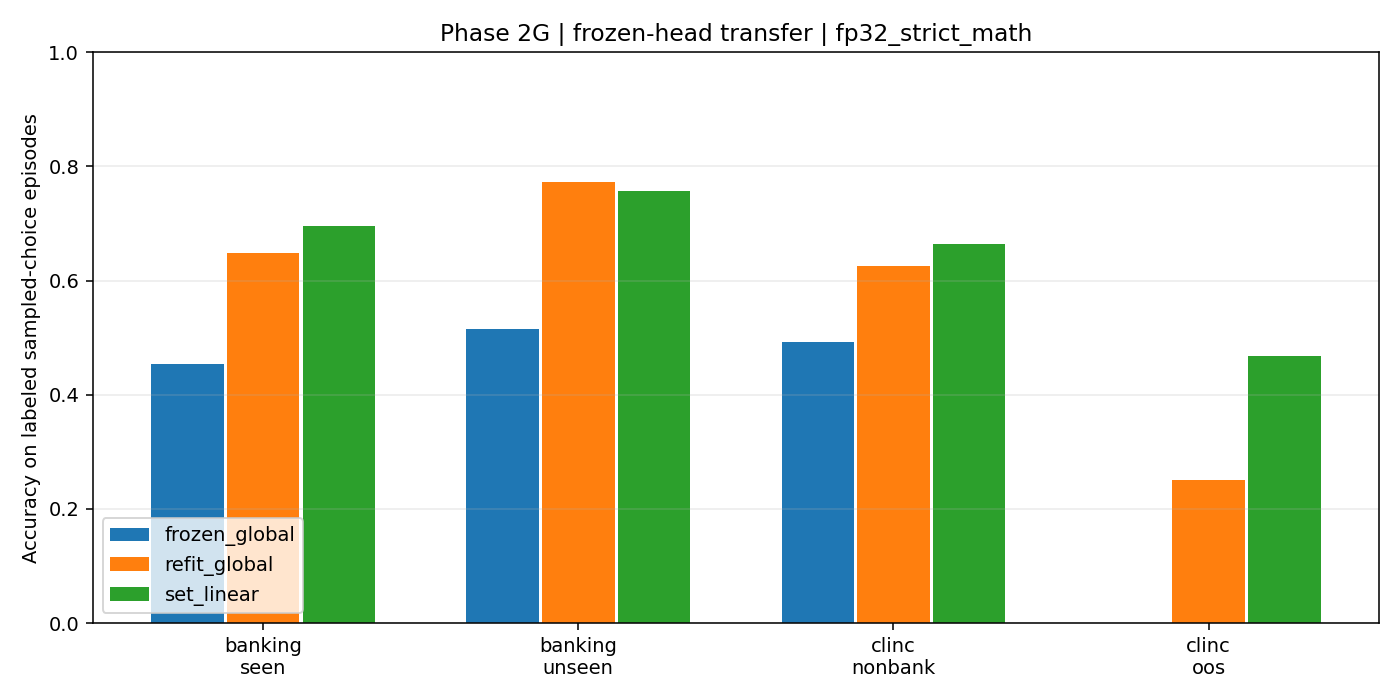

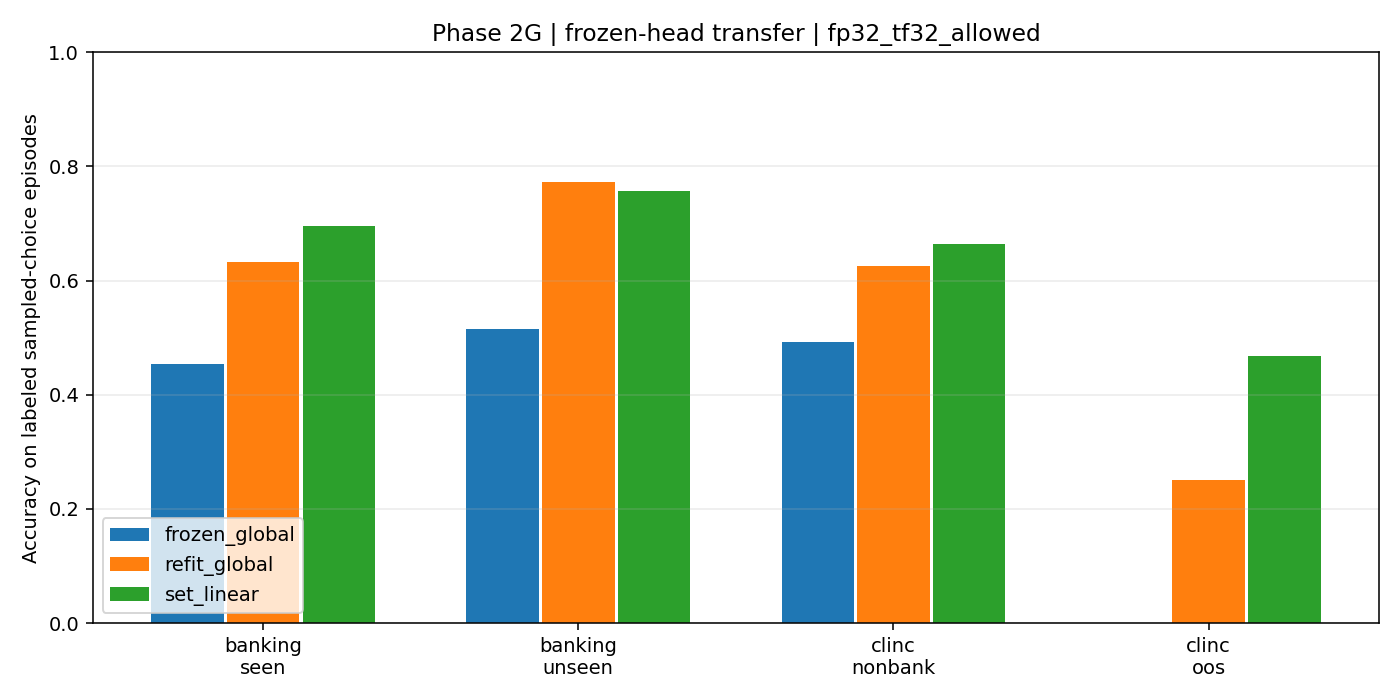

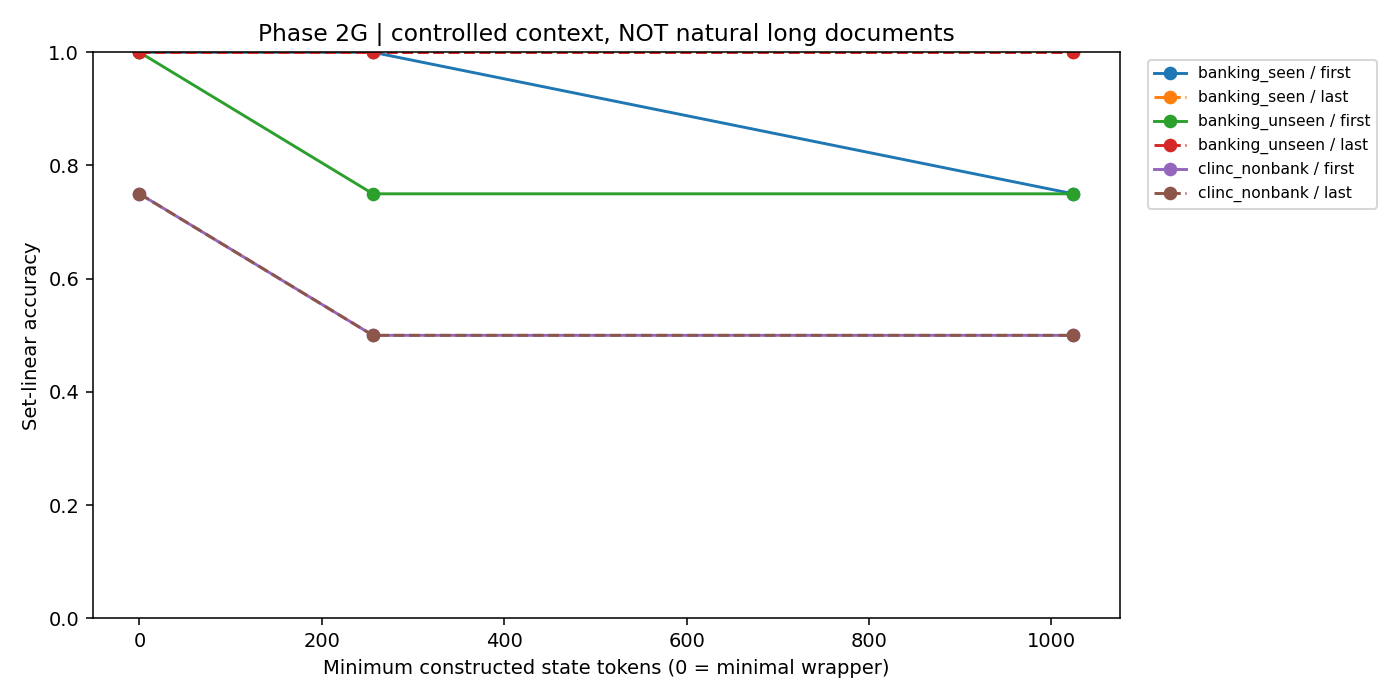

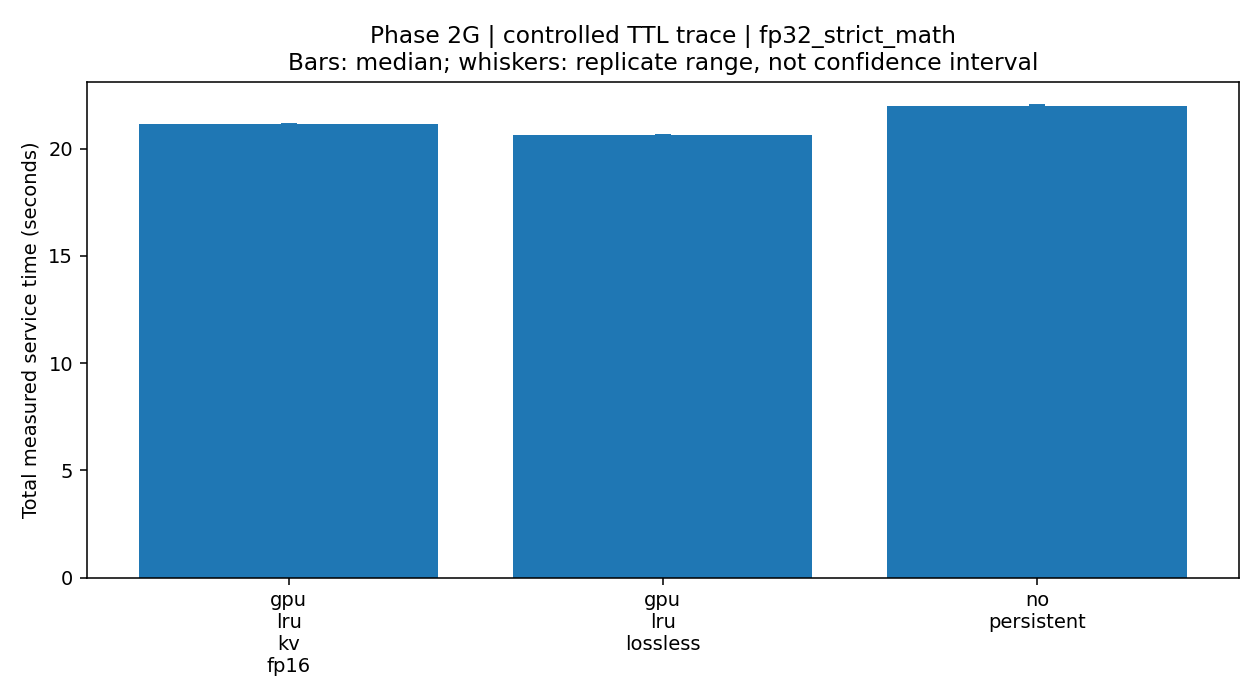

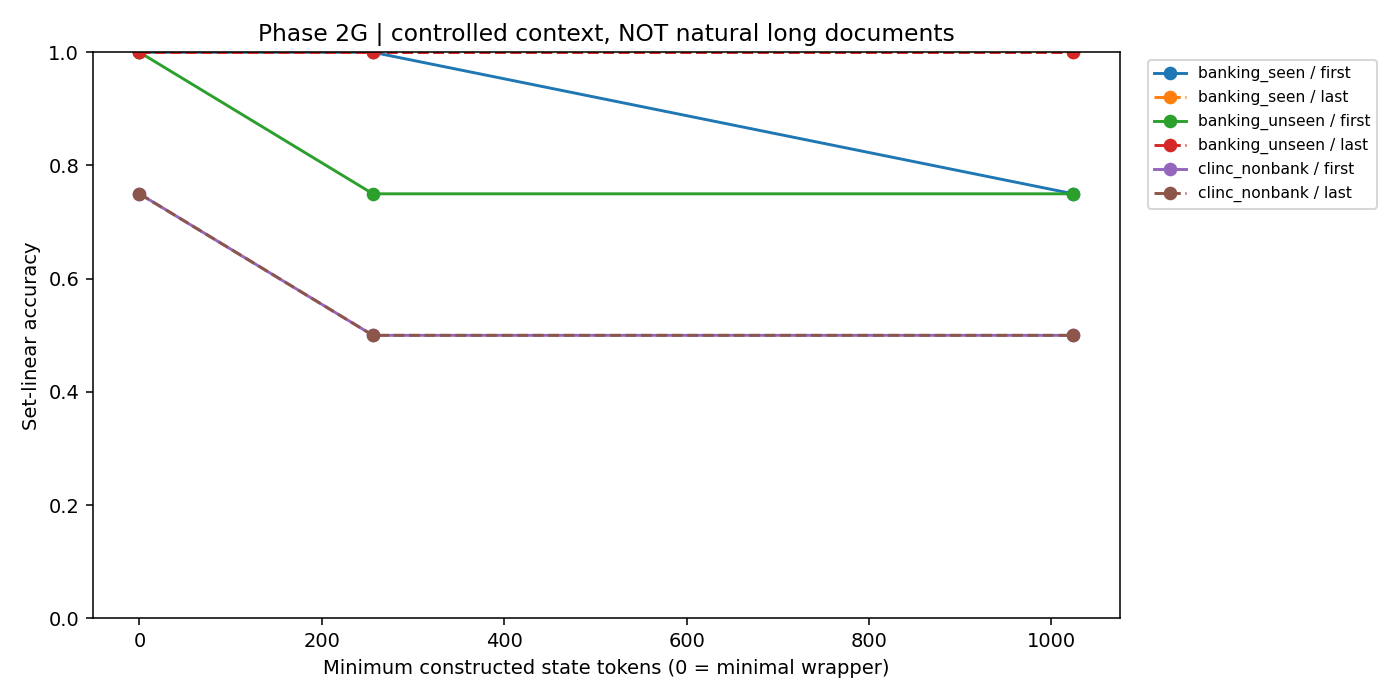

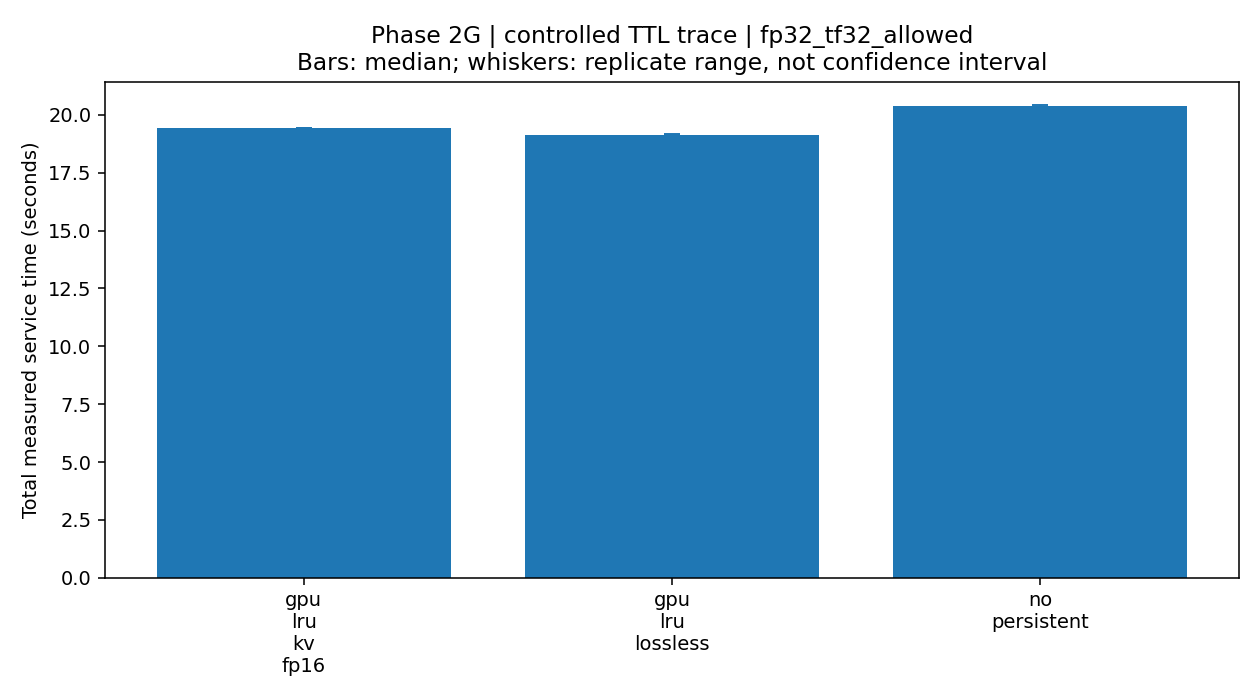

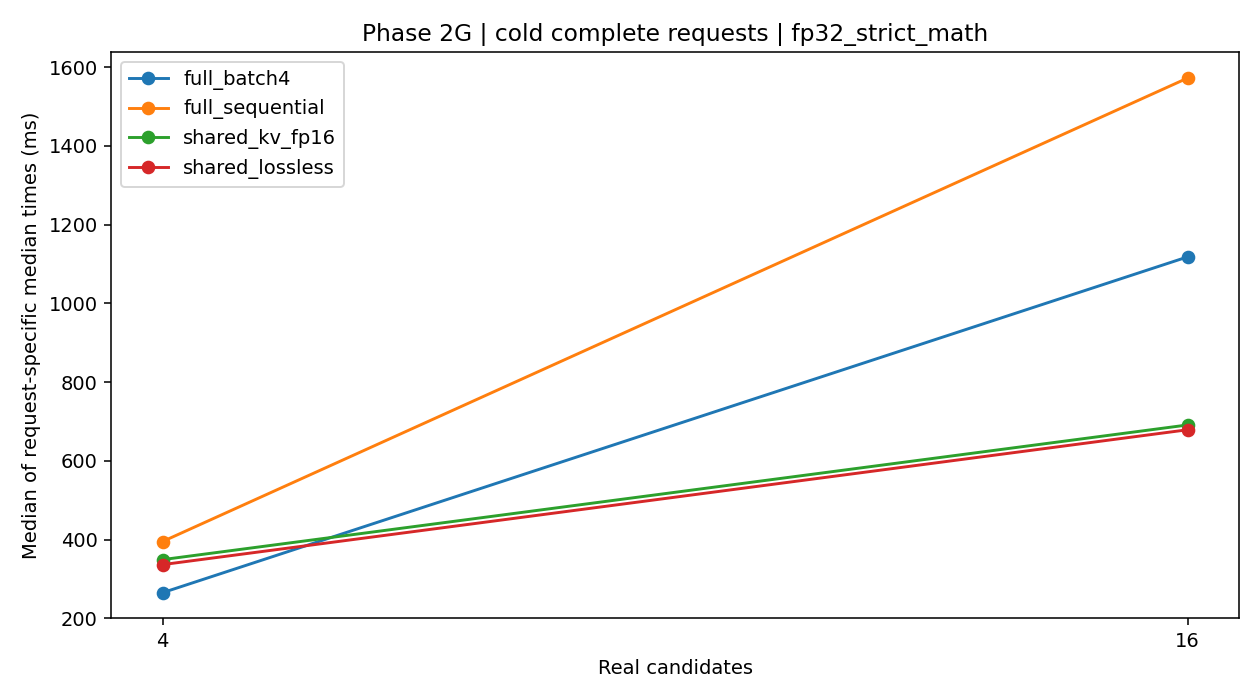

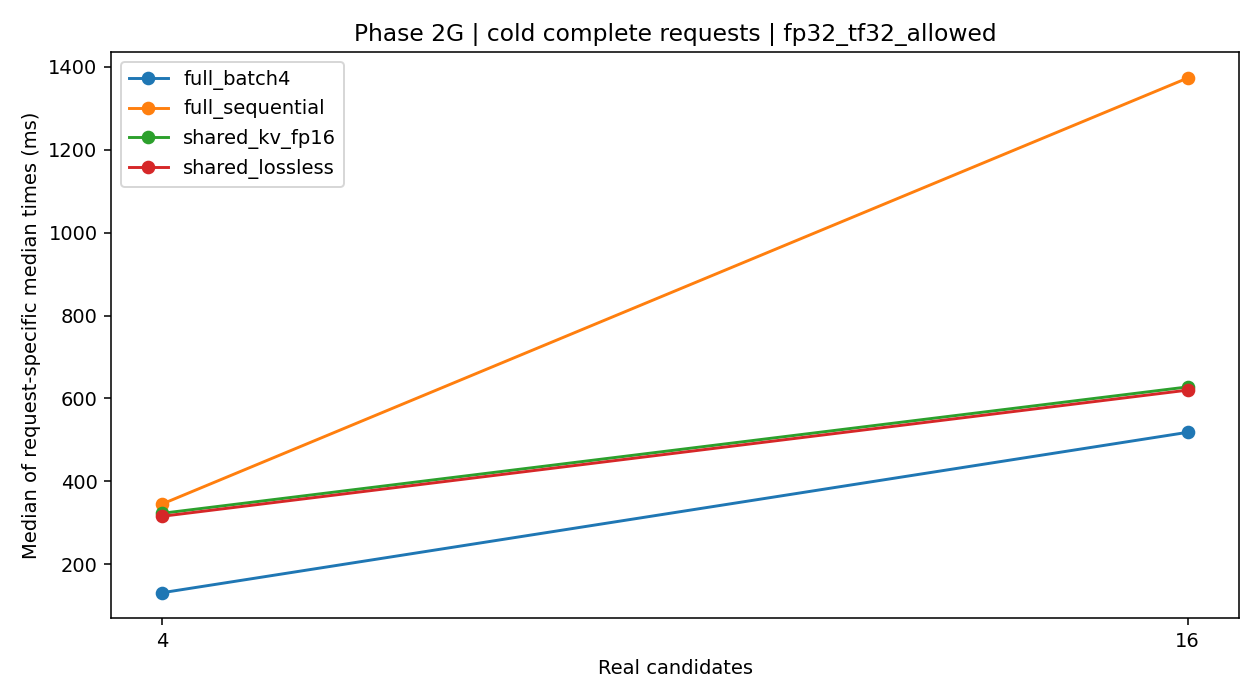

/content/openkind_phase2g/20260919T005142584348Z/paste_back_summary.json

/content/openkind_phase2g/20260919T005142584348Z/openkind_phase2g_summary.json

/content/openkind_phase2g/openkind_phase2g_20260919T005142584348Z.zip

In [12]:
from IPython.display import Image, FileLink
for path in EXPORT['plots']:
    display(Image(filename=path))
display(FileLink(str(EXPERIMENT.out/'paste_back_summary.json')))
display(FileLink(str(EXPERIMENT.out/'openkind_phase2g_summary.json')))
display(FileLink(EXPORT['archive']))

## Takeaways to write after running

1. Do strict-FP32 lossless/FP16-KV paths preserve probabilities and policy outputs on fresh inputs? State counts **by messages and episodes**.
2. Does the frozen scorer retain meaningful label quality beyond Banking? Report non-financial intents and author OOS separately.
3. Does TF32 permission change accuracy, NLL, accepted errors, or parity—and what latency was actually saved?
4. How do evidence position and unrelated case-note length change results relative to the matching minimal-wrapper control?
5. Did TTL, misses, and tenant separation behave as designed? Did persistence improve complete measured trace time under this controlled arrival sequence?

Do not select new thresholds against these test results. A state-first prompt, LoRA, a smaller backbone, or a redesigned semantic none head requires its own fitting/development/calibration/final-test plan.

### Source register
- Completed Phase 2F archive: run `20260918T224427722898Z`, SHA-256 `e1d3fea878d35b9e929e83424d4f3aa8b5de0385bb100ace001110f7e5f83c37`.
- Supplied OpenKind whitepaper v0.2: informs the hypotheses; original file left unchanged. Proposed corrections are in the starter's review memo.
- [CLINC original author repository](https://github.com/clinc/oos-eval), pinned commit `828f8093932c8fe6ca7936c3d2e52903b1c523de` and checked Git blobs for data, domain mapping, and license.
- [Banking77 original author data](https://github.com/PolyAI-LDN/task-specific-datasets), test CSV SHA-256 `d12d6e3bc4c3103966ae786dc435913c0c563dfa328f5a3646d0e62cfeeb474d`.
- [PyTorch 2.11 CUDA numerical controls](https://docs.pytorch.org/docs/2.11/notes/cuda.html): TF32 is an arithmetic mode, not an automatic equivalence claim.

**Known validation gap:** the full 4B CUDA run, TF32 hardware dispatch, and these online data downloads were not executable in the notebook-authoring environment. Local CPU fixtures validate contracts and the workflow, not these measurements.